# MAPoRL: Multi-Agent Post-Co-Training for Collaborative Large Language Models with Reinforcement Learning

> **Paper**: [ACL 2025](https://aclanthology.org/2025.acl-long.1459/) · **Code**: [chanwoo-park-official/MAPoRL](https://github.com/chanwoo-park-official/MAPoRL)

---

## Table of Contents
0. [Source Code Setup](#0)
1. [Paper Overview](#1)
2. [Environment Setup](#2)
3. [Dataset Preparation](#3)
4. [DataCollator](#4)
5. [Model Architecture](#5)
6. [Reward System](#6)
7. [Multi-Agent Communication](#7)
8. [PPO Rollout Phase](#8)
9. [PPO Update Phase (GAE + Loss)](#9)
10. [Training Configuration & Execution](#10)
11. [Inference Pipeline](#11)
12. [Evaluation (stat_all)](#12)
13. [Experiment 1 — Role Separation Ablation](#13)
14. [Experiment 2 — Asymmetric LoRA Rank](#14)
15. [Experiment 3 — Base Model Size Comparison](#15)


<a id='0'></a>

---
## 0. Source Code Setup

Run all cells in this section **once** to write project source files to disk.  
After that, `pip install -e trl/` makes the custom TRL package importable.

> **Note:** These cells use `%%writefile` magic — each cell writes one file.  
> Skip this section if the files already exist (e.g., cloned from the repo).


In [1]:
import os
# Move to repo root so all relative paths work from term_project_MAPoRL/
os.chdir(os.path.abspath('..'))
# Create necessary directories
for d in ["utils", "trl/trl/trainer", "config/ppo_config",
          "config/deepspeed_config", "shell", "results"]:
    os.makedirs(d, exist_ok=True)
print("\u2713 Directory structure ready")


### Utility Modules

_helper functions, distributed setup, safe code execution_

In [2]:
%%writefile utils/utils_general.py
import ast
import random
import numpy as np
import torch
import json
import importlib.util
import sys
import io
import boto3
import yaml
from typing import Optional, List, Dict, Tuple
import torch.distributed as dist
from safetensors.torch import load_file
import torch.nn as nn
import os
import datetime
import hashlib
import tarfile
import zipfile
import re
import pandas as pd
import requests
from tqdm import tqdm
BYTES_TO_GB = 1024**3

def extract_last_number_after_slash(path: str) -> int:
    """
    Extract the last number that appears after a slash in a path.

    Args:
        path: File or directory path containing numbers after slashes

    Returns:
        The last number found after a slash

    Raises:
        ValueError: If no numbers are found after slashes in the path
    """
    numbers = re.findall(r'/(\d+)', path)

    if numbers:
        return int(numbers[-1])
    else:
        raise ValueError(f"No numbers found after slashes in the path: {path}")




def find_latest_folder(base_dir: str) -> Optional[str]:
    """
    Find the latest (highest numbered) folder in a directory.

    Args:
        base_dir: Base directory to search for numbered subdirectories

    Returns:
        Path to the latest folder, or None if no numeric directories found
    """
    subdirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

    numeric_dirs = []
    for d in subdirs:
        if d.isdigit():  # Check if the directory name is a number
            numeric_dirs.append((int(d), d))
        else:
            # For directory names that might include non-numeric characters
            match = re.search(r'\d+', d)
            if match:
                numeric_dirs.append((int(match.group()), d))

    # Sort directories based on the numeric value
    numeric_dirs.sort(key=lambda x: x[0], reverse=True)

    if numeric_dirs:
        return os.path.join(base_dir, numeric_dirs[0][1])
    else:
        return None


def parse_list(string: str) -> list:
    """
    Safely parse a string representation of a list using ast.literal_eval.

    Args:
        string: String representation of a list (e.g., "[1, 2, 3]")

    Returns:
        The parsed list object

    Raises:
        ValueError: If the string cannot be safely evaluated as a list
    """
    return ast.literal_eval(string)  # Safely evaluate the string        
def print_gpu_memory_usage() -> None:
    """
    Print current GPU memory usage for all available GPUs.

    Displays allocated and cached memory for each GPU device.
    """
    print("GPU Memory Usage:")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:")
        print(f"  Allocated: {torch.cuda.memory_allocated(i) / BYTES_TO_GB:.2f} GB")
        print(f"  Cached: {torch.cuda.memory_reserved(i) / BYTES_TO_GB:.2f} GB")

def unzip_file(file_path, directory='.'):
    if file_path.endswith(".zip"):
        target_location = os.path.join(directory, os.path.splitext(os.path.basename(file_path))[0])
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(target_location)
    elif file_path.endswith(".tar.gz"):
        target_location = os.path.join(directory, os.path.basename(file_path).split(".")[0])
        with tarfile.open(file_path) as tar:
            tar.extractall(target_location)

    return target_location


def is_effectively_integer(num: float) -> bool:
    """
    Check if a number is effectively an integer.

    Args:
        num: The number to check (int or float)

    Returns:
        True if the number is an integer or a float that represents an integer
    """
    if isinstance(num, int):
        return True
    return isinstance(num, float) and num.is_integer()


def mark_built(path, version_string="1.0"):
    """
    Mark this path as prebuilt.
    Marks the path as done by adding a '.built' file with the current timestamp plus a version description string.
    """
    with open(os.path.join(path, '.built'), 'w') as write:
        write.write(str(datetime.datetime.today()))
        if version_string:
            write.write('\n' + version_string)



def download_and_check_hash(url, filename, expected_hash, version, directory='data', chunk_size=1024 * 1024 * 10):
    # Download the file
    response = requests.get(url, stream=True)
    try:
        total_size = int(response.headers.get('content-length', 0))
    except:
        print("Couldn't get content-length from response headers, using chunk_size instead")
        total_size = chunk_size
    progress_bar = tqdm(total=total_size, unit='iB', unit_scale=True)
    data = b''
    for chunk in response.iter_content(chunk_size=chunk_size):
        progress_bar.update(len(chunk))
        data += chunk
    progress_bar.close()

    # Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Save the file to disk
    file_path = os.path.join(directory, filename)
    with open(file_path, 'wb') as f:
        f.write(data)

    # Calculate the hash of the downloaded data
    sha256_hash = hashlib.sha256(data).hexdigest()

    # Compare the calculated hash to the expected hash
    if sha256_hash != expected_hash:
        print('@@@ Downloaded file hash does not match expected hash!')
        raise RuntimeError

    return file_path



def build_data(resource, directory='data'):
    # check whether the file already exists
    if resource.filename.endswith('.tar.gz'):
        resource_dir = os.path.splitext(os.path.splitext(os.path.basename(resource.filename))[0])[0]
    else:
        resource_dir = os.path.splitext(os.path.basename(resource.filename))[0]
    file_path = os.path.join(directory, resource_dir)

    built = check_built(file_path, resource.version)

    if not built:
        # Download the file
        file_path = download_and_check_hash(resource.url, resource.filename, resource.expected_hash, resource.version,
                                            directory)

        # Unzip the file
        if resource.zipped:
            built_location = unzip_file(file_path, directory)
            # Delete the zip file
            os.remove(file_path)
        else:
            built_location = file_path

        mark_built(built_location, resource.version)
        print("Successfully built dataset at {}".format(built_location))
    else:
        print("Already built at {}. version {}".format(file_path, resource.version))
        built_location = file_path

    return built_location


def check_built(path, version_string=None):
    """
    Check if '.built' flag has been set for that task.
    If a version_string is provided, this has to match, or the version is regarded as not built.
    """
    fname = os.path.join(path, '.built')
    if not os.path.isfile(fname):
        return False
    else:
        with open(fname, 'r') as read:
            text = read.read().split('\n')
        return len(text) > 1 and text[1] == version_string


class DownloadableFile:
    def __init__(self, url, filename, expected_hash, version="1.0", zipped=True):
        self.url = url
        self.filename = filename
        self.expected_hash = expected_hash
        self.zipped = zipped
        self.version = version


def list_folders(directory, exclude_hidden=True, name_filter=None):
    try:
        # List all entries in the directory
        entries = os.listdir(directory)
        
        folders = []
        for entry in entries:
            full_path = os.path.join(directory, entry)
            # Check if the entry is a directory
            if os.path.isdir(full_path):
                # Optionally exclude hidden folders
                if exclude_hidden and entry.startswith('.'):
                    continue
                # Optionally filter by name pattern
                if name_filter and name_filter not in entry:
                    continue
                folders.append(entry)
        
        return folders
    except Exception as e:
        return str(e)


def set_seed(seed_val=42):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

def setup_distributed():
    dist.init_process_group(backend='nccl')

# Clean up the process group
def cleanup_distributed():
    dist.destroy_process_group()
# Function to load safetensors part onto the specified device
def load_safetensors_part(path, device):
    state_dict = load_file(path, device='cpu')  # Load onto CPU first
    # Move each tensor to the specified device
    for key in state_dict:
        state_dict[key] = state_dict[key].to(device)
    return state_dict


def json_loader(path):
    with open(path, "r") as f:
        return json.load(f)
    

def load_config_from_python(config_file):
    spec = importlib.util.spec_from_file_location("config", config_file)
    config_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(config_module)
    return config_module.config

def load_config_from_json(config_file):
    with open(config_file, 'r') as f:
        config = json.load(f)
    return config

def load_config_from_yaml(config_file):
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    return config


def check_and_add_special_tokens(tokenizer, special_tokens):
    # Check if the special tokens are new
    new_tokens = [token for token in special_tokens['additional_special_tokens'] if token not in tokenizer.get_vocab()]
    
    # Add the new special tokens
    if new_tokens:
        tokenizer.add_special_tokens({'additional_special_tokens': new_tokens})

    # Get token IDs for all special tokens
    token_ids = tokenizer.convert_tokens_to_ids(special_tokens['additional_special_tokens'])
    
    # Create a dictionary mapping tokens to their IDs
    token_id_map = dict(zip(special_tokens['additional_special_tokens'], token_ids))

    # Print the tokenizer's vocabulary size and token IDs
    print("Tokenizer's Vocabulary Size:", len(tokenizer))
    print("Special Tokens and their IDs:")
    for token, token_id in token_id_map.items():
        print(f"Token: {token}, ID: {token_id}")

    return tokenizer, token_id_map



def execute_python_code(code):
    # Create a string buffer to capture the output
    buffer = io.StringIO()
    
    # Save the current standard output
    old_stdout = sys.stdout
    
    try:
        # Redirect standard output to the buffer
        sys.stdout = buffer
        
        # Execute the code
        exec(code)
        
        # Get the printed output
        output = buffer.getvalue()
        
    except Exception as e:
        output = f"Error: {str(e)}"
    
    finally:
        # Restore the original standard output
        sys.stdout = old_stdout
    
    return output




def response_from_bedrock(text, max_token = 5000, modelID = "anthropic.claude-3-sonnet-20240229-v1:0"):
    # Initialize the Bedrock Runtime client
    runtime = boto3.client("bedrock-runtime", region_name='us-east-1')

    # Construct the request body
    body = {
        "anthropic_version": "bedrock-2023-05-31",
        "max_tokens": max_token,
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": text
                    }
                ]
            }
        ]
    }

    # Convert the body to JSON
    body_json = json.dumps(body)

    
    # Invoke the model
    trial_count = 0
    while True:
        try:
            response = runtime.invoke_model(
                modelId=modelID,
                contentType="application/json",
                accept="application/json",
                body=body_json
            )

            # Process the response
            response_body = json.loads(response["body"].read())
            break
        except Exception as e:
            trial_count += 1
            print(e)
            print("Retrying... Trial", trial_count)
            continue

    return response_body





def check_initial_weights(policy, adapter_name):
    adapter_params = [param for name, param in policy.named_parameters() if adapter_name in name]
    for param in adapter_params:
        if not torch.all(param == 0):
            return False
    return True

# Set the weights of the "ref" adapter to zero and freeze them
def zero_and_freeze_adapter(policy, adapter_name):
    adapter_params = [param for name, param in policy.named_parameters() if adapter_name in name]
    for param in adapter_params:
        nn.init.zeros_(param)
        param.requires_grad = False

def make_grad_work_adapter(policy, adapter_name):
    adapter_params = [param for name, param in policy.named_parameters() if adapter_name in name]
    for param in adapter_params:
        param.requires_grad = True

def make_grad_nowork_adapter(policy, adapter_name):
    adapter_params = [param for name, param in policy.named_parameters() if adapter_name in name]
    for param in adapter_params:
        param.requires_grad = False




Overwriting utils/utils_general.py


In [3]:
%%writefile utils/utils_model.py
# Standard library imports
import copy
import logging
import os
from typing import Dict, List, Optional, Tuple

# Third-party imports
import torch
import torch.nn as nn
from peft import get_peft_model
from safetensors.torch import load_file
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Local imports
from utils.utils_general import zero_and_freeze_adapter

# Configure logging
logger = logging.getLogger(__name__)


class ModelManager:
    def __init__(self,
                 agent_num: int,
                 base_model: str,
                 sft_model_path: str,
                 peft_config,
                 round_num: int = 1,
                 policy_separation: bool = False,
                 collaboration_separation: bool = False,
                 reload: bool = False,
                 reload_dir: Optional[str] = None,
                 task_training: bool = True,
                 diff_model_training: bool = False,
                 another_policy_base_model: Optional[List[str]] = None,
                 another_policy_sft_model_path: Optional[List[str]] = None):
        """
        Initialize models for multiple agents.

        Args:
            agent_num: Number of agents
            base_model: Path or name of the base model for main agent
            sft_model_path: Path to the fine-tuned model for main agent
            peft_config: PEFT configuration object
            round_num: Number of rounds for policy/value heads
            policy_separation: Whether to use separate policy adapters
            collaboration_separation: Whether to use collaboration separation
            reload: Whether to reload existing adapters and weights
            reload_dir: Directory containing saved adapters and weights
            task_training: Whether to enable task training
            diff_model_training: Whether to use different models for different agents
            another_policy_base_model: List of base models for additional agents
            another_policy_sft_model_path: List of SFT model paths for additional agents
        """
        self.tokenizers = []
        self.policies = []
        self.value_heads_list = []

        # peft_config를 리스트로 정규화: 단일 config → 모든 에이전트 공유
        # 리스트로 전달하면 에이전트별 다른 config 적용 (비대칭 파라미터 실험용)
        if isinstance(peft_config, list):
            peft_configs = [copy.deepcopy(c) for c in peft_config]
            if len(peft_configs) < agent_num:
                peft_configs += [copy.deepcopy(peft_configs[-1])] * (agent_num - len(peft_configs))
        else:
            peft_configs = [copy.deepcopy(peft_config) for _ in range(agent_num)]

        # Initialize main agent's model
        tokenizer, policy, value_heads = self._initialize_single_model(
            base_model=base_model,
            sft_model_path=sft_model_path,
            peft_config=peft_configs[0],
            round_num=round_num,
            policy_separation=policy_separation,
            collaboration_separation=collaboration_separation,
            reload=reload,
            reload_dir=reload_dir,
            task_training=task_training
        )

        self.tokenizers.append(tokenizer)
        self.policies.append(policy)
        self.value_heads_list.append(value_heads)

        # Initialize additional agents' models
        if diff_model_training and agent_num > 1:
            if not (another_policy_base_model and another_policy_sft_model_path):
                raise ValueError("another_policy_base_model and another_policy_sft_model_path required for diff_model_training")

            for agent in range(agent_num - 1):
                reload_dir_agent = os.path.join(reload_dir, f"model_{agent+1}") if reload_dir else None
                tokenizer, policy, value_heads = self._initialize_single_model(
                    base_model=another_policy_base_model[agent],
                    sft_model_path=another_policy_sft_model_path[agent],
                    peft_config=peft_configs[agent + 1],
                    round_num=round_num,
                    policy_separation=policy_separation,
                    collaboration_separation=collaboration_separation,
                    reload=reload,
                    reload_dir=reload_dir_agent,
                    task_training=task_training
                )
                self.tokenizers.append(tokenizer)
                self.policies.append(policy)
                self.value_heads_list.append(value_heads)
        elif agent_num > 1 and not diff_model_training:
            # 동일 base model, 에이전트별 다른 peft_config (비대칭 LoRA rank)
            for agent in range(1, agent_num):
                reload_dir_agent = os.path.join(reload_dir, f"model_{agent}") if reload_dir else None
                tokenizer, policy, value_heads = self._initialize_single_model(
                    base_model=base_model,
                    sft_model_path=sft_model_path,
                    peft_config=peft_configs[agent],
                    round_num=round_num,
                    policy_separation=policy_separation,
                    collaboration_separation=collaboration_separation,
                    reload=reload,
                    reload_dir=reload_dir_agent,
                    task_training=task_training
                )
                self.tokenizers.append(tokenizer)
                self.policies.append(policy)
                self.value_heads_list.append(value_heads)

    @staticmethod
    def _initialize_single_model(
        base_model: str,
        sft_model_path: str,
        peft_config,
        round_num: int,
        policy_separation: bool,
        collaboration_separation: bool,
        reload: bool,
        reload_dir: Optional[str],
        task_training: bool
    ) -> Tuple[AutoTokenizer, AutoModelForCausalLM, Dict]:
        """Initialize a single model with its tokenizer and value heads."""
        # Initialize tokenizer
        tokenizer = AutoTokenizer.from_pretrained(
            base_model,
            padding_side="left",
            trust_remote_code=True
        )
        if getattr(tokenizer, "pad_token", None) is None:
            tokenizer.pad_token = tokenizer.eos_token

        # Initialize model with 4-bit quantization
        bnb_config = BitsAndBytesConfig(load_in_4bit=True)
        if base_model!="google/gemma-2-2b-it":
            policy = AutoModelForCausalLM.from_pretrained(
                sft_model_path,
                trust_remote_code=True,
                quantization_config=bnb_config,
            )
        else:
            policy = AutoModelForCausalLM.from_pretrained(
                sft_model_path,
                trust_remote_code=True,
                quantization_config=bnb_config,
                # attn_implementation ='eager'
                attn_implementation = 'flash_attention_2'
            )
        policy.resize_token_embeddings(len(tokenizer))
        def load_adapter(model, adapter_name: str, adapter_path: str, peft_config):
            if os.path.exists(adapter_path):
                model.load_adapter(adapter_path, adapter_name)
                logger.info(f"Loaded adapter {adapter_name} from {adapter_path}")
            else:
                logger.info(f"Adapter path {adapter_path} not found. Adding new adapter.")
                model.add_adapter(adapter_name, peft_config)

        def load_or_add_adapter(model, adapter_name: str, peft_config, reload: bool, reload_dir: str):
            if reload:
                load_adapter(model, adapter_name, os.path.join(reload_dir, adapter_name), peft_config)
            else:
                model.add_adapter(adapter_name, peft_config)


        # Initialize value heads
        value_heads = {}

        # Configure policy based on separation settings
        if policy_separation and not collaboration_separation:
            policy = get_peft_model(policy, peft_config, adapter_name="policy_0")
            if reload:
                load_adapter(policy, "policy_0", os.path.join(reload_dir, "policy_0"), peft_config)
            for r in range(1, round_num):
                load_or_add_adapter(policy, f"policy_{r}", peft_config, reload, reload_dir)

        elif policy_separation and collaboration_separation:
            policy = get_peft_model(policy, peft_config, adapter_name="policy")
            if reload:
                load_adapter(policy, "policy", os.path.join(reload_dir, "policy"), peft_config)
            load_or_add_adapter(policy, "col", peft_config, reload, reload_dir)
        elif not policy_separation and collaboration_separation:
            raise ValueError(
                "Invalid configuration: collaboration_separation cannot be True "
                "while policy_separation is False. Please set policy_separation=True "
                "when using collaboration_separation=True."
            )
        else:
            policy = get_peft_model(policy, peft_config, adapter_name="policy")
            if reload:
                load_adapter(policy, "policy", os.path.join(reload_dir, "policy"), peft_config)

        # Setup value heads
        for r in range(round_num):
            adapter_name = f"value_{r}"
            value_heads[adapter_name] = nn.Linear(policy.config.hidden_size, 1, bias=False)
            load_or_add_adapter(policy, adapter_name, peft_config, reload, reload_dir)

            if reload:
                value_head_dir = os.path.join(reload_dir, f"value_head_value_heads_{r}")
                safetensors_path = os.path.join(value_head_dir, "model.safetensors")

                if os.path.exists(safetensors_path):
                    try:
                        state_dict = load_file(safetensors_path)
                        value_heads[adapter_name].load_state_dict(state_dict)
                        logger.info(f"Successfully loaded value head weights for {adapter_name}")
                    except Exception as e:
                        logger.error(f"Error loading value head weights for {adapter_name}: {str(e)}")
                else:
                    logger.warning(f"Value head weights file not found for {adapter_name}")

        # Add and configure reference adapter
        policy.add_adapter("ref", peft_config)
        zero_and_freeze_adapter(policy, "ref")

        if not task_training:
            if policy_separation:
                if collaboration_separation:
                    zero_and_freeze_adapter(policy, "policy")
                else:
                    zero_and_freeze_adapter(policy, "policy_0")
            else:
                print("error: policy_separation and task_training can't be False at the same time")

        return tokenizer, policy, value_heads


Overwriting utils/utils_model.py


In [4]:
%%writefile utils/utils_cooperateLLM.py
import ast
import io
import os
import re
import sys
import json
import requests
from collections import Counter
from typing import Optional
from torch.nn.parallel import DistributedDataParallel as DDP
from transformers import AutoModelForCausalLM
from peft import get_peft_model
import torch
from utils.utils_general import list_folders

# Constants
INVALID_ANSWER = -1
INVALID_ANSWER_STR = str(INVALID_ANSWER)
MAX_INPUT_LENGTH_MATH = 250
TRAIN_DATASET_SIZE_MATH = 100000
TEST_DATASET_SIZE_MATH = 1000
DEBUG_DATASET_SIZE = 2000
def convert_and_sort_folders(folder_names):
    print(folder_names)
    try:
        folder_numbers = [int(name) for name in folder_names if name.isdigit()]
        folder_numbers.sort()
        print(folder_numbers)
        return folder_numbers
    except ValueError as e:
        return str(e)

def create_invalid_entry(input_ids, tokenizer):
    """Create a standardized invalid entry for dataset processing."""
    return {
        "input_ids": input_ids,
        "lengths": len(input_ids),
        "answer": tokenizer.encode(INVALID_ANSWER_STR)
    }


def safe_execute_code(code_string, function_name='simple_math_problem'):
    """
    Safely execute code and return the result of a specific function.

    Args:
        code_string: The code to execute
        function_name: Name of the function to call from the executed code

    Returns:
        The result of calling the function, or INVALID_ANSWER if execution fails
    """
    try:
        original_stdout = sys.stdout
        sys.stdout = io.StringIO()
        namespace = {}
        exec(code_string, namespace)
        result = namespace[function_name]()
    except Exception:
        return INVALID_ANSWER
    finally:
        sys.stdout = original_stdout
    return result


def extract_info_from_ppo(input_string):
    # Define regular expressions for extracting the values
    agent_regex = r'agent_(\d+)'
    round_regex = r'round_(\d+)'
    policy_separation_regex = r'policy_separation_(True|False)'

    # Search for the values in the string
    agent_match = re.search(agent_regex, input_string)
    round_match = re.search(round_regex, input_string)
    policy_separation_match = re.search(policy_separation_regex, input_string)

    # Check if all values are found
    if agent_match and round_match and policy_separation_match:
        agent_number = int(agent_match.group(1))
        round_number = int(round_match.group(1))
        policy_separation = policy_separation_match.group(1) == 'True'

        return agent_number, round_number, policy_separation
    else:
        return False, False, False


def update_state_dict_keys_ppo2(state_dict):
    updated_state_dict = {}
    
    for key in state_dict.keys():
        # Patterns for matching keys with specified structures
        patterns = [
            (re.compile(r'base_model\.model\.model\.layers\.(\d+)\.mlp\.down_proj\.lora_A\.weight'), 
             r'base_model.model.model.layers.\1.mlp.down_proj.lora_A.default.weight'),
            (re.compile(r'base_model\.model\.model\.layers\.(\d+)\.mlp\.down_proj\.lora_B\.weight'), 
             r'base_model.model.model.layers.\1.mlp.down_proj.lora_B.default.weight'),
            (re.compile(r'base_model\.model\.model\.layers\.(\d+)\.self_attn\.o_proj\.lora_A\.weight'), 
             r'base_model.model.model.layers.\1.self_attn.o_proj.lora_A.default.weight'),
            (re.compile(r'base_model\.model\.model\.layers\.(\d+)\.self_attn\.o_proj\.lora_B\.weight'), 
             r'base_model.model.model.layers.\1.self_attn.o_proj.lora_B.default.weight')
        ]
        
        new_key = key
        for pattern, replacement in patterns:
            new_key = re.sub(pattern, replacement, new_key)
        
        updated_state_dict[new_key] = state_dict[key]
        
    return updated_state_dict


def update_external_model_lora(model, state_dict, yyy):
    model_state_dict = model.state_dict()
    for key, value in state_dict.items():
        # Identifying the type of weight and corresponding indices
        if "mlp.down_proj.lora_A.weight" in key:
            xxx_index = key.split('.')[4]
            new_key = f'base_model.model.model.layers.{xxx_index}.mlp.down_proj.lora_A.{yyy}.weight'
        elif "mlp.down_proj.lora_B.weight" in key:
            xxx_index = key.split('.')[4]
            new_key = f'base_model.model.model.layers.{xxx_index}.mlp.down_proj.lora_B.{yyy}.weight'
        elif "self_attn.o_proj.lora_A.weight" in key:
            xxx_index = key.split('.')[4]
            new_key = f'base_model.model.model.layers.{xxx_index}.self_attn.o_proj.lora_A.{yyy}.weight'
        elif "self_attn.o_proj.lora_B.weight" in key:
            xxx_index = key.split('.')[4]
            new_key = f'base_model.model.model.layers.{xxx_index}.self_attn.o_proj.lora_B.{yyy}.weight'
        else:
            continue

        if new_key in model_state_dict:
            model_state_dict[new_key].copy_(value)
        else:
            print(f"Warning: Key {new_key} not found in the model's state dict.")

    # Load the updated state dictionary into the model
    model.load_state_dict(model_state_dict)




def step_config(mode, ppo_model):
    if mode == "ppo":
        steps = convert_and_sort_folders(list_folders(ppo_model))+ ["original_model"] 
    elif mode == "sft":
        steps = ["sft-ed", "original_model"]

    steps = [step for step in steps if not step == 0]

    return steps

def model_path_for_step(mode, step, base_model, sft_model, ppo_model):
    if step == "original_model":
        model_path = base_model
        return model_path
    if mode == "sft" and step == "sft-ed":
        model_path = sft_model
    elif mode == "ppo":
        model_path = f"{ppo_model}/{step}"
    
    return model_path

def model_for_step(mode, step, base_model, sft_model, peft, peft_config, local_rank):
    if mode == "sft" and step =="original_model":
        model = AutoModelForCausalLM.from_pretrained(base_model, torch_dtype=torch.bfloat16,  trust_remote_code=True)
    else:
        model = AutoModelForCausalLM.from_pretrained(sft_model, torch_dtype=torch.bfloat16,  trust_remote_code=True)
        if base_model == "microsoft/Phi-3-mini-128k-instruct":
            if peft:
                model = get_peft_model(model, peft_config, adapter_name = "ref")      
                print("ref is ready")              
    return model    


def construct_message_multi_agent(agents, question, idx):
    if len(agents) == 0:
        return {"role": "user", "content": "Can you double check that your answer is correct. Please reiterate your answer. \n\n The original question is as follows:\n {}.".format(question)}

    prefix_string = "These are the solutions to the problem from other agents: "

    for agent in agents:
        agent_response = agent[idx]["content"]
        response = "\n\n One agent solution: ```{}```".format(agent_response)

        prefix_string = prefix_string + response

    prefix_string = prefix_string + """\n\n Using the solutions from other agents as additional information, can you provide your answer to this question? \n\n The original question is as follows: \n {}. \n You should not copy other agents' answer, but just use information from other agents.""".format(question)
    return {"role": "user", "content": prefix_string}


def construct_assistant_message(completion):
    return {"role": "assistant", "content": completion}

def initialize_policy_weights(policy_model, state_dict, round_num):
    layer_keys = [
        ('self_attn.o_proj.lora_A.value_{turn}.weight', 'self_attn.o_proj.lora_A.default.weight'),
        ('self_attn.o_proj.lora_B.value_{turn}.weight', 'self_attn.o_proj.lora_B.default.weight'),
        ('mlp.down_proj.lora_A.value_{turn}.weight', 'mlp.down_proj.lora_A.default.weight'),
        ('mlp.down_proj.lora_B.value_{turn}.weight', 'mlp.down_proj.lora_B.default.weight')
    ]
    num_layers = policy_model.config.num_hidden_layers

    for i in range(num_layers):
        for turn in range(round_num):
            for policy_key_template, value_key_template in layer_keys:
                policy_key = policy_key_template.format(turn=turn)
                value_key = value_key_template

                policy_weight_path = f'policy_model.base_model.model.model.layers[{i}].{policy_key}'
                value_weight_path = f'state_dict["model.base_model.model.model.layers.{i}.{value_key}"]'

                # Evaluate the paths to get the weights
                policy_weight = eval(policy_weight_path)
                value_weight = eval(value_weight_path)

                # Copy the weights from value_model to policy_model
                policy_weight.data.copy_(value_weight.data)


def extract_ans_from_response(answer: str) -> any:
    """Extract numerical answer from response string."""
    answer = answer.strip()
    boxed_pattern = re.compile(r'\\boxed\{(.*?)\}')
    matches = boxed_pattern.findall(answer)
    if matches:
        answer = matches[-1].strip()

    answer = re.sub(r'[^0-9\-\.]', '', answer)
    try:
        return int(answer)
    except ValueError:
        return "invalid"


def extract_ans_from_response_with_str(answer: str) -> str:
    """Extract answer from response as string."""
    answer = answer.strip()
    boxed_pattern = re.compile(r'\\boxed\{(.*?)\}')
    matches = boxed_pattern.findall(answer)
    if matches:
        answer = matches[-1].strip()
        return answer
    else:
        return "invalid"
def extract_reward(text):
    """
    Extracts the reward value from a given string.

    :param text: Input string containing the reward information.
    :return: Extracted reward as a float, or None if not found.
    """
    match = re.search(r"Reward from a verifier of your answer:\s*([\d\.]+)", text)
    return float(match.group(1)) if match else None

def update_turn_based_training(update, criteria_for_consensus_percentage, criteria_for_consensus_reward_threshold,
                              update_initial_turn, turn_based_training_num, round_num):
    """
    Update the turn based training.

    This function is used to update the turn based training. -- so for ease of training,
    we use turn based training so that we freeze other turn's model parameters.

    Args:
        update: Current update number
        criteria_for_consensus_percentage: Consensus percentage threshold
        criteria_for_consensus_reward_threshold: Consensus reward threshold
        update_initial_turn: Initial turn update number
        turn_based_training_num: Number of turns for training
        round_num: Total number of rounds

    Returns:
        int or list: Turn number(s) to update
    """

    if criteria_for_consensus_percentage >=1 or criteria_for_consensus_reward_threshold >=1:
        k = (update-update_initial_turn) // turn_based_training_num  # Find the appropriate k value
        turn_update_turn = round_num -2 - (k % (round_num-1 ))
        if -1<=update<=update_initial_turn- 1:
            turn_update_turn = 0
        return turn_update_turn + 1
    else:
        k = (update-update_initial_turn) // turn_based_training_num  # Find the appropriate k value
        return [i for i in range(1, round_num)]


def stat_all(answer_input_forstat, answers_all_agent_turn, finished_question, open_ended_answer):
    """
    Calculate statistics for all agent turns.

    Args:
        answer_input_forstat: Ground truth answers (or tuple for open-ended)
        answers_all_agent_turn: List of agent answers for each turn
        finished_question: List indicating which questions are finished
        open_ended_answer: Whether this is open-ended question type

    Returns:
        tuple: (correctness_turn_list, count_turn_list) - Statistics for each turn
    """
    from sentence_transformers import SentenceTransformer
    from collections import Counter
    import torch

    if open_ended_answer:
        groundtruth_answers = answer_input_forstat[0]
        groundtruth_wrong_answers = answer_input_forstat[1]
        sentence_embedding_model = SentenceTransformer('sentence-transformers/all-roberta-large-v1')
        answer_turn_list = [[[] for j in range(len(answers_all_agent_turn[0]))] for i in range(len(answers_all_agent_turn))]
    else:
        groundtruth_answers = answer_input_forstat
        answer_turn_list = answers_all_agent_turn

    count_turn_list = []  # Will store the difference between turn and turn+1 correctness

    correctness_turn_list = [[] for i in range(len(answers_all_agent_turn))]
    for turn in range(len(answers_all_agent_turn)):
        correctness = []

        # Step 1: Filter the valid questions based on the condition
        valid_indices = [idx for idx in range(len(finished_question)) if finished_question[idx] >= turn or finished_question[idx] == -1]

        for q in range(len(groundtruth_answers)):
            groundtruth = groundtruth_answers[q]
            if open_ended_answer:
                groundtruth_wrong = groundtruth_wrong_answers[q]
                groundtruth_TF_list = [groundtruth, groundtruth_wrong]
                embeddings_groundtruth = sentence_embedding_model.encode(groundtruth_TF_list)


            # Only consider answers if the question has not been finished before or at the current turn
            if finished_question[q] >= turn or finished_question[q] == -1:
                # Map the current q to the correct index in valid_indices
                q_index_in_valid = valid_indices.index(q)

                if len(answers_all_agent_turn) == 1:
                    current_turn_answers = [answers[q_index_in_valid] for answers in answers_all_agent_turn[turn] if answers]
                    if not open_ended_answer:
                        if current_turn_answers and current_turn_answers[0] == groundtruth:
                            correctness.append(1)
                        else:
                            correctness.append(0)
                    else:
                        if current_turn_answers:
                            agent_ans_list = [current_turn_answers[0]]
                            embeddings_agent = sentence_embedding_model.encode(agent_ans_list)
                            similarities = sentence_embedding_model.similarity(embeddings_groundtruth, embeddings_agent)
                            if similarities[0] >= similarities[1]:
                                correctness.append(1)
                        else:
                            correctness.append(0)


                else:
                    current_turn_answers = [answers[q_index_in_valid] for answers in answers_all_agent_turn[turn] if answers]
                    if not current_turn_answers:  # No answers provided
                        correctness.append(-2)
                    else:
                        if open_ended_answer:
                            embeddings_agent = sentence_embedding_model.encode(current_turn_answers)
                            similarities = sentence_embedding_model.similarity(embeddings_groundtruth, embeddings_agent)
                            ans_extracted = ['correct' if similarities[i, 0] > similarities[i, 1] else 'wrong' for i in range(len(current_turn_answers))]
                            for i in range(len(current_turn_answers)):
                                answer_turn_list[turn][i].append(ans_extracted[i])
                            answer_counts = Counter(ans_extracted)
                        else:
                            answer_counts = Counter(current_turn_answers)


                        max_count = max(answer_counts.values())

                        # Find all answers that have the maximum count
                        majority_votes = [ans for ans, count in answer_counts.items() if count == max_count]
                        if "invalid" in majority_votes and len(majority_votes) > 1:
                            majority_votes.remove("invalid")

                        # Check if the groundtruth is in the majority votes
                        if open_ended_answer:
                            if 'correct' in majority_votes:
                                correctness.append(1 / len(majority_votes))

                            else:
                                correctness.append(0)

                        else:
                            if groundtruth in majority_votes:
                                correctness.append(1 / len(majority_votes))  # Correct, but with possible ties

                            else:
                                correctness.append(0)  # Incorrect

            else:
                correctness.append(-1)  # Mark as finished for this turn, no need to evaluate
        correctness_turn_list[turn] = correctness


    for turn in range(len(answers_all_agent_turn) - 1):
        diff = []
        turn_correct = correctness_turn_list[turn]
        turnp1_correct = correctness_turn_list[turn + 1]

        for q in range(len(groundtruth_answers)):
            # Calculate the difference between turn and turn + 1 correctness
            if turn_correct[q] == -1 or turnp1_correct[q] == -1:
                diff.append(-2)  # No comparison needed
            else:
                if turn_correct[q] < turnp1_correct[q]:
                    diff.append(1)  # Improvement
                elif turn_correct[q] > turnp1_correct[q]:
                    diff.append(-1)  # Decline
                else:
                    diff.append(0)  # No change

        improve_count = diff.count(1)
        decline_count = diff.count(-1)
        no_change_count = diff.count(0)

        count_turn_list.append([improve_count, decline_count, no_change_count])
    if open_ended_answer:
        del sentence_embedding_model
        torch.cuda.empty_cache()

    return correctness_turn_list, count_turn_list


def check_repeated_sequences(tokenizer, sequence, min_seq_length=1, max_seq_length=20, max_repeats=3):
    """
    Check if any subsequence of length 1-11 is repeated more than 3 times,
    excluding sequences of numeric tokens (0-9).

    Args:
        tokenizer: The tokenizer to use for decoding
        sequence: torch.Tensor of shape (sequence_length,)
        min_seq_length: minimum length of subsequence to check
        max_seq_length: maximum length of subsequence to check
        max_repeats: maximum number of allowed repetitions

    Returns:
        bool: True if invalid repetition is found, False otherwise
    """
    seq_len = len(sequence)

    # Convert sequence to list for easier processing
    seq_list = sequence.tolist()

    for length in range(min_seq_length, min(max_seq_length + 1, seq_len + 1)):
        for start in range(seq_len - length + 1):
            # Get the subsequence
            subseq = seq_list[start:start + length]

            # Skip if all tokens in subsequence are numeric (0-9 in token space)
            decoded_subseq = tokenizer.decode(subseq)
            if decoded_subseq.strip().isdigit():
                continue

            # Count repetitions
            repeat_count = 1
            current_pos = start + length

            while current_pos + length <= seq_len:
                next_subseq = seq_list[current_pos:current_pos + length]
                if next_subseq == subseq:
                    repeat_count += 1
                    if repeat_count > max_repeats:
                        return True
                    current_pos += length
                else:
                    break

    return False


def reward_from_different_server(query_responses, ip, reward_feedback = True):
    # Convert the tensor to a list for JSON serialization
    # query_responses_list = query_responses.tolist()
    # json_post = {'query_responses': queries_for_score_batches}


    if reward_feedback:
        json_post = {'query_responses': query_responses}

        # Send the POST request to the server
        try:
            response = requests.post(ip, json=json_post)
            response.raise_for_status()  # Raise an exception for HTTP errors
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            return None

        # Convert the result back to a tensor
        try:
            result = response.json()
        except json.JSONDecodeError as e:
            print(f"Failed to decode JSON response: {e}")
            return None

        return torch.tensor(result['result'])
    else:
        return torch.zeros(len(query_responses))


def grad_requires_setting(model, task_training, policy_separation, collaboration_separation):
    for name, param in model.named_parameters():
        if task_training:
            if ("lora" in name) and ("ref" not in name):
                param.requires_grad = True
            else:
                param.requires_grad = False
        else:
            if policy_separation:
                if collaboration_separation:
                    if ("lora" in name) and ("ref" not in name) and (("value" in name) or ("col" in name)):
                        param.requires_grad = True
                    else:
                        param.requires_grad = False
                else:
                    if ("lora" in name) and ("ref" not in name) and (("value" in name) or ("policy_0" not in name)):
                        param.requires_grad = True
                    else:
                        param.requires_grad = False


def calculate_reward_from_answer(dataset_name, queries_for_score_batches, answer_text_set_small_batch):
    """
    Calculate rewards based on answer correctness for given dataset.

    Args:
        dataset_name: Name of the dataset (e.g., 'GSM8k', 'ANLI')
        queries_for_score_batches: List of query batches to score
        answer_text_set_small_batch: Ground truth answers

    Returns:
        torch.Tensor: Binary reward tensor (1 for correct, 0 for incorrect)
    """
    from utils.dataset import extract_ans_from_response  # Import here to avoid circular imports

    answer_from_your_queries = [
        extract_ans_from_response(dataset_name, queries_for_score_batch[1]["content"])
        for queries_for_score_batch in queries_for_score_batches
    ]
    return torch.tensor(
        [1 if answer_from_your_queries[i] == answer_text_set_small_batch[i] else 0
         for i in range(len(answer_from_your_queries))],
        dtype=torch.long
    )


def check_agent_consensus(answers_all_agent, rewards_all_agent, criteria_for_consensus_percentage,
                         criteria_for_consensus_reward_threshold, q_index_in_unfinished):
    """
    Check if agents have reached consensus on answers.

    Args:
        answers_all_agent: List of answers from all agents
        rewards_all_agent: List of rewards for all agents
        criteria_for_consensus_percentage: Minimum percentage for consensus
        criteria_for_consensus_reward_threshold: Minimum reward threshold
        q_index_in_unfinished: Index of question in unfinished list

    Returns:
        bool: True if consensus reached, False otherwise
    """
    rewards_all_agent_new = [rewards_all_agent[agent][0][q_index_in_unfinished]
                           for agent in range(len(answers_all_agent))]

    if len(answers_all_agent) == 0:
        return False

    answer_counter = Counter(answers_all_agent)
    majority_answer, majority_count = answer_counter.most_common(1)[0]
    majority_percentage = majority_count / len(answers_all_agent)

    if majority_answer == "invalid":
        return False

    if majority_percentage <= criteria_for_consensus_percentage:
        return False

    # Filter rewards for majority answer
    majority_rewards = [rewards_all_agent_new[i] for i in range(len(answers_all_agent))
                       if answers_all_agent[i] == majority_answer]
    avg_reward = torch.tensor(majority_rewards).mean().item()

    return avg_reward > criteria_for_consensus_reward_threshold


Overwriting utils/utils_cooperateLLM.py


In [5]:
%%writefile utils/dataset.py
import re
import torch
from torch.utils.data import Dataset
from datasets import load_dataset
from datasets import Dataset as HFDataset
import random
from tqdm import tqdm
import itertools
from typing import List, Dict, Optional, Tuple, Any
from utils.utils_general import set_seed, json_loader, DownloadableFile, unzip_file, check_built, mark_built, download_and_check_hash, build_data

# Constants
DEFAULT_MAX_LENGTH = 1000
DEFAULT_RANDOM_SEED = 42
DEBUG_DATASET_SIZE = 100
DEFAULT_TEST_LEN = 100
CRITICAL_VALUE = 1  # Used in reward dataset balancing
MIN_ANSWERS = 30   # Minimum answers per question for cleansing

# TODO: Consider making dataset loading more flexible to handle varying dataset locations
class BaseDataset(Dataset):
    """Base dataset class for loading and processing question-answer data.

    This class provides a foundation for dataset implementations with common functionality
    for tokenization and data preparation for language model training.
    """
    def __init__(self, tokenizer: Any, split: str, max_length: int = DEFAULT_MAX_LENGTH, debug: bool = False, eval_mode: bool = False) -> None:
        self.tokenizer = tokenizer
        self.split = split
        self.max_length = max_length
        self.debug = debug
        self.eval_mode = eval_mode
        self.qa_list, self.a_list = self.load_data()

    def load_data(self) -> Tuple[List[List[Dict[str, str]]], List[List[Dict[str, str]]]]:
        raise NotImplementedError("This method should be overridden by subclasses")

    def __len__(self) -> int:
        return len(self.qa_list)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        txt = self.qa_list[idx]
        encodings_dict = self.tokenizer.apply_chat_template(txt, truncation=True, max_length=self.max_length, padding="max_length", return_dict=True, add_generation_prompt = self.eval_mode)
        input_ids = torch.tensor(encodings_dict["input_ids"])
        attn_masks = torch.tensor(encodings_dict["attention_mask"])

        if self.eval_mode:
            txt_a = self.a_list[idx]
            ## extract the answer.text
            txt_a = [{'role': 'assistant', 'content': txt_a[0]["content"].split("####", 1)[-1].strip()}]
            encodings_dict_a = self.tokenizer.apply_chat_template(txt_a, truncation=True, max_length=self.max_length, padding="max_length", return_dict=True)
            input_ids_a = torch.tensor(encodings_dict_a["input_ids"])
            attn_masks_a = torch.tensor(encodings_dict_a["attention_mask"])

            return {
                        "input_ids": input_ids,
                        "attention_mask": attn_masks,
                        "labels": input_ids,
                        "answers": input_ids_a,
                    }
        return {
            "input_ids": input_ids,
            "attention_mask": attn_masks,
            "labels": input_ids,
        }

class BaseDataset_reward(Dataset):
    def __init__(self, tokenizer: Any, split: str, max_length: int = DEFAULT_MAX_LENGTH, test_len: int = DEFAULT_TEST_LEN, debug: bool = False, shuffle: bool = True) -> None:
        set_seed(DEFAULT_RANDOM_SEED)
        self.input_ids = []
        self.attn_masks = []
        self.rewards = []
        self.tokenizer = tokenizer
        self.split = split
        self.max_length = max_length
        self.debug = debug
        self.test_len = test_len
        self.qar_list = self.load_data()
        self.indices = list(range(len(self.qar_list)))
        self.shuffle = shuffle

        for qar in tqdm(self.qar_list):
            qa, reward = qar["qa"], qar["reward"] 
            #assume that we have one shot, but if not, we might change this part, with getting the question as well.
            encodings_dict_qa = tokenizer.apply_chat_template(qa, truncation=True, max_length=max_length, padding="max_length", return_dict=True)
            self.input_ids.append(torch.tensor(encodings_dict_qa["input_ids"]))
            self.attn_masks.append(torch.tensor(encodings_dict_qa["attention_mask"]))
            self.rewards.append(torch.tensor(reward, dtype = torch.float32))
        if shuffle:
            self.shuffle_data()
    
    def load_data(self):
        raise NotImplementedError("This method should be overridden by subclasses")
    
    def __len__(self):
        return len(self.qar_list)
    
    def __getitem__(self, idx):
        shuffled_idx = self.indices[idx]
        return (
            self.input_ids[idx],
            self.attn_masks[idx],
            self.rewards[idx]
        )
    
    def shuffle_data(self):
        random.shuffle(self.indices)

class OMIDataset(BaseDataset):
    def load_data(self):
        if self.split == "train":
            dataset_path = "data/OpenMathInstruct-1_train.json"
        if self.split == "test":
            dataset_path = "data/OpenMathInstruct-1_validation.json"
        set_seed(42)
        qa_list = []
        QAC = json_loader(dataset_path)

        if self.debug:
            QAC = dict(itertools.islice(QAC.items(), 100))
        
        for key, value in tqdm(QAC.items()):
            if len(value["correct_generated_solution"]) == 0:
                continue
            ans_index = random.randint(0, len(value["correct_generated_solution"]) - 1)
            qa_list.append([
                {"role": "system", "content": "You are Meta AI, a sophisticated and energetic AI Assistant. You excel at solving mathematical problems."},
                {"role": "user", "content": "Question: " + key + "\n\n Let's think step by step. Make sure to put the answer (and only answer) inside \\boxed{}."},
                {"role": "assistant", "content": value["correct_generated_solution"][ans_index]}
            ])
        return qa_list

class GSM8kDataset(BaseDataset):
    def load_data(self):
        qa_list = []
        a_list = []
        dataset = load_dataset('gsm8k', 'main', split=self.split)
        if self.debug:
            dataset = dataset.select(range(500))
        if self.eval_mode:
            for sample in dataset:
                qa_list.append([
                    {"role": "user", "content": "Question: " + sample["question"] + "\n\n Let's think step by step. Make sure to put the answer (and only answer) inside \\boxed{}."}])
                a_list.append( [{"role": "assistant", "content": "Answer: " + sample["answer"]}])
        else:
            for sample in dataset:
                qa_list.append([
                    {"role": "user", "content": "Question: " + sample["question"] + "\n\n Let's think step by step. Make sure to put the answer (and only answer) inside \\boxed{}."},
                    {"role": "assistant", "content": "Answer: " + sample["answer"]}
                ])
        return qa_list, a_list

class ANLIDataset(BaseDataset):
    def load_data(self):
        qa_list = []
        a_list = []
        dataset = load_dataset('anli', split=f"{self.split}_r3")
        label = ['entailment', 'neutral', 'contradiction']
        if self.debug:
            dataset = dataset.select(range(100))
        
        if self.eval_mode:
            for sample in dataset:
                qa_list.append([
                    {"role": "user", "content": "Premise: " + sample["premise"] + "\n\n Hypothesis: " + sample["hypothesis"] + "\n\n Please choose the relationship between the given premise and hypothesis as one of the following: 'entailment', 'neutral', or 'contradiction'. Provide reasoning for your choice. You do not need to repeat premise and hypothesis in your response. Please **ALWAYS write your choice inside a box when you mention your choice** (e.g \\boxed{entailment}, \\boxed{neutral}, and \\boxed{contradiction}. When you mention your choice, you SHOULD write your choice in \\boxed{} so double check you used \\boxed{}"}])
                a_list.append([{"role": "assistant", "content": sample["reason"] + "\n\n \\boxed{" + label[sample['label']] + "}"}])
        else:
            for sample in dataset:
                qa_list.append([
                    {"role": "user", "content": "Premise: " + sample["premise"] + "\n\n Hypothesis: " + sample["hypothesis"] + "\n\n Please choose the relationship between the given premise and hypothesis as one of the following: 'entailment', 'neutral', or 'contradiction'. Provide reasoning for your choice. You do not need to repeat premise and hypothesis in your response. Please **ALWAYS write your choice inside a box when you mention your choice** (e.g \\boxed{entailment}, \\boxed{neutral}, and \\boxed{contradiction}. When you mention your choice, you SHOULD write your choice in \\boxed{} so double check you used \\boxed{}"},
                    {"role": "assistant", "content": sample["reason"] +  "\n\n \\boxed{" + label[sample['label']] + "}"}])
        return qa_list, a_list

class GSM8kDataset_reward(BaseDataset_reward):
    def load_data(self):
        qar_list = []
        dataset_path = "data/GSM8k_dataset_trial/QAC_GSM8k_balanced_phi3.json"
        QAC = json_loader(dataset_path)
        if self.split == "test":
            QAC = dict(itertools.islice(QAC.items(), len(QAC) - self.test_len, len(QAC)))
        elif self.debug:
            QAC = dict(itertools.islice(QAC.items(), 100))
        elif self.split == "train":
            QAC = dict(itertools.islice(QAC.items(), len(QAC) -self.test_len))
        else:
            raise ValueError("split must be either 'train' or 'test'")
        
        for (key, value) in tqdm(QAC.items()):
            if "generated_answers" not in value:
                continue
            for ans_index in range(len(value["generated_answers"])):
                qar_dict = {}                
                qar_dict["q"] = [{"role": "user", "content": "Question: " + key + "\n\nProvide a reasoning for your solution. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way." }]
                qar_dict["qa"] = [{"role": "user", "content": "Question: " + key + "\n\nProvide a reasoning for your solution. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way." },
                {"role": "assistant", "content": value["generated_answers"][ans_index]}]
                qar_dict["answer"] = value["generated_answers"][ans_index]
                qar_dict["reward"] = float(value["rewards"][ans_index])
                qar_list.append(qar_dict)
        return qar_list

class ANLIDataset_reward(BaseDataset_reward):
    def load_data(self):
        qar_list = []
        dataset_path = "data/QAC_ANLI_combined_filtered.json"
        QAC = json_loader(dataset_path)
        if self.split == "test":
            QAC = dict(itertools.islice(QAC.items(), len(QAC) - self.test_len, len(QAC)))
        elif self.debug:
            QAC = dict(itertools.islice(QAC.items(), 4500))
        elif self.split == "train":
            QAC = dict(itertools.islice(QAC.items(), len(QAC) -self.test_len))
        else:
            raise ValueError("split must be either 'train' or 'test'")
        
        for (key, value) in tqdm(QAC.items()):
            for ans_index in range(len(value["generated_answers"])):
                qar_dict = {}
                qar_dict["q"] = [{"role": "user", "content": key }]
                qar_dict["qa"] = [{"role": "user", "content": key} ,
                {"role": "assistant", "content": value["generated_answers"][ans_index]}]
                qar_dict["answer"] = value["generated_answers"][ans_index]
                qar_dict["reward"] = float(value["rewards"][ans_index])
                qar_list.append(qar_dict)
        return qar_list

class FANTOMDataset_reward(BaseDataset_reward):
    def load_data(self):
        qar_list = []
        if self.split == "train":
            dataset_path = "data/QAC_FANTOM_combined.json"
        elif self.split == "test":
            dataset_path = "data/QAC_FANTOM_combined_test.json"            
        QAC = json_loader(dataset_path)
        if self.debug:
            QAC = dict(itertools.islice(QAC.items(), 100))
        
        for (key, value) in tqdm(QAC.items()):
            one_ind = 0
            zero_ind = 0
            critical_value = CRITICAL_VALUE
            for ans_index in range(len(value["generated_answers"])):
                if float(value["rewards"][ans_index]) == 1.0 and one_ind <= critical_value - 1:                    
                    qar_dict = {}
                    qar_dict["q"] = [{"role": "user", "content": key }]
                    qar_dict["qa"] = [{"role": "user", "content": key} ,
                    {"role": "assistant", "content": value["generated_answers"][ans_index]}]
                    qar_dict["answer"] = value["generated_answers"][ans_index]
                    qar_dict["reward"] = float(value["rewards"][ans_index])
                    qar_list.append(qar_dict)
                    one_ind += 1
                elif float(value["rewards"][ans_index]) == 0.0 and zero_ind <= critical_value - 1:
                    qar_dict = {}
                    qar_dict["q"] = [{"role": "user", "content": key }]
                    qar_dict["qa"] = [{"role": "user", "content": key} ,
                    {"role": "assistant", "content": value["generated_answers"][ans_index]}]
                    qar_dict["answer"] = value["generated_answers"][ans_index]
                    qar_dict["reward"] = float(value["rewards"][ans_index])
                    qar_list.append(qar_dict)
                    
                if one_ind >=critical_value and zero_ind >= critical_value:
                    break
        return qar_list


class DatasetFactory:
    """Factory class for creating dataset instances based on dataset name."""

    @staticmethod
    def create_dataset(dataset_name: str, tokenizer: Any, split: str, max_length: int = DEFAULT_MAX_LENGTH, debug: bool = False, eval_mode: bool = False) -> BaseDataset:
        if dataset_name == 'OMI':
            return OMIDataset(tokenizer, split, max_length, debug, eval_mode)
        elif dataset_name == 'GSM8k':
            return GSM8kDataset(tokenizer, split, max_length, debug, eval_mode)
        elif dataset_name == 'ANLI':
            return ANLIDataset(tokenizer, split, max_length, debug, eval_mode)
        else:
            raise ValueError(f"Dataset {dataset_name} not recognized.")

class DatasetFactory_reward:
    @staticmethod
    def create_dataset(dataset_name, tokenizer, split, max_length=1000, test_len = 100, debug=False):
        if dataset_name == 'GSM8k':
            return GSM8kDataset_reward(tokenizer, split, max_length, test_len, debug)
        elif dataset_name == 'ANLI':
            return ANLIDataset_reward(tokenizer, split, max_length, test_len, debug)
        elif dataset_name == "FANTOM":
            return FANTOMDataset_reward(tokenizer, split, max_length, test_len, debug)
        else:
            raise ValueError(f"Dataset {dataset_name} not recognized.")

class DatasetFactory_PPO:
    @staticmethod
    def create_dataset(dataset_name, tokenizer, split, max_length=1000, debug=False):
        if dataset_name == 'GSM8k':
            return GSM8kDataset_PPO(tokenizer, split, max_length, debug)
        elif dataset_name == 'ANLI':
            return ANLIDataset_PPO(tokenizer, split, max_length, debug)
        else:
            raise ValueError(f"Dataset {dataset_name} not recognized.")

class BaseDataset_PPO(Dataset):
    def __init__(self, tokenizer, split, max_length=1000, debug=False):
        self.tokenizer = tokenizer
        self.split = split
        self.max_length = max_length
        self.debug = debug
        self.dataset = None
        self.prepare_dataset()
        
    def prepare_dataset(self):
        raise NotImplementedError("This method should be implemented by subclasses.")
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        return self.dataset[idx]


class GSM8kDataset_PPO(BaseDataset_PPO):
    def prepare_dataset(self):
        self.dataset = load_dataset('gsm8k', 'main', split=self.split)
        if self.debug:
            self.dataset = self.dataset.select(range(100))
        self.dataset = self.dataset.rename_column("question", "query")
        self.dataset = self.dataset.remove_columns(["answer"])
        self.dataset = self.dataset.map(self.tokenize)
    
    def tokenize(self, sample):
        sample["input_ids"] = self.tokenizer.apply_chat_template(
            [{"role": "user", "content": "Question: " + sample["query"] + "\n\n Let's think step by step. Make sure to put the answer (and only answer) inside \\boxed{}. "}],
            padding=False,
            truncation=True,
            max_length=self.max_length,
            add_generation_prompt=True
        )
        sample["lengths"] = len(sample["input_ids"])
        return sample

class ANLIDataset_PPO(BaseDataset_PPO):
    def prepare_dataset(self):
        self.dataset = load_dataset('anli', split=f"{self.split}_r3")
        self.dataset = self.dataset.map(self.tokenize)
    
    def tokenize(self, sample):
        sample["input_ids"] = self.tokenizer.apply_chat_template(
            [{"role": "user", "content": "Premise: " + sample["premise"] + "\n\n Hypothesis: " + sample["hypothesis"] + "\n\n Please choose the relationship between the given premise and hypothesis as one of the following: 'entailment', 'neutral', or 'contradiction'. Provide reasoning for your choice. You do not need to repeat premise and hypothesis in your response. At the end, write the final answer inside a box (e.g \\boxed{entailment}, \\boxed{neutral}, and \\boxed{contradiction}."}],
            padding=False,
            truncation=True,
            max_length=self.max_length,
            add_generation_prompt=True
        )
        return sample


class DataCollator_reward:
    def __call__(self, data):
        batch = {}
        batch["input_ids"] = torch.cat([f[0].unsqueeze(0) for f in data], dim=0)
        batch["attention_mask"] = torch.cat([f[1].unsqueeze(0) for f in data], dim=0)
        batch["rewards"] = torch.cat([f[2].unsqueeze(0) for f in data], dim=0)
        batch["labels"] = batch["rewards"]
        return batch


def DataCollator_PPO_GSM8k(data):
    batch = {}
    batch["query"] = [f["query"] for f in data]
    batch["input_ids"] = [torch.tensor(f['input_ids']) for f in data]
    return batch

def DataCollator_PPO_ANLI(data):
    batch = {}
    batch["premise"] = [f["premise"] for f in data]
    batch["hypothesis"] = [f["hypothesis"] for f in data]
    batch["input_ids"] = [torch.tensor(f['input_ids']) for f in data]
    return batch

def nshot_chats_GSM8k(nshot_data: List[Dict], n: int, question: str) -> Dict:

    def question_prompt(s):
        return f'Question: {s}'

    def answer_prompt(s):
        return f'Answer: {s}'

    chats = []

    random.seed(42)
    for qna in random.sample(nshot_data, n):
        chats.append(
            {"role": "user", "content": question_prompt(qna["question"])})
        chats.append(
            {"role": "assistant", "content": answer_prompt(qna["answer"])})

    chats.append({"role": "user", "content": question_prompt(question)+" Let's think step by step. Make sure to put the answer (and only answer) inside \\boxed{}."})

    return chats



def extract_ans_from_response(dataset_name: str, answer: str, eos: Optional[str] = None) -> str:
    """Extracts the final answer from a model response based on dataset-specific formatting.

    Args:
        dataset_name: Name of the dataset (e.g., 'GSM8k', 'ANLI')
        answer: Raw model response string
        eos: Optional end-of-sequence token to split on

    Returns:
        Extracted and cleaned answer string
    """
    if eos:
        answer = answer.split(eos)[0].strip()
    answer = answer.strip()
    boxed_pattern = re.compile(r'\\boxed\{(.*?)\}')
    matches = boxed_pattern.findall(answer)
    if matches:
        answer = matches[-1].strip()
    
    if dataset_name == "GSM8k":
        answer = re.sub(r'[^0-9\-\.]', '', answer)
        # for remove_char in [',', '$', '%', 'g']:
        #     answer = answer.replace(remove_char, '')
        try:
            return int(answer)
        except ValueError:
            return "invalid"

    elif dataset_name == "ANLI":
        # Remove everything except alphabets and convert to lowercase
        answer = re.sub(r'[^a-zA-Z]', '', answer).lower()
        # if answer contain entailment, neutral, or contradiction -> answer = entailment, neutral, or contradiction. No need to exactly the same
        if 'entailment' in answer:
            return 'entailment'
        elif 'neutral' in answer:
            return 'neutral'
        elif 'contradiction' in answer:
            return 'contradiction'
        else:
            return "invalid"
        
    elif dataset_name == "FANTOM" or dataset_name == "HOTPOT":
        return answer

    
    elif dataset_name == "MATH":
        return answer
    
    else:
        raise ValueError(f"Dataset {dataset_name} not recognized.")




def process_results(doc: dict, results: List[str]) -> Dict[str, int]:
    retval = 0
    indices = [pos for pos, char in enumerate(results[0]) if char == "$"]
    if len(indices) <= 1:
        answer = results[0]
    else:
        answer = results[0][indices[0] + 1 : indices[-1]]

    if is_equiv(answer, remove_boxed(last_boxed_only_string(doc["solution"]))):
        retval = 1

    results = {
        "exact_match": retval,
    }
    return results


# string normalization from https://github.com/EleutherAI/lm-evaluation-harness/blob/master/lm_eval/tasks/hendrycks_math.py
def is_equiv(str1, str2, verbose=False):
    if str1 is None and str2 is None:
        print("WARNING: Both None")
        return True
    if str1 is None or str2 is None:
        return False

    try:
        ss1 = strip_string(str1)
        ss2 = strip_string(str2)
        if verbose:
            print(ss1, ss2)
        return ss1 == ss2
    except Exception:
        return str1 == str2


def remove_boxed(s):
    if "\\boxed " in s:
        left = "\\boxed "
        assert s[: len(left)] == left
        return s[len(left) :]

    left = "\\boxed{"

    assert s[: len(left)] == left
    assert s[-1] == "}"

    return s[len(left) : -1]


def last_boxed_only_string(string):
    idx = string.rfind("\\boxed")
    if "\\boxed " in string:
        return "\\boxed " + string.split("\\boxed ")[-1].split("$")[0]
    if idx < 0:
        idx = string.rfind("\\fbox")
        if idx < 0:
            return None

    i = idx
    right_brace_idx = None
    num_left_braces_open = 0
    while i < len(string):
        if string[i] == "{":
            num_left_braces_open += 1
        if string[i] == "}":
            num_left_braces_open -= 1
            if num_left_braces_open == 0:
                right_brace_idx = i
                break
        i += 1

    if right_brace_idx is None:
        retval = None
    else:
        retval = string[idx : right_brace_idx + 1]

    return retval


def fix_fracs(string):
    substrs = string.split("\\frac")
    new_str = substrs[0]
    if len(substrs) > 1:
        substrs = substrs[1:]
        for substr in substrs:
            new_str += "\\frac"
            if substr[0] == "{":
                new_str += substr
            else:
                try:
                    assert len(substr) >= 2
                except AssertionError:
                    return string
                a = substr[0]
                b = substr[1]
                if b != "{":
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}{" + b + "}" + post_substr
                    else:
                        new_str += "{" + a + "}{" + b + "}"
                else:
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}" + b + post_substr
                    else:
                        new_str += "{" + a + "}" + b
    string = new_str
    return string


def fix_a_slash_b(string):
    if len(string.split("/")) != 2:
        return string
    a = string.split("/")[0]
    b = string.split("/")[1]
    try:
        a = int(a)
        b = int(b)
        assert string == "{}/{}".format(a, b)
        new_string = "\\frac{" + str(a) + "}{" + str(b) + "}"
        return new_string
    except AssertionError:
        return string


def remove_right_units(string):
    # "\\text{ " only ever occurs (at least in the val set) when describing units
    if "\\text{ " in string:
        splits = string.split("\\text{ ")
        assert len(splits) == 2
        return splits[0]
    else:
        return string


def fix_sqrt(string):
    if "\\sqrt" not in string:
        return string
    splits = string.split("\\sqrt")
    new_string = splits[0]
    for split in splits[1:]:
        if split[0] != "{":
            a = split[0]
            new_substr = "\\sqrt{" + a + "}" + split[1:]
        else:
            new_substr = "\\sqrt" + split
        new_string += new_substr
    return new_string


def strip_string(string):
    # linebreaks
    string = string.replace("\n", "")

    # remove inverse spaces
    string = string.replace("\\!", "")

    # replace \\ with \
    string = string.replace("\\\\", "\\")

    # replace tfrac and dfrac with frac
    string = string.replace("tfrac", "frac")
    string = string.replace("dfrac", "frac")

    # remove \left and \right
    string = string.replace("\\left", "")
    string = string.replace("\\right", "")

    # Remove circ (degrees)
    string = string.replace("^{\\circ}", "")
    string = string.replace("^\\circ", "")

    # remove dollar signs
    string = string.replace("\\$", "")

    # remove units (on the right)
    string = remove_right_units(string)

    # remove percentage
    string = string.replace("\\%", "")
    string = string.replace("\%", "")  # noqa: W605

    # " 0." equivalent to " ." and "{0." equivalent to "{." Alternatively, add "0" if "." is the start of the string
    string = string.replace(" .", " 0.")
    string = string.replace("{.", "{0.")
    # if empty, return empty string
    if len(string) == 0:
        return string
    if string[0] == ".":
        string = "0" + string

    # to consider: get rid of e.g. "k = " or "q = " at beginning
    if len(string.split("=")) == 2:
        if len(string.split("=")[0]) <= 2:
            string = string.split("=")[1]

    # fix sqrt3 --> sqrt{3}
    string = fix_sqrt(string)

    # remove spaces
    string = string.replace(" ", "")

    # \frac1b or \frac12 --> \frac{1}{b} and \frac{1}{2}, etc. Even works with \frac1{72} (but not \frac{72}1). Also does a/b --> \\frac{a}{b}
    string = fix_fracs(string)

    # manually change 0.5 --> \frac{1}{2}
    if string == "0.5":
        string = "\\frac{1}{2}"

    # NOTE: X/Y changed to \frac{X}{Y} in dataset, but in simple cases fix in case the model output is X/Y
    string = fix_a_slash_b(string)

    return string


def extract_ans_from_response_reasoning(answer: str, eos: Optional[str] = None) -> int:
    if eos:
        answer = answer.split(eos)[0].strip()
    answer = answer.strip()
    boxed_pattern = re.compile(r'\\boxed\{(.*?)\}')
    matches = boxed_pattern.findall(answer)
    if matches:
        answer = matches[0].strip()
    
    for remove_char in [',', '$', '%', 'g']:
        answer = answer.replace(remove_char, '')
        if answer == "No Reason Provided".strip():
            return -1
        elif answer == "Reason Provided".strip():
            return 1
        else:
            return "invalid"

def check_max_token_length(qar_list, tokenizer):
    question_lengths = []
    qa_lengths = []

    for qar in tqdm(qar_list):
        q, qa = qar["q"], qar["qa"]
        q_encodings = tokenizer.apply_chat_template(q, truncation=False, padding=False, return_dict=True)
        qa_encodings = tokenizer.apply_chat_template(qa, truncation=False, padding=False, return_dict=True)
        question_lengths.append(len(q_encodings["input_ids"]))
        qa_lengths.append(len(qa_encodings["input_ids"]))
    
    max_q_length = max(question_lengths)
    max_qa_length = max(qa_lengths)
    mean_q_length = sum(question_lengths) / len(question_lengths)
    mean_qa_length = sum(qa_lengths) / len(qa_lengths)

    print(f"Max question length: {max_q_length}")
    print(f"Max QA length: {max_qa_length}")
    print(f"Mean question length: {mean_q_length}")
    print(f"Mean QA length: {mean_qa_length}")

    return max_q_length, max_qa_length


class BaseDataset_reward_training(Dataset):
    def __init__(self, tokenizer, repeat_time, gpu_server_num, max_length=1000, debug=False):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.repeat_time = repeat_time
        self.gpu_server_num = gpu_server_num
        self.debug = debug
        self.qa_list, self.q_list, self.a_list, self.answer_want, self.reward_list = self.load_data()
    
    def load_data(self):
        raise NotImplementedError("This method should be overridden by subclasses")
    
    def __len__(self):
        return len(self.qa_list)
    
    def __getitem__(self, idx):
        txt = self.qa_list[idx]
        encodings_dict = self.tokenizer.apply_chat_template(txt, truncation=True, max_length=self.max_length, padding="max_length", return_dict=True, add_generation_prompt = True)
        input_ids = torch.tensor(encodings_dict["input_ids"])
        attn_masks = torch.tensor(encodings_dict["attention_mask"])
        txt_a = self.a_list[idx]
        encodings_dict_a = self.tokenizer.apply_chat_template(txt_a, truncation=True, max_length=self.max_length, padding="max_length", return_dict=True)
        input_ids_a = torch.tensor(encodings_dict_a["input_ids"])
        txt_q = self.q_list[idx]
        encodings_dict_q = self.tokenizer.apply_chat_template(txt_q, truncation=True, max_length=self.max_length, padding="max_length", return_dict=True)
        input_ids_q = torch.tensor(encodings_dict_q["input_ids"])
        if self.answer_want != []:
            txt_answer_want = self.answer_want[idx]
            encodings_dict_answer_want = self.tokenizer.apply_chat_template(txt_answer_want, truncation=True, max_length=self.max_length, padding="max_length", return_dict=True)
            input_ids_answer_want = torch.tensor(encodings_dict_answer_want["input_ids"])
        else:
            input_ids_answer_want = input_ids_a
        
        if self.reward_list != []:
            reward = self.reward_list[idx]
        else:
            reward = 1
            
        return {
            "input_ids": input_ids,
            "attention_mask": attn_masks,
            "labels": input_ids,
            "question": input_ids_q,
            "answer": input_ids_a,
            "answer_want": input_ids_answer_want,
            "reward": torch.tensor(reward, dtype = torch.float32)
        }
    


class DatasetFactory_reward_training:
    @staticmethod
    def create_dataset(dataset_name, tokenizer, repeat_time, gpu_server_num, max_length=1000, debug=False):
        if dataset_name == 'GSM8k':
            return GSM8kDataset_reward_training(tokenizer, repeat_time, gpu_server_num, max_length, debug)
        elif dataset_name == 'ANLI':
            return ANLIDataset_reward_training(tokenizer, repeat_time, gpu_server_num, max_length, debug)
        elif dataset_name == "FANTOM":
            return FANTOMDataset_reward_training(tokenizer, repeat_time, gpu_server_num, max_length, debug)
        elif dataset_name == "HOTPOT":
            return HOTPOTDataset_reward_training(tokenizer, repeat_time, gpu_server_num, max_length, debug)
        else:
            raise ValueError(f"Dataset {dataset_name} not recognized.")



class GSM8kDataset_reward_training(BaseDataset_reward_training):
    def load_data(self):
        qa_list = []
        q_list = []
        a_list = []
        __ = []
        dataset = load_dataset('gsm8k', 'main', split="train")
        ## need to devide this
        
        ### need to change this part
        length_dataset = len(dataset)
        # importance = [1/80, 1/80, 1/150, 1/600, 1/600, 1/600]
        importance = [1/80, 1/80, 1/150]

        num = [int(length_dataset * importance[i] / sum(importance)) for i in range(len(importance))]
        num = [0] + num
        # cumulative num 
        num = [sum(num[:i+1]) for i in range(len(importance) + 1)]
        dataset = dataset.select(range(num[self.gpu_server_num], num[self.gpu_server_num + 1]))
        if self.debug:
            dataset = dataset.select(range(100))
        for sample in dataset:
            for _ in range(self.repeat_time):
                q_list.append([
                    {"role": "user", "content": "Question: " + sample["question"] + "\n\nProvide a short but precise reasoning for your solution. At the end, you MUST write the answer in the following format:\n\nAnswer: \\boxed{XX}\n\nPlease ensure that the final answer is always formatted this way."}])
                qa_list.append([
                    {"role": "user", "content": "Question: " + sample["question"] + "\n\nProvide a short but precise reasoning for your solution. At the end, you MUST write the answer in the following format:\n\nAnswer: \\boxed{XX}\n\nPlease ensure that the final answer is always formatted this way."}])
                a_list.append( [{"role": "assistant", "content": sample["answer"]}])
        return qa_list, q_list, a_list, __, __


class FANTOMDataset_reward_training(BaseDataset_reward_training):
    def load_data(self):
        with open("/home/ubuntu/cooperate-LLM/train_data_FANTOM.json", "r") as f:
            train_data = json.load(f)
        with open("/home/ubuntu/cooperate-LLM/test_data_FANTOM.json", "r") as f:
            test_data = json.load(f)
            
        def list_to_dict(data):
            keys = data[0].keys()  # Get keys from the first dictionary
            return {key: [d[key] for d in data] for key in keys}
        
        train_data_dict = list_to_dict(train_data)
        test_data_dict = list_to_dict(test_data)

        # Create Hugging Face datasets using the structured data
        train_dataset_hf = HFDataset.from_dict(train_data_dict)
        test_dataset_hf = HFDataset.from_dict(test_data_dict)        
        if self.gpu_server_num == 0:
            dataset = train_dataset_hf.select(range(0, len(train_dataset_hf)//3))
        elif self.gpu_server_num == 1:
            dataset = train_dataset_hf.select(range(len(train_dataset_hf)//3, 2*len(train_dataset_hf)//3))
        elif self.gpu_server_num == 2:
            dataset = train_dataset_hf.select(range(2*len(train_dataset_hf)//3, len(train_dataset_hf)))
        elif self.gpu_server_num == 3:
            dataset = test_dataset_hf
        
        qa_list = []
        q_list = []
        a_list = []
        wrong_a_list = []
        reward_list = []

        if self.debug:
            dataset = dataset.select(range(100))
        for sample in dataset:
            for _ in range(self.repeat_time):
                if _%2 == 1:
                    ans = sample["correct_answer"]
                else:
                    ans = sample["wrong_answer"]
                q_list.append([
                    {"role": "user", "content": "Conversation: " + sample["document"] + "\n\n Question: " + sample["question"] + "Answer the given question based on the conversation. When you answer, think carefully. "}])
                if "unaware" in ans or "not know" in ans or "not involved" in ans or "not aware" in ans:
                    qa_list.append([
                        {"role": "user", "content": "Pharaphrase the below sentences: \n\n " + ans}
                    ])
                else:
                    qa_list.append([
                        {"role": "user", "content": "Conversation: " + sample["document"] + "\n\n Question: " + sample["question"] + "Based on the conversation, respond thoughtfully to the question. \n Example Answer for this question: \n " + ans + " \n\n Please make sure your answer resembles the following example, but please do not copy it exactly. Especially, if the answer has terminology related to 'unaware' or not knowing the context, please maintain that."}])
                a_list.append([{"role": "assistant", "content": "Answer: \\boxed{" + sample["correct_answer"] + "}"}])
                wrong_a_list.append([{"role": "assistant", "content": "Answer: \\boxed{" + sample["wrong_answer"] + "}"}])
                reward_list.append(_%2)
        return qa_list, q_list, a_list, wrong_a_list, reward_list
    
    

class HOTPOTDataset_reward_training(BaseDataset_reward_training):
    def load_data(self):
        qa_list = []
        q_list = []
        a_list = []
        __ = []
        dataset = load_dataset("hotpotqa/hotpot_qa", 'distractor', trust_remote_code=True)['train']
        ## need to devide this
        
        ### need to change this part
        length_dataset = len(dataset)
        # 1/12 1/15 1/25 
        # importance = [1/80, 1/80, 1/150, 1/600, 1/600, 1/600]
        importance = [1/25, 1/25, 1/25, 1/25, 1/25, 1/25]

        num = [int(length_dataset * importance[i] / sum(importance)) for i in range(len(importance))]
        num = [0] + num
        # cumulative num 
        num = [sum(num[:i+1]) for i in range(len(importance) + 1)]
        dataset = dataset.select(range(num[self.gpu_server_num], num[self.gpu_server_num + 1]))
        if self.debug:
            dataset = dataset.select(range(400))
        formatted_dataset = []
        for d in dataset:
            sentences = d['context']['sentences']
            paragraph = [' '.join(s) for s in sentences]
            all_paragraph = '\n'.join(paragraph)
            if len(all_paragraph.split(' ')) >1000 :
                continue
            formatted_dataset.append({
                "paragraph": all_paragraph,
                "question": d['question'],
                "answer": d['answer'],
            })
        print("length", len(formatted_dataset))
        for sample in formatted_dataset:
            for _ in range(self.repeat_time):
                q_list.append([
                    {"role": "user", "content": "Paragraph: " + sample["paragraph"] + "\nQuestion: " + sample["question"] + "\n\nProvide a concise reasoning for your solution. At the end, you MUST write the answer in the following format:```XXX fill out your reason XXX \n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way."}])
                qa_list.append([
                    {"role": "user", "content": "Paragraph: " + sample["paragraph"] + "\nQuestion: " + sample["question"] + "\n\nProvide a concise reasoning for your solution. At the end, you MUST write the answer in the following format:```XXX fill out your reason XXX \n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way."}])
                a_list.append( [{"role": "assistant", "content": "Answer: \\boxed{" + sample["answer"] + "}"}])
        return qa_list, q_list, a_list, __, __


class ANLIDataset_reward_training(BaseDataset_reward_training):
    def load_data(self):
        qa_list = []
        q_list = []
        a_list = []
        answer_want = []
        ___ = []
        dataset = load_dataset('anli', split="train_r3")
        if self.gpu_server_num == 0:
            dataset = dataset.select(range(0, 37672))
        elif self.gpu_server_num == 1:
            dataset = dataset.select(range(37672, 53417))
        elif self.gpu_server_num == 2:
            dataset = dataset.select(range(53417, 68892))
        elif self.gpu_server_num == 3:
            dataset = dataset.select(range(68892, 84648))
        elif self.gpu_server_num == 4:
            dataset = dataset.select(range(84648, 100459))

        label = ['entailment', 'neutral', 'contradiction']
        if self.debug:
            dataset = dataset.select(range(100))
        
        for sample in dataset:
            for _ in range(self.repeat_time):
                for label_element in label:
                    q_list.append([
                        {"role": "user", "content": "Premise: " + sample["premise"] + "\n\n Hypothesis: " + sample["hypothesis"] + "\n\n Please choose the relationship between the given premise and hypothesis as one of the following: 'entailment', 'neutral', or 'contradiction'. Provide reasoning for your choice. You do not need to repeat premise and hypothesis in your response. At the end, write the final answer inside a box (e.g \\boxed{entailment}, \\boxed{neutral}, and \\boxed{contradiction}."}])
                    
                    qa_list.append([
                        {"role": "user", "content": "Premise: " + sample["premise"] + "\n\n Hypothesis: " + sample["hypothesis"] + "\n\n Please choose the relationship between the given premise and hypothesis as one of the following: 'entailment', 'neutral', or 'contradiction'. Provide reasoning for your choice. You do not need to repeat premise and hypothesis in your response. Please generate the reasoning assuming that the relationship between the given premise and hypothesis is " + label_element + ". You should strongly believe that the relationship is " + label_element + ". Also, do not mention that I asked you to generate the reasoning for the relationship between the given premise and hypothesis as " + label_element + ". Also, not start with declaring your opinion. Just provide the reasoning for the relationship between the given premise and hypothesis as " + label_element + ". You do not need to repeat premise and hypothesis in your response. At the end, write the final answer inside a box (e.g \\boxed{entailment}, \\boxed{neutral}, and \\boxed{contradiction}. "  }             
                        ])
                    a_list.append([{"role": "assistant", "content": sample["reason"] + "\n\n \\boxed{" + label[sample['label']] + "}"}])
                    answer_want.append([{"role": "user", "content": "\\boxed{" + label_element+ "}"}])
        return qa_list, q_list, a_list, answer_want, ___


def cleanse_gsm8k_data(
    input_files: Optional[List[str]] = None,
    reference_file: str = "QAC_GSM8k_combined_filtered.json",
    output_file: str = "QAC_GSM8k_cleansed.json",
    min_answers: int = MIN_ANSWERS
) -> Dict[str, Dict]:
    """
    Cleanse GSM8K data by combining multiple config files, cleaning answers,
    and ensuring minimum number of answers per question.

    Args:
        input_files: List of paths to input JSON config files. If None, uses default pattern
        reference_file: Path to reference JSON file for additional answers (default: QAC_GSM8k_combined_filtered.json)
        output_file: Path to save the cleansed data (default: QAC_GSM8k_cleansed.json)
        min_answers: Minimum number of answers to maintain per question (default: 30)

    Returns:
        Dictionary containing the cleansed configuration
    """
    import os
    import json
    import random
    from .cleansing import combine_configs, answer_cleansing

    # Set default input files if not provided
    if input_files is None:
        input_files = [
            "QAC_filtered_GSM8k__0.json",
            "QAC_filtered_GSM8k__1.json",
            "QAC_filtered_GSM8k__2.json",
            "QAC_filtered_GSM8k__3.json",
            "QAC_filtered_GSM8k__4.json",
            "QAC_filtered_GSM8k__5.json",
            "QAC_filtered_GSM8k__6.json",
            "QAC_filtered_GSM8k__7.json"
        ]

    # Load all input configurations
    configs = {}
    for i, file_path in enumerate(input_files):
        try:
            with open(file_path, 'r') as f:
                config_key = f'config_{i}'
                configs[config_key] = json.load(f)
        except FileNotFoundError:
            print(f"File not found: {file_path}")
            continue
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file_path}")
            continue

    # Combine configurations
    combined_config = combine_configs(configs)

    # Load reference data
    try:
        with open(reference_file, 'r') as f:
            ref = json.load(f)
    except FileNotFoundError:
        print(f"Reference file not found: {reference_file}")
        ref = {}
    except json.JSONDecodeError:
        print(f"Error decoding reference JSON: {reference_file}")
        ref = {}

    # Process each question
    new_config = {}
    for question in combined_config.keys():
        new_config[question] = {}
        gen_anss = combined_config[question]["generated_answers"]
        new_gen_anss = []
        new_gen_rewards = []

        if len(gen_anss) != len(combined_config[question]["rewards"]):
            print(f"Length mismatch for question: {question}")
            continue

        # Clean existing answers
        for i, gen_ans in enumerate(gen_anss):
            new_gen = answer_cleansing(answer_cleansing(gen_ans))
            if len(new_gen.strip()) != 0:
                new_gen_anss.append(new_gen)
                new_gen_rewards.append(combined_config[question]["rewards"][i])

        # Add answers from reference if needed
        if len(new_gen_anss) < min_answers:
            if question in ref:
                try:
                    len_ref = len(ref[question]["generated_answers"])
                    num_to_add = min_answers - len(new_gen_anss)
                    random_idx = random.sample(range(len_ref), num_to_add)
                    for idx in random_idx:
                        new_gen_anss.append(ref[question]["generated_answers"][idx])
                        new_gen_rewards.append(ref[question]["rewards"][idx])
                except (KeyError, ValueError) as e:
                    print(f"Error processing reference for question: {question} - {e}")

        new_config[question]["generated_answers"] = new_gen_anss
        new_config[question]["rewards"] = new_gen_rewards

    # Save the cleansed configuration
    with open(output_file, 'w') as f:
        json.dump(new_config, f, indent=4)

    print(f"Processed {len(new_config)} questions")
    return new_config

Overwriting utils/dataset.py


In [6]:
%%writefile utils/reward_model.py
import torch
from torch import nn
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import get_peft_model

class RewardModel(nn.Module):
    def __init__(self, sft_model, base_model, lora=False, peft_config= None, dataset_name = None):
        super().__init__()
        self.sft_model = sft_model
        self.base_model = base_model
        self.model = AutoModelForCausalLM.from_pretrained(sft_model, torch_dtype=torch.bfloat16,  trust_remote_code=True, device_map = "auto")       
        if lora == True:
            self.model = get_peft_model(self.model, peft_config)
        self.config = self.model.config
        self.config.n_embd = self.config.hidden_size if hasattr(self.config, "hidden_size") else self.config.n_embd
        self.v_head = nn.Linear(self.config.n_embd, 1, bias=False)
        last_param_device = next(self.model.parameters()).device
        self.v_head = nn.Linear(self.config.n_embd, 1, bias=False).to(last_param_device)
        self.tokenizer = AutoTokenizer.from_pretrained(base_model)
        if self.tokenizer.pad_token == None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.tokenizer.padding_side = "right"
        self.model.resize_token_embeddings(len(self.tokenizer))
        self.PAD_ID = self.tokenizer.convert_tokens_to_ids(self.tokenizer.pad_token)
        self.sigmoid = nn.Sigmoid()
        self.dataset_name = dataset_name

    def forward(
        self,
        input_ids=None,
        past_key_values=None,
        attention_mask=None,
        rewards=None,
        position_ids=None,
        inputs_embeds=None,
        labels = None,
        inference = False,
    ):

        loss = None
        # print(" ".join(decoded_text), "input_ids")
        if self.base_model in ["meta-llama/Meta-Llama-3-8B-Instruct", "microsoft/Phi-3-mini-128k-instruct", "Qwen/Qwen2.5-3B-Instruct"]:
            transformer_outputs = self.model(
                input_ids,
                past_key_values=past_key_values,
                attention_mask=attention_mask,
                position_ids=position_ids,
                inputs_embeds=inputs_embeds, output_hidden_states = True
            )
 
            hidden_states = transformer_outputs.hidden_states[-1]
        else:
            raise ValueError(f"Model {self.base_model} not implemented for the reward modeling.")
        # hidden_states to self.v_head device
        hidden_states = hidden_states.to(self.v_head.weight.device)
        estimated_rewards = self.sigmoid(self.v_head(hidden_states).squeeze(-1))
        end_scores = []

        assert len(input_ids.shape) == 2
        bs = input_ids.shape[0] 
        loss = 0
        last_token_loss = 0
        loss_fn = nn.BCELoss(reduction = "mean")
        for i in range(bs):            
            if self.base_model == "meta-llama/Meta-Llama-3-8B-Instruct":
                inds = (input_ids[i] == self.PAD_ID).nonzero()
                if len(inds) <= 1:
                    start_ind = 0
                    end_ind = input_ids.shape[1]
                else:
                    end_ind = inds[1].item() if len(inds) > 0 else input_ids.shape[1]
                    start_ind = inds[0].item() if len(inds) > 0 else 0 
                # Assume that we are using chat-model, so there is a PAD_ID at the end of the question sequence. We might need to re-implement here. 
            elif self.base_model == "microsoft/Phi-3-mini-128k-instruct":
                start_inds = (input_ids[i] == self.tokenizer.convert_tokens_to_ids('<|assistant|>')).nonzero()
                if len(start_inds) == 0:
                    start_ind = 0
                else:
                    start_ind = start_inds[0].item()
                inds = ((input_ids[i] == self.PAD_ID) & (torch.arange(input_ids.shape[1], device=input_ids.device) >= start_ind)).nonzero()
                if len(inds) == 0:
                    end_ind = input_ids.shape[1]
                else:
                    end_ind = inds[0].item()
            elif self.base_model == "Qwen/Qwen2.5-3B-Instruct":
                start_inds = (input_ids[i] == 151644).nonzero()
                if len(start_inds) <= 2:
                    start_ind = 0
                else:
                    start_ind = start_inds[2].item()
                inds = ((input_ids[i] == self.PAD_ID) & (torch.arange(input_ids.shape[1], device=input_ids.device) >= start_ind)).nonzero()
                if len(inds) == 0:
                    end_ind = input_ids.shape[1]
                else:
                    end_ind = inds[0].item()
                # print(start_ind, end_ind, input_ids[i] , "start_ind, end_ind")
            truncated_estimated_reward = estimated_rewards[i][start_ind:end_ind]
            end_scores.append(truncated_estimated_reward[-1])

            if not inference:
                truncated_reward = rewards[i].expand(truncated_estimated_reward.shape).to(truncated_estimated_reward.dtype)
            # if i == 0:
            #     print(input_ids[i][start_ind:end_ind], self.tokenizer.batch_decode(input_ids[i][start_ind:end_ind], skip_special_tokens=True), truncated_estimated_reward, truncated_reward, "input_ids, text, estimated_reward, reward")
                loss += loss_fn(truncated_estimated_reward, truncated_reward)
                last_token_loss += loss_fn(truncated_estimated_reward[-1], truncated_reward[-1])
        if not inference:
            loss = loss / bs

            last_token_loss = last_token_loss / bs
        # if self.dataset_name == "FANTOM":
        #     loss = last_token_loss

        if not inference:
            end_scores = torch.stack(end_scores)

        if inference:
            end_scores = torch.stack(end_scores)
            return {"end_scores": end_scores}

        return {
            "loss": loss,
            "last_token_loss": last_token_loss,
            "end_scores": end_scores,
        }




class RewardModel2(nn.Module):
    def __init__(self, sft_model, base_model, lora=False, peft_config= None):
        super().__init__()
        self.sft_model = sft_model
        self.base_model = base_model
        self.model = AutoModelForCausalLM.from_pretrained(sft_model, torch_dtype=torch.bfloat16,  trust_remote_code=True)
        if lora == True:
            self.model = get_peft_model(self.model, peft_config)
        self.config = self.model.config
        self.config.n_embd = self.config.hidden_size if hasattr(self.config, "hidden_size") else self.config.n_embd
        self.v_head = nn.Linear(self.config.n_embd, 1, bias=False)
        self.tokenizer = AutoTokenizer.from_pretrained(base_model)
        if self.tokenizer.pad_token == None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.tokenizer.padding_side = "right"
        self.model.resize_token_embeddings(len(self.tokenizer))
        self.PAD_ID = self.tokenizer.convert_tokens_to_ids(self.tokenizer.pad_token)
        self.sigmoid = nn.Sigmoid()

    def forward(
        self,
        input_ids=None,
        past_key_values=None,
        attention_mask=None,
        rewards=None,
        position_ids=None,
        inputs_embeds=None,
        labels = None,
    ):
        loss = None
        if self.base_model in ["meta-llama/Meta-Llama-3-8B-Instruct", "microsoft/Phi-3-mini-128k-instruct"]:
            transformer_outputs = self.model(
                input_ids,
                past_key_values=past_key_values,
                attention_mask=attention_mask,
                position_ids=position_ids,
                inputs_embeds=inputs_embeds, output_hidden_states = True
            )
            hidden_states = transformer_outputs.hidden_states[-1]
        else:
            raise ValueError(f"Model {self.base_model} not implemented for the reward modeling.")

        estimated_rewards = self.sigmoid(self.v_head(hidden_states).squeeze(-1))
        end_scores = []

        assert len(input_ids.shape) == 2
        bs = input_ids.shape[0] 
        loss = 0
        last_token_loss = 0
        inference = False
        loss_fn = nn.BCELoss(reduction = "mean")
        for i in range(bs):            
            if self.base_model == "meta-llama/Meta-Llama-3-8B-Instruct":
                inds = (input_ids[i] == self.PAD_ID).nonzero()
                if len(inds) <= 1:
                    start_ind = 0
                    end_ind = input_ids.shape[1]
                else:
                    end_ind = inds[1].item() if len(inds) > 0 else input_ids.shape[1]
                    start_ind = inds[0].item() if len(inds) > 0 else 0 
                # Assume that we are using chat-model, so there is a PAD_ID at the end of the question sequence. We might need to re-implement here. 
            elif self.base_model == "microsoft/Phi-3-mini-128k-instruct":
                start_inds = (input_ids[i] == self.tokenizer.convert_tokens_to_ids('<|assistant|>')).nonzero()
                if len(start_inds) == 0:
                    start_ind = 0
                else:
                    start_ind = start_inds[0].item()
                inds = (input_ids[i] == self.PAD_ID).nonzero()
                if len(inds) == 0:
                    end_ind = input_ids.shape[1]
                else:
                    end_ind = inds[0].item()
                # print(start_ind, end_ind, input_ids[i] , "start_ind, end_ind")
            truncated_estimated_reward = estimated_rewards[i][start_ind:end_ind]
            truncated_reward = rewards[i].expand(truncated_estimated_reward.shape).to(truncated_estimated_reward.dtype)
            end_scores.append(truncated_estimated_reward[-1])
            if i == 0:
                print(input_ids[i][start_ind:end_ind], self.tokenizer.batch_decode(input_ids[i][start_ind:end_ind], skip_special_tokens=True), truncated_estimated_reward, truncated_reward, "input_ids, text, estimated_reward, reward")
            loss += loss_fn(truncated_estimated_reward, truncated_reward)
            last_token_loss += loss_fn(truncated_estimated_reward[-1], truncated_reward[-1])
        loss = loss / bs
        last_token_loss = last_token_loss / bs

        if not inference:
            end_scores = torch.stack(end_scores)

        if inference:
            end_scores = torch.stack(end_scores)
            return {"end_scores": end_scores}

        return {
            "loss": loss,
            "last_token_loss": last_token_loss,
            "end_scores": end_scores,
        }


Overwriting utils/reward_model.py


In [7]:
%%writefile utils/cleansing.py
import json
import re
from typing import Dict, Any, List


def combine_configs(configs_dict: Dict[str, Dict]) -> Dict[str, Dict]:
    """Combine multiple configuration dictionaries into one."""
    combined = {}

    for config_key, config in configs_dict.items():
        for key, value in config.items():
            if key not in combined:
                combined[key] = value
            else:
                combined[key]['generated_answers'] += value['generated_answers']
                combined[key]['rewards'] += value['rewards']

    return combined


def answer_cleansing(ans: str) -> str:
    """Clean and format the answer string."""
    from .utils_cooperateLLM import extract_ans_from_response

    extract_original_answer = extract_ans_from_response(ans)
    answer_original_str = f"Answer: \\boxed{{{extract_original_answer}}}"
    ans = ans.replace(answer_original_str, "")
    ans = ans.strip()

    if "---\n" in ans:
        ans = ans.split("---\n")[0]
        ans = ans.strip()
    if "Question:" in ans:
        ans = ans.split("Question:")[0]
        ans = ans.strip()
    if "## Your Task" in ans:
        ans = ans.split("## Your Task")[0]
        ans = ans.strip()

    banned_expression = ["\\begin", "**Task"]
    replace_expression = ["```", "'''"]
    prev_save_expresstion = ["Question:", "---\n", "## Your Task", "rewritten", "rewritting", "rephras", "rework"]

    for banned in banned_expression:
        if banned in ans.lower():
            ans = " "
    for replace in replace_expression:
        if replace in ans.lower():
            ans = ans.replace(replace, "")
    for prev_save in prev_save_expresstion:
        if prev_save in ans.lower():
            ans = ans.split(prev_save)[0]
            ans = ans.strip()

    boxed_pattern = re.compile(r'\\boxed\{(.*?)\}')
    matches = boxed_pattern.findall(ans)
    ans = ans.strip()

    if len(matches) >= 2:
        ans = " "
    elif len(matches) == 1:
        ans0 = matches[0]
        ans1 = extract_original_answer
        answer_0_str = f"Answer: \\boxed{{{ans0}}}"
        answer_1_str = f"\n\nAnswer: \\boxed{{{ans1}}}"
        pattern = r"^\d+[a-zA-Z]+\d+$"
        ans = ans.strip()

        while ans.endswith("`"):
            ans = ans[:-1]
        while ans.endswith("'"):
            ans = ans[:-1]
        while ans.startswith("`"):
            ans = ans[1:]
        while ans.startswith("'"):
            ans = ans[1:]
        ans = ans.strip()

        if re.match(pattern, ans0):
            ans = " "
        if ans.endswith(answer_0_str):
            ans = ans.replace(answer_0_str, "")

    if len(ans) == 0:
        ans = " "
    else:
        ans = ans.strip()
        ans = ans + "\n\n" + answer_original_str
    ans = ans.strip()
    if ans == answer_original_str:
        ans = " "
    return ans


Overwriting utils/cleansing.py


In [8]:
%%writefile utils/FANTOM_initial_setting.py
import datetime
import hashlib
import os
import tarfile
import zipfile

import pandas as pd
import requests
from tqdm import tqdm
import matplotlib.pyplot as plt


class DownloadableFile:
    def __init__(self, url, filename, expected_hash, version="1.0", zipped=True):
        self.url = url
        self.filename = filename
        self.expected_hash = expected_hash
        self.zipped = zipped
        self.version = version


FANTOM = DownloadableFile(
    url='https://storage.googleapis.com/ai2-mosaic-public/projects/fantom/fantom.tar.gz',
    filename='fantom.tar.gz',
    expected_hash='1d08dfa0ea474c7f83b9bc7e3a7b466eab25194043489dd618b4c5223e1253a4',
    version="1.0",
    zipped=True
)


# =============================================================================================================

def unzip_file(file_path, directory='.'):
    if file_path.endswith(".zip"):
        target_location = os.path.join(directory, os.path.splitext(os.path.basename(file_path))[0])
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(target_location)
    elif file_path.endswith(".tar.gz"):
        target_location = os.path.join(directory, os.path.basename(file_path).split(".")[0])
        with tarfile.open(file_path) as tar:
            tar.extractall(target_location)

    return target_location


def check_built(path, version_string=None):
    """
    Check if '.built' flag has been set for that task.
    If a version_string is provided, this has to match, or the version is regarded as not built.
    """
    fname = os.path.join(path, '.built')
    if not os.path.isfile(fname):
        return False
    else:
        with open(fname, 'r') as read:
            text = read.read().split('\n')
        return len(text) > 1 and text[1] == version_string


def mark_built(path, version_string="1.0"):
    """
    Mark this path as prebuilt.
    Marks the path as done by adding a '.built' file with the current timestamp plus a version description string.
    """
    with open(os.path.join(path, '.built'), 'w') as write:
        write.write(str(datetime.datetime.today()))
        if version_string:
            write.write('\n' + version_string)


def download_and_check_hash(url, filename, expected_hash, version, directory='data', chunk_size=1024 * 1024 * 10):
    # Download the file
    response = requests.get(url, stream=True)
    try:
        total_size = int(response.headers.get('content-length', 0))
    except:
        print("Couldn't get content-length from response headers, using chunk_size instead")
        total_size = chunk_size
    progress_bar = tqdm(total=total_size, unit='iB', unit_scale=True)
    data = b''
    for chunk in response.iter_content(chunk_size=chunk_size):
        progress_bar.update(len(chunk))
        data += chunk
    progress_bar.close()

    # Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Save the file to disk
    file_path = os.path.join(directory, filename)
    with open(file_path, 'wb') as f:
        f.write(data)

    # Calculate the hash of the downloaded data
    sha256_hash = hashlib.sha256(data).hexdigest()

    # Compare the calculated hash to the expected hash
    if sha256_hash != expected_hash:
        print('@@@ Downloaded file hash does not match expected hash!')
        raise RuntimeError

    return file_path


def build_data(resource, directory='data'):
    # check whether the file already exists
    if resource.filename.endswith('.tar.gz'):
        resource_dir = os.path.splitext(os.path.splitext(os.path.basename(resource.filename))[0])[0]
    else:
        resource_dir = os.path.splitext(os.path.basename(resource.filename))[0]
    file_path = os.path.join(directory, resource_dir)

    built = check_built(file_path, resource.version)

    if not built:
        # Download the file
        file_path = download_and_check_hash(resource.url, resource.filename, resource.expected_hash, resource.version,
                                            directory)

        # Unzip the file
        if resource.zipped:
            built_location = unzip_file(file_path, directory)
            # Delete the zip file
            os.remove(file_path)
        else:
            built_location = file_path

        mark_built(built_location, resource.version)
        print("Successfully built dataset at {}".format(built_location))
    else:
        print("Already built at {}. version {}".format(file_path, resource.version))
        built_location = file_path

    return built_location


def load():
    dpath = build_data(FANTOM)
    file = os.path.join(dpath, "fantom_v1.json")
    df = pd.read_json(file)

    return df


def get_prompt_format(data: dict) -> str:
    document = data["document"]
    question = data["question"]
    prompt = f"Conversation: {document}\n\nQuestion: {question}\n" \
             "Answer the given question based on the conversation." \
             "When you answer, think carefully. At the end, you MUST write the answer as an integer inside the squared brackets."
    input_ids = tokenizer.apply_chat_template(
        [{
            "role": "user",
            "content": prompt,
        }],
        padding=False,
        add_generation_prompt=True,
    )
    return input_ids


if __name__ == "__main__":
    df = load()
    # use 90% of the data for training
    train_df = df.sample(frac=0.9)
    # use the rest for testing
    test_df = df.drop(train_df.index)



    # reformat data for easier use.
    # document, question, correct_answer, wrong_answer
    def reformulate(row) -> list[dict]:

        # document = row.full_context
        document = row.short_context
        belief_qas = row.beliefQAs
        data = []
        for qa in belief_qas:
            question = qa["question"]
            correct_answer = qa["correct_answer"]
            wrong_answer = qa["wrong_answer"]
            data.append({"document": document,
                         "question": question,
                         "correct_answer": correct_answer,
                         "wrong_answer": wrong_answer})
        return data


    train_data = [reformulate(row) for _, row in train_df.iterrows()]
    train_data = [item for sublist in train_data for item in sublist]
    test_data = [reformulate(row) for _, row in test_df.iterrows()]
    test_data = [item for sublist in test_data for item in sublist]

    # read json files to get train_data and test_data

    print(f"No. of training samples: {len(train_data)}")
    print(f"No. of testing samples: {len(test_data)}")

    # example
    print(train_data[0])
    from transformers import AutoModelForCausalLM, AutoTokenizer
    filtered_train_data = []

    tokenizer = AutoTokenizer.from_pretrained('microsoft/Phi-3-mini-128k-instruct') 
    # find the statistics of the train_data, by tokenizing train_data[i]['document'] and train_data[i]['question']. Find max length of both, and max of summation. Also find the max length of the answers. give every statistics (mean, q3)
    length_document = []
    length_question = []
    length_answer = []
    length_sum = []
    for train in train_data:
        doc_len = len(tokenizer(train['document'])['input_ids'])
        question_len = len(tokenizer(train['question'])['input_ids'])
        answer_len = max(len(tokenizer(train['correct_answer'])['input_ids']), len(tokenizer(train['wrong_answer'])['input_ids']))
        total_len = doc_len + question_len
        
        # Only keep samples where the sum of document and question length is less than or equal to 1500
        if total_len <= 900:
            length_document.append(doc_len)
            length_question.append(question_len)
            length_answer.append(answer_len)
            length_sum.append(total_len)
            filtered_train_data.append(train)

    # if length_sum is larger than 1500, delete that sample

    print(f"Statistics of the training data:")
    print(f"Mean length of document: {sum(length_document)/len(length_document)}")
    print(f"Mean length of question: {sum(length_question)/len(length_question)}")
    print(f"Mean length of answer: {sum(length_answer)/len(length_answer)}")
    print(f"Mean length of sum: {sum(length_sum)/len(length_sum)}")
    print(f"Q3 length of document: {sorted(length_document)[int(len(length_document)*0.75)]}")
    print(f"Q3 length of question: {sorted(length_question)[int(len(length_question)*0.75)]}")
    print(f"Q3 length of answer: {sorted(length_answer)[int(len(length_answer)*0.75)]}")
    print(f"Q3 length of sum: {sorted(length_sum)[int(len(length_sum)*0.75)]}")
    print(f"Max length of document: {max(length_document)}")
    print(f"Max length of question: {max(length_question)}")
    print(f"Max length of answer: {max(length_answer)}")
    print(f"Max length of sum: {max(length_sum)}")
    ### train data length sum plot (barplot)
    plt.hist(length_sum, bins=30)
    plt.title("Length of document + question")
    plt.savefig("length_sum_train_data.png")
    # example
            
    # do the same stuffs for test_data
    filtered_test_data = []
    length_document = []
    length_question = []
    length_answer = []
    length_sum = []
    for test in test_data:
        doc_len = len(tokenizer(test['document'])['input_ids'])
        question_len = len(tokenizer(test['question'])['input_ids'])
        answer_len = max(len(tokenizer(test['correct_answer'])['input_ids']), len(tokenizer(test['wrong_answer'])['input_ids']))
        total_len = doc_len + question_len
        
        # Only keep samples where the sum of document and question length is less than or equal to 1500
        if total_len <= 1200:
            length_document.append(doc_len)
            length_question.append(question_len)
            length_answer.append(answer_len)
            length_sum.append(total_len)
            filtered_test_data.append(test)
            
    print(f"Statistics of the testing data:")
    print(f"Mean length of document: {sum(length_document)/len(length_document)}")
    print(f"Mean length of question: {sum(length_question)/len(length_question)}")
    print(f"Mean length of answer: {sum(length_answer)/len(length_answer)}")
    print(f"Mean length of sum: {sum(length_sum)/len(length_sum)}")
    print(f"Q3 length of document: {sorted(length_document)[int(len(length_document)*0.75)]}")
    print(f"Q3 length of question: {sorted(length_question)[int(len(length_question)*0.75)]}")
    print(f"Q3 length of answer: {sorted(length_answer)[int(len(length_answer)*0.75)]}")
    print(f"Q3 length of sum: {sorted(length_sum)[int(len(length_sum)*0.75)]}")
    print(f"Max length of document: {max(length_document)}")
    print(f"Max length of question: {max(length_question)}")
    print(f"Max length of answer: {max(length_answer)}")
    print(f"Max length of sum: {max(length_sum)}")
    ### test data length sum plot (barplot)
    plt.hist(length_sum, bins=30)
    plt.title("Length of document + question")
    plt.savefig("length_sum_test_data.png")
    print(len(filtered_train_data))
    print(len(filtered_test_data))
    

    import json 
    # save train-data and test-data
    with open("train_data_FANTOM.json", "w") as f:
        json.dump(filtered_train_data, f, indent=4)
    with open("test_data_FANTOM.json", "w") as f:
        json.dump(filtered_test_data, f, indent=4)
        

Overwriting utils/FANTOM_initial_setting.py


### Custom TRL Trainer

_bonus_rule, score_rule, multi-agent PPO trainer_

In [9]:
%%writefile trl/trl/trainer/utils_multi_unified.py
# Copyright 2022 The HuggingFace Team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
import random
import warnings
from collections import deque
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple, Union
import json
import os
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import torch
from accelerate import Accelerator
from accelerate.state import AcceleratorState, PartialState
from accelerate.utils import is_deepspeed_available
from rich.console import Console, Group
from rich.live import Live
from rich.panel import Panel
from rich.progress import Progress
from rich.table import Table
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import IterableDataset
from transformers import (
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    PreTrainedModel,
    PreTrainedTokenizerBase,
)
from typing import List, Dict

from utils.utils_general import check_initial_weights, zero_and_freeze_adapter, make_grad_work_adapter, make_grad_nowork_adapter
from utils.patch.peft_tuner import apply_patch_peft_tuner
from peft.tuners.tuners_utils import BaseTunerLayer
apply_patch_peft_tuner()
from transformers.trainer import TrainerCallback
from transformers.trainer_utils import has_length

from ..import_utils import is_peft_available, is_unsloth_available, is_xpu_available
from ..trainer.model_config import ModelConfig


if is_peft_available():
    from peft import LoraConfig, PeftConfig


if is_deepspeed_available():
    import deepspeed

import requests
import torch
import json
TEMPERATURE_DICT = {
    "microsoft/Phi-3-mini-128k-instruct" : 0.7,
    "meta-llama/Meta-Llama-3-8B-Instruct" : 0.7,
    'meta-llama/Llama-3.1-8B-Instruct': 1,
    "meta-llama/Llama-3.2-3B": 1,
    "Qwen/Qwen2.5-3B-Instruct": 0.7,
    "gen_answer": 0.7
}

def set_adapter_for_models_ppo(main_model, other_models=None, adapter_name=None, diff_model_training=False):
    main_model.policy.set_adapter(adapter_name)
    assert sorted(main_model.policy.active_adapters) == [adapter_name]
    
    if diff_model_training and other_models is not None:
        for other_model in other_models:
            other_model.policy.set_adapter(adapter_name)
            assert sorted(other_model.policy.active_adapters) == [adapter_name]


def create_optimizer(learning_rate,params):
    # Common optimizer setup for PyTorch
    optimizer = torch.optim.AdamW(
        params,
        lr=learning_rate,  # You can adjust the learning rate as needed
    )
    return optimizer

def create_scheduler(optimizer, num_training_steps):
    # Using PyTorch's built-in scheduler
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.1,
        total_iters=num_training_steps
    )
    return scheduler


class AdaptiveKLController:
    """
    Adaptive KL controller described in the paper:
    https://arxiv.org/pdf/1909.08593.pdf
    """

    def __init__(self, init_kl_coef, target, horizon):
        self.value = init_kl_coef
        self.target = target
        self.horizon = horizon

    def update(self, current, n_steps):
        target = self.target
        proportional_error = np.clip(current / target - 1, -0.2, 0.2)
        mult = 1 + proportional_error * n_steps / self.horizon
        self.value *= mult


class SyncRefModelCallback(TrainerCallback):
    def __init__(
        self,
        ref_model: Union[PreTrainedModel, torch.nn.Module],
        accelerator: Optional[Accelerator],
    ):
        self.accelerator = accelerator
        self.ref_model = ref_model

    @staticmethod
    def _sync_target_model(model, target_model, alpha):
        for target_param, copy_param in zip(target_model.parameters(), model.parameters()):
            target_param.data.mul_(1.0 - alpha).add_(copy_param.data, alpha=alpha)

    @staticmethod
    def sync_target_model(model, target_model, alpha):
        deepspeed_plugin = AcceleratorState().deepspeed_plugin
        if deepspeed_plugin is not None and deepspeed_plugin.zero_stage == 3:
            with deepspeed.zero.GatheredParameters(list(model.parameters()), modifier_rank=0):
                if deepspeed.comm.get_rank() == 0:
                    SyncRefModelCallback._sync_target_model(model, target_model, alpha)
        else:
            SyncRefModelCallback._sync_target_model(model, target_model, alpha)

    def on_step_end(self, args, state, control, **kwargs):
        model: PreTrainedModel = kwargs["model"]

        if self.ref_model is not None and state.global_step % args.ref_model_sync_steps == 0:
            if self.accelerator:
                model = self.accelerator.unwrap_model(model)
            self.sync_target_model(model, self.ref_model, args.ref_model_mixup_alpha)


class FixedKLController:
    """Fixed KL controller."""

    def __init__(self, kl_coef):
        self.value = kl_coef

    def update(self, current, n_steps):
        pass


class DataCollatorForCompletionOnlyLM(DataCollatorForLanguageModeling):
    """
    Data collator used for completion tasks. It ensures that all the tokens of the labels are set to an 'ignore_index'
    when they do not come from the assistant. This ensure that the loss is only
    calculated on the completion made by the assistant.

    Args:
        response_template (`Union[str, List[int]]`): the template form that indicates the start of the response, typically something like
            '### Response:\n'. It can also be passed as tokenized ids, which can be useful when using a tokenizer that encodes the response
            differently if it does not have proper context.
        instruction_template (`Union[str, List[int]]`): the template form that indicates the start of the human instruction, typically something like
            '### Human:\n'. Useful for assistant-style conversation datasets. It can also be passed as tokenized ids.
        mlm (`bool`, *optional*, defaults to `False`): Whether or not to use masked language modeling in the underlying
            `DataCollatorForLanguageModeling` class. Note that this option currently has no effect but is present
             for flexibility and backwards-compatibility.
        ignore_index (`int`, *optional*, defaults to `-100`):
            The index to use to ignore the initial tokens with
    """

    def __init__(
        self,
        response_template: Union[str, List[int]],
        instruction_template: Optional[Union[str, List[int]]] = None,
        *args,
        mlm: bool = False,
        ignore_index: int = -100,
        **kwargs,
    ):
        super().__init__(*args, mlm=mlm, **kwargs)

        self.instruction_template = instruction_template
        if isinstance(instruction_template, str):
            # The user provides a string, must tokenize
            self.instruction_token_ids = self.tokenizer.encode(self.instruction_template, add_special_tokens=False)
        else:
            # The user already provides the token ids
            self.instruction_token_ids = instruction_template

        self.response_template = response_template
        if isinstance(response_template, str):
            # The user provides a string, must tokenize
            self.response_token_ids = self.tokenizer.encode(self.response_template, add_special_tokens=False)
        else:
            # The user already provides the token ids
            self.response_token_ids = response_template

        if not self.mlm and self.instruction_template and self.tokenizer.pad_token_id == self.tokenizer.eos_token_id:
            warnings.warn(
                "The pad_token_id and eos_token_id values of this tokenizer are identical. "
                "If you are planning for multi-turn training, "
                "it can result in the model continuously generating questions and answers without eos token. "
                "To avoid this, set the pad_token_id to a different value."
            )

        self.ignore_index = ignore_index

    def torch_call(self, examples: List[Union[List[int], Any, Dict[str, Any]]]) -> Dict[str, Any]:
        batch = super().torch_call(examples)

        if self.instruction_template is None:
            for i in range(len(examples)):
                response_token_ids_start_idx = None

                for idx in np.where(batch["labels"][i] == self.response_token_ids[0])[0]:
                    # `response_token_ids` is `'### Response:\n'`, here we are just making sure that the token IDs match
                    if (
                        self.response_token_ids
                        == batch["labels"][i][idx : idx + len(self.response_token_ids)].tolist()
                    ):
                        response_token_ids_start_idx = idx

                if response_token_ids_start_idx is None:
                    warnings.warn(
                        f"Could not find response key `{self.response_template}` in the "
                        f'following instance: {self.tokenizer.decode(batch["input_ids"][i])} '
                        f"This instance will be ignored in loss calculation. "
                        f"Note, if this happens often, consider increasing the `max_seq_length`."
                    )
                    batch["labels"][i, :] = self.ignore_index
                else:
                    response_token_ids_end_idx = response_token_ids_start_idx + len(self.response_token_ids)

                    # Make pytorch loss function ignore all tokens up through the end of the response key
                    batch["labels"][i, :response_token_ids_end_idx] = self.ignore_index

        else:
            for i in range(len(examples)):
                response_token_ids_idxs = []
                human_token_ids_idxs = []

                for assistant_idx in np.where(batch["labels"][i] == self.response_token_ids[0])[0]:
                    # find the indexes of the start of a response.
                    if (
                        self.response_token_ids
                        == batch["labels"][i][assistant_idx : assistant_idx + len(self.response_token_ids)].tolist()
                    ):
                        response_token_ids_idxs.append(assistant_idx + len(self.response_token_ids))

                if len(response_token_ids_idxs) == 0:
                    warnings.warn(
                        f"Could not find response key `{self.response_template}` in the "
                        f'following instance: {self.tokenizer.decode(batch["input_ids"][i])} '
                        f"This instance will be ignored in loss calculation. "
                        f"Note, if this happens often, consider increasing the `max_seq_length`."
                    )
                    batch["labels"][i, :] = self.ignore_index

                human_token_ids = self.instruction_token_ids
                for human_idx in np.where(batch["labels"][i] == human_token_ids[0])[0]:
                    # find the indexes of the start of a human answer.
                    if human_token_ids == batch["labels"][i][human_idx : human_idx + len(human_token_ids)].tolist():
                        human_token_ids_idxs.append(human_idx)

                if len(human_token_ids_idxs) == 0:
                    warnings.warn(
                        f"Could not find instruction key `{self.instruction_template}` in the "
                        f'following instance: {self.tokenizer.decode(batch["input_ids"][i])} '
                        f"This instance will be ignored in loss calculation. "
                        f"Note, if this happens often, consider increasing the `max_seq_length`."
                    )
                    batch["labels"][i, :] = self.ignore_index

                if (
                    len(human_token_ids_idxs) > 0
                    and len(response_token_ids_idxs) > 0
                    and human_token_ids_idxs[0] > response_token_ids_idxs[0]
                ):
                    human_token_ids_idxs = [0] + human_token_ids_idxs

                for idx, (start, end) in enumerate(zip(human_token_ids_idxs, response_token_ids_idxs)):
                    # Make pytorch loss function ignore all non response tokens
                    if idx != 0:
                        batch["labels"][i, start:end] = self.ignore_index
                    else:
                        batch["labels"][i, :end] = self.ignore_index

                if len(response_token_ids_idxs) < len(human_token_ids_idxs):
                    batch["labels"][i, human_token_ids_idxs[-1] :] = self.ignore_index

        return batch




@dataclass
class RewardDataCollatorWithPadding:
    r"""
    Reward DataCollator class that pads the inputs to the maximum length of the batch.
    Args:
        tokenizer (`PreTrainedTokenizerBase`):
            The tokenizer used for encoding the data.
        padding (`Union[bool, str, `PaddingStrategy`]`, `optional`, defaults to `True`):
            padding_strategy to pass to the tokenizer.
        max_length (`Optional[int]`, `optional`, defaults to `None`):
            The maximum length of the sequence to be processed.
        pad_to_multiple_of (`Optional[int]`, `optional`, defaults to `None`):
            If set will pad the sequence to a multiple of the provided value.
        return_tensors (`str`, `optional`, defaults to `"pt"`):
            The tensor type to use.
    """

    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    return_tensors: str = "pt"

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        features_chosen = []
        features_rejected = []
        margin = []
        # check if we have a margin. If we do, we need to batch it as well
        has_margin = "margin" in features[0]
        for feature in features:
            # check if the keys are named as expected
            if (
                "input_ids_chosen" not in feature
                or "input_ids_rejected" not in feature
                or "attention_mask_chosen" not in feature
                or "attention_mask_rejected" not in feature
            ):
                raise ValueError(
                    "The features should include `input_ids_chosen`, `attention_mask_chosen`, `input_ids_rejected` and `attention_mask_rejected`"
                )

            features_chosen.append(
                {
                    "input_ids": feature["input_ids_chosen"],
                    "attention_mask": feature["attention_mask_chosen"],
                }
            )
            features_rejected.append(
                {
                    "input_ids": feature["input_ids_rejected"],
                    "attention_mask": feature["attention_mask_rejected"],
                }
            )
            if has_margin:
                margin.append(feature["margin"])
        batch_chosen = self.tokenizer.pad(
            features_chosen,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors=self.return_tensors,
        )
        batch_rejected = self.tokenizer.pad(
            features_rejected,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors=self.return_tensors,
        )
        batch = {
            "input_ids_chosen": batch_chosen["input_ids"],
            "attention_mask_chosen": batch_chosen["attention_mask"],
            "input_ids_rejected": batch_rejected["input_ids"],
            "attention_mask_rejected": batch_rejected["attention_mask"],
            "return_loss": True,
        }
        if has_margin:
            margin = torch.tensor(margin, dtype=torch.float)
            batch["margin"] = margin
        return batch


@dataclass
class DPODataCollatorWithPadding:
    r"""
    DPO DataCollator class that pads the tokenized inputs to the maximum length of the batch.
    Args:
        pad_token_id (`int` defaults to 0):
            The tokenizer's pad_token_id.
        label_pad_token_id (`int`, defaults to -100):
            The label used for masking.
        is_encoder_decoder (`Optional[bool]`, `optional`, defaults to `None`):
            Whether or not you model has an encoder_decoder architecture.
    """

    pad_token_id: int = 0
    label_pad_token_id: int = -100
    is_encoder_decoder: Optional[bool] = False

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        # first, pad everything to the same length
        padded_batch = {}
        for k in features[0].keys():
            if k.endswith("_input_ids") or k.endswith("_attention_mask") or k.endswith("_labels"):
                if self.is_encoder_decoder:
                    to_pad = [torch.LongTensor(ex[k]) for ex in features]

                    if (k.startswith("prompt")) and (k.endswith("input_ids")):
                        if self.pad_token_id is None:
                            raise ValueError(
                                "Padding is enabled, but the tokenizer is not configured with a padding token."
                                " Explicitly set `tokenizer.pad_token` (e.g. `tokenizer.pad_token = tokenizer.eos_token`)"
                                " before calling the trainer."
                            )
                        padding_value = self.pad_token_id
                    elif k.endswith("_attention_mask"):
                        padding_value = 0
                    elif k.startswith(("chosen", "rejected", "completion")) or ("decoder" in k):
                        padding_value = self.label_pad_token_id
                    else:
                        raise ValueError(f"Unexpected key in batch '{k}'")
                    padded_batch[k] = pad_sequence(to_pad, batch_first=True, padding_value=padding_value)
                else:
                    # adapted from https://stackoverflow.com/questions/73256206
                    if "prompt" in k:
                        to_pad = [torch.LongTensor(ex[k][::-1]) for ex in features]
                    else:
                        to_pad = [torch.LongTensor(ex[k]) for ex in features]
                    if k.endswith("_input_ids"):
                        if self.pad_token_id is None:
                            raise ValueError(
                                "Padding is enabled, but the tokenizer is not configured with a padding token."
                                " Explicitly set `tokenizer.pad_token` (e.g. `tokenizer.pad_token = tokenizer.eos_token`)"
                                " before calling the trainer."
                            )
                        padding_value = self.pad_token_id
                    elif k.endswith("_labels"):
                        padding_value = self.label_pad_token_id
                    elif k.endswith("_attention_mask"):
                        padding_value = 0
                    else:
                        raise ValueError(f"Unexpected key in batch '{k}'")

                    padded_batch[k] = pad_sequence(to_pad, batch_first=True, padding_value=padding_value)
                    # for the prompt, flip back so padding is on left side
                    if "prompt" in k:
                        padded_batch[k] = padded_batch[k].flip(dims=[1])
            elif k.endswith("_logps"):
                # the cached reference model logprobs
                padded_batch[k] = torch.tensor([ex[k] for ex in features])
            else:
                padded_batch[k] = [ex[k] for ex in features]

        return padded_batch


class ConstantLengthDataset(IterableDataset):
    """
    Iterable dataset that returns constant length chunks of tokens from stream of text files.
    The dataset also formats the text before tokenization with a specific format that is provided
    by the user.

        Args:
            tokenizer (`transformers.PreTrainedTokenizer`):
                The processor used for processing the data.
            dataset (`dataset.Dataset`):
                Dataset with text files.
            dataset_text_field (`str`, **optional**):
                Name of the field in the dataset that contains the text. Used only if `formatting_func` is `None`.
            formatting_func (`Callable`, **optional**):
                Function that formats the text before tokenization. Usually it is recommended to have follows a certain
                pattern such as `"### Question: {question} ### Answer: {answer}"`
            infinite (`bool`, *optional*, defaults to `False`):
                If True the iterator is reset after dataset reaches end else stops.
            seq_length (`int`, *optional*, defaults to `1024`):
                Length of token sequences to return.
            num_of_sequences (`int`, *optional*, defaults to `1024`):
                Number of token sequences to keep in buffer.
            chars_per_token (`int`, *optional*, defaults to `3.6`):
                Number of characters per token used to estimate number of tokens in text buffer.
            eos_token_id (`int`, *optional*, defaults to `0`):
                Id of the end of sequence token if the passed tokenizer does not have an EOS token.
            shuffle ('bool', *optional*, defaults to True)
                Shuffle the examples before they are returned
            append_concat_token ('bool', *optional*, defaults to True)
                If true, appends `eos_token_id` at the end of each sample being packed.
            add_special_tokens ('bool', *optional*, defaults to True)
                If true, tokenizers adds special tokens to each sample being packed.
    """

    def __init__(
        self,
        tokenizer,
        dataset,
        dataset_text_field=None,
        formatting_func=None,
        infinite=False,
        seq_length=1024,
        num_of_sequences=1024,
        chars_per_token=3.6,
        eos_token_id=0,
        shuffle=True,
        append_concat_token=True,
        add_special_tokens=True,
    ):
        self.tokenizer = tokenizer

        if tokenizer.eos_token_id is None:
            warnings.warn(
                "The passed tokenizer does not have an EOS token. We will use the passed eos_token_id instead which corresponds"
                f" to {eos_token_id}. If this is not the correct EOS token, make sure to pass the correct eos_token_id."
            )

        self.concat_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id else eos_token_id
        self.dataset = dataset
        self.seq_length = seq_length
        self.infinite = infinite
        self.current_size = 0
        self.max_buffer_size = seq_length * chars_per_token * num_of_sequences
        self.shuffle = shuffle
        self.append_concat_token = append_concat_token
        self.add_special_tokens = add_special_tokens
        if formatting_func is None:
            self.formatting_func = lambda x: x[dataset_text_field]
        else:
            self.formatting_func = formatting_func

        if formatting_func is not None:
            if formatting_func.__code__.co_argcount > 1:
                warnings.warn(
                    "The passed formatting_func has more than one argument. Usually that function should have a single argument `example`"
                    " which corresponds to the dictionary returned by each element of the dataset. Make sure you know what you are doing."
                )

    def __len__(self):
        return len(self.dataset)

    def __iter__(self):
        iterator = iter(self.dataset)
        more_examples = True
        while more_examples:
            buffer, buffer_len = [], 0
            while True:
                if buffer_len >= self.max_buffer_size:
                    break
                try:
                    buffer.append(self.formatting_func(next(iterator)))
                    buffer_len += len(buffer[-1])
                except StopIteration:
                    if self.infinite:
                        iterator = iter(self.dataset)
                        warnings.warn("The dataset reached end and the iterator is reset to the start.")
                    else:
                        more_examples = False
                        break
            tokenized_inputs = self.tokenizer(buffer, add_special_tokens=self.add_special_tokens, truncation=False)[
                "input_ids"
            ]
            all_token_ids = []
            for tokenized_input in tokenized_inputs:
                if self.append_concat_token:
                    tokenized_input = tokenized_input + [self.concat_token_id]
                all_token_ids.extend(tokenized_input)
            examples = []
            for i in range(0, len(all_token_ids), self.seq_length):
                input_ids = all_token_ids[i : i + self.seq_length]
                if len(input_ids) == self.seq_length:
                    examples.append(input_ids)
            if self.shuffle:
                random.shuffle(examples)
            for example in examples:
                self.current_size += 1
                yield {
                    "input_ids": torch.LongTensor(example),
                    "labels": torch.LongTensor(example),
                }
    

class RunningMoments:
    def __init__(self, accelerator):
        """
        Calculates the running mean and standard deviation of a data stream. Reference:
        https://github.com/OpenLMLab/MOSS-RLHF/blob/40b91eb2f2b71b16919addede0341d2bef70825d/utils.py#L75
        """
        self.mean = 0
        self.std = 1
        self.var = 1
        self.count = 1e-24
        self.accelerator = accelerator

    @torch.no_grad()
    def update(self, xs: torch.Tensor) -> Tuple[float, float]:
        """
        Updates running moments from batch's moments computed across ranks
        """
        if self.accelerator.use_distributed:
            xs_mean, xs_var, xs_count = get_global_statistics(self.accelerator, xs)
        else:
            xs_count = xs.numel()
            xs_var, xs_mean = torch.var_mean(xs, unbiased=False)
        xs_mean, xs_var = xs_mean.float(), xs_var.float()

        delta = xs_mean - self.mean
        tot_count = self.count + xs_count

        new_sum = xs_var * xs_count
        # correct old_sum deviation accounting for the new mean
        old_sum = self.var * self.count + delta**2 * self.count * xs_count / tot_count
        tot_sum = old_sum + new_sum

        self.mean += delta * xs_count / tot_count
        self.var = tot_sum / tot_count
        self.std = (self.var * tot_count / (tot_count - 1)).float().sqrt()
        self.count = tot_count

        return xs_mean.item(), (xs_var * xs_count / (xs_count - 1)).float().sqrt().item()


@torch.no_grad()
def get_global_statistics(accelerator, xs: torch.Tensor, mask=None, device="cpu") -> Tuple[float, float, int]:
    """
    Computes element-wise mean and variance of the tensor across processes. Reference:
    https://github.com/OpenLMLab/MOSS-RLHF/blob/40b91eb2f2b71b16919addede0341d2bef70825d/utils.py#L57C1-L73C75
    """
    xs = xs.to(accelerator.device)
    sum_and_count = torch.tensor([xs.sum(), (xs.numel() if mask is None else mask.sum())], device=xs.device)
    sum_and_count = accelerator.reduce(sum_and_count)
    global_sum, count = sum_and_count
    global_mean = global_sum / count

    sum_var = torch.sum(((xs - global_mean) ** 2).mul(1 if mask is None else mask))
    sum_var = accelerator.reduce(sum_var)
    global_var = sum_var / count

    return global_mean.to(device), global_var.to(device), count.to(device)


def compute_accuracy(eval_pred) -> Dict[str, float]:
    predictions, labels = eval_pred
    # Here, predictions is rewards_chosen and rewards_rejected.
    # We want to see how much of the time rewards_chosen > rewards_rejected.
    if np.array(predictions[:, 0] == predictions[:, 1], dtype=float).sum() > 0:
        warnings.warn(
            f"There are {np.array(predictions[:, 0] == predictions[:, 1]).sum()} out of {len(predictions[:, 0])} instances where the predictions for both options are equal. As a consequence the accuracy can be misleading."
        )
    predictions = np.argmax(predictions, axis=1)

    accuracy = np.array(predictions == labels, dtype=float).mean().item()
    return {"accuracy": accuracy}


def pad_to_length(tensor: torch.Tensor, length: int, pad_value: Union[int, float], dim: int = -1) -> torch.Tensor:
    if tensor.size(dim) >= length:
        return tensor
    else:
        pad_size = list(tensor.shape)
        pad_size[dim] = length - tensor.size(dim)
        return torch.cat(
            [
                tensor,
                pad_value * torch.ones(*pad_size, dtype=tensor.dtype, device=tensor.device),
            ],
            dim=dim,
        )


def disable_dropout_in_model(model: torch.nn.Module) -> None:
    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.p = 0


def exact_div(a, b, custom_error_message=""):
    q = a // b
    if a != q * b:
        raise ValueError(f"{custom_error_message}, inexact division: {a} / {b} = {a / b}")
    return q


# copied from https://github.com/kvablack/ddpo-pytorch/blob/main/ddpo_pytorch/stat_tracking.py#L5
class PerPromptStatTracker:
    r"""
    Class for tracking statistics per prompt. Mainly used to calculate advantage for the DPPO algorithm

    Args:
        buffer_size (`int`):
            Size of the buffer to keep for each prompt.
        min_count (`int`):
            Minimum number of samples to keep in the buffer before calculating the mean and std.
    """

    def __init__(self, buffer_size, min_count):
        self.buffer_size = buffer_size
        self.min_count = min_count
        self.stats = {}

    def update(self, prompts, rewards):
        prompts = np.array(prompts)
        rewards = np.array(rewards)
        unique = np.unique(prompts)
        advantages = np.empty_like(rewards)
        for prompt in unique:
            prompt_rewards = rewards[prompts == prompt]
            if prompt not in self.stats:
                self.stats[prompt] = deque(maxlen=self.buffer_size)
            self.stats[prompt].extend(prompt_rewards)

            if len(self.stats[prompt]) < self.min_count:
                mean = np.mean(rewards)
                std = np.std(rewards) + 1e-6
            else:
                mean = np.mean(self.stats[prompt])
                std = np.std(self.stats[prompt]) + 1e-6
            advantages[prompts == prompt] = (prompt_rewards - mean) / std

        return advantages

    def get_stats(self):
        return {k: {"mean": np.mean(v), "std": np.std(v), "count": len(v)} for k, v in self.stats.items()}


def neftune_post_forward_hook(module, input, output):
    """
    Implements the NEFTune forward pass for the model using forward hooks. Note this works only for
    torch.nn.Embedding layers. This method is slightly adapted from the original source code
    that can be found here: https://github.com/neelsjain/NEFTune

    Simply add it to your model as follows:
    ```python
    model = ...
    model.embed_tokens.neftune_noise_alpha = 0.1
    model.embed_tokens.register_forward_hook(neftune_post_forward_hook)
    ```

    Args:
        module (`torch.nn.Module`):
            The embedding module where the hook is attached. Note that you need to set
            `module.neftune_noise_alpha` to the desired noise alpha value.
        input (`torch.Tensor`):
            The input tensor to the model.
        output (`torch.Tensor`):
            The output tensor of the model (i.e. the embeddings).
    """
    if module.training:
        dims = torch.tensor(output.size(1) * output.size(2))
        mag_norm = module.neftune_noise_alpha / torch.sqrt(dims)
        output = output + torch.zeros_like(output).uniform_(-mag_norm, mag_norm)
    return output


def peft_module_casting_to_bf16(model):
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.LayerNorm) or "norm" in name:
            module = module.to(torch.float32)
        elif any(x in name for x in ["lm_head", "embed_tokens", "wte", "wpe"]):
            if hasattr(module, "weight"):
                if module.weight.dtype == torch.float32:
                    module = module.to(torch.bfloat16)


def trl_sanitze_kwargs_for_tagging(model, tag_names, kwargs=None):
    if is_unsloth_available():
        # Unsloth adds a new attribute in the model config `unsloth_version`
        # to keep track of models that have been patched with unsloth.
        if hasattr(model, "config") and getattr(model.config, "unsloth_version", None) is not None:
            tag_names.append("unsloth")

    if kwargs is not None:
        if "tags" not in kwargs:
            kwargs["tags"] = tag_names
        elif "tags" in kwargs and isinstance(kwargs["tags"], list):
            kwargs["tags"].extend(tag_names)
        elif "tags" in kwargs and isinstance(kwargs["tags"], str):
            tag_names.append(kwargs["tags"])
            kwargs["tags"] = tag_names
    return kwargs


def get_quantization_config(model_config: ModelConfig) -> Optional[BitsAndBytesConfig]:
    if model_config.load_in_4bit:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=model_config.torch_dtype,  # For consistency with model weights, we use the same value as `torch_dtype`
            bnb_4bit_quant_type=model_config.bnb_4bit_quant_type,
            bnb_4bit_use_double_quant=model_config.use_bnb_nested_quant,
        )
    elif model_config.load_in_8bit:
        quantization_config = BitsAndBytesConfig(
            load_in_8bit=True,
        )
    else:
        quantization_config = None

    return quantization_config


def get_kbit_device_map() -> Optional[Dict[str, int]]:
    if is_xpu_available():
        return {"": f"xpu:{PartialState().local_process_index}"}
    elif torch.cuda.is_available():
        return {"": PartialState().local_process_index}
    else:
        return None


def get_peft_config(model_config: ModelConfig) -> "Optional[PeftConfig]":
    if model_config.use_peft is False:
        return None

    if not is_peft_available():
        raise ValueError(
            "You need to have PEFT library installed in your environment, make sure to install `peft`. "
            "Make sure to run `pip install -U peft`."
        )

    peft_config = LoraConfig(
        r=model_config.lora_r,
        lora_alpha=model_config.lora_alpha,
        lora_dropout=model_config.lora_dropout,
        bias="none",
        task_type=model_config.lora_task_type,
        target_modules=model_config.lora_target_modules,
        modules_to_save=model_config.lora_modules_to_save,
    )

    return peft_config


class RichProgressCallback(TrainerCallback):
    """
    A [`TrainerCallback`] that displays the progress of training or evaluation using Rich.
    """

    def __init__(self):
        self.training_bar = None
        self.prediction_bar = None

        self.training_task_id = None
        self.prediction_task_id = None

        self.rich_group = None
        self.rich_console = None

        self.training_status = None
        self.current_step = None

    def on_train_begin(self, args, state, control, **kwargs):
        if state.is_world_process_zero:
            self.training_bar = Progress()
            self.prediction_bar = Progress()

            self.rich_console = Console()

            self.training_status = self.rich_console.status("Nothing to log yet ...")

            self.rich_group = Live(Panel(Group(self.training_bar, self.prediction_bar, self.training_status)))
            self.rich_group.start()

            self.training_task_id = self.training_bar.add_task("[blue]Training the model", total=state.max_steps)
            self.current_step = 0

    def on_step_end(self, args, state, control, **kwargs):
        if state.is_world_process_zero:
            self.training_bar.update(self.training_task_id, advance=state.global_step - self.current_step, update=True)
            self.current_step = state.global_step

    def on_prediction_step(self, args, state, control, eval_dataloader=None, **kwargs):
        if state.is_world_process_zero and has_length(eval_dataloader):
            if self.prediction_task_id is None:
                self.prediction_task_id = self.prediction_bar.add_task(
                    "[blue]Predicting on the evaluation dataset", total=len(eval_dataloader)
                )
            self.prediction_bar.update(self.prediction_task_id, advance=1, update=True)

    def on_evaluate(self, args, state, control, **kwargs):
        if state.is_world_process_zero:
            if self.prediction_task_id is not None:
                self.prediction_bar.remove_task(self.prediction_task_id)
                self.prediction_task_id = None

    def on_predict(self, args, state, control, **kwargs):
        if state.is_world_process_zero:
            if self.prediction_task_id is not None:
                self.prediction_bar.remove_task(self.prediction_task_id)
                self.prediction_task_id = None

    def on_log(self, args, state, control, logs=None, **kwargs):
        if state.is_world_process_zero and self.training_bar is not None:
            _ = logs.pop("total_flos", None)
            self.training_status.update(f"[bold green]Status = {str(logs)}")

    def on_train_end(self, args, state, control, **kwargs):
        if state.is_world_process_zero:
            self.rich_group.stop()

            self.training_bar = None
            self.prediction_bar = None
            self.training_task_id = None
            self.prediction_task_id = None
            self.rich_group = None
            self.rich_console = None
            self.training_status = None
            self.current_step = None


def print_rich_table(df: pd.DataFrame) -> Table:
    console = Console()
    table = Table(show_lines=True)
    for column in df.columns:
        table.add_column(column)
    for _, row in df.iterrows():
        table.add_row(*row.astype(str).tolist())
    console.print(table)


SIMPLE_SFT_CHAT_TEMPLATE = "{% for message in messages %}{{' ' + message['content']}}{% endfor %}{{ eos_token }}"
# SIMPLE_SFT_CHAT_TEMPLATE simply ends things with an EOS token, this helps the SFT model learn to end the completions with EOS tokens

SIMPLE_QUERY_CHAT_TEMPLATE = "{% for message in messages %}{{' ' + message['content']}}{% endfor %}"
# SIMPLE_QUERY_CHAT_TEMPLATE is a variant of SIMPLE_SFT_CHAT_TEMPLATE, which does not end the content with EOS token. The idea
# is to have the generated response to end with an EOS token, but the query itself should not end with EOS tokens.


@dataclass
class OnpolicyRuntimeConfig:
    # various batch sizes
    world_size: Optional[int] = None
    """The number of processes (GPUs) to use"""
    num_updates: Optional[int] = None
    """The number of updates to train"""
    micro_batch_size: Optional[int] = None
    """The micro batch size across devices (HF's `per_device_train_batch_size` * `world_size`)"""
    local_batch_size: Optional[int] = None
    """The batch size per GPU (HF's `per_device_train_batch_size` * `gradient_accumulation_steps`)"""
    batch_size: Optional[int] = None
    """The batch size across devices (HF's `per_device_train_batch_size` * `world_size` * `gradient_accumulation_steps`)"""
    local_mini_batch_size: Optional[int] = None
    """the mini batch size per GPU"""
    mini_batch_size: Optional[int] = None
    """the mini batch size across GPUs"""


def first_true_indices(bools: torch.Tensor, dtype=torch.long):
    """
    Takes an N-dimensional bool tensor and returns an (N-1)-dimensional tensor of integers giving
    the position of the first True in each "row".

    Returns the length of the rows (bools.size(-1)) if no element is True in a given row.

    Args:
        bools (`torch.Tensor`):
            An N-dimensional boolean tensor.
        dtype (`torch.dtype`, optional):
            The desired data type of the output tensor. Defaults to `torch.long`.

    Returns:
        `torch.Tensor`:
            An (N-1)-dimensional tensor of integers indicating the position of the first True
            in each row. If no True value is found in a row, returns the length of the row.
    """
    row_len = bools.size(-1)
    zero_or_index = row_len * (~bools).type(dtype) + torch.arange(row_len, dtype=dtype, device=bools.device)
    return torch.min(zero_or_index, dim=-1).values

def get_reward(
    model: torch.nn.Module,ref:bool,  turn: int, query_responses: torch.Tensor, pad_token_id: int, task_training: bool
):
    """
    Computes the reward logits and the rewards for a given model and query responses.

    Args:
        model (`torch.nn.Module`):
            The model used to compute the reward logits.
        query_responses (`torch.Tensor`):
            The tensor containing the query responses.
        pad_token_id (`int`):
            The token ID representing the pad token.
        context_length (`int`):
            The length of the context in the query responses.

    Returns:
        tuple:
            - `reward_logits` (`torch.Tensor`):
                The logits for the reward model.
    """
    attention_mask = query_responses != pad_token_id
    position_ids = attention_mask.cumsum(1) - attention_mask.long()  # exclusive cumsum
    model.policy.set_adapter(f"value_{turn}")

    assert sorted(model.policy.active_adapters) == [f"value_{turn}"]
    input_ids = torch.masked_fill(query_responses, ~attention_mask, 0)
    output = model.policy(
        input_ids=input_ids,
        attention_mask=attention_mask,
        position_ids=position_ids,
        return_dict=True,
        output_hidden_states=True,
        use_cache=False,  # otherwise mistral-based RM would error out
    )

    # reward_logits = model.score(output.hidden_states[-1])
    value_head = getattr(model, f"value_heads_{turn}")
    reward_logits = value_head(output.hidden_states[-1])
    # https://github.com/huggingface/transformers/blob/dc68a39c8111217683bf49a4912d0c9018bab33d/src/transformers/models/gpt2/modeling_gpt2.py#L1454
    return reward_logits 

def logit_from_different_server(query_responses, context_length, pad_token_id, ip):
    # Convert the tensor to a list for JSON serialization
    query_responses_list = query_responses.tolist()
    json_post = {'query_response': query_responses_list, 'context_length': context_length, 'pad_token_id': pad_token_id}
        
    # Send the POST request to the server
    try:
        response = requests.post(ip, json=json_post)
        response.raise_for_status()  # Raise an exception for HTTP errors
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None
    
    # Convert the result back to a tensor
    try:
        result = response.json()
    except json.JSONDecodeError as e:
        print(f"Failed to decode JSON response: {e}")
        return None

    return torch.tensor(result['result'])


def forward(
    model: torch.nn.Module,
    ref,
    turn,
    query_responses: torch.Tensor,
    pad_token_id: int,
    round_num: int,
    policy_separation: bool, 
    collaboration_separation: bool,
    task_training: bool
) -> torch.nn.Module:
    """
    Performs a forward pass through the model with the given query responses and pad token ID.

    Args:
        model (`torch.nn.Module`):
            The model to perform the forward pass.
        query_responses (`torch.Tensor`):
            The tensor containing the query responses.
        pad_token_id (`int`):
            The token ID representing the pad token.

    Returns:
        `torch.nn.Module`:
            The output of the model, including hidden states.
    """
    attention_mask = query_responses != pad_token_id
    position_ids = attention_mask.cumsum(1) - attention_mask.long()
    input_ids = torch.masked_fill(query_responses, ~attention_mask, 0)



    # original code
    # if turn == None:
    #     model.set_adapter(f"policy")
    #     return model(
    #         input_ids=input_ids,
    #         attention_mask=attention_mask,
    #         position_ids=position_ids,
    #         return_dict=True,
    #         output_hidden_states=True,
    #     )


    if ref == False:
        if policy_separation and not collaboration_separation:
            model.set_adapter(f"policy_{turn}")    
        elif policy_separation and collaboration_separation:
            if turn == 0:
                model.set_adapter(f"policy")
            else:
                model.set_adapter(f"col")
        else:
            model.set_adapter(f"policy")
        return model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
            return_dict=True,
            output_hidden_states=True,
        )
    else:
        return model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
            return_dict=True,
            output_hidden_states=True,
        )


def prepare_deepspeed(model: torch.nn.Module, per_device_train_batch_size: int):
    """
    Prepares the model for training with DeepSpeed (both for stage 2 and 3), configuring the appropriate settings based on the model and
    batch size.

    Args:
        model (`torch.nn.Module`):
            The model to be prepared for DeepSpeed training.
        per_device_train_batch_size (`int`):
            The training batch size per device.

    Returns:
        `torch.nn.Module`:
            The model initialized and configured with DeepSpeed for training.
    """
    import deepspeed

    deepspeed_plugin = AcceleratorState().deepspeed_plugin
    config_kwargs = deepspeed_plugin.deepspeed_config
    if config_kwargs["zero_optimization"]["stage"] != 3:
        config_kwargs["train_micro_batch_size_per_gpu"] = per_device_train_batch_size
        config_kwargs = {
            "train_micro_batch_size_per_gpu": config_kwargs["train_micro_batch_size_per_gpu"],
            "bf16": {"enabled": True},
            "prescale_gradients": False,
            "wall_clock_breakdown": False,
        }
    else:
        if hasattr(model, "config"):
            hidden_size = (
                max(model.config.hidden_sizes)
                if getattr(model.config, "hidden_sizes", None)
                else getattr(model.config, "hidden_size", None)
            )
            if hidden_size is not None and config_kwargs["zero_optimization"]["stage"] == 3:
                # Note that `stage3_prefetch_bucket_size` can produce DeepSpeed messages like: `Invalidate trace cache @ step 0: expected module 1, but got module 0`
                # This is expected and is not an error, see: https://github.com/microsoft/DeepSpeed/discussions/4081
                config_kwargs.update(
                    {
                        "zero_optimization.reduce_bucket_size": hidden_size * hidden_size,
                        "zero_optimization.stage3_param_persistence_threshold": 10 * hidden_size,
                        "zero_optimization.stage3_prefetch_bucket_size": 0,
                    }
                )
    model, *_ = deepspeed.initialize(model=model, config=config_kwargs)
    model.eval()
    return model

def truncate_gemma_repetitive(responses: torch.Tensor, pad_token_id: int):
    target_tokens = torch.tensor([235248, 108, 111], device=responses.device)
    batch_size = responses.shape[0]
    seq_length = responses.shape[1]
    
    # Initialize truncation indices to sequence length (no truncation by default)
    trunc_idxs = torch.full((batch_size,), seq_length, device=responses.device)
    
    # Process each sequence in the batch independently
    for batch_idx in range(batch_size):
        sequence = responses[batch_idx]
        
        # For each position in this sequence
        for i in range(seq_length - 3):
            window = sequence[i:i+4]
            
            # Count matches in window
            window_mask = torch.zeros_like(window, dtype=torch.bool)
            for token in target_tokens:
                window_mask |= (window == token)
            
            # If we find 4 consecutive matches
            if window_mask.sum() >= 4:
                trunc_idxs[batch_idx] = i  # truncate at start of pattern
                break  # Move to next sequence in batch
    
    # Create mask for each position in each sequence
    idxs = torch.arange(seq_length, device=responses.device)
    mask = idxs >= trunc_idxs.unsqueeze(1)
    
    # Apply truncation with padding
    postprocessed_responses = responses.clone()
    postprocessed_responses[mask] = pad_token_id
    
    return postprocessed_responses
def truncate_response(stop_token_ids, pad_token_id: int, responses: torch.Tensor):
    if isinstance(stop_token_ids, int):
        stop_token_ids = [stop_token_ids]
    
    # Create a mask for all stop tokens
    stop_mask = torch.zeros_like(responses, dtype=torch.bool)
    for stop_token_id in stop_token_ids:
        stop_mask |= (responses == stop_token_id)

    # Find the first true index for each row
    trunc_idxs = first_true_indices(stop_mask).unsqueeze(-1)

    # Truncate and pad
    new_size = [1] * (len(responses.size()) - 1) + [responses.shape[1]]
    idxs = torch.arange(responses.shape[1], device=responses.device).view(*new_size)
    postprocessed_responses = torch.masked_fill(responses, idxs > trunc_idxs, pad_token_id)
    return postprocessed_responses



import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import re


def extract_score(text):
    match = re.search(r'(\d\.\d{3}) out of 1.0', text)  # Look for 3 decimal places
    if match:
        return float(match.group(1))  # Extract the floating point number
    return 0.0  # Return 0.0 if no score is found

# Function to trim the question, removing the part starting from 'Please determine...'
def trim_question(question):
    if 'Please determine' in question:
        return question.split('Please determine')[0].strip()
    return question

def visualize_chat_in_columns(chat_data, idx, epoch, dataset_name):
    num_agents = len(chat_data)
    plt.rc('text', usetex=False)
    fig, ax = plt.subplots(figsize=(40, 7))  # Adjust figure size for better visibility
    ax.axis('off')

    column_width = 1 / num_agents
    color_thresholds = [(0.9, 'green'), (0.75, 'yellow'), (0.5, 'orange'), (0, 'red')]

    def get_color(score):
        for threshold, color in color_thresholds:
            if score >= threshold:
                return color
        return 'red'

    question = trim_question(chat_data[0][0]['content']).replace('$', '')  # Remove dollar signs
    question_lines = '\n'.join(question[i:i + 400] for i in range(0, len(question), 400))  # Multi-line title

    for agent_idx, agent_data in enumerate(chat_data):
        x_pos = agent_idx * column_width
        y_start = 1

        # Add Agent title
        ax.text(x_pos + 0.02, y_start, f"Agent {agent_idx}", fontsize=14, va='top', wrap=True)
        y_start -= 0.1  # Space below agent title

        # Iterate over the agent's content and display in column format
        for i in range(1, len(agent_data), 3):  # Start at 1, skip by 3 to get the chat (3i + 1)
            content = agent_data[i]['content'].replace('$', '')  # Clean redundant content and remove dollar signs
            
            score_text = agent_data[i+1]['content'].replace('$', '')  # Remove dollar signs from score text as well
            score = extract_score(score_text)
            color = get_color(score)
            
            # Split long content into lines
            content_lines = '\n'.join(content[j:j + 300] for j in range(0, len(content), 300))
            
            # Content
            ax.text(x_pos + 0.02, y_start, content_lines, fontsize=5, va='top', wrap=True)
            
            # Score color block next to content
            ax.add_patch(Rectangle((x_pos + 0.47, y_start - 0.2), 0.03, 0.03, color=color))
            ax.text(x_pos + 0.47, y_start - 0.18, f"{score:.3f}", fontsize=10, va='top')

            y_start -= 0.3  # More spacing between rows for better clarity

    # Set multi-line question as the title
    plt.suptitle(f"Question: {question_lines}", fontsize=12, va='top')
    plt.subplots_adjust(top=0.85)  # Adjust top margin for title space

    # Create directory if it doesn't exist
    if not os.path.exists(f"visualization_{dataset_name}"):
        os.makedirs(f"visualization_{dataset_name}")

    # Save the figure
    plt.savefig(f"visualization_{dataset_name}/{idx}_{epoch}.png")
    plt.close()



def generate(
    lm_backbone: torch.nn.Module, queries: torch.Tensor, pad_token_id: int, generation_config: dict
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generates sequences from the language model backbone in a way that does not affect padding tokens.

    Args:
        lm_backbone (`torch.nn.Module`):
            The language model backbone used for generation.
        queries (`torch.Tensor`):
            The tensor containing the input queries.
        pad_token_id (`int`):
            The token ID representing the pad token.
        generation_config (`dict`):
            The configuration dictionary for generation settings.

    Returns:
        tuple:
            - `generated_sequences` (`torch.Tensor`):
                The concatenated tensor of input queries and generated sequences.
            - `logits` (`torch.Tensor`):
                The logits output from the generation process.
    """
    context_length = queries.shape[1]
    attention_mask = queries != pad_token_id
    input_ids = torch.masked_fill(queries, ~attention_mask, 0)
    output = lm_backbone.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        # position_ids=attention_mask.cumsum(1) - attention_mask.long(), # not needed: already adjusted in generations
        # https://github.com/huggingface/transformers/blob/ac33aeeeee2a7a89b89c93c2962e6feb90daef0a/src/transformers/models/gpt2/modeling_gpt2.py#L1227-L1250
        generation_config=generation_config,
        return_dict_in_generate=True,
        output_scores=True,
    )
    logits = torch.stack(output.scores, 1)
    return torch.cat((queries, output.sequences[:, context_length:]), dim=1), logits

def generate_only_response(
    lm_backbone: torch.nn.Module, queries: torch.Tensor, pad_token_id: int, generation_config: dict
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generates sequences from the language model backbone in a way that does not affect padding tokens.

    Args:
        lm_backbone (`torch.nn.Module`):
            The language model backbone used for generation.
        queries (`torch.Tensor`):
            The tensor containing the input queries.
        pad_token_id (`int`):
            The token ID representing the pad token.
        generation_config (`dict`):
            The configuration dictionary for generation settings.

    Returns:
        tuple:
            - `generated_sequences` (`torch.Tensor`):
                The concatenated tensor of input queries and generated sequences.
            - `logits` (`torch.Tensor`):
                The logits output from the generation process.
    """
    context_length = queries.shape[1]
    attention_mask = queries != pad_token_id
    input_ids = torch.masked_fill(queries, ~attention_mask, 0)
    output = lm_backbone.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        # position_ids=attention_mask.cumsum(1) - attention_mask.long(), # not needed: already adjusted in generations
        generation_config=generation_config,
        return_dict_in_generate = False,
        output_scores=False,
    )
    return output[:, context_length:]

def graph_gen(output_dir):

# Load the JSON data
    with open(f'{output_dir}/metrics.json', 'r') as file:
        data = json.load(file)

# Convert the JSON data into a structured format
    eps = [entry['eps'] for entry in data]
    objective_kl = [entry['objective/kl'] for entry in data]
    objective_entropy = [entry['objective/entropy'] for entry in data]
    objective_non_score_reward = [entry['objective/non_score_reward'] for entry in data]
    objective_rlhf_reward = [entry['objective/rlhf_reward'] for entry in data]
    objective_scores = [entry['objective/scores'] for entry in data]
    policy_approxkl_avg = [entry['policy/approxkl_avg'] for entry in data]
    policy_clipfrac_avg = [entry['policy/clipfrac_avg'] for entry in data]
    loss_policy_avg = [entry['loss/policy_avg'] for entry in data]
    loss_value_avg = [entry['loss/value_avg'] for entry in data]
    val_clipfrac_avg = [entry['val/clipfrac_avg'] for entry in data]
    policy_entropy_avg = [entry['policy/entropy_avg'] for entry in data]
    val_ratio = [entry['val/ratio'] for entry in data]
    val_ratio_var = [entry['val/ratio_var'] for entry in data]
    val_num_eos_tokens = [entry['val/num_eos_tokens'] for entry in data]
    lr = [entry['lr'] for entry in data]
    episode = [entry['episode'] for entry in data]
    update = [entry['update'] for entry in data]

    # Plotting the graphs
    plt.figure(figsize=(15, 10))

    plt.subplot(3, 5, 1)
    plt.plot(update, objective_kl, label='objective/kl')
    plt.xlabel('update')
    plt.ylabel('objective/kl')
    plt.legend()

    plt.subplot(3, 5, 2)
    plt.plot(update, objective_entropy, label='objective/entropy')
    plt.xlabel('update')
    plt.ylabel('objective/entropy')
    plt.legend()

    plt.subplot(3, 5, 3)
    plt.plot(update, objective_non_score_reward, label='objective/non_score_reward')
    plt.xlabel('update')
    plt.ylabel('objective/non_score_reward')
    plt.legend()

    plt.subplot(3, 5, 4)
    plt.plot(update, objective_rlhf_reward, label='objective/rlhf_reward')
    plt.xlabel('update')
    plt.ylabel('objective/rlhf_reward')
    plt.legend()

    plt.subplot(3, 5, 5)
    plt.plot(update, objective_scores, label='objective/scores')
    plt.xlabel('update')
    plt.ylabel('objective/scores')
    plt.legend()

    plt.subplot(3, 5, 6)
    plt.plot(update, policy_approxkl_avg, label='policy/approxkl_avg')
    plt.xlabel('update')
    plt.ylabel('policy/approxkl_avg')
    plt.legend()

    plt.subplot(3, 5, 7)
    plt.plot(update, policy_clipfrac_avg, label='policy/clipfrac_avg')
    plt.xlabel('update')
    plt.ylabel('policy/clipfrac_avg')
    plt.legend()

    plt.subplot(3, 5, 8)
    plt.plot(update, loss_policy_avg, label='loss/policy_avg')
    plt.xlabel('update')
    plt.ylabel('loss/policy_avg')
    plt.legend()

    plt.subplot(3, 5, 9)
    plt.plot(update, loss_value_avg, label='loss/value_avg')
    plt.xlabel('update')
    plt.ylabel('loss/value_avg')
    plt.legend()

    plt.subplot(3, 5, 10)
    plt.plot(update, val_clipfrac_avg, label='val/clipfrac_avg')
    plt.xlabel('update')
    plt.ylabel('val/clipfrac_avg')
    plt.legend()

    plt.subplot(3, 5, 11)
    plt.plot(update, policy_entropy_avg, label='policy/entropy_avg')
    plt.xlabel('update')
    plt.ylabel('policy/entropy_avg')
    plt.legend()

    plt.subplot(3, 5, 12)
    plt.plot(update, val_ratio, label='val/ratio')
    plt.xlabel('update')
    plt.ylabel('val/ratio')
    plt.legend()

    plt.subplot(3, 5, 13)
    plt.plot(update, val_ratio_var, label='val/ratio_var')
    plt.xlabel('update')
    plt.ylabel('val/ratio_var')
    plt.legend()

    plt.subplot(3, 5, 14)
    plt.plot(update, val_num_eos_tokens, label='val/num_eos_tokens')
    plt.xlabel('update')
    plt.ylabel('val/num_eos_tokens')
    plt.legend()

    plt.subplot(3, 5, 15)
    plt.plot(update, lr, label='lr')
    plt.xlabel('update')
    plt.ylabel('lr')
    plt.legend()
    plt.savefig(f'{output_dir}/graph.png')

def graph_gen_turn_specific(output_dir):
    # Load the JSON data
    with open(f'{output_dir}/metrics.json', 'r') as file:
        data = json.load(file)

    # Extract updates and turns
    updates = [entry['update'] for entry in data]
    turns = sorted(set(k.split('_')[-1] for k in data[0].keys() if 'turn_' in k))

    # Initialize dictionaries to store metrics
    metrics = {key.split('_turn_')[0]: {turn: [] for turn in turns} for key in data[0] if 'turn_' in key}

    # Populate the metrics dictionary with data
    for entry in data:
        for key in metrics:
            for turn in turns:
                metric_key = f'{key}_turn_{turn}'
                if metric_key in entry:
                    metrics[key][turn].append(entry[metric_key])

    # Separate graphs for specific metrics
    specific_metrics = ['objective/rlhf_reward', 'objective/scores', 'loss/value_avg', 'loss/policy_avg']

    # Calculate the number of subplots required
    num_subplots = len(specific_metrics) * len(turns)
    cols = len(turns)  # Number of columns of subplots
    rows = len(specific_metrics)  # Calculate rows needed

    # Set a fixed width and height for each subplot
    subplot_width = 5
    subplot_height = 4
    figsize = (cols * subplot_width, rows * subplot_height)

    # Plotting the graphs
    plt.figure(figsize=figsize)

    for i, metric_base in enumerate(specific_metrics):
        for j, turn in enumerate(turns):
            plt.subplot(rows, cols, i * cols + j + 1)
            plt.plot(updates, metrics[metric_base][turn], label=f'{metric_base}_turn_{turn}')
            plt.xlabel('Update')
            plt.ylabel(metric_base.split('/')[1])
            plt.title(f'{metric_base} Turn {turn}')
            plt.legend()

    plt.tight_layout()
    plt.savefig(f'{output_dir}/specific_metrics.png')
    plt.show()


def graph_gen_turn(output_dir):
    # Load the JSON data
    with open(f'{output_dir}/metrics.json', 'r') as file:
        data = json.load(file)

    # Extract updates and turns
    updates = [entry['update'] for entry in data]
    turns = set(k.split('_')[-1] for k in data[0].keys() if 'turn_' in k)

    # Initialize dictionaries to store metrics
    metrics = {key.split('_turn_')[0]: {turn: [] for turn in turns} for key in data[0] if 'turn_' in key}

    # Populate the metrics dictionary with data
    for entry in data:
        for key in metrics:
            for turn in turns:
                metric_key = f'{key}_turn_{turn}'
                if metric_key in entry:
                    metrics[key][turn].append(entry[metric_key])

    # Check if metrics are populated correctly

    # Calculate the number of subplots required
    num_subplots = len(metrics)
    cols = 4  # Number of columns of subplots
    rows = (num_subplots + cols - 1) // cols  # Calculate rows needed

    # Set a fixed width and height for each subplot
    subplot_width = 5
    subplot_height = 4
    figsize = (cols * subplot_width, rows * subplot_height)

    # Plotting the graphs
    plt.figure(figsize=figsize)

    for i, (metric, turn_data) in enumerate(metrics.items()):
        plt.subplot(rows, cols, i + 1)
        for turn, values in turn_data.items():
            if len(updates) != len(values):
                continue
            plt.plot(updates, values, label=f'{metric}_turn_{turn}')
        plt.xlabel('update')
        plt.ylabel(metric)
        plt.legend()

    plt.tight_layout()
    plt.savefig(f'{output_dir}/graph.png')









def construct_message_multi_agent_summary(summary, question, reward_feedback=False):
    prefix_string = "These are the solutions's summary to the problem from other agents: "
    response = "\n\n Summary of other agents' solution: ```{}```".format(summary)
    prefix_string = prefix_string + response
    if reward_feedback:
        prefix_string = prefix_string + (
            f"Here, each reward means the possibility that each suggested answer would be correct. Consider this reward as well, "
            f"but keep in mind that it might not be accurate. The reward is between 0 and 1, and if it is close to 1, the corresponding answer is more likely to be true, and if it is close to 0, the corresponding asnwer is more likely to be false.\n\n"
            f"Carefully think about whether your previous solution was correct, and if you believe it was incorrect, feel free to change your opinion. "
            f"Provide a concise solution with reason to your answer, including any key steps or thought processes that led to your conclusion. "
            f"Justify why your final choice is the most appropriate, and ensure that your reasoning supports this choice. Once again, the question is: {question}"
        )
    else:
        prefix_string = prefix_string + ( 
            f"Focus on providing a well-reasoned response that not only considers your own previous solution but also takes into account answers from other agents. "
            f"If you believe your previous answer was incorrect, feel free to revise it. However, avoid repeating the same answer you or other agents have already provided. Also, internaly think about the reward of your and other agents' answer."
            f"Ensure that your explanation is well justifing your final answer. Please maintain your answer with very simple reasoning.\n\n"
            f"Once again, the question is: {question}"
        )
    return {"role": "user", "content": prefix_string}    




def bonus_rule(correctnesses_turn_agent: dict, total_rounds: int, total_agents: int, finished_question: list, turn: int, agent: int, incentive: bool, device, alpha: List, correct_threshold = 0.5, wrong_threshold = 0.5):
    correctnesses = correctnesses_turn_agent[(turn, agent)]
    def get_score_for_turn(q, t, a):
        if finished_question[q] != -1 and t > finished_question[q]:
            return torch.tensor(-1.0)
        else:
            actual_turn = t
            # Find the correct index corresponding to q
            valid_indices = [idx for idx, f in enumerate(finished_question) if f == -1 or f >= actual_turn]
            q_index = valid_indices.index(q)  # find the index of q in the valid indices
            return correctnesses_turn_agent[(actual_turn, a)][q_index]

   
    def apply_incentive(scores_list, turn, agent, alpha):
        scores_new = [torch.tensor(-1.0) if x == -1.0 else torch.tensor(0.0) for x in scores_list]
        scores_new = torch.stack(scores_new)
        if turn == 0:
            return scores_new
        # Modify scores_list based on incentive rules
        if turn > 0:
            for q in range(len(scores_list)):
                prev_score = get_score_for_turn(q, turn - 1, agent)
                if total_agents >1: 
                    prev_others_score = torch.sum(
                    torch.stack([get_score_for_turn(q, turn - 1, a) for a in range(total_agents) if a != agent], dim=0)
                    ) / (total_agents - 1)
                current_score = get_score_for_turn(q, turn, agent)
                if prev_score > correct_threshold:
                    if current_score < wrong_threshold:
                        if total_agents > 1:
                            if prev_others_score > correct_threshold:
                                scores_new[q] -= alpha[1] # since they generated a new answer wrong
                                if scores_new[q] == -1:
                                    scores_new[q] += 0.001

                            elif prev_others_score < wrong_threshold:
                                scores_new[q] -= alpha[0] # since they got persuaded by others wrongly
                                if scores_new[q] == -1:
                                    scores_new[q] += 0.001

                        else:
                            scores_new[q] -= alpha[1]  # since they generated a new answer wrong
                            if scores_new[q] == -1:
                                scores_new[q] += 0.001

                if prev_score < wrong_threshold:
                    if current_score > correct_threshold:
                        if total_agents > 1:
                            if prev_others_score < wrong_threshold:
                                scores_new[q] += alpha[1]
                                if scores_new[q] == -1:
                                    scores_new[q] += 0.001


                            elif prev_others_score > correct_threshold:
                                scores_new[q] += alpha[0]
                                if scores_new[q] == -1:
                                    scores_new[q] += 0.001

                        else:
                            scores_new[q] += alpha[1]
                            if scores_new[q] == -1:
                                scores_new[q] += 0.001
        if turn < total_rounds - 1 and total_agents > 1:
            for q in range(len(scores_list)):
                next_others_score = torch.sum(
                torch.stack([get_score_for_turn(q, turn + 1, a) for a in range(total_agents) if a != agent], dim=0)
                ) / (total_agents - 1)
                current_score = get_score_for_turn(q, turn, agent)
                current_others_score = torch.sum(
                torch.stack([get_score_for_turn(q, turn, a) for a in range(total_agents) if a != agent], dim=0)
                ) / (total_agents - 1)
                                
                if next_others_score > correct_threshold:
                    if current_others_score < wrong_threshold:
                        if current_score > correct_threshold:
                            scores_new[q] -= alpha[3] 
                            if scores_new[q] == -1:
                                scores_new[q] += 0.001 
                        elif current_score < wrong_threshold:
                            scores_new[q] -= alpha[2] 
                            if scores_new[q] == -1:
                                scores_new[q] += 0.001
                if next_others_score < wrong_threshold:
                    if current_others_score > correct_threshold:
                        if current_score < wrong_threshold:
                            scores_new[q] += alpha[3] 
                            if scores_new[q] == -1:
                                scores_new[q] += 0.001
                        elif current_score > correct_threshold:
                            scores_new[q] += alpha[2] 
                            if scores_new[q] == -1:
                                scores_new[q] += 0.001
        
                           

        return scores_new        

    scores = torch.stack([get_score_for_turn(q, turn, agent) for q in range(len(finished_question))])
    scores_list = apply_incentive(scores, turn, agent, alpha)
    return scores_list

    
def score_rule(rule_horizon: str, rule_agent_share: str, discount_factor: float, scores_turn_agent: dict, total_rounds: int, total_agents: int, finished_question: list, turn: int, agent: int, incentive: bool, device, alpha: List, correct_threshold = 0.7, wrong_threshold = 0.3):
    scores = scores_turn_agent[(turn, agent)]
    def get_score_for_turn(q, t, a):
        if finished_question[q] != -1 and t > finished_question[q]:
            return torch.tensor(-1.0)
        else:
            actual_turn = t
            # Find the correct index corresponding to q
            valid_indices = [idx for idx, f in enumerate(finished_question) if f == -1 or f >= actual_turn]
            q_index = valid_indices.index(q)  # find the index of q in the valid indices
            return scores_turn_agent[(actual_turn, a)][q_index]
    
    if (rule_horizon == "last") & (rule_agent_share == "all"):
        scores = torch.stack([
            torch.sum(torch.stack([get_score_for_turn(q, total_rounds - 1, a) for a in range(total_agents)], dim=0)) / total_agents
            for q in range(len(finished_question))
        ])

    elif (rule_horizon == "last") & (rule_agent_share == "individual"):
        scores = torch.stack([
            get_score_for_turn(q, total_rounds - 1, agent)
            for q in range(len(finished_question))
        ])

    elif (rule_horizon == "discounted_sum"):
        scores_list = []
        for q in range(len(finished_question)):
            x = total_rounds - 1 if finished_question[q] == -1 else finished_question[q]
            if turn > x:
                scores_list.append(torch.tensor(-1.0))
            else:
                # Calculate the discounted sum for current action and future impact
                discounted_factors = [discount_factor ** (t_prime - turn) for t_prime in range(turn, x + 1)]
                discount_factor_sum = torch.sum(torch.tensor(discounted_factors))
                
                if rule_agent_share == "all":
                    # print("line 1978, , turn == ", turn)
                    # Influence-aware verification reward
                    verifier_current = get_score_for_turn(q, turn, agent)
                    # print("line 1981 stack", torch.stack([
                    #     torch.sum(torch.stack([
                    #         discount_factor ** (t_prime - turn) * get_score_for_turn(q, t_prime, a)
                    #         for a in range(total_agents)
                    #     ])) / total_agents
                    #     for t_prime in range(turn + 1, x + 1)
                    # ]))
                    if turn!= total_rounds - 1:
                        future_impact_sum = torch.sum(torch.stack([
                            torch.sum(torch.stack([
                                discount_factor ** (t_prime - turn) * get_score_for_turn(q, t_prime, a)
                                for a in range(total_agents)
                            ])) / total_agents
                            for t_prime in range(turn + 1, x + 1)
                        ]))
                    else:
                        future_impact_sum = 0
                    
                    # Final score calculation
                    total_score = verifier_current + future_impact_sum
                    total_score /= discount_factor_sum
                    scores_list.append(total_score)
                elif (rule_agent_share == "individual"):
                    score_sum = torch.sum(torch.stack([
                        get_score_for_turn(q, t, agent) * discount_factor ** (t - turn)
                        for t in range(turn, x + 1)
                    ], dim=0))
                    score = score_sum / discount_factor_sum
                    scores_list.append(score)

        
        scores = torch.stack(scores_list)

    elif (rule_horizon == "current") & (rule_agent_share == "individual"):
        scores = torch.stack([get_score_for_turn(q, turn, agent) for q in range(len(finished_question))])

    elif (rule_horizon == "current") & (rule_agent_share == "all"):
        scores = torch.stack([
            torch.sum(torch.stack([get_score_for_turn(q, turn, a) for a in range(total_agents)], dim=0)) / total_agents
            for q in range(len(finished_question))
        ])

    else:
        raise ValueError("Rule not supported")

    return scores










                    
                    


Overwriting trl/trl/trainer/utils_multi_unified.py


In [10]:
%%writefile trl/trl/trainer/utils_multi_unified_chat.py
"""
Chat utilities for PPO training.

This module contains utility functions for formatting chat conversations
and preparing data for language model interactions.
"""

from typing import List
import json
import requests
import torch


def chat_for_answer(questions: List[str], answers, tokenizer, dataset_name: str):
    """
    Format questions and answers into chat format for model evaluation.

    Creates a chat conversation format with user questions and assistant answers,
    adding specific instructions based on the dataset type for answer formatting.

    Args:
        questions: List of question strings
        answers: Tensor of answer token sequences
        tokenizer: The tokenizer to use for decoding and chat template application
        dataset_name: Name of the dataset ("ANLI" or "GSM8k")

    Returns:
        Formatted chat template ready for model input

    Raises:
        ValueError: If dataset_name is not supported
    """
    chat_list = [[] for i in range(len(questions))]
    for i in range(len(questions)):
        chat_list[i] = [
            {"role": "user", "content": questions[i]},
            {"role": "assistant", "content": tokenizer.decode(answers[i], skip_special_tokens=True)}
        ]

        if dataset_name == "ANLI":
            chat_list[i].append({
                "role": "user",
                "content": ''' Could you provide your answer within \\boxed{} (e.g., \\boxed{entailment}, \\boxed{neutral}, or \\boxed{contradiction}) based on your previous response? Please do not include any additional information or reasoning, just provide your final answer. NO NEED FOR REASONING. This process is only for grading your previous answer.  '''
            })
        elif dataset_name == "GSM8k":
            chat_list[i].append({
                "role": "user",
                "content": ''' Could you provide your answer within \\boxed{} based on your previous response? Please do not include any additional information or reasoning, just provide your final answer. NO NEED FOR REASONING. This process is only for grading your previous answer.  '''
            })
        else:
            raise ValueError("Dataset name not predefined or open-ended-answer required Dataset")

    return tokenizer.apply_chat_template(chat_list, add_generation_prompt=True, return_tensors="pt", padding=True)


def chat_for_no_reasoning_check(answers, tokenizer, dataset_name: str):
    """
    Format answers into chat format for reasoning analysis.

    Creates a chat conversation that prompts the model to analyze whether
    reasoning is provided in the given answers, specifically for ANLI dataset.

    Args:
        answers: Tensor of answer token sequences to analyze
        tokenizer: The tokenizer to use for decoding and chat template application
        dataset_name: Name of the dataset (currently only supports "ANLI")

    Returns:
        Formatted chat template ready for model input

    Raises:
        ValueError: If dataset_name is not supported or reasoning check is not needed
    """
    # Initialize chat_list to hold conversation pairs
    chat_list = [[] for _ in range(len(answers))]

    # Iterate through the questions and answers
    for i in range(len(answers)):
        # Add user question and assistant response to chat list
        answer_decoded = tokenizer.decode(answers[i], skip_special_tokens=True)

        if dataset_name == "ANLI":
            chat_list[i] = [
                {
                    "role": "user",
                    "content": f"""

    You are given a statement about the relationship between a hypothesis and a premise. Your task is to first classify whether **reasoning** is provided using the format \\boxed{{Reason Provided}} or \\boxed{{No Reason Provided}}. Afterward, explain why you classified it that way.

    ### **Hints for Classifying Reasoning:**

    1. **Reason Provided:**
    Reasoning is provided when the statement includes **specific details** or a **clear explanation** that justifies how or why the premise supports (or contradicts) the hypothesis. The explanation should provide a logical connection or evidence for why the relationship holds.

    **Important**: Simply saying "directly supports," "entails," or "contradicts" without further explanation **does not count as reasoning**. The statement must **explain how or why** the premise leads to the conclusion.

    2. **No Reason Provided:**
    Reasoning is **not** provided if the statement only classifies the relationship (e.g., "entailment," "contradictory") or uses terms like "directly supports" **without explaining how or why** the relationship holds. The model should only consider reasoning as provided if there is a clear logical explanation connecting the premise and hypothesis.

    ---

    ### Example 1
    **Statement**: "The premise directly supports the hypothesis."
    **Correct Classification**: \\boxed{{No Reason Provided}}
    **Why**: While the statement says "directly supports," it does not explain *how* or *why* the premise supports the hypothesis. Without further justification or details, it cannot be considered reasoning.

    ### **Example 2:**
    - **Statement**: "The premise does not provide information about the platforms Minecraft can be played on, making the relationship neutral."
    - **Classification**: \\boxed{{Reason Provided}}
    - **Why**: This statement provides reasoning by explaining that the premise lacks specific information about platforms, which justifies the neutral classification.

    ### **Example 3:**
    - **Statement**: "The hypothesis contradicts the premise."
    - **Classification**: \\boxed{{No Reason Provided}}
    - **Why**: The statement does not explain *why* the hypothesis and premise contradict each other; it merely states the classification.


    **Question:**
    - **Statement**:
    {answer_decoded}

    Proceed classification and give why.
    """
                }
            ]
        else:
            raise ValueError(
                "Dataset name not predefined or open-ended-answer required Dataset "
                "or we do not need reasoning check"
            )

    # Apply tokenizer chat template and return the result
    return tokenizer.apply_chat_template(
        chat_list,
        add_generation_prompt=True,
        return_tensors="pt",
        padding=True
    )


def combine_agent_contexts(agent_contexts_set_list, agent, turn, reward_feedback=True):
    """
    Combine agent contexts from multiple turns into a single context.

    Args:
        agent_contexts_set_list: List of agent context sets
        agent: Agent index to combine contexts for
        turn: Current turn number
        reward_feedback: Whether to include reward feedback in context

    Returns:
        List: Combined agent contexts
    """
    new_agent_contexts_set = []
    cnt = 0
    for j, agent_contexts in enumerate(agent_contexts_set_list):
        new_agent_contexts = []

        # Add the first element (index 0) to the new list as it doesn't follow the pattern
        new_agent_contexts.append(agent_contexts[agent][0])
        # Loop through the turns and combine relevant entries
        if reward_feedback:
            for i in range(turn):
                # Add the element at 3*i + 1
                new_agent_contexts.append(agent_contexts[agent][3*i + 1])

                # Concatenate the elements at 3*i + 2 and 3*i + 3
                combined_content = {"role": "user", "content": agent_contexts[agent][3*i + 2]['content'] + "\n\n" + agent_contexts[agent][3*i + 3]['content']}

                # Add the combined content to the new list
                new_agent_contexts.append(combined_content)
        else:
            for i in range(turn):
                new_agent_contexts.append(agent_contexts[agent][2*i + 1])
                new_agent_contexts.append(agent_contexts[agent][2*i + 2])

        # Add the new list to the set
        new_agent_contexts_set.append(new_agent_contexts)
        cnt += 1
    return new_agent_contexts_set


def formatting_question(dataset_name, model_name, question):
    if dataset_name == "GSM8k":
        if model_name == "microsoft/Phi-3-mini-128k-instruct":
            output = "Question: " + question + "\n\nProvide a reasoning for your solution. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way."
        elif model_name == "meta-llama/Meta-Llama-3-8B-Instruct":
            output =   "Question: " + question  + "\n\n Let's think step by step. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way. "
        elif model_name == "Qwen/Qwen2.5-3B-Instruct":
            output =  "Question: " + question + "\n\nProvide a short but precise reasoning for your solution. At the end, you MUST write the answer in the following format:\n\nAnswer: \\boxed{XX}\n\nPlease ensure that the final answer is always formatted this way."
        else:
            output =  "Question: " + question + "\n\nProvide a short but precise reasoning for your solution. At the end, you MUST write the answer in the following format:\n\nAnswer: \\boxed{XX}\n\nPlease ensure that the final answer is always formatted this way."
    elif dataset_name == "ANLI":
        output =  question
    else:
        ValueError("The dataset name is not supported")
    return output


def construct_message_multi_agent(agents, question, turn, dataset_name, reward_feedback=False):
    # Check if there are any agents
    if dataset_name == "FANTOM":
        index = question.rfind('\n\n Question:')
        if index != -1:
            # Return the substring starting from that index
            question_for_input = question[index+3:]  # +2 to remove the leading newline characters
        else:
            # If the sequence is not found, return the original text
            question_for_input =  question
    else:
        question_for_input = question

    if len(agents) == 0:
        return {
            "role": "user",
            "content": (
                f"Here, 'reward' refers to the likelihood that each suggested answer is correct, as evaluated by a verifier. "
                f"The reward value ranges between 0 and 1, with values closer to 1 indicating a higher probability of correctness. "
                f"Although the reward might not be perfect, it comes from a highly reliable verifier and is typically a good indicator of accuracy. "
                f"You should focus on providing the reasoning and the final answer based on this context, without explicitly discussing the reward. "
                f"Ensure that your reasoning is clear and includes any key steps or thought processes that justify your conclusion.\n\n"
                f"Once again, the question is:\n {question_for_input}. "
            )
        }

    prefix_string = "These are the solutions to the problem from other agents: "

    # Determine the index based on the turn and reward_feedback flag
    if reward_feedback:
        idx = 3 * turn - 2
    else:
        idx = 2 * turn - 1

    # Loop through each agent's response
    agent_num = 1
    for agent in agents:
        agent_response = agent[idx]["content"]

        if reward_feedback:
            try:
                agent_reward = agent[idx + 1]["content"]
                # print("line1592: ", agent_reward, "\n\n")
                agent_reward = agent_reward.replace(
                    "Reward from a verifier of your answer:",
                    f"Reward associated with agent {agent_num}'s solution calculated by verifier: "
                )
                agent_reward = agent_reward.replace(
                    "your",
                    f"agent {agent_num}'s"
                )
                agent_reward = agent_reward.replace(
                    "Your",
                    f"Agent {agent_num}'s"
                )
            except Exception as e:
                print("\n\n", agents, "\n\n")
                print("Error:", str(e))

            response = f"\n\n Agent {agent_num} solution: ```{agent_response}```"
            response += f"\n\n {agent_reward}"
        else:
            response = f"\n\n Agent {agent_num} solution: ```{agent_response}```"

        prefix_string += response
        agent_num = agent_num + 1
    if reward_feedback:
        prefix_string += (
            f"Here, each reward represents the probability that a suggested answer is correct, as evaluated by a verifier. "
            f"The reward value is between 0 and 1, with values closer to 1 indicating a higher likelihood of correctness. "
            f"While these rewards offer useful context, they are not always perfect, though generally quite reliable.\n\n"
            f"Focus on providing a well-reasoned response that not only considers your own previous solution but also takes into account answers from other agents. "
            f"If you believe your previous answer was incorrect, feel free to revise it. However, avoid repeating the same answer you or other agents have already provided. Also, internaly think about the reward of your and other agents' answer."
            f"Ensure that your explanation is well justifing your final answer. Please maintain your answer with very simple reasoning.\n\n"
            f"Once again, the question is: {question_for_input}"
        )
    else:
        prefix_string += (
            f"Focus on providing a well-reasoned response that not only considers your own previous solution but also takes into account answers from other agents. "
            f"If you believe your previous answer was incorrect, feel free to revise it. However, avoid repeating the same answer you or other agents have already provided. Also, internaly think about the reward of your and other agents' answer."
            f"Ensure that your explanation is well justifing your final answer. Please maintain your answer with very simple reasoning.\n\n"
            f"Once again, the question is: {question_for_input}"
        )

    return {"role": "user", "content": prefix_string}


def construct_message_multi_agent_eval(agents, question, turn, dataset_name, reload, reward_feedback=False):
    # Check if there are any agents
    if dataset_name == "FANTOM":
        index = question.rfind('\n\n Question:')
        if index != -1:
            # Return the substring starting from that index
            question_for_input = question[index+3:]  # +2 to remove the leading newline characters
        else:
            # If the sequence is not found, return the original text
            question_for_input =  question
    else:
        question_for_input = question

    if reload:
        question_for_input= " "

    if len(agents) == 0:
        return {
            "role": "user",
            "content": (
                f"Here, 'reward' refers to the likelihood that each suggested answer is correct, as evaluated by a verifier. "
                f"The reward value ranges between 0 and 1, with values closer to 1 indicating a higher probability of correctness. "
                f"Although the reward might not be perfect, it comes from a highly reliable verifier and is typically a good indicator of accuracy. "
                f"You should focus on providing the reasoning and the final answer based on this context, without explicitly discussing the reward. "
                f"Ensure that your reasoning is clear and includes any key steps or thought processes that justify your conclusion.\n\n"
                f"Once again, the question is:\n {question_for_input}. "
            )
        }

    prefix_string = "These are the solutions to the problem from other agents: "

    # Determine the index based on the turn and reward_feedback flag
    if reward_feedback:
        idx = 3 * turn - 2
    else:
        idx = 2 * turn - 1

    # Loop through each agent's response
    agent_num = 1
    for agent in agents:
        agent_response = agent[idx]["content"]

        if reward_feedback:
            try:
                agent_reward = agent[idx + 1]["content"]
                # print("line1592: ", agent_reward, "\n\n")
                agent_reward = agent_reward.replace(
                    "Reward from a verifier of your answer:",
                    f"Reward associated with agent {agent_num}'s solution calculated by verifier: "
                )
                agent_reward = agent_reward.replace(
                    "your",
                    f"agent {agent_num}'s"
                )
                agent_reward = agent_reward.replace(
                    "Your",
                    f"Agent {agent_num}'s"
                )
            except Exception as e:
                print("\n\n", agents, "\n\n")
                print("Error:", str(e))

            response = f"\n\n Agent {agent_num} solution: ```{agent_response}```"
            response += f"\n\n {agent_reward}"
        else:
            response = f"\n\n Agent {agent_num} solution: ```{agent_response}```"

        prefix_string += response
        agent_num = agent_num + 1
    if reward_feedback:
        if reload:
            prefix_string += (
                f"Here, each reward represents the probability that a suggested answer is correct, as evaluated by a verifier. "
                f"The reward value is between 0 and 1, with values closer to 1 indicating a higher likelihood of correctness. "
                f"While these rewards offer useful context, they are not always perfect, though generally quite reliable.\n\n"
                f"Focus on providing a well-reasoned response that not only considers your own previous solution but also takes into account answers from other agents. "
                f"If you believe your previous answer was incorrect, feel free to revise it. However, avoid repeating the same answer you or other agents have already provided. Also, internaly think about the reward of your and other agents' answer."
                f"Ensure that your explanation is well justifing your final answer. Please maintain your answer with very simple reasoning.\n\n"
                f"Once again, the question is: {question_for_input}"
            )
        else:
            prefix_string += (
                f"Here, each reward represents the probability that a suggested answer is correct, as evaluated by a verifier. "
                f"The reward value is between 0 and 1, with values closer to 1 indicating a higher likelihood of correctness. "
                f"While these rewards offer useful context, they are not always perfect, though generally quite reliable.\n\n"
                f"Focus on providing a well-reasoned response that not only considers your own previous solution but also takes into account answers from other agents. "
                f"If you believe your previous answer was incorrect, feel free to revise it. However, avoid repeating the same answer you or other agents have already provided. Also, internaly think about the reward of your and other agents' answer."
                f"Ensure that your explanation is well justifing your final answer. Please maintain your answer with very simple reasoning.\n\n"
            )
    else:
        prefix_string += (
            f"Focus on providing a well-reasoned response that not only considers your own previous solution but also takes into account answers from other agents. "
            f"If you believe your previous answer was incorrect, feel free to revise it. However, avoid repeating the same answer you or other agents have already provided. Also, internaly think about the reward of your and other agents' answer."
            f"Ensure that your explanation is well justifing your final answer. Please maintain your answer with very simple reasoning.\n\n"
            f"Once again, the question is: {question_for_input}"
        )

    return {"role": "user", "content": prefix_string}


def construct_assistant_message(completion):
    return {"role": "assistant", "content": completion}


def message_formatter(sample, dataset_name):
    if dataset_name == "ANLI":
        msg = [{
            "role": "user",
            "content": (
                "Premise: " + sample["premise"] + "\n\n"
                "Hypothesis: " + sample["hypothesis"] + "\n\n"
                "Please determine the relationship between the premise and hypothesis. Choose one of the following: 'entailment', 'neutral', or 'contradiction'. "
                "Start with a concise reasoning for your choice, and conclude with your final answer. You do not need to restate the premise and hypothesis."
            )
        }]
    return msg


Overwriting trl/trl/trainer/utils_multi_unified_chat.py


In [55]:
%%writefile trl/trl/trainer/ppov2_trainer_multi_different_model.py
# Standard library imports
import datetime
import gc
import json
import os
import pickle
import re
import time
from collections import Counter, OrderedDict, defaultdict
from contextlib import ExitStack, nullcontext
from typing import Dict, List, Optional, Tuple, Union

# Third-party imports
import numpy as np
import pandas as pd
import safetensors.torch
import torch
import torch.nn as nn
import torch.nn.functional as F
try:
    import wandb
    _WANDB_AVAILABLE = True
except ImportError:
    _WANDB_AVAILABLE = False
from accelerate import Accelerator
from accelerate.utils import broadcast, gather_object
from datasets import Dataset
from peft import PeftModel
from peft.tuners.tuners_utils import BaseTunerLayer
from sentence_transformers import SentenceTransformer
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from transformers import (
    AdamW,
    DataCollatorWithPadding,
    GenerationConfig,
    PreTrainedTokenizer,
    Trainer,
    TrainerCallback,
    TrainerControl,
    TrainerState,
)
from transformers.integrations import get_reporting_integration_callbacks
from transformers.modeling_utils import PreTrainedModel, load_sharded_checkpoint
from transformers.trainer_callback import CallbackHandler, DefaultFlowCallback
from transformers.utils import SAFE_WEIGHTS_NAME, WEIGHTS_NAME, is_peft_available

# Local imports
from utils.dataset import DatasetFactory, extract_ans_from_response, extract_ans_from_response_reasoning
from utils.patch.peft_tuner import apply_patch_peft_tuner
apply_patch_peft_tuner()
from utils.utils_general import check_initial_weights, make_grad_nowork_adapter, make_grad_work_adapter, zero_and_freeze_adapter, extract_last_number_after_slash
from utils.utils_cooperateLLM import update_turn_based_training, stat_all, check_repeated_sequences, extract_reward

from ..core import masked_mean, masked_whiten
from ..models.utils import unwrap_model_for_generation
from ..trainer.utils_multi_unified import (
    bonus_rule,
    construct_message_multi_agent_summary,
    disable_dropout_in_model,
    exact_div,
    first_true_indices,
    forward,
    generate,
    generate_only_response,
    get_reward,
    graph_gen_turn,
    graph_gen_turn_specific,
    logit_from_different_server,
    prepare_deepspeed,
    print_rich_table,
    score_rule,
    truncate_gemma_repetitive,
    truncate_response,
    visualize_chat_in_columns,
    create_optimizer,
    create_scheduler,
    set_adapter_for_models_ppo,
    TEMPERATURE_DICT,
)
from ..trainer.utils_multi_unified_chat import (
    chat_for_answer,
    chat_for_no_reasoning_check,
    combine_agent_contexts,
    construct_assistant_message,
    construct_message_multi_agent,
    construct_message_multi_agent_eval,
    formatting_question,
    message_formatter
)
from utils.utils_cooperateLLM import (
    reward_from_different_server,
    grad_requires_setting,
    check_agent_consensus,
    calculate_reward_from_answer
)
from ..trainer.ppov2_config import PPOv2Config

# Constants
INVALID_LOGPROB = 1.0


# open_ended_answer <- compare model's answer with true answer and wrong answer
class CustomDataCollator:
    def __init__(self, tokenizer, open_ended, padding=True):
        self.tokenizer = tokenizer
        self.open_ended = open_ended
        self.padding = padding

    def __call__(self, batch):
        # Extract input_ids, lengths, and answers
        input_ids = [torch.tensor(item["input_ids"]) for item in batch]
        lengths = [item["lengths"] for item in batch]
        answers = [torch.tensor(item["answer"]) for item in batch]

        # Pad the input_ids and answers
        if self.padding:
            input_ids = pad_sequence(input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id)
            answers = pad_sequence(answers, batch_first=True, padding_value=self.tokenizer.pad_token_id)
        if self.open_ended:
            wrong_answers = [torch.tensor(item["wrong_answer"]) for item in batch]
            if self.padding:
                wrong_answers = pad_sequence(wrong_answers, batch_first=True, padding_value=self.tokenizer.pad_token_id)
            return {
                "input_ids": input_ids,       # Tensor of input IDs with padding
                "lengths": torch.tensor(lengths),  # Tensor of original lengths
                "answers": answers,            # Tensor of answers with padding
                "wrong_answers": wrong_answers  # Tensor of wrong answers with padding
            }            
        return {
            "input_ids": input_ids,       # Tensor of input IDs with padding
            "lengths": torch.tensor(lengths),  # Tensor of original lengths
            "answers": answers            # Tensor of answers with padding
        }


class PolicyAndValueWrapper(nn.Module):
    """
    A wrapper that combines policy and value heads for PPO training.

    This class serves as a container to hold both the policy model and multiple
    value heads together, allowing them to be treated as a single model for
    optimization and gradient computation.

    Attributes:
        policy: The policy model (typically a language model with LoRA adapters)
        value_heads_X: Dynamically created attributes for value heads, where X
                      is the turn number (0, 1, 2, etc.)
    """

    def __init__(
        self,
        policy: nn.Module,
        value_heads: Dict[str, nn.Module]
    ) -> None:
        """
        Initialize the PolicyAndValueWrapper.

        Args:
            policy: The policy model component
            value_heads: Dictionary mapping turn names to value head models
                        (e.g., {"value_0": value_head_0, "value_1": value_head_1})
        """
        super().__init__()
        self.policy = policy

        # Store value heads as attributes for easy access
        for turn_name, value_head in value_heads.items():
            if turn_name.startswith("value_"):
                turn_num = turn_name.split("_")[-1]
                setattr(self, f"value_heads_{turn_num}", value_head)

    def forward(self, turn: int, **kwargs):
        pass


class PPOv2Trainer(Trainer):
    def __init__(
        self,
        # Core required parameters
        config: PPOv2Config,
        tokenizer: PreTrainedTokenizer,
        policy: nn.Module,
        dataset_name: str,
        train_dataset: Dataset,
        value_heads,
        server_dict: dict,

        # Optional core parameters
        data_collator=None,
        eval_dataset: Optional[Union[Dataset, Dict[str, Dataset]]] = None,
        optimizers: Tuple[torch.optim.Optimizer, torch.optim.lr_scheduler.LambdaLR] = (None, None),
        callbacks: Optional[List[TrainerCallback]] = None,

        # Checkpoint/resume functionality
        reload: bool = False,
        reload_dir: Optional[str] = None,
        reload_epoch: int = 0,

        # Multi-agent training parameters
        agent_num: int = 1,
        round_num: int = 1,

        # Reward and scoring parameters
        min_length: int = 0,
        penalty_reward_value: float = 0,
        alpha: List[float] = [0, 0, 0, 0],

        # Consensus parameters
        criteria_for_consensus_percentage: float = 0.8,
        criteria_for_consensus_reward_threshold: float = 0.7,

        # Training control parameters
        turn_based_training: bool = False,
        turn_based_training_num: int = 40,
        update_turn: int = 20,
        update_initial_turn: int = 20,
        value_simplification: bool = True,

        # Multi-agent specific features
        reward_feedback: bool = False,
        diff_model_training: bool = False,
        another_policy: Optional[List[nn.Module]] = None,
        another_value_heads: Optional[List] = None,
        another_policy_tokenizers: Optional[List[PreTrainedTokenizer]] = None,

        # Advanced training features
        summary: bool = False, 
        #### summary part is not implemented yet. 
        policy_separation: bool = True,
        collaboration_separation: bool = False,
        task_training: bool = False,
        no_reward_model: bool = False,

        # Penalty and validation parameters
        non_eos_penalty: bool = True,
        non_box_penalty: bool = True,
        repeat_penalty: bool = True,
        score_penalty_for_nonvalid: bool = False,
        answer_detecting: bool = False,

        # Reward rule parameters
        rule_horizon: str = "discounted_sum",
        rule_agent_share: str = "individual",
        rule_discount: float = 1.00,

    ) -> None:
        """
            alpha (List[float], default=[0, 0, 0, 0])
                Purpose: Weighting coefficients for incentive mechanisms in multi-agent reward calculation
                Usage: Passed to bonus_rule() and score_rule() functions to control how different types of incentives are weighted
                Context: Used in collaborative learning scenarios to balance different reward components

            reward_feedback (bool, default=False)
                Purpose: Controls whether agents receive feedback about rewards during training
                Usage: Affects message construction in construct_message_multi_agent() and construct_message_multi_agent_summary()
                Context: When True, agents can see reward information from other agents, enabling more informed decision-making

            turn_based_training (bool, default=False)
                Purpose: Enables progressive training where the model learns different skills at different training stages
                Usage: Combined with turn_based_training_num to determine training phases via update_turn_based_training()
                Context: Allows curriculum learning where complexity increases over time -- for memory issue but if you can address this issue, you do not need it. 

            value_simplification (bool, default=True)
                Purpose: Simplifies value function computation to reduce computational overhead
                Usage: Controls whether to use simplified value estimation methods

            policy_separation (bool, default=True)
                Purpose: Train one model to be good with every multi agent system if it is False. Default setting is True. 

            collaboration_separation (bool, default=True)
                Purpose: We use separate model from turn1 and turn 2+ because turn1 is more about domain knowledge and turn 2+ is more about making collaborative strategy. 

            task_training (bool, default=False)
                Purpose: Decide to train turn 1 agent as well so that we can acquire domain knowledge 

            no_reward_model (bool, default=False)
                Purpose: Disables the use of an external reward model during training
                Usage: When True, relies on answer based rewards instead of learned reward functions
                Context: Useful when ground-truth rewards are available or reward modeling is not needed

            update_initial_turn (int, default=20)
                Purpose: Initial training steps before advanced features are activated -- just for learning the answer format. 
                Usage: Used in update_turn_based_training() to determine when to start progressive training phases
                Context: Warm-up period for stable training before introducing complexity

            penalty_reward_value (float, default=0)
                Purpose: Penalty value applied to invalid or incorrect responses
                Usage: Applied to scores when penalty_reward_value conditions are met
                Context: Encourages valid responses by penalizing inappropriate outputs

            criteria_for_consensus_percentage (float, default=0.8)
                Purpose: Minimum percentage of agents that must agree for consensus
                Usage: Used in check_consensus() to determine if agents have reached agreement
                Context: Controls how strict consensus requirements are in multi-agent scenarios

            criteria_for_consensus_reward_threshold (float, default=0.7)
                Purpose: Minimum average reward threshold for consensus validation
                Usage: Combined with criteria_for_consensus_percentage in consensus checking
                Context: Ensures consensus is not just majority rule but also quality-based

            score_penalty_for_nonvalid (bool, default=False)
                Purpose: Applies penalties to invalid or malformed responses
                Usage: Controls whether to modify training scores for non-valid outputs
                Context: Quality control mechanism to discourage invalid generations

            reload (bool, default=False)
                Purpose: Enables checkpoint reloading to resume interrupted training -- especially memory issue makes training hard so I made automatic shell file to resume training. 
                Usage: When True, loads saved model state from reload_dir at specified reload_epoch. Note that you might want to change some details in here for reload functionality, such as when you want to start again, etc, etc

            diff_model_training (bool, default=False)
                Purpose: Enables training with different base models for different agents
                Usage: Controls setup of multiple models, optimizers, and accelerators
                Context: Supports heterogeneous base model multi-agent training scenarios
            """
        self.args = config
        args = config
        self.config = config  # Alias for convenience

        # Store core components
        self.tokenizer = tokenizer
        self.policy = policy
        self.train_dataset = train_dataset
        self.train_dataset_len = len(train_dataset)
        self.value_heads = value_heads
        self.server_dict = server_dict
        self.dataset_name = dataset_name

        # Configure policy generation settings
        self.policy.generation_config.eos_token_id = None  # Disable EOS token for generation
        self.policy.generation_config.pad_token_id = None  # Disable padding token

        # Store optional components
        self.data_collator = data_collator
        self.eval_dataset = eval_dataset
        self.callbacks = callbacks

        # Training configuration
        self.agent_num = agent_num
        self.round_num = round_num
        self.min_length = min_length

        # Reward and penalty settings
        self.alpha = alpha
        self.penalty_reward_value = penalty_reward_value
        self.non_eos_penalty = non_eos_penalty
        self.non_box_penalty = non_box_penalty
        self.repeat_penalty = repeat_penalty

        # Consensus settings
        self.criteria_for_consensus_percentage = criteria_for_consensus_percentage
        self.criteria_for_consensus_reward_threshold = criteria_for_consensus_reward_threshold

        # Training control settings
        self.turn_based_training = turn_based_training
        self.turn_based_training_num = turn_based_training_num
        self.update_turn = update_turn
        self.update_initial_turn = update_initial_turn
        self.value_simplification = value_simplification

        # Multi-agent features
        self.reward_feedback = reward_feedback
        self.diff_model_training = diff_model_training
        self.another_policy = another_policy or []
        self.another_value_heads = another_value_heads or []
        self.another_policy_tokenizers = another_policy_tokenizers or []

        # Advanced training features
        self.summary = summary
        self.policy_separation = policy_separation
        self.collaboration_separation = collaboration_separation
        self.task_training = task_training
        self.no_reward_model = no_reward_model

        # Validation and penalty features
        self.score_penalty_for_nonvalid = score_penalty_for_nonvalid
        self.answer_detecting = answer_detecting

        # Reward rule settings
        self.rule_horizon = rule_horizon
        self.rule_agent_share = rule_agent_share
        self.rule_discount = rule_discount

        # Checkpoint/resume functionality
        self.reload = reload
        self.reload_dir = reload_dir

        # Determine answer format based on dataset
        if self.dataset_name in ["ANLI", "GSM8k"]:
            self.open_ended_answer = False
        elif self.dataset_name in ["FANTOM"]:
            self.open_ended_answer = True
        else:
            raise ValueError(f"Dataset name '{self.dataset_name}' not supported. "
                           "Supported datasets: ANLI, GSM8k, FANTOM")

        # Setup optimizers — created internally at line ~469; accept external override if provided
        if optimizers[0] is not None:
            self.optimizer, self.lr_scheduler = optimizers

        # Handle checkpoint reloading
        if self.reload:
            if not self.reload_dir:
                raise ValueError("reload_dir must be specified when reload=True")
            last_update_num = extract_last_number_after_slash(self.reload_dir)
            checkpoint_path = f"{self.reload_dir}/checkpoint/checkpoint_update_{last_update_num}.pt"
            checkpoint = torch.load(checkpoint_path)
            self.updates_start_epoch = reload_epoch
            self.trial = checkpoint["trial"] + 1
        else:
            self.updates_start_epoch = 0
            self.trial = 1
        


        #########
        # calculate various batch sizes
        #########
        if args.total_episodes is None:  # allow the users to define episodes in terms of epochs.
            args.total_episodes = int(args.num_train_epochs * self.train_dataset_len)
        
        if not self.diff_model_training:
            accelerator = Accelerator(gradient_accumulation_steps=args.gradient_accumulation_steps)
            self.accelerator = accelerator
            main_accelerator = self.accelerator
        else:
            self.accelerator = [Accelerator(gradient_accumulation_steps=args.gradient_accumulation_steps) for _ in range(self.agent_num)]
            main_accelerator = self.accelerator[0]
        args.world_size = main_accelerator.num_processes

        args.local_batch_size = (
            args.per_device_train_batch_size * args.gradient_accumulation_steps * args.num_mini_batches
        )
        args.micro_batch_size = int(args.per_device_train_batch_size * args.world_size)
        args.batch_size = int(args.local_batch_size * args.world_size)
        args.mini_batch_size = exact_div(
            args.batch_size, args.num_mini_batches, "`batch_size` must be a multiple of `num_mini_batches`"
        )
        args.local_mini_batch_size = exact_div(
            args.local_batch_size, args.num_mini_batches, "`local_batch_size` must be a multiple of `num_mini_batches`"
        )
        if args.whiten_rewards:
            assert (
                args.local_mini_batch_size >= 8
            ), f"Per-rank minibatch size {args.local_mini_batch_size} is insufficient for whitening"

        args.num_updates = args.total_episodes // args.batch_size

        time_tensor = torch.tensor(int(time.time()), device=main_accelerator.device)
        time_int = broadcast(time_tensor, 0).item()  # avoid different timestamps across processes
        args.run_name = f"{args.exp_name}__{args.seed}__{time_int}"
        self.local_seed = args.seed + main_accelerator.process_index * 100003
        if args.num_sample_generations > 0:
            self.sample_generations_freq = max(1, args.num_updates // args.num_sample_generations)

        #########
        # setup model, optimizer, and others
        #########
        # for module in [policy, ref_policy, value_model, reward_model]:
        disable_dropout_in_model(policy)
        if self.diff_model_training:
            for model in self.another_policy:
                disable_dropout_in_model(model)
        if args.stop_token and args.stop_token == "eos":
            args.stop_token_id = tokenizer.eos_token_id
        self.model = PolicyAndValueWrapper(policy, value_heads)
        # Keep first optimizer/scheduler as default for non-turn-based training
        self.optimizer = create_optimizer(self.args.learning_rate, self.model.parameters())
        self.lr_scheduler = create_scheduler(self.optimizer, int(args.num_updates)) 


        # Another model setup
        if self.diff_model_training:
            self.another_model = [
                PolicyAndValueWrapper(po, vh)
                for po, vh in zip(self.another_policy, self.another_value_heads)
            ]
            
            # Create multiple optimizers for each model for rounds
            self.another_optimizer = [create_optimizer(self.args.learning_rate, model.parameters()) for model in self.another_model ] 
            self.another_lr_scheduler = [create_scheduler(opt, int(args.num_updates)) for opt in self.another_optimizer]



        #########
        ### trainer specifics
        #########
        self.state = TrainerState(
            is_local_process_zero=self.is_local_process_zero(),
            is_world_process_zero=self.is_world_process_zero(),
        )
        DEFAULT_CALLBACKS = [DefaultFlowCallback]
        default_callbacks = DEFAULT_CALLBACKS + get_reporting_integration_callbacks(self.args.report_to)
        if self.callbacks is None:
            self.callbacks = default_callbacks

        self.callback_handler = CallbackHandler(self.callbacks, self.model, self.tokenizer, self.optimizer, self.lr_scheduler)


        if self.diff_model_training:
            self.another_callback_handler = [
                CallbackHandler(
                    self.callbacks, model, tok, opt, sched
                )
                for model, tok, opt, sched in zip(
                    self.another_model,
                    self.another_policy_tokenizers,
                    self.another_optimizer,
                    self.another_lr_scheduler
                )
            ]


        self.control = TrainerControl()
        self.is_deepspeed_enabled = getattr(main_accelerator.state, "deepspeed_plugin", None) is not None
        self.is_fsdp_enabled = getattr(main_accelerator.state, "fsdp_plugin", None) is not None
        self.hub_model_id = None
        if self.args.push_to_hub:
            self.init_hf_repo()
        if self.args.should_save:
            os.makedirs(self.args.output_dir, exist_ok=True)
        self.backup_model = None

        #########
        ### setup dataloader
        #########
        self.dataloader = DataLoader(
            self.train_dataset,
            batch_size=args.local_batch_size,
            shuffle=True,
            collate_fn=CustomDataCollator(tokenizer, self.open_ended_answer),
            # collate_fn=DataCollatorWithPadding(tokenizer),
            drop_last=True,  # needed; otherwise the last batch will be of ragged shape
        )
        # sync random states for DataLoader(shuffle=True) before `accelerator.prepare`
        # see https://gist.github.com/vwxyzjn/2581bff1e48e185e0b85b6dfe1def79c
        torch.manual_seed(args.seed)

        self.model, self.optimizer, self.dataloader = main_accelerator.prepare(self.model, self.optimizer, self.dataloader)            

        # Prepare with accelerators
        if self.diff_model_training:
            # Prepare main model with first accelerator
            # Prepare each additional model with its own accelerator
            for idx, (model, opt) in enumerate(zip(self.another_model, self.another_optimizer)):
                acc_idx = idx + 1  # Accelerator index (offset by 1 since main model uses index 0)
                self.another_model[idx], self.another_optimizer[idx] = self.accelerator[acc_idx].prepare(model, opt)
        torch.manual_seed(self.local_seed)  # reset the local seed again

        # Prepare eval dataloader with first accelerator
        self.eval_dataloader = DataLoader(
            self.eval_dataset,
            batch_size=args.per_device_eval_batch_size,
            collate_fn=CustomDataCollator(self.tokenizer, self.open_ended_answer),
            drop_last=True,
        )    
        self.eval_dataloader = main_accelerator.prepare(self.eval_dataloader)
        self.iter_dataloader = self.repeat_generator()




    def _save(self, model, output_dir: Optional[str] = None, state_dict=None, acc = None, adapter_save = None):
        # If we are executing this function, we are the process zero, so we don't check for that.
        output_dir = output_dir if output_dir is not None else self.args.output_dir
        os.makedirs(output_dir, exist_ok=True)

        supported_classes = (PreTrainedModel,) if not is_peft_available() else (PreTrainedModel, PeftModel)
        # Save a trained model and configuration using `save_pretrained()`.
        # They can then be reloaded using `from_pretrained()`
        if not isinstance(model, supported_classes) and adapter_save is None:
            if state_dict is None:
                state_dict = model.state_dict()
            if isinstance(acc.unwrap_model(model), supported_classes):
                acc.unwrap_model(model).save_pretrained(
                    output_dir, state_dict=state_dict, safe_serialization=self.args.save_safetensors
                )
            else:
                if self.args.save_safetensors:
                    safetensors.torch.save_file(
                        state_dict, os.path.join(output_dir, SAFE_WEIGHTS_NAME), metadata={"format": "pt"}
                    )
                else:
                    torch.save(state_dict, os.path.join(output_dir, WEIGHTS_NAME))
        else:
            model.save_pretrained(
                output_dir, state_dict=state_dict, safe_serialization=self.args.save_safetensors
            )

        if self.tokenizer is not None:
            self.tokenizer.save_pretrained(output_dir)
        TRAINING_ARGS_NAME = "training_args.bin"

        # Good practice: save your training arguments together with the trained model
        torch.save(self.args, os.path.join(output_dir, TRAINING_ARGS_NAME))


    def push_to_hub(self, **kwargs):
        """Modified from `Trainer.save_model` to only save the policy and not the value network."""
        self.backup_model = self.model
        main_accelerator = self.accelerator if not self.diff_model_training else self.accelerator[0]
        self.model = main_accelerator.unwrap_model(self.model).policy  # save only the policy
        super().push_to_hub(**kwargs)
        self.model = self.backup_model


    def save_model(self, output_dir: Optional[str] = None, _internal_call: bool = False):
        # Save main model
        main_accelerator = self.accelerator if not self.diff_model_training else self.accelerator[0]
        if not _internal_call:
            self.backup_model = self.model
            self.model = main_accelerator.unwrap_model(self.model).policy

        
        state_dict = main_accelerator.get_state_dict(self.backup_model)
        policy_state_dict = OrderedDict(
            {k[len("policy."):]: v for k, v in state_dict.items() if k.startswith("policy.")}
        )

        if self.args.should_save:
            self._save(self.model, output_dir, state_dict=policy_state_dict, acc = main_accelerator)

        if not _internal_call:
            self.model = self.backup_model
        full_model = main_accelerator.unwrap_model(self.model)

        value_heads = [attr for attr in dir(full_model) if attr.startswith('value_heads_')]
            
        if value_heads:
            for head in value_heads:
                value_head_state_dict = OrderedDict(
                    {k[len(f"{head}."):]: v for k, v in state_dict.items() if k.startswith(f"{head}.")}
                )
                output_dir_head = f"{output_dir}/value_head_{head}"
                if self.args.should_save:
                    self._save(self.model, output_dir_head, state_dict=value_head_state_dict, acc = main_accelerator)

        if self.args.should_save:
            update = extract_last_number_after_slash(output_dir)
            checkpoint = {
                'update': update,
                'optimizer_state_dict': self.optimizer.state_dict(),
                'scheduler_state_dict': self.lr_scheduler.state_dict() if hasattr(self, 'lr_scheduler') else None,
                'args': self.args,
                "trial": self.trial
            }
            checkpoint_dir = f"{output_dir}/checkpoint"
            os.makedirs(checkpoint_dir, exist_ok=True)
            checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_update_{update}.pt')
            torch.save(checkpoint, checkpoint_path)
            print(f"Saved checkpoint: {checkpoint_path}")

        # Save additional models if they exist
        if hasattr(self, 'another_model') and self.diff_model_training:
            for idx, (model, optimizer, scheduler) in enumerate(zip(
                self.another_model,
                self.another_optimizer,
                self.another_lr_scheduler
            )):
                # Save in subdirectory
                model_dir = f"{output_dir}/model_{idx+1}"
                os.makedirs(model_dir, exist_ok=True)
                
                # Save policy
                if not _internal_call:
                    backup_model = model
                    model = self.accelerator[idx + 1].unwrap_model(model).policy

                model_state_dict = self.accelerator[idx + 1].get_state_dict(backup_model)
                model_policy_state_dict = OrderedDict(
                    {k[len("policy."):]: v for k, v in model_state_dict.items() if k.startswith("policy.")}
                )

                if self.args.should_save:
                    self._save(model, model_dir, state_dict=model_policy_state_dict, acc = self.accelerator[idx + 1], adapter_save = True)

                if not _internal_call:
                    model = backup_model
                model_full = self.accelerator[idx + 1].unwrap_model(model)

                # Save value heads
                value_heads = [attr for attr in dir(model_full) if attr.startswith('value_heads_')]
                
                if value_heads:
                    for head in value_heads:
                        value_head_state_dict = OrderedDict(
                            {k[len(f"{head}."):]: v for k, v in model_state_dict.items() if k.startswith(f"{head}.")}
                        )
                        output_dir_head = f"{model_dir}/value_head_{head}"
                        if self.args.should_save:
                            self._save(self.another_model, output_dir_head, state_dict=value_head_state_dict, acc = self.accelerator[idx + 1])

                # Save checkpoint
                if self.args.should_save:
                    checkpoint = {
                        'update': update,
                        'optimizer_state_dict': optimizer.state_dict(),
                        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
                        'args': self.args,
                        "trial": self.trial
                    }
                    checkpoint_dir = f"{model_dir}/checkpoint"
                    os.makedirs(checkpoint_dir, exist_ok=True)
                    checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_update_{update}.pt')
                    torch.save(checkpoint, checkpoint_path)
                    print(f"Saved checkpoint for model_{idx+1}: {checkpoint_path}")

                del model_full

        del full_model
        torch.cuda.empty_cache()

    def repeat_generator(self):
        while True:
            for batch in self.dataloader:
                yield batch
    
    
    ### For training, SUMMARY VERSION IS NOT COMPLETED YET SO I COMMENTED IT OUT -- actually during the training, I changed some part and it worked before so it doesn't need many updates for summary version for different model training. For now, I just comment it out. This is not included in the paper. But I also checked that previous version of summary works and have similar result with non summary version -- but there is a lot of room to improve it. 

    def train(self):
        args = self.args
        main_accelerator = self.accelerator if not self.diff_model_training else self.accelerator[0]
        
        model = self.model
        tokenizer = self.tokenizer
        if self.diff_model_training:
            another_model = self.another_model
            another_tokenizer = self.another_policy_tokenizers

        generation_config_dict = {} 
        for key in TEMPERATURE_DICT:
            generation_config_dict[key] = GenerationConfig(
                max_new_tokens=args.response_length if key != "gen_answer" else 15,
                min_new_tokens=args.response_length if key != "gen_answer" else 15,
                temperature=(TEMPERATURE_DICT[key] + 1e-7),
                top_k=0.0,
                top_p=1.0,
                do_sample=True,
            )
        
        device = main_accelerator.device

        iter_dataloader = self.iter_dataloader
        training_turn = self.round_num -1

        main_accelerator.print("===training policy===")
        global_step = 0
        start_time = time.time()
        model.train()
        if self.diff_model_training:
            for another_model_ind in range(len(another_model)):
                another_model[another_model_ind].train()
        else:
            another_model = None

        for update in range(self.updates_start_epoch, args.num_updates):


            if self.turn_based_training:
                update_turn = update_turn_based_training(update, self.criteria_for_consensus_percentage, self.criteria_for_consensus_reward_threshold,
                                                       self.update_initial_turn, self.turn_based_training_num, self.round_num)
                
            main_optimizer = self.optimizer
            if self.diff_model_training:
                another_optimizer = self.another_optimizer

            model.train()
            if self.diff_model_training:
                for another_model_ind in range(len(another_model)):
                    another_model[another_model_ind].train()

            all_model_names = [model.module.policy.name_or_path]
            if self.diff_model_training:
                for another_model_ind in range(len(another_model)):
                    all_model_names.append(another_model[another_model_ind].module.policy.name_or_path)
            else:
                for agent in range(self.agent_num):
                    all_model_names.append(model.module.policy.name_or_path)


            stats_shape = (args.num_ppo_epochs, args.num_mini_batches, args.gradient_accumulation_steps, self.round_num)
            approxkl_stats = torch.zeros(stats_shape, device=device)
            pg_clipfrac_stats = torch.zeros(stats_shape, device=device)
            pg_loss_stats = torch.zeros(stats_shape, device=device)
            vf_loss_stats = torch.zeros(stats_shape, device=device)
            vf_clipfrac_stats = torch.zeros(stats_shape, device=device)
            entropy_stats = torch.zeros(stats_shape, device=device)
            ratio_stats = torch.zeros(stats_shape, device=device)
            count_samples_stats = torch.zeros((args.num_mini_batches, self.round_num), device=device)
            if device == torch.device("cuda:0"):
                print("=============================")
                print(f"{update} update for training")
                _now = datetime.datetime.now()
                _elapsed = time.time() - start_time
                _updates_done = update - self.updates_start_epoch
                _secs_per_update = _elapsed / max(_updates_done, 1)
                _remaining = (args.num_updates - update - 1) * _secs_per_update
                _mem_mb = torch.cuda.memory_allocated() // (1024 * 1024)
                _mem_reserved_mb = torch.cuda.memory_reserved() // (1024 * 1024)
                _progress_line = (
                    f"[{_now.strftime('%H:%M:%S')}] update {update}/{args.num_updates - 1}"
                    f"  elapsed={datetime.timedelta(seconds=int(_elapsed))}"
                    f"  eta={datetime.timedelta(seconds=int(_remaining))}"
                    f"  sec/update={_secs_per_update:.1f}"
                    f"  mem={_mem_mb}MB/{_mem_reserved_mb}MB\n"
                )
                with open(f"{args.output_dir}/progress.log", "a") as _pf:
                    _pf.write(_progress_line)

            global_step += 1 * args.batch_size
            self.lr_scheduler.step()
            data = next(iter_dataloader)

            with torch.no_grad():
                query_responses_turn_agent = {}
                query_responses_no_history_turn_agent = {}
                responses_turn_agent = {}
                sequence_lengths_turn_agent = {}
                context_length_turn_agent = {}
                logprobs_turn_agent = {}
                ref_logprobs_turn_agent = {}
                values_turn_agent = {}
                scores_turn_agent = {}
                correctnesses_turn_agent = {} 
                rewards_turn_agent = {}
                advantages_turn_agent = {}
                returns_turn_agent = {}
                sequence_lengths_p1_turn_agent = {}
                padding_mask_turn_agent = {}   
                padding_mask_p1_turn_agent = {}
                kl_turn_agent = {}
                non_score_reward_turn_agent = {} 
                unfinished_question_turn = []
                with ExitStack() as stack:
                    unwrapped_model = stack.enter_context(unwrap_model_for_generation(model, main_accelerator))
                    if self.diff_model_training:
                        unwrapped_other_models = [
                            stack.enter_context(unwrap_model_for_generation(m, self.accelerator[idx + 1]))
                            for idx, m in enumerate(another_model)
                        ]
                    question_text_set = tokenizer.batch_decode(data["input_ids"], skip_special_tokens=True)
                    answer_text_set = []
                    for answer in data["answers"]:
                        answer_text_set.append(extract_ans_from_response(self.dataset_name, tokenizer.decode(answer, skip_special_tokens=True)))

                    if self.open_ended_answer:
                        wrong_answer_text_set = []
                        for wrong_answer in data["wrong_answers"]:
                            wrong_answer_text_set.append(extract_ans_from_response(self.dataset_name, tokenizer.decode(wrong_answer, skip_special_tokens=True)))
                    agent_contexts_set = [[[{"role": "user", "content": formatting_question(self.dataset_name, all_model_names[agent], text)}] for agent in range(self.agent_num)] for text in question_text_set] # [ [agent context for text 1] [agent context for text 2]..]
                    agent_reward_set = [[-1 for agent in range(self.agent_num)] for text in question_text_set]

                    answers_all_agent_turn = [[] for i in range(self.round_num)]
                    rewards_all_agent_turn = [[] for i in range(self.round_num)]
                    finished_question = [-1 for i in range(len(question_text_set))]

                    unfinished_question_index = [index for index, value in enumerate(finished_question) if value == -1]
                    for turn in range(self.round_num):
                        unfinished_question_turn.append(unfinished_question_index)
                        if len(unfinished_question_index) == 0:
                            continue
                        if self.policy_separation and not self.collaboration_separation:
                            set_adapter_for_models_ppo(unwrapped_model, unwrapped_other_models if self.diff_model_training else None, 
                                                f"policy_{turn}", self.diff_model_training)
                        elif self.policy_separation and self.collaboration_separation:
                            adapter_name = "policy" if turn == 0 else "col"
                            set_adapter_for_models_ppo(unwrapped_model, unwrapped_other_models if self.diff_model_training else None, 
                                                adapter_name, self.diff_model_training)
                        else:
                            set_adapter_for_models_ppo(unwrapped_model, unwrapped_other_models if self.diff_model_training else None, 
                                                "policy", self.diff_model_training)
                        answers_all_agent = [[] for i in range(self.agent_num)]
                        rewards_all_agent = [[] for i in range(self.agent_num)]
                        for agent in range(self.agent_num):
                            if self.diff_model_training:
                                current_model = unwrapped_model if agent == 0 else unwrapped_other_models[agent-1]
                                current_tokenizer = tokenizer if agent == 0 else another_tokenizer[agent-1]
                            else:
                                current_model = unwrapped_model
                                current_tokenizer = tokenizer


                            if turn != 0:            
                                agent_contexts_other_set  = [agent_contexts[:agent] + agent_contexts[agent + 1:] for agent_contexts in agent_contexts_set]
                                # if device == torch.device("cuda:0"):
                                    # print("agent contexts other set in device ", device, agent_contexts_other_set)

                                #### COMMENTED OUT -- SUMMARY VERSION 
                                # if self.summary and self.agent_num != 1:
                                #     summary_input_text = [[] for i in range(len(question_text_set))]
                                #     summary_result = ["_" for _ in range(len(question_text_set))]  # Initialize with "_"
                                #     for q in range(len(question_text_set)):
                                #         prefix_string = f'''There are other {self.agent_num - 1} agents who are trying to provide the answer to the following question: \n\n {question_text_set[q]} \n\n'''
                                #         for idx, ans in enumerate(agent_contexts_other_set[q]):
                                #             if self.reward_feedback:
                                #                 agent_response = ans[3 * turn - 2]["content"]
                                #                 agent_reward = ans[3 * turn - 1]["content"]
                                #             prefix_string = prefix_string + f"Agent {idx + 1} response: {agent_response}\n\n"
                                #             prefix_string += f"Agent {idx + 1} response's reward: {agent_reward}\n\n"
                                #             if self.reward_feedback:
                                #                 prefix_string = prefix_string + (
                                #                     f"Please summarize each agent's response individually, ensuring that the logic behind each response is included. "
                                #                     f"Only provide the summary, and please maintain the reward of each answer.\n "
                                #                     f"For example: Agent 1 - Summary: XXX, Reward: XXX.\n\n Agent 2 - Summary: XXX, Reward: XXX."
                                #                 )
                                #             else:
                                #                 prefix_string = prefix_string + f"Please summarize each agent's response individually, ensuring that the logic behind each response is included. Only provide the summary please. \n\n" +  f"For example: Agent 1 - Summary: XXX.\n\n Agent 2 - Summary: XXX. \n\n"
                                #             summary_input_text[q] = {"role": "user", "content": prefix_string}
                                #     summary_input_text = current_tokenizer.apply_chat_template(
                                #         summary_input_text, 
                                #         add_generation_prompt=True, 
                                #         return_tensors="pt", 
                                #         padding=True
                                #     ).to(device)

                                #     summary_input_text = current_tokenizer.apply_chat_template(
                                #         summary_input_text, 
                                #         add_generation_prompt=True, 
                                #         return_tensors="pt", 
                                #         padding=True
                                #     ).to(device)
                                    
                                #     context_length = summary_input_text.shape[1]
                                #     current_model.policy.set_adapter("ref")
            
                                #     for i in range(0, queries.shape[0], args.local_rollout_forward_batch_size):
                                #         small_batch_non_finished_index = [j for j in range(i, i + args.local_rollout_forward_batch_size) if j in unfinished_question_index]
                                #         summary_input_text_small_batch = summary_input_text[small_batch_non_finished_index]
                                #         if len(small_batch_non_finished_index) == 0:
                                #             continue
                                #         summary_response, _ = generate_only_response(
                                #             current_model.policy,
                                #             summary_input_text_small_batch,
                                #             current_tokenizer.pad_token_id,
                                #             generation_config_dict[current_tokenizer.init_kwargs["name_or_path"]],
                                #         )                                               
                                #         postprocessed_summary_response = summary_response
                                #         if args.stop_token_id is not None:  # handle the edge case when stop_token_id exists but is 0
                                #             ending_tokens = ["<|end|>"]
                                #             truncation_tokens = [current_tokenizer.eos_token_id]
                                #             for ending_token in ending_tokens:
                                #                 encoded_end_token = current_tokenizer.encode(ending_token, add_special_tokens=False)
                                #                 if len(encoded_end_token) == 1:
                                #                     truncation_tokens.append(encoded_end_token[0])

                                #             if current_model.policy.config._name_or_path == "Qwen/Qwen2.5-3B-Instruct":
                                #                 truncation_tokens.append(4710)

                                #             postprocessed_summary_response = truncate_response(
                                #                 truncation_tokens,
                                #                 current_tokenizer.pad_token_id,
                                #                 summary_response
                                #             )
                                        
                                #         for idx, q in enumerate(small_batch_non_finished_index):
                                #             text = current_tokenizer.decode(postprocessed_summary_response[idx], skip_special_tokens=True)
                                #             summary_result[q] = text  # Save the generated summary for the correct index

                                #     for q in range(len(question_text_set)):
                                #         agent_contexts_set[q][agent].append(construct_message_multi_agent_summary(summary_result[q], question_text_set[q], self.reward_feedback))
                                #     del summary_input_text, summary_response, postprocessed_summary_response, summary_result                                    
                                # else:

                                #### COMMENTED OUT -- SUMMARY VERSION 

                                for q in range(len(question_text_set)):
                                    message = construct_message_multi_agent(agent_contexts_other_set[q], formatting_question(self.dataset_name, all_model_names[agent],  question_text_set[q]), turn, self.dataset_name, self.reward_feedback)
                                    agent_contexts_set[q][agent].append(message)
                                    del message 
                                del agent_contexts_other_set
                                
                            agent_context_set = combine_agent_contexts(agent_contexts_set, agent, turn, self.reward_feedback)



                            queries = current_tokenizer.apply_chat_template(agent_context_set, add_generation_prompt=True, return_tensors="pt", padding = True).to(device)

                            if (turn == 0) & (agent == 0):
                                raw_agent_context_set = []
                            if turn == 0:
                                raw_agent_context_set.append(agent_context_set.copy())

                            del agent_context_set
                            context_length = queries.shape[1]
                            context_length_turn_agent[(turn, agent)] = context_length
                            query_responses = [] 
                            query_responses_no_history = []
                            responses = [] 
                            postprocessed_responses = [] 
                            logprobs = [] 
                            ref_logprobs = [] 
                            values = [] 
                            scores = [] 
                            sequence_lengths = []
                            answers = []
                            scores_with_penalty = []
                            scores_for_training = []
                            scores_for_training_with_penalty = []
                            correctnesses_for_training = []



                            for i in range(0, queries.shape[0], args.local_rollout_forward_batch_size):
                                queries = queries.to("cpu")
                                original_queries = current_tokenizer.apply_chat_template(
                                        raw_agent_context_set[agent], 
                                        add_generation_prompt=True, 
                                        return_tensors="pt", 
                                        padding=True
                                    ).to(device)

                                original_queries = original_queries.to("cpu")
                                small_batch_non_finished_index = [j for j in range(i, i + args.local_rollout_forward_batch_size) if j in unfinished_question_index]
                                if len(small_batch_non_finished_index) == 0:
                                    for q in range(i, min(i + args.local_rollout_forward_batch_size, queries.shape[0])):
                                        if q in small_batch_non_finished_index:
                                            idx = small_batch_non_finished_index.index(q)  # Find the index within the finished list
                                            text = current_tokenizer.decode(postprocessed_response[idx], skip_special_tokens=True)
                                            assistant_message = construct_assistant_message(text)
                                            agent_contexts_set[q][agent].append(assistant_message)
                                            del text, assistant_message
 
                                        else:
                                            agent_contexts_set[q][agent].append({'role': 'assistant', 'content': "Consensus has already been reached."})
                                            if self.reward_feedback:
                                                agent_contexts_set[q][agent].append({'role': 'user', 'content': f"No reward since consensus has already been reached." })
                                else:
                                    query = queries[small_batch_non_finished_index]
                                    answer_text_set_small_batch = [answer_text_set[j] for j in small_batch_non_finished_index]
                                    original_query = original_queries[small_batch_non_finished_index]
                                    query = query.to(device)
                                    original_query = original_query.to(device)
                                    if self.policy_separation and not self.collaboration_separation:
                                        set_adapter_for_models_ppo(unwrapped_model, unwrapped_other_models if self.diff_model_training else None, 
                                                            f"policy_{turn}", self.diff_model_training)
                                    elif self.policy_separation and self.collaboration_separation:
                                        adapter_name = "policy" if turn == 0 else "col"
                                        set_adapter_for_models_ppo(unwrapped_model, unwrapped_other_models if self.diff_model_training else None, 
                                                            adapter_name, self.diff_model_training)
                                    else:
                                        set_adapter_for_models_ppo(unwrapped_model, unwrapped_other_models if self.diff_model_training else None, 
                                                            "policy", self.diff_model_training)

                                    query_response, logits = generate(
                                        current_model.policy,
                                        query,
                                        current_tokenizer.pad_token_id,
                                        generation_config_dict[current_tokenizer.init_kwargs["name_or_path"]],
                                    )

                                    response = query_response[:, context_length:]

                                    all_logprob = F.log_softmax(logits, dim=-1)
                                    logprob = torch.gather(all_logprob, 2, response.unsqueeze(-1)).squeeze(-1)
                                    del logits, all_logprob
                                    torch.cuda.empty_cache()
                                    current_model.policy.set_adapter("ref")
                                    assert check_initial_weights(current_model.policy, "ref") == True
                                    assert sorted(current_model.policy.active_adapters) == ["ref"]
                                    ref = True
                                    ref_output = forward(current_model.policy, ref, turn, query_response, current_tokenizer.pad_token_id, self.round_num, self.policy_separation, self.collaboration_separation, self.task_training)

                                    if self.policy_separation and not self.collaboration_separation:
                                        current_model.policy.set_adapter(f"policy_{turn}")
                                        assert sorted(current_model.policy.active_adapters) == [f"policy_{turn}"]
                                    elif self.policy_separation and self.collaboration_separation:
                                        if turn == 0:
                                            current_model.policy.set_adapter(f"policy")
                                            assert sorted(current_model.policy.active_adapters) == [f"policy"]
                                        else:
                                            current_model.policy.set_adapter(f"col")
                                            assert sorted(current_model.policy.active_adapters) == [f"col"]
                                    else:
                                        current_model.policy.set_adapter(f"policy")
                                        assert sorted(current_model.policy.active_adapters) == [f"policy"]

                                    ref_logits = ref_output.logits[:, context_length - 1 : -1]
                                    ref_logits /= args.temperature + 1e-7
                                    ref_all_logprob = F.log_softmax(ref_logits, dim=-1)
                                    ref_logprob = torch.gather(ref_all_logprob, 2, response.unsqueeze(-1)).squeeze(-1)
                                    del ref_output, ref_logits, ref_all_logprob
                                    torch.cuda.empty_cache()

                                    # Response Processing 1. truncate response after the first occurrence of `stop_token_id`
                                    postprocessed_response = response

                                    if args.stop_token_id is not None:  # handle the edge case when stop_token_id exists but is 0
                                        ending_tokens = ["<|end|>"]
                                        
                                        truncation_tokens = [current_tokenizer.eos_token_id]
                                        for ending_token in ending_tokens:
                                            encoded_end_token = current_tokenizer.encode(ending_token, add_special_tokens=False)
                                            if len(encoded_end_token) == 1:
                                                truncation_tokens.append(encoded_end_token[0])
                                        if current_model.policy.config._name_or_path == "Qwen/Qwen2.5-3B-Instruct":
                                            truncation_tokens.append(4710)


                                        postprocessed_response = truncate_response(
                                            truncation_tokens,
                                            current_tokenizer.pad_token_id,
                                            response
                                        )
                                        if current_model.policy.config._name_or_path == "google/gemma-2-2b-it":
                                            postprocessed_response = truncate_gemma_repetitive(postprocessed_response, current_tokenizer.pad_token_id)


                                    for_score_query_response = torch.cat((original_query, postprocessed_response), 1)
                                    query_responses_no_history.append(for_score_query_response)

                                    sequence_length = first_true_indices(postprocessed_response == current_tokenizer.pad_token_id) - 1
                                
                                    postprocessed_responses.append(postprocessed_response)
                                    if self.diff_model_training:
                                        # Choose model based on agent index
                                        unwrapped_model_for_value = self.accelerator[agent].unwrap_model(model if agent == 0 else another_model[agent-1])
                                    else:
                                        # Always use main model
                                        unwrapped_model_for_value = main_accelerator.unwrap_model(model)


                                    if self.value_simplification:
                                        full_value = get_reward(
                                            unwrapped_model_for_value, ref, turn, for_score_query_response, current_tokenizer.pad_token_id, self.task_training
                                        )
                                        value = full_value[:, context_length_turn_agent[(0, agent)] - 1 : -1].squeeze(-1)

                                    else:
                                        full_value = get_reward(
                                            unwrapped_model_for_value, ref, turn, query_response, current_tokenizer.pad_token_id, self.task_training
                                        )
                                        value = full_value[:, context_length_turn_agent[(turn, agent)] - 1 : -1].squeeze(-1)




                                    if not self.open_ended_answer:
                                        modified_responses = []
                                        decoded_responses = [current_tokenizer.decode(postprocessed_response[q], skip_special_tokens=True).strip() for q in range(postprocessed_response.shape[0])]

                                        
                                        if self.answer_detecting: 
                                            if self.dataset_name in ["ANLI", "GSM8k"]:
                                                chat_for_identifying_answer = chat_for_answer([formatting_question(self.dataset_name, all_model_names[agent], question_text_set[i]) for i in small_batch_non_finished_index], postprocessed_response, current_tokenizer, self.dataset_name).to(device)
                                                chat_context_length = chat_for_identifying_answer.shape[1]
                                                retry = 5
                                                answer_best = []
                                                invalid_count_best = len(small_batch_non_finished_index) + 1
                                                
                                                while retry > 0:
                                                    current_model.policy.set_adapter("ref")
                                                    answer_gen, _  = generate(current_model.policy, chat_for_identifying_answer, current_tokenizer.pad_token_id,  generation_config_dict["gen_answer"],)
                                                    ### want to decode answer_gen for sanity check
                                                    

                                                    answer_gen = answer_gen[:, chat_context_length:]
                                                    #decode answer_gen
                                                    decoded_answer_gen = [current_tokenizer.decode(answer_gen[q], skip_special_tokens=True) for q in range(answer_gen.shape[0])]

                                                    answer = [
                                                        extract_ans_from_response(self.dataset_name, current_tokenizer.decode(answer_gen[q], skip_special_tokens=True))
                                                        for q in range(answer_gen.shape[0])
                                                    ]
                                                    if answer_best == []:
                                                        answer_best = answer.copy()
                                                    
                                                    for idx, aa in enumerate(answer_best):
                                                        if aa == "invalid":
                                                            answer_best[idx] = answer[idx]
                                                    
                                                    total_invalid_count = sum([1 for ans in answer if "invalid" == ans])
                                                    if total_invalid_count != 0:
                                                        retry -= 1
                                                    else:
                                                        break
                                                    # if device == torch.device("cuda:0"):
                                                    #     print("decoded_answer_gen:", decoded_answer_gen, "line 1409")
                                                    #     print("answer:", answer_best, "line 1410")                                            
                                                    del answer_gen
                                                answer = answer_best
                                                if device == torch.device("cuda:0"):
                                                    print(f"turn {turn} agent {agent} answer: {answer}, device {device} line 935")

                                                del chat_for_identifying_answer
                                        else:

                                            answer = [
                                                        extract_ans_from_response(self.dataset_name, decoded_responses[q])
                                                        for q in range(len(decoded_responses))
                                                    ]
                                            
                                            # if device == torch.device("cuda:0"):
                                            #     print("answer:", answer, "line 935")
                                            
            
                                            
                                        # Modify the responses by adding the boxed answer only if it doesn't already exist
                                        for q, decoded_response in enumerate(decoded_responses):
                                            final_answer_str = f"Answer: \\boxed{{{answer[q]}}}"
                                            modified_response = decoded_response
                                            if f"The answer is: {answer[q]}" in decoded_response:
                                                # Replace any occurrence of the unboxed answer with the new boxed answer
                                                modified_response = modified_response.replace(f"The answer is: {answer[q]}", final_answer_str)
                                            
                                            
                                            if f"The answer is: \\boxed{{{answer[q]}}}" in decoded_response:
                                                # Replace any occurrence of the unboxed answer with the new boxed answer
                                                modified_response = modified_response.replace(f"The answer is: \\boxed{{{answer[q]}}}", final_answer_str)
                                            
                                
                                            if f"Answer: {answer[q]}" in decoded_response:
                                                # Replace any occurrence of the unboxed answer with the new boxed answer
                                                modified_response = modified_response.replace(f"Answer: {answer[q]}", final_answer_str)
                                            
                                            length_to_check = int(1.5 * len(final_answer_str))
                                                                                    
                                            # Ensure that the response is at least as long as the portion we're checking
                                            if len(modified_response) >= length_to_check:
                                                # Check in the last 1.5 times the length of final_answer_str
                                                response_to_check = modified_response[-length_to_check:]
                                            else:
                                                # If the response is shorter, check the entire response
                                                response_to_check = modified_response
                                            
                                            # Append final_answer_str if it's not found in the response_to_check
                                            if answer[q] != "invalid":                                                 
                                                if final_answer_str not in response_to_check:
                                                    modified_response = re.sub(r"\\boxed{(.*?)}", r"\1", modified_response)
                                                    if modified_response.endswith(f"\n{answer[q]}"):
                                                        modified_response = modified_response.rstrip(f"\n{answer[q]}")
                                                    if modified_response.endswith("\n"):
                                                        modified_response = modified_response.rstrip("\n")
                                                    modified_response = f"{modified_response}" + "\n\n" + f"{final_answer_str}"
                                            
                                            modified_responses.append(modified_response)    
                                        del decoded_responses  
                                        encoded_tensors = [torch.tensor(current_tokenizer.encode(modified_response, add_special_tokens=False)) for modified_response in modified_responses]
                                    else:
                                        encoded_tensors = postprocessed_response
                                        modified_responses = [current_tokenizer.decode(encoded_tensor, skip_special_tokens=True) for encoded_tensor in encoded_tensors]
                                    # Determine the maximum length

                                    max_length = max([tensor.size(0) for tensor in encoded_tensors])
                                    encoded_end_token = current_tokenizer.encode("<|end|>", add_special_tokens=False)

                                    # Determine the end_token_id based on the length of the encoded token
                                    if len(encoded_end_token) == 1:
                                        end_token_id = encoded_end_token[0]
                                    else:
                                        end_token_id = current_tokenizer.eos_token_id

                                    # Pad all tensors to the maximum length
                                    padded_tensors = [
                                        torch.cat([tensor, torch.tensor([end_token_id] * (max_length - tensor.size(0)))])
                                        if tensor.size(0) < max_length
                                        else tensor
                                        for tensor in encoded_tensors
                                    ]

                                    # Stack the padded tensors into a single tensor
                                    postprocessed_response = torch.stack(padded_tensors)

                                    if args.stop_token_id is not None:  # handle the edge case when stop_token_id exists but is 0
                                        # Encode the custom end token
                                        encoded_end_token = current_tokenizer.encode("<|end|>", add_special_tokens=False)

                                        # Determine the token list for truncation
                                        if len(encoded_end_token) == 1:
                                            truncation_tokens = [args.stop_token_id, encoded_end_token[0]]
                                        else:
                                            truncation_tokens = [args.stop_token_id]
                                        if current_model.policy.config._name_or_path == "Qwen/Qwen2.5-3B-Instruct":
                                            truncation_tokens.append(4710)

                                        # Apply truncation
                                        postprocessed_response = truncate_response(
                                            truncation_tokens,
                                            current_tokenizer.pad_token_id,
                                            postprocessed_response
                                        )

                                    postprocessed_response = postprocessed_response.to(device)
                                    
                                    del   encoded_tensors, padded_tensors
                                    query_responses.append(query_response)
                                   
                                    queries_for_score_batches = []

                                    for (ix, index) in enumerate(small_batch_non_finished_index):
                                        # Extract the raw agent context set for the current query
                                        current_raw_agent_context = raw_agent_context_set[agent][index][0]["content"]
                                        modified_response = modified_responses[ix]

                                        if isinstance(modified_response, torch.Tensor):
                                            modified_response = tokenizer.decode(modified_response, skip_special_tokens=True)
                                        
                                        # Remove the last token if it's <|im_end|>
                                        if modified_response.endswith("<|im_end|>"):
                                            modified_response = modified_response[:-len("<|im_end|>")].strip()

                                        # Remove the starting token if it's "model" or <|im_start|>assistant
                                        if modified_response.startswith("model"):
                                            modified_response = modified_response[len("model"):].strip()
                                        if modified_response.startswith("<|im_start|>"):
                                            modified_response = modified_response[len("<|im_start|>"):].strip()                                          
                                        if modified_response.startswith("assistant"):
                                            modified_response = modified_response[len("assistant"):].strip()
                                        if modified_response.startswith("<|im_start|>assistant"):
                                            modified_response = modified_response[len("<|im_start|>assistant"):].strip()
                                        if extract_ans_from_response(self.dataset_name, modified_response) != "invalid":
                                            modified_response = re.sub(r'[^a-zA-Z}]+$', '', modified_response)

                                        
                                        
                                        query_for_score = [
                                            {"role": 'user', "content": current_raw_agent_context},
                                            {"role": "assistant", "content": modified_response}
                                        ]
                                        
                                        queries_for_score_batches.append(query_for_score)


                                    correctness_for_training = calculate_reward_from_answer(self.dataset_name, queries_for_score_batches, answer_text_set_small_batch).to(device)
                                    if self.reward_feedback:
                                        score = reward_from_different_server(queries_for_score_batches, self.server_dict[current_tokenizer.init_kwargs["name_or_path"]], self.reward_feedback).to(device)
                                    else:                                       
                                        score = correctness_for_training.to(dtype=torch.float)
                                    score_for_training = score.clone()
                                    

                                    ## for_score_query_response,make answer_gen with added question - if answer is not providing reason, but just providing that answer without refering the question, then it should be penalized. For example, if you do natural language inference, at least they need to provide some reason, not simply saying the relationship between the question and the hypothesis. 
                                    ## we will ask it to language model to do it.    For example,   answer_gen, _  = generate(unwrapped_model.policy, XXX(it will be some prompt with for_score_query_response), tokenizer.pad_token_id,  generation_config_for_answer,)
                                
                                    if self.score_penalty_for_nonvalid:

                                        penalize = []
                                        chat_for_identifying_reasoning = chat_for_no_reasoning_check(postprocessed_response, current_tokenizer, self.dataset_name).to(device)

                                        chat_context_length = chat_for_identifying_reasoning.shape[1]
                                        retry = 5
                                        answer_best = ["invalid"] * len(small_batch_non_finished_index)  # Track the best answers
                                        invalid_count_best = len(small_batch_non_finished_index) + 1
                                        invalid_indices = list(range(len(small_batch_non_finished_index)))  # Track invalid indices

                                        while retry > 0 and len(invalid_indices) > 0:
                                            # Only re-check invalid parts
                                            chat_for_invalid = chat_for_identifying_reasoning[invalid_indices]
                                            
                                            # Generate answers for invalid parts
                                            current_model.policy.set_adapter("ref")
                                            answer_gen, _ = generate(current_model.policy, chat_for_invalid, current_tokenizer.pad_token_id, generation_config_dict["gen_answer"],)
                                            
                                            if device == torch.device("cuda:0"):
                                                answer_gen_decoded = [current_tokenizer.decode(answer_gen[q, chat_context_length:], skip_special_tokens=True) for q in range(answer_gen.shape[0])]
                                                postprocessed_response_decoded = [current_tokenizer.decode(postprocessed_response[q], skip_special_tokens=True) for q in invalid_indices]
                                            answer_gen = answer_gen[:, chat_context_length:]
                                            reasoning_answer = [
                                                extract_ans_from_response_reasoning(current_tokenizer.decode(answer_gen[q], skip_special_tokens=True))
                                                for q in range(answer_gen.shape[0])
                                            ]
                                            if device == torch.device("cuda:0"):
                                                print("answer_gen:", postprocessed_response_decoded, answer_gen_decoded, reasoning_answer)
                                            
                                            
                                            # Track new invalid indices and update valid answers
                                            new_invalid_indices = []
                                            for idx, ans in enumerate(reasoning_answer):
                                                global_idx = invalid_indices[idx]  # Map back to the original index
                                                if ans == -1 or ans == 1:
                                                    answer_best[global_idx] = ans  # Update the best answer for this index
                                                else:
                                                    new_invalid_indices.append(global_idx)  # Still invalid, track it for retry
                                                    
                                            invalid_count = len(new_invalid_indices)
                                            
                                            if invalid_count < invalid_count_best:
                                                invalid_count_best = invalid_count
                                            
                                            # Update invalid indices for the next retry
                                            invalid_indices = new_invalid_indices

                                            if invalid_count != 0:
                                                retry -= 1
                                            else:
                                                break
                                            del answer_gen

                                        penalize = [ans == "invalid" for ans in answer_best]

                                        score_with_penalty = score.clone()
                                        score_for_training_with_penalty = score_for_training.clone()
                                        for q in range(len(score_with_penalty)):
                                            if penalize[q] == 1:
                                                score_with_penalty[q] = 0
                                                score_for_training_with_penalty[q] = 0
                                        
                                        del answer_best, reasoning_answer, chat_for_identifying_reasoning

                                    if self.reward_feedback:
                                        for q in range(len(small_batch_non_finished_index)):
                                            agent_reward_set[small_batch_non_finished_index[q]][agent] = score[q].item()
                                    
                                    
                                            
                                    responses.append(response)
                                    logprobs.append(logprob)
                                    ref_logprobs.append(ref_logprob)
                                    values.append(value)
                                    sequence_lengths.append(sequence_length)
                                    scores.append(score)
                                    scores_for_training.append(score_for_training)
                                    correctnesses_for_training.append(correctness_for_training)

                                    if self.score_penalty_for_nonvalid:
                                        scores_with_penalty.append(score_with_penalty)
                                        scores_for_training_with_penalty.append(score_for_training_with_penalty)

                                    if not self.open_ended_answer:
                                        answers.append(answer)
                                    else:
                                        answer = [
                                            extract_ans_from_response(self.dataset_name, current_tokenizer.decode(postprocessed_response[q], skip_special_tokens=True))
                                            for q in range(postprocessed_response.shape[0])
                                        ]
                                        answers.append(answer)


                                    for q in range(i, min(i + args.local_rollout_forward_batch_size, queries.shape[0])):
                                        if q in small_batch_non_finished_index:
                                            idx = small_batch_non_finished_index.index(q)  # Find the index within the finished list
                                            try:
                                                text = current_tokenizer.decode(postprocessed_response[idx], skip_special_tokens=True)
                                            except:
                                                postprocessed_response[idx] = postprocessed_response[idx].to(torch.int)
                                                text = current_tokenizer.decode(postprocessed_response[idx], skip_special_tokens=True)
                                            assistant_message = construct_assistant_message(text)
                                            agent_contexts_set[q][agent].append(assistant_message)
                                            if self.reward_feedback:
                                                score_value = score[idx].item()

                                                if score_value < 0.3:
                                                    feedback = "Your answer is highly likely wrong."
                                                elif score_value < 0.6:
                                                    feedback = "Your answer might be wrong, or your reasoning needs to have a stronger argument."
                                                elif score_value < 0.8:
                                                    feedback = "Your answer seems right, but check your reasoning again, there might be some room for improvement."
                                                else:
                                                    feedback = "Your answer is likely right with high probability."

                                                agent_contexts_set[q][agent].append({'role': 'user', 'content': f"Reward from a verifier of your answer: {score_value:.3f} out of 1.0, which means {feedback}"})
                                            del text, assistant_message

                                        else:
                                            # Append a message indicating that consensus has already been approached
                                            agent_contexts_set[q][agent].append({'role': 'assistant', 'content': "Consensus has already been reached."})
                                            if self.reward_feedback:
                                                agent_contexts_set[q][agent].append({'role': 'user', 'content': f"No reward since consensus has already been reached." })

                                    del (query, original_query, query_response, response, logprob, 
                                            ref_logprob, value, score, sequence_length, postprocessed_response,
                                            for_score_query_response, full_value, unwrapped_model_for_value)
                            query_responses = torch.cat(query_responses, 0)
                            query_responses_no_history = torch.cat(query_responses_no_history, 0)
                            responses = torch.cat(responses, 0)
                            postprocessed_responses = torch.cat(postprocessed_responses, 0)
                            logprobs = torch.cat(logprobs, 0)
                            ref_logprobs = torch.cat(ref_logprobs, 0)
                            values = torch.cat(values, 0)
                            sequence_lengths = torch.cat(sequence_lengths, 0)
                            scores = torch.cat(scores, 0)
                            scores_for_training = torch.cat(scores_for_training, 0)
                            correctnesses_for_training = torch.cat(correctnesses_for_training, 0)

                            if self.score_penalty_for_nonvalid:
                                scores_with_penalty = torch.cat(scores_with_penalty, 0)
                                scores_for_training_with_penalty = torch.cat(scores_for_training_with_penalty, 0)
                            ## answers is list's list, but I wanna make it just a list
                            answers = [item for sublist in answers for item in sublist]
                            for ans in answers:
                                answers_all_agent[agent].append(ans)   
                            rewards_all_agent[agent].append(scores.clone())

                            ending_tokens = ["<|end|>"]
                           
                            sequence_len = torch.tensor([
                                first_true_indices(postprocessed_responses[q] == current_tokenizer.pad_token_id) - 1
                                for q in range(postprocessed_responses.size(0))
                            ])  
                            sufficient_length = (sequence_len >= self.min_length).to(device)
                            no_invalid_repetitions = torch.ones_like(sufficient_length, dtype=torch.bool, device = device)
                            for iii in range(postprocessed_responses.shape[0]):
                                rep_check_seq = postprocessed_responses[iii][:sequence_len[iii]]
                                if check_repeated_sequences(current_tokenizer, rep_check_seq):
                                    no_invalid_repetitions[iii] = False                                
                                

                            pattern_box = re.compile(r"\\boxed{.*?}")

                            # Decode each response and check if the pattern matches
                            contain_box_pattern = [
                                bool(pattern_box.search(current_tokenizer.decode(response.tolist())))
                                for response in postprocessed_responses
                            ]

                            # Create the penalty_condition based on the matches
                            contain_box_sequence = torch.tensor(contain_box_pattern, dtype=torch.bool, device=device)

                            # Default: all samples pass (no penalty); overridden when non_eos_penalty=True
                            penalty_condition = torch.ones(scores.shape[0], dtype=torch.bool, device=device)
                            if self.non_eos_penalty:
                                penalty_condition = sufficient_length & no_invalid_repetitions

                                if self.task_training or (turn != 0):
                                    penalty_condition = penalty_condition & contain_box_sequence
                                    
                            penalty_value = torch.full_like(scores, self.penalty_reward_value)

                            scores = torch.where(
                                penalty_condition, 
                                scores_for_training_with_penalty if self.score_penalty_for_nonvalid else scores_for_training, 
                                penalty_value
                            )
                            sequence_lengths_p1 = sequence_lengths + 1
                            response_idxs = torch.arange(responses.shape[1], device=responses.device).repeat(responses.shape[0], 1)
                            padding_mask = response_idxs > sequence_lengths.unsqueeze(1)
                            padding_mask_p1 = response_idxs > (sequence_lengths_p1.unsqueeze(1))
                            logprobs = torch.masked_fill(logprobs, padding_mask, INVALID_LOGPROB)
                            ref_logprobs = torch.masked_fill(ref_logprobs, padding_mask, INVALID_LOGPROB)
                            values = torch.masked_fill(values, padding_mask_p1, 0)

                            query_responses_turn_agent[(turn, agent)] = query_responses.to("cpu").clone()
                            query_responses_no_history_turn_agent[(turn, agent)] = query_responses_no_history.to("cpu").clone()
                            responses_turn_agent[(turn, agent)] = responses.to("cpu").clone()
                            logprobs_turn_agent[(turn, agent)] = logprobs.to("cpu").clone()
                            ref_logprobs_turn_agent[(turn, agent)] = ref_logprobs.to("cpu").clone()
                            values_turn_agent[(turn, agent)] = values.to("cpu").clone()
                            sequence_lengths_turn_agent[(turn, agent)] = sequence_lengths.to("cpu").clone()
                            scores_turn_agent[(turn, agent)] = scores.to("cpu").clone()
                            correctnesses_turn_agent[(turn, agent)] = correctnesses_for_training.to("cpu").clone()
                            sequence_lengths_p1_turn_agent[(turn, agent)] = sequence_lengths_p1.to("cpu").clone()
                            padding_mask_turn_agent[(turn, agent)] = padding_mask.to("cpu").clone()
                            padding_mask_p1_turn_agent[(turn, agent)] = padding_mask_p1.to("cpu").clone()
                            del (query_responses, responses, postprocessed_responses, logprobs, ref_logprobs, 
                                values, sequence_lengths, scores, context_length, sequence_lengths_p1, 
                                padding_mask, padding_mask_p1,  queries, response_idxs, query_responses_no_history)                           
                        answers_all_agent_turn[turn] = answers_all_agent
                        rewards_all_agent_turn[turn] = rewards_all_agent
                        q_to_unfinished_index = {q: idx for idx, q in enumerate(i for i in range(len(finished_question)) if finished_question[i] == -1)}

                        for q in range(len(question_text_set)):
                            if finished_question[q] == -1:
                                q_index_in_unfinished = q_to_unfinished_index[q]
                                
                                consensus = check_agent_consensus(
                                    [answers_all_agent_turn[turn][agent][q_index_in_unfinished] for agent in range(self.agent_num)],
                                    rewards_all_agent,
                                    self.criteria_for_consensus_percentage,
                                    self.criteria_for_consensus_reward_threshold,
                                    q_index_in_unfinished
                                )
                                # if device == torch.device("cuda:0"):
                                #     print("line 1020: ", consensus)
                                if consensus and update > self.update_initial_turn:
                                    finished_question[q] = turn        

                        unfinished_question_index = [index for index, value in enumerate(finished_question) if value == -1]



                if update == 0:
                    # Use gather_object for non-tensor data
                    all_agent_contexts = gather_object(agent_contexts_set)
                    all_agent_rewards = gather_object(agent_reward_set)
                    all_answer_text_set = gather_object(answer_text_set)
                    all_answer_only = gather_object(answers_all_agent_turn)
                    all_correctnesses = {} 
                    for agent in range(self.agent_num):
                        for turn in range(self.round_num):
                            all_correctnesses[(turn, agent)] = gather_object(correctnesses_turn_agent[(turn, agent)])
                    all_questions = gather_object(question_text_set)
                    def get_unique_model_name(base_name, existing_names):
                        if base_name not in existing_names:
                            return base_name
                        
                        counter = 1
                        while f"{base_name}-{counter}" in existing_names:
                            counter += 1
                        return f"{base_name}-{counter}"

                    model_name = [self.tokenizer.init_kwargs["name_or_path"]]

                    if self.diff_model_training:
                        for another in another_tokenizer:
                            base_name = another.init_kwargs["name_or_path"]
                            unique_name = get_unique_model_name(base_name, model_name)
                            model_name.append(unique_name)
                    else:
                        base_name = self.tokenizer.init_kwargs["name_or_path"]
                        for j in range(self.agent_num - 1):
                            unique_name = get_unique_model_name(base_name, model_name)
                            model_name.append(unique_name)
                    if main_accelerator.is_main_process:
                        data = {} 
                        for idx, question in enumerate(all_agent_contexts):
                            data[all_questions[idx]] = {}
                            for agent in range(len(model_name)):
                                data[all_questions[idx]][model_name[agent]] = {}
                                print(int(len(all_agent_contexts[0][0])/3))
                                for turn in range(int(len(all_agent_contexts[0][0])/3)):
                                    data[all_questions[idx]][model_name[agent]][f"turn_{turn}"] = {}
                                    data[all_questions[idx]][model_name[agent]][f"turn_{turn}"]["response"] = all_agent_contexts[idx][agent][turn*3 + 1]["content"]
                                    data[all_questions[idx]][model_name[agent]][f"turn_{turn}"]["reward"] = extract_reward(all_agent_contexts[idx][agent][turn*3 + 2]["content"]) 
                                    data[all_questions[idx]][model_name[agent]][f"turn_{turn}"]["correct"] = all_correctnesses[(turn, agent)][idx].item()
                                    data[all_questions[idx]][model_name[agent]][f"turn_{turn}"]["answer"] = extract_ans_from_response(self.dataset_name, data[all_questions[idx]][model_name[agent]][f"turn_{turn}"]["response"] )
                            data[all_questions[idx]]["answer"] = all_answer_text_set[idx]
                            
                        with open(f"{args.output_dir}/data.json", "w") as f:
                            json.dump(data, f, indent=4)
                if self.diff_model_training:
                    del unwrapped_other_models
                torch.cuda.empty_cache()
                gc.collect()
                scores_tmp = {}  # Initialize a temporary dictionary to store the filtered scores
                for turn in range(self.round_num):
                    for agent in range(self.agent_num):
                        scores = score_rule(self.rule_horizon, self.rule_agent_share, self.rule_discount, scores_turn_agent, self.round_num, self.agent_num, finished_question, turn, agent, incentive= True, alpha=self.alpha, device=str(device))
                        bonues = bonus_rule(correctnesses_turn_agent, self.round_num, self.agent_num, finished_question, turn, agent, incentive= False, alpha=self.alpha, device=str(device))
                        # Filter out rewards that are -1 (indicating the turn was not approached)
                        scores_bonuses = scores + bonues
                        filtered_scores = scores_bonuses[scores != -1]
                        scores_tmp[(turn, agent)] = filtered_scores.to("cpu").clone()
                        del scores, bonues, scores_bonuses, filtered_scores
                # Update the original scores_turn_agent with the filtered scores
                scores_turn_agent = scores_tmp
                del scores_tmp
                for turn in range(self.round_num):
                    for agent in range(self.agent_num):
                        scores = scores_turn_agent[(turn, agent)].to(device)
                        if len(scores) == 0:
                            continue
                        responses = responses_turn_agent[(turn, agent)].to(device)
                        logprobs = logprobs_turn_agent[(turn, agent)].to(device)
                        ref_logprobs = ref_logprobs_turn_agent[(turn, agent)].to(device)
                        values = values_turn_agent[(turn, agent)].to(device)
                        sequence_lengths = sequence_lengths_turn_agent[(turn, agent)].to(device)
                        sequence_lengths_p1 = sequence_lengths_p1_turn_agent[(turn, agent)].to(device)
                        padding_mask = padding_mask_turn_agent[(turn, agent)].to(device)
                        padding_mask_p1 = padding_mask_p1_turn_agent[(turn, agent)].to(device)
                        kl = logprobs - ref_logprobs
                        non_score_reward = -args.kl_coef * kl
                        rewards = non_score_reward.clone()
                        actual_start = torch.arange(rewards.size(0), device=rewards.device)
                        actual_end = torch.where(sequence_lengths_p1 < rewards.size(1), sequence_lengths_p1, sequence_lengths)
                        actual_end = torch.clamp(actual_end, 0, rewards.size(1) - 1)  # Clamp indices to valid range

                        try:
                            rewards[actual_start, actual_end] += scores
                        except Exception as e:
                            print(f"Error updating rewards at indices: {e}")
                            raise

                        if args.whiten_rewards:
                            rewards = masked_whiten(rewards, mask=~padding_mask_p1, shift_mean=False)
                            rewards = torch.masked_fill(rewards, padding_mask_p1, 0)

                        # 6. Compute advantages and returns
                        lastgaelam = 0
                        advantages_reversed = []
                        gen_length = responses.shape[1]

                        for t in reversed(range(gen_length)):
                            try:
                                # Safely get next values
                                if t < gen_length - 1:
                                    nextvalues = values[:, t + 1]
                                else:
                                    nextvalues = torch.zeros_like(values[:, 0], device=values.device)  # Create tensor of zeros with proper shape
                                # Ensure valid index range
                                assert 0 <= t < gen_length, f"Index t={t} is out of bounds for gen_length={gen_length}"

                                # Calculate delta with pre-checks for invalid values
                                delta = rewards[:, t] + args.gamma * nextvalues - values[:, t]
                                assert not torch.isnan(delta).any(), f"NaN detected in delta at step {t}"
                                assert not torch.isinf(delta).any(), f"Infinity detected in delta at step {t}"

                                # Log delta stats
                                # print(f"delta - min: {delta.min()}, max: {delta.max()}, NaN count: {torch.isnan(delta).sum()}, Inf count: {torch.isinf(delta).sum()}")

                                # Update advantages
                                lastgaelam = delta + args.gamma * args.lam * lastgaelam
                                assert not torch.isnan(lastgaelam).any(), f"NaN detected in lastgaelam at step {t}"
                                assert not torch.isinf(lastgaelam).any(), f"Infinity detected in lastgaelam at step {t}"
                                advantages_reversed.append(lastgaelam)


                            except Exception as e:
                                print(f"Unexpected exception at t={t}: {e}")
                                raise

                        # Reverse the advantages list to match the original order
                        advantages = torch.stack(advantages_reversed[::-1], axis = 1)

                        try:
                            returns = advantages + values
                        except Exception as e:
                            print(f"Error calculating returns: {e} in device {device}")
                            print(f"advantages shape: {advantages.shape}, values shape: {values.shape}")
                            raise
                        advantages = masked_whiten(advantages, ~padding_mask)
                        advantages = torch.masked_fill(advantages, padding_mask, 0)
                        torch.cuda.empty_cache()
                        ### need to change - scofres_turn_agent duplicated. 
                        rewards_turn_agent[(turn, agent)] = rewards.to("cpu").clone()
                        advantages_turn_agent[(turn, agent)] = advantages.to("cpu").clone()
                        returns_turn_agent[(turn, agent)] = returns.to("cpu").clone()
                        kl_turn_agent[(turn, agent)] = kl.to("cpu").clone()
                        non_score_reward_turn_agent[(turn, agent)] = non_score_reward.to("cpu").clone()
                        del (responses, logprobs, ref_logprobs, values, sequence_lengths, sequence_lengths_p1,
                             padding_mask, padding_mask_p1, scores, rewards, actual_start, 
                             actual_end, advantages, returns, kl, non_score_reward, lastgaelam,
                             advantages_reversed, gen_length, nextvalues, delta, )
                        torch.cuda.empty_cache()
                        gc.collect()
                del (ref_logprobs_turn_agent, sequence_lengths_turn_agent, sequence_lengths_p1_turn_agent)
                torch.cuda.empty_cache()
                gc.collect()
            grad_requires_setting(model, self.task_training, self.policy_separation, self.collaboration_separation)
            if self.diff_model_training:
                for another_model_ind in another_model:
                    grad_requires_setting(another_model_ind, self.task_training, self.policy_separation, self.collaboration_separation)

            # Do multiple epochs of PPO training, with a fresh random shuffle in each epoch
            for ppo_epoch_idx in range(args.num_ppo_epochs):
                if device == torch.device("cuda:0"):
                    print("=============================")
                    print(f"ppo_epoch_idx number is : {ppo_epoch_idx}")
                b_inds = np.random.permutation(args.local_batch_size)
                minibatch_idx = 0
                stats_shape = (args.num_ppo_epochs, args.num_mini_batches, args.gradient_accumulation_steps, self.round_num)
                for mini_batch_start in range(0, args.local_batch_size, args.local_mini_batch_size):
                    mini_batch_end = mini_batch_start + args.local_mini_batch_size
                    mini_batch_inds = b_inds[mini_batch_start:mini_batch_end]
                    gradient_accumulation_idx = 0
                    for micro_batch_start in range(0, args.local_mini_batch_size, args.per_device_train_batch_size):
                        with ExitStack() as stack:
                            stack.enter_context(main_accelerator.accumulate(model))
                            if self.diff_model_training:
                                for idx, another_model_ind in enumerate(another_model):
                                    stack.enter_context(self.accelerator[idx + 1].accumulate(another_model_ind))

                            # grad_check_lora(model, self.task_training)
                            loss_dict = {}
                            output_dict = {}
                            vpred_temp_dict = {}
                            logits_dict = {}
                            new_all_logprobs_dict = {}
                            new_logprobs_dict = {}
                            vpred_dict = {}
                            vpred_temp_dict = {}
                            vpredclipped_dict = {}
                            vf_losses1_dict = {}
                            vf_losses2_dict = {}
                            vf_loss_max_dict = {}
                            vf_loss_dict = {}
                            vf_clipfrac_dict = {}
                            logprobs_diff_dict = {}
                            ratio_dict = {}
                            pg_losses_dict = {}
                            pg_losses2_dict = {}
                            pg_loss_max_dict = {}
                            pg_loss_dict = {}
                            
                            for turn in range(self.round_num):
                                for agent in range(self.agent_num):
                                    if self.diff_model_training:
                                        current_model = model if agent == 0 else another_model[agent-1]
                                        current_tokenizer = tokenizer if agent == 0 else another_tokenizer[agent-1]
                                    else:
                                        current_model = model
                                        current_tokenizer = tokenizer
                                
                                    if (self.turn_based_training):
                                        # if update_turn is integer, check turn != update_turn. If update_turn is list, check turn not in update_turn
                                        if isinstance(update_turn, int):
                                            if (turn != update_turn):
                                                context_manager = torch.no_grad()
                                            else:
                                                context_manager = nullcontext()
                                        else:
                                            if turn not in update_turn:
                                                context_manager = torch.no_grad()
                                            else:
                                                context_manager = nullcontext()
                                    else:
                                        context_manager = nullcontext()

                                    with context_manager:
                                        micro_batch_end = micro_batch_start + args.per_device_train_batch_size
                                        micro_batch_inds = mini_batch_inds[micro_batch_start:micro_batch_end]
                                        valid_indices = [idx for idx, val in enumerate(finished_question) if val == -1 or val >= turn]
                                        filtered_micro_batch_inds = [idx for idx in micro_batch_inds if idx in valid_indices]
                                        micro_batch_inds = [valid_indices.index(idx) for idx in filtered_micro_batch_inds]
                                        if len(micro_batch_inds) == 0:
                                            #### fake means that actually there is an error when micro_batch_inds is empty.  -- so I just used the bypass 
                                            micro_batch_inds = [i for i in range(args.per_device_train_batch_size)]
                                            fake = 1
                                            actual_turn = 0
                                        else:
                                            fake = 0
                                            actual_turn = turn
                                        count_samples_stats[minibatch_idx, turn]+= len(micro_batch_inds)
                                        query_responses = query_responses_turn_agent[(actual_turn, agent)]
                                        query_responses_no_history = query_responses_no_history_turn_agent[(actual_turn, agent)]
                                        responses = responses_turn_agent[(actual_turn, agent)]
                                        logprobs = logprobs_turn_agent[(actual_turn, agent)]
                                        values = values_turn_agent[(actual_turn, agent)]
                                        advantages = advantages_turn_agent[(actual_turn, agent)]
                                        returns = returns_turn_agent[(actual_turn, agent)]
                                        padding_mask = padding_mask_turn_agent[(actual_turn, agent)].clone().to(device)
                                        padding_mask_p1 = padding_mask_p1_turn_agent[(actual_turn, agent)].clone().to(device)
                                        context_length = context_length_turn_agent[(actual_turn, agent)]
                                        mb_return = returns[micro_batch_inds].to(device)
                                        mb_advantage = advantages[micro_batch_inds].to(device)
                                        mb_values = values[micro_batch_inds].to(device)
                                        mb_responses = responses[micro_batch_inds].to(device)
                                        mb_query_responses = query_responses[micro_batch_inds].to(device)
                                        mb_query_responses_no_history = query_responses_no_history[micro_batch_inds].to(device)
                                        mb_logprobs = logprobs[micro_batch_inds].to(device)
                                        ref = False
                                        output_dict[(turn, agent)] = forward(current_model.policy, ref, turn, mb_query_responses, current_tokenizer.pad_token_id, self.round_num, self.policy_separation, self.collaboration_separation, self.task_training)
                                        if self.value_simplification:
                                            vpred_temp_dict[(turn, agent)] = get_reward(
                                                current_model, ref, turn, mb_query_responses_no_history, current_tokenizer.pad_token_id, self.task_training
                                            )
                                        else:
                                            vpred_temp_dict[(turn, agent)] = get_reward(
                                                current_model, ref, turn, mb_query_responses, current_tokenizer.pad_token_id, self.task_training
                                            )

                                        logits_dict[(turn, agent)] = output_dict[(turn, agent)].logits[:, context_length - 1 : -1]
                                        logits_dict[(turn, agent)] /= args.temperature + 1e-7
                                        new_all_logprobs_dict[(turn, agent)] = F.log_softmax(logits_dict[(turn, agent)], dim=-1)
                                        new_logprobs_dict[(turn, agent)] = torch.gather(new_all_logprobs_dict[(turn, agent)], 2, mb_responses.unsqueeze(-1)).squeeze(-1)
                                        new_logprobs_dict[(turn, agent)] = torch.masked_fill(
                                            new_logprobs_dict[(turn, agent)], padding_mask[micro_batch_inds], INVALID_LOGPROB
                                        )
                                        if self.value_simplification:
                                            vpred_dict[(turn, agent)] = vpred_temp_dict[(turn, agent)][:, context_length_turn_agent[(0, agent)] - 1 : -1].squeeze(-1)
                                        else:
                                            vpred_dict[(turn, agent)] = vpred_temp_dict[(turn, agent)][:, context_length_turn_agent[(turn, agent)] - 1 : -1].squeeze(-1)

                                        vpred_dict[(turn, agent)] = torch.masked_fill(vpred_dict[(turn, agent)], padding_mask_p1[micro_batch_inds], 0)
                                        vpredclipped_dict[(turn, agent)] = torch.clamp(
                                            vpred_dict[(turn, agent)],
                                            mb_values - args.cliprange_value,
                                            mb_values + args.cliprange_value,
                                        )

                                        vf_losses1_dict[(turn, agent)] = torch.square(vpred_dict[(turn, agent)] - mb_return)
                                        vf_losses2_dict[(turn, agent)] = torch.square(vpredclipped_dict[(turn, agent)] - mb_return)
                                        vf_loss_max_dict[(turn, agent)] = torch.max(vf_losses1_dict[(turn, agent)], vf_losses2_dict[(turn, agent)])
                                        vf_loss_dict[(turn, agent)] = 0.5 * masked_mean(vf_loss_max_dict[(turn, agent)], ~padding_mask_p1[micro_batch_inds])
                                        vf_clipfrac_dict[(turn, agent)] = masked_mean(
                                            (vf_losses2_dict[(turn, agent)] > vf_losses1_dict[(turn, agent)]).float(), ~padding_mask_p1[micro_batch_inds]
                                        )
                                        logprobs_diff_dict[(turn, agent)] = new_logprobs_dict[(turn, agent)] - mb_logprobs
                                        ratio_dict[(turn, agent)] = torch.exp(logprobs_diff_dict[(turn, agent)])
                                        pg_losses_dict[(turn, agent)] = -mb_advantage * ratio_dict[(turn, agent)]
                                        pg_losses2_dict[(turn, agent)] = -mb_advantage * torch.clamp(ratio_dict[(turn, agent)], 1.0 - args.cliprange, 1.0 + args.cliprange)
                                        pg_loss_max_dict[(turn, agent)] = torch.max(pg_losses_dict[(turn, agent)], pg_losses2_dict[(turn, agent)])
                                        pg_loss_dict[(turn, agent)] = masked_mean(pg_loss_max_dict[(turn, agent)], ~padding_mask[micro_batch_inds])
                                        

                                        loss_dict[(turn, agent)] = (pg_loss_dict[(turn, agent)] + args.vf_coef * vf_loss_dict[(turn, agent)]) * (1- fake)

                                                                                    
                                        with torch.no_grad():
                                            if not fake:
                                                pg_clipfrac = masked_mean(
                                                    (pg_losses2_dict[(turn, agent)] > pg_losses_dict[(turn, agent)]).float(), ~padding_mask[micro_batch_inds]
                                                )
                                                prob_dist = torch.nn.functional.softmax(logits_dict[(turn, agent)], dim=-1)
                                                entropy = torch.logsumexp(logits_dict[(turn, agent)], dim=-1) - torch.sum(prob_dist * logits_dict[(turn, agent)], dim=-1)
                                                approxkl = 0.5 * (logprobs_diff_dict[(turn, agent)]**2).mean()
                                                approxkl_stats[ppo_epoch_idx, minibatch_idx, gradient_accumulation_idx, turn] += approxkl / self.agent_num * len(micro_batch_inds)
                                                pg_clipfrac_stats[
                                                    ppo_epoch_idx, minibatch_idx, gradient_accumulation_idx, turn
                                                ] += pg_clipfrac / self.agent_num * len(micro_batch_inds)
                                                pg_loss_stats[ppo_epoch_idx, minibatch_idx, gradient_accumulation_idx, turn] += pg_loss_dict[(turn, agent)] / self.agent_num* len(micro_batch_inds)
                                                vf_loss_stats[ppo_epoch_idx, minibatch_idx, gradient_accumulation_idx, turn] += vf_loss_dict[(turn, agent)] / self.agent_num* len(micro_batch_inds)
                                                vf_clipfrac_stats[
                                                    ppo_epoch_idx, minibatch_idx, gradient_accumulation_idx , turn
                                                ] += vf_clipfrac_dict[(turn, agent)] / self.agent_num* len(micro_batch_inds)
                                                entropy_stats[ppo_epoch_idx, minibatch_idx, gradient_accumulation_idx, turn] += entropy.mean() / self.agent_num* len(micro_batch_inds)
                                                ratio_stats[ppo_epoch_idx, minibatch_idx, gradient_accumulation_idx, turn] += ratio_dict[(turn, agent)].mean() / self.agent_num* len(micro_batch_inds)
                                                del approxkl, entropy, pg_clipfrac, prob_dist
                                        del (context_length, query_responses, responses, logprobs, 
                                            values, advantages, returns, padding_mask, padding_mask_p1,
                                            mb_return, mb_advantage, mb_values, 
                                            mb_responses, mb_query_responses, mb_query_responses_no_history ,mb_logprobs, 
                                                micro_batch_end, micro_batch_inds)

                                        if not self.diff_model_training:
                                            current_accelerator = main_accelerator
                                            current_optimizer = main_optimizer
                                        else:
                                            if agent == 0:
                                                current_accelerator = main_accelerator
                                                current_optimizer = main_optimizer
                                            else:
                                                current_accelerator = self.accelerator[agent]
                                                current_optimizer = another_optimizer[agent-1]
                                        should_update = True
                                        if self.turn_based_training:
                                            if isinstance(update_turn, int):
                                                should_update = (turn == update_turn)
                                            elif isinstance(update_turn, list):
                                                should_update = (turn in update_turn)
                                        if should_update:
                                            current_accelerator.backward(loss_dict[(turn, agent)])
                                            current_optimizer.step()
                                            current_optimizer.zero_grad()
                                        else:
                                            current_optimizer.zero_grad()

                                        del (
                                            output_dict[(turn, agent)], vpred_temp_dict[(turn, agent)], logits_dict[(turn, agent)], new_all_logprobs_dict[(turn, agent)], new_logprobs_dict[(turn, agent)], vpred_dict[(turn, agent)], vpredclipped_dict[(turn, agent)],
                                            vf_losses1_dict[(turn, agent)], vf_losses2_dict[(turn, agent)], vf_loss_max_dict[(turn, agent)], vf_loss_dict[(turn, agent)], vf_clipfrac_dict[(turn, agent)], logprobs_diff_dict[(turn, agent)], ratio_dict[(turn, agent)], 
                                            pg_losses_dict[(turn, agent)], pg_losses2_dict[(turn, agent)], pg_loss_max_dict[(turn, agent)], pg_loss_dict[(turn, agent)], loss_dict[(turn, agent)]
                                        )
                                        # accelerator.wait_for_everyone()

 
                        gradient_accumulation_idx += 1
                    minibatch_idx += 1
                    # del everything and empty cache
                    # fmt: off

                    del (
                        output_dict, vpred_temp_dict, logits_dict, new_all_logprobs_dict, new_logprobs_dict, vpred_dict, vpredclipped_dict,
                        vf_losses1_dict, vf_losses2_dict, vf_loss_max_dict, vf_loss_dict, vf_clipfrac_dict, logprobs_diff_dict, ratio_dict, 
                        pg_losses_dict, pg_losses2_dict, pg_loss_max_dict, pg_loss_dict, loss_dict, 
                    )
                    # fmt: on
                    torch.cuda.empty_cache()
            if device == torch.device("cuda:0"):
                print("LOGGING START")
            with torch.no_grad():
                eps = int(global_step / (time.time() - start_time))
                metrics = {}
                metrics["eps"] = eps
                metrics["episode"] = global_step
                metrics["update"] = update
                metrics["lr"] = self.lr_scheduler.get_last_lr()[0]

                # Initialize accumulators for weighted sum
                total_valid_samples = count_samples_stats.sum(dim=0)  # Sum across minibatches for each turn
                if self.open_ended_answer:
                    answer_input_forstat = [answer_text_set, wrong_answer_text_set]
                else:
                    answer_input_forstat = answer_text_set
                correctness_turn_list, change_statistics_turn_list = stat_all(answer_input_forstat, answers_all_agent_turn, finished_question, self.open_ended_answer)
                for turn in range(self.round_num):
                    if total_valid_samples[turn] > 0:
                        mean_kl = (
                            (approxkl_stats[:, :, :, turn].sum(dim=(0, 1, 2)) * count_samples_stats[:, turn].sum()).to("cuda") / total_valid_samples[turn]
                        )
                        mean_pg_clipfrac = (
                            (pg_clipfrac_stats[:, :, :, turn].sum(dim=(0, 1, 2)) * count_samples_stats[:, turn].sum()).to("cuda") / total_valid_samples[turn]
                        )
                        mean_pg_loss = (
                            (pg_loss_stats[:, :, :, turn].sum(dim=(0, 1, 2)) * count_samples_stats[:, turn].sum()).to("cuda") / total_valid_samples[turn]
                        )
                        mean_vf_loss = (
                            (vf_loss_stats[:, :, :, turn].sum(dim=(0, 1, 2)) * count_samples_stats[:, turn].sum()).to("cuda") / total_valid_samples[turn]
                        )
                        mean_vf_clipfrac = (
                            (vf_clipfrac_stats[:, :, :, turn].sum(dim=(0, 1, 2)) * count_samples_stats[:, turn].sum()).to("cuda") / total_valid_samples[turn]
                        )
                        mean_entropy = (
                            (entropy_stats[:, :, :, turn].sum(dim=(0, 1, 2)) * count_samples_stats[:, turn].sum()).to("cuda") / total_valid_samples[turn]
                        )
                        mean_ratio = (
                            (ratio_stats[:, :, :, turn].sum(dim=(0, 1, 2)) * count_samples_stats[:, turn].sum()).to("cuda") / total_valid_samples[turn]
                        )
                        var_ratio = (
                            (ratio_stats[:, :, :, turn].var(dim=(0, 1, 2)) * count_samples_stats[:, turn].sum()).to("cuda") / total_valid_samples[turn]
                        )
                        # mean_non_score_reward = torch.stack([non_score_reward_turn_agent[(turn, agent)].sum(1).mean().to("cuda") for agent in range(self.agent_num)]).mean()

                        # rlhf_reward = mean_non_score_reward + scores_turn_agent[(turn, agent)].to("cuda").mean()

                        metrics[f"objective/kl_turn_{turn}"] = main_accelerator.gather(mean_kl).mean().item()
                        metrics[f"objective/entropy_turn_{turn}"] = main_accelerator.gather(mean_entropy).mean().item()
                        # metrics[f"objective/non_score_reward_turn_{turn}"] = main_accelerator.gather(mean_non_score_reward).mean().item()
                        # metrics[f"objective/rlhf_reward_turn_{turn}"] = main_accelerator.gather(rlhf_reward).mean().item()
                        metrics[f"objective/scores_turn_{turn}"] = main_accelerator.gather(torch.stack([scores_turn_agent[(turn, agent)].mean().to("cuda") for agent in range(self.agent_num)]).mean()).mean().item()

                        metrics[f"policy/approxkl_avg_turn_{turn}"] = main_accelerator.gather(mean_kl).mean().item()
                        metrics[f"policy/clipfrac_avg_turn_{turn}"] = main_accelerator.gather(mean_pg_clipfrac).mean().item()
                        metrics[f"loss/policy_avg_turn_{turn}"] = main_accelerator.gather(mean_pg_loss).mean().item()
                        metrics[f"loss/value_avg_turn_{turn}"] = main_accelerator.gather(mean_vf_loss).mean().item()
                        metrics[f"val/clipfrac_avg_turn_{turn}"] = main_accelerator.gather(mean_vf_clipfrac).mean().item()
                        metrics[f"policy/entropy_avg_turn_{turn}"] = main_accelerator.gather(mean_entropy).mean().item()
                        metrics[f"val/ratio_turn_{turn}"] = main_accelerator.gather(mean_ratio).mean().item()
                        metrics[f"val/ratio_var_turn_{turn}"] = main_accelerator.gather(var_ratio).mean().item()
                    else:
                        metrics[f"objective/kl_turn_{turn}"] = 0.0
                        metrics[f"objective/entropy_turn_{turn}"] = 0.0 
                        metrics[f"objective/non_score_reward_turn_{turn}"] = 0.0 
                        metrics[f"objective/rlhf_reward_turn_{turn}"] = 0.0 
                        metrics[f"objective/scores_turn_{turn}"] = 0.0 

                        # Set metrics to zero if there are no valid samples
                        metrics[f"policy/approxkl_avg_turn_{turn}"] = 0.0
                        metrics[f"policy/clipfrac_avg_turn_{turn}"] = 0.0
                        metrics[f"loss/policy_avg_turn_{turn}"] = 0.0
                        metrics[f"loss/value_avg_turn_{turn}"] = 0.0
                        metrics[f"val/clipfrac_avg_turn_{turn}"] = 0.0
                        metrics[f"policy/entropy_avg_turn_{turn}"] = 0.0
                        metrics[f"val/ratio_turn_{turn}"] = 0.0
                        metrics[f"val/ratio_var_turn_{turn}"] = 0.0


                    correctness_tensor = torch.tensor(
                            correctness_turn_list[turn],    
                            device="cuda"
                        )
                    correctness_tensor = correctness_tensor[correctness_tensor != -1]
                    correctness_sum = correctness_tensor.sum()
                    correctness_count = correctness_tensor.size(0) 
                    gathered_tensor = main_accelerator.gather(correctness_sum)
                    gathered_tensor[gathered_tensor > 10000] = 0
                    gathered_correctness_sum = gathered_tensor.sum().item()
                    gathered_correctness_count = main_accelerator.gather(torch.tensor(correctness_count, device="cuda")).sum().item()
                    if gathered_correctness_count > 0:
                        metrics[f"correctness_turn_{turn}"] = gathered_correctness_sum / gathered_correctness_count
                    else:
                        metrics[f"correctness_turn_{turn}"] = 0.0
                    if turn <= self.round_num - 2:
                        change_statistics = change_statistics_turn_list[turn]
                        change_tensor = torch.tensor(change_statistics, device="cuda")  # Shape: (3,)
                        gathered_change_tensor = main_accelerator.gather(change_tensor)  # This might flatten the tensor
                        num_gpus = gathered_change_tensor.size(0) // 3
                        gathered_change_tensor = gathered_change_tensor.view(num_gpus, 3)  # Now the shape should be (num_gpus, 3)
                        total_change_tensor = gathered_change_tensor.sum(dim=0)  # Shape: (3,)
                        total_count = total_change_tensor.sum().item()
                        if total_count > 0:
                            improve_count = total_change_tensor[0].item() / total_count
                            decline_count = total_change_tensor[1].item() / total_count
                            no_change_count = total_change_tensor[2].item() / total_count
                            
                            metrics[f"change_ratio_improve_turn_{turn}"] = improve_count
                            metrics[f"change_ratio_decline_turn_{turn}"] = decline_count
                            metrics[f"change_ratio_no_change_turn_{turn}"] = no_change_count
                        else:
                            metrics[f"change_ratio_improve_turn_{turn}"] = 0.0
                            metrics[f"change_ratio_decline_turn_{turn}"] = 0.0
                            metrics[f"change_ratio_no_change_turn_{turn}"] = 0.0

                finished_question_stats = {}
                for t in range(-1, self.round_num):
                    finished_question_tensor = torch.tensor(finished_question)
                    count_t = torch.sum(finished_question_tensor == t).to(main_accelerator.device).to(dtype=torch.int32)
                    length = torch.tensor(len(finished_question), device=main_accelerator.device)
                    gathered_count_t = main_accelerator.gather(count_t).sum().item()
                    gathered_length = main_accelerator.gather(length).sum().item()
                    finished_question_stats[f"finished_question_ratio_turn_{t}"] = gathered_count_t /gathered_length # Normalize by total number of questions
                
                metrics.update(finished_question_stats)

                # save metrics manually on 
                if main_accelerator.is_main_process:
                    metrics_file = f"{args.output_dir}/metrics.json"
                    
                    # Load existing metrics if the file exists
                    if os.path.exists(metrics_file):
                        with open(metrics_file, "r") as f:
                            existing_metrics = json.load(f)
                    else:
                        existing_metrics = []

                    existing_metrics.append(metrics)
                    with open(metrics_file, "w") as f:
                        json.dump(existing_metrics, f, indent=4)

                    # Write human-readable progress line with key metrics
                    _score_parts = "  ".join(
                        f"score_t{t}={metrics.get(f'objective/scores_turn_{t}', 0):.3f}"
                        for t in range(self.round_num)
                    )
                    _loss_parts = "  ".join(
                        f"pg_loss_t{t}={metrics.get(f'loss/policy_avg_turn_{t}', 0):.4f}"
                        for t in range(self.round_num)
                    )
                    _kl_parts = "  ".join(
                        f"kl_t{t}={metrics.get(f'objective/kl_turn_{t}', 0):.4f}"
                        for t in range(self.round_num)
                    )
                    _done_line = (
                        f"  -> DONE  {_score_parts}\n"
                        f"           {_loss_parts}\n"
                        f"           {_kl_parts}\n"
                    )
                    with open(f"{args.output_dir}/progress.log", "a") as _pf:
                        _pf.write(_done_line)

                    #save metrics manually on wandb
                    graph_gen_turn(args.output_dir)
                    # graph_gen_turn_specific(args.output_dir)

                # print(metrics)
                self.state.epoch = global_step / self.train_dataset_len  # used by self.log
            del (query_responses_turn_agent,
                query_responses_no_history_turn_agent,
                 responses_turn_agent,
                 context_length_turn_agent, 
                 logprobs_turn_agent,
                 values_turn_agent,
                 scores_turn_agent,
                 rewards_turn_agent, 
                 advantages_turn_agent,
                 returns_turn_agent,
                 padding_mask_turn_agent,
                 padding_mask_p1_turn_agent,
                 non_score_reward_turn_agent,
                 kl_turn_agent,
                 mean_kl, mean_entropy, metrics)
            torch.cuda.empty_cache()
            gc.collect()

            if args.num_sample_generations > 0 and update  % self.sample_generations_freq == 0:
                print("====================")
                print(update, "updates, saving the model. ")
                # self.generate_completions(sampling=True)
                torch.cuda.empty_cache()
                self.save_model(f"{self.args.output_dir}/{update}")


Overwriting trl/trl/trainer/ppov2_trainer_multi_different_model.py


In [56]:
%%writefile trl/trl/trainer/utils.py
# Compatibility shim: re-export symbols that ppov2_config.py and rloo_config.py
# expect at trl.trl.trainer.utils (or trl.trainer.utils via relative import).
from .utils_multi_unified import OnpolicyRuntimeConfig, exact_div

__all__ = ["OnpolicyRuntimeConfig", "exact_div"]


Overwriting trl/trl/trainer/utils.py


### Training Scripts

_main training entry point, SFT, reward training_

In [57]:
%%writefile train_ppo_v2_multi_agent_multi_model.py
# Standard library imports
import argparse
import ast
import copy
import io
import logging
import multiprocessing
import os
import re
import shutil
import sys
from typing import Dict, List, Optional, Tuple

# Third-party imports
import torch
import torch.nn as nn
try:
    import wandb
    _WANDB_AVAILABLE = True
except ImportError:
    _WANDB_AVAILABLE = False
from datasets import load_dataset, concatenate_datasets
from peft import get_peft_model
from transformers import AutoTokenizer

# Local imports
from utils.patch.peft_tuner import apply_patch_peft_tuner
apply_patch_peft_tuner()
from utils.utils_general import set_seed, load_config_from_python, zero_and_freeze_adapter
from utils.utils_cooperateLLM import (
    create_invalid_entry, safe_execute_code, INVALID_ANSWER,
    MAX_INPUT_LENGTH_MATH, TRAIN_DATASET_SIZE_MATH, TEST_DATASET_SIZE_MATH, DEBUG_DATASET_SIZE
)
from utils.utils_general import (
    print_gpu_memory_usage, extract_last_number_after_slash, find_latest_folder, parse_list,
    is_effectively_integer
)
from utils.utils_model import ModelManager
from trl.trl.trainer.ppov2_config import PPOv2Config
from trl.trl.trainer.ppov2_trainer_multi_different_model import PPOv2Trainer


# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)


"""
Multi-Agent PPO Training Script for Cooperative LLM Training.

This module implements a sophisticated multi-agent PPO training
system designed for cooperative language model training scenarios. It supports various training
configurations including policy separation, collaboration separation, and different model
architectures for different agents.

Key Features:
- Multi-agent training with configurable agent numbers
- Policy and value head separation for different training rounds
- Support for different models per agent
- Resume training from checkpoints
- Integration with Weights & Biases for experiment tracking
- Support for GSM8K, ANLI, and FANTOM datasets

Main Components:
- ModelManager: Handles initialization and management of multiple agent models
- Dataset preparation functions for different dataset types
- Utility functions for model loading, adapter management, and training setup

Usage:
    python train_ppo_v2_multi_agent_multi_model.py --config path/to/config.py --alpha "[0.1, 0.2]"

"""





def prepare_dataset(dataset_name: str, tokenizer, split: str, debug: bool = False):
    """pre-tokenize the dataset before training; only collate during training"""
    if dataset_name == "GSM8k":
        dataset = load_dataset("TinyGSM/TinyGSM")["train"]
        if split == "train":
            dataset = dataset.select(range(TRAIN_DATASET_SIZE_MATH))
        elif split == "test":
            dataset = dataset.select(range(TRAIN_DATASET_SIZE_MATH, TRAIN_DATASET_SIZE_MATH + TEST_DATASET_SIZE_MATH ))

        def tokenize(sample):
            try:
                input_ids = tokenizer.apply_chat_template(
                    [{"role": "user", "content": sample["question"]}],
                    padding=False,
                    add_generation_prompt=True,
                )

                # Check if input_ids length exceeds maximum allowed length
                if len(input_ids) > MAX_INPUT_LENGTH_MATH:
                    return create_invalid_entry(input_ids, tokenizer)

                # Safely execute the mathematical code
                result = safe_execute_code(sample['code'])
                if result == INVALID_ANSWER or not is_effectively_integer(result):
                    return create_invalid_entry(input_ids, tokenizer)

                # Convert to int if it's a float but effectively an integer
                result = int(result) if isinstance(result, float) else result

                return {
                    "input_ids": input_ids,
                    "lengths": len(input_ids),
                    "answer": tokenizer.encode(str(result))
                }
            except Exception:
                try:
                    return create_invalid_entry(input_ids, tokenizer)
                except NameError:
                    return {"input_ids": [], "lengths": 0, "answer": tokenizer.encode(str(-1))}

    elif dataset_name == "ANLI":
        dataset = load_dataset('anli', split=f"{split}_r3")
        label = ['entailment', 'neutral', 'contradiction']
        def tokenize(sample):
            input_ids = tokenizer.apply_chat_template(
                [{
                    "role": "user",
                    "content": (
                        "Premise: " + sample["premise"] + "\n\n"
                        "Hypothesis: " + sample["hypothesis"] + "\n\n"
                        "Please determine the relationship between the premise and hypothesis. Choose one of the following: 'entailment', 'neutral', or 'contradiction'. "
                        "Start with a concise reasoning for your choice, and conclude with your final answer. You do not need to restate the premise and hypothesis."
                    )
                }],
                padding=False,
                add_generation_prompt=True,
            )

            answer = tokenizer.encode(label[sample['label']])
            return {"input_ids": input_ids, "lengths": len(input_ids), "answer": answer}
    elif dataset_name == "FANTOM":
        dataset = load_dataset('json', data_files=f'{split}_data_FANTOM.json')['train']

        if split == "train":
            dataset_replica = dataset.map(lambda sample: sample.copy())
            dataset = concatenate_datasets([dataset, dataset_replica])

        def tokenize(sample):
            input_ids = tokenizer.apply_chat_template(
                [{"role": "user", "content": "Conversation: " + sample["document"] + "\n\n Question: " + sample["question"] + "Answer the given question based on the conversation. When you answer, think carefully. "}],
                padding=False,
                add_generation_prompt=True,
            )
            answer = tokenizer.encode(sample["correct_answer"])
            wrong_answer = tokenizer.encode(sample["wrong_answer"])
            return {"input_ids": input_ids, "lengths": len(input_ids), "answer": answer, "wrong_answer": wrong_answer}


    if debug and split == "train":
        dataset = dataset.select(range(DEBUG_DATASET_SIZE))


    dataset = dataset.map(
        tokenize,
        remove_columns=dataset.column_names,
        num_proc=1,
        load_from_cache_file=False,
    )
    dataset = dataset.filter(lambda x: x['answer'] != tokenizer.encode(str(-1)))


    return dataset


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description='Multi-Agent PPO Training Script')
    parser.add_argument('--config', type=str, required=True, help='Path to the configuration file')
    parser.add_argument('--local_rank', type=int, default=-1, help='Local rank for distributed training (-1: not distributed)')
    parser.add_argument('--alpha', type=parse_list, required=True, help='Alpha value for reward shaping')
    parser.add_argument('--reload', action='store_true', help='Whether to reload from a previous run')
    args = parser.parse_args()
    alpha = args.alpha

    # Validate configuration file exists
    if not os.path.exists(args.config):
        raise FileNotFoundError(f"Configuration file not found: {args.config}")

    # Load and validate configuration
    try:
        input_from_config = load_config_from_python(args.config)
        if not isinstance(input_from_config, dict):
            raise ValueError("Configuration file must return a dictionary")
        globals().update(input_from_config)
    except Exception as e:
        raise RuntimeError(f"Failed to load configuration from {args.config}: {e}")
    # Validate alpha parameter
    if not isinstance(alpha, list) or len(alpha) == 0:
        raise ValueError("Alpha must be a non-empty list")
    for a in alpha:
        if not isinstance(a, (int, float)) or a < 0:
            raise ValueError("All alpha values must be non-negative numbers")

    reload = args.reload
    output_dir = output_dir + "_alpha_" + str(alpha)
    
    config = PPOv2Config(
        exp_name="ppo",
        run_name=run_name,
        num_mini_batches=num_mini_batches,
        total_episodes=total_episodes,
        local_rollout_forward_batch_size=local_rollout_forward_batch_size,
        num_sample_generations=num_sample_generations,
        base_model=base_model,
        response_length=max_output_length,
        stop_token=stop_token,
        penalty_reward_value=penalty_reward_value,
        non_eos_penalty=non_eos_penalty,
        reward_model_path=reward_model_dir,
        sft_model_path=sft_model_path,
        num_ppo_epochs=num_ppo_epochs,
        vf_coef=vf_coef,
        kl_coef=kl_coef,
        learning_rate=learning_rate,
        report_to=report_to,
        per_device_train_batch_size=per_device_train_batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        seed=random_seed,
        output_dir=output_dir,
    )
    if _WANDB_AVAILABLE and report_to != "none":
        wandb.init(name=run_name)

    if not reload:
        shutil.rmtree(output_dir, ignore_errors=True)
    set_seed(random_seed)
    
    

    if reload:
        reload_dir = reload_dir + "_alpha_" + str(alpha)
        reload_dir = find_latest_folder(reload_dir)
    model_manager = ModelManager(
        agent_num=agent_num,
        base_model=base_model,
        sft_model_path=sft_model_path,
        peft_config=peft_config,
        round_num=round_num,
        policy_separation=policy_separation,
        collaboration_separation=collaboration_separation,
        reload=reload,
        reload_dir=reload_dir,
        task_training=task_training,
        diff_model_training=diff_model_training,
        another_policy_base_model=another_policy_base_model,
        another_policy_sft_model_path=another_policy_sft_model_path
    )

    # Access models for each agent
    tokenizer, policy, value_heads = model_manager.tokenizers[0], model_manager.policies[0], model_manager.value_heads_list[0]
    if diff_model_training:
        another_policy = model_manager.policies[1:]
        another_value_heads = model_manager.value_heads_list[1:]
        another_policy_tokenizers = model_manager.tokenizers[1:]
    else:
        another_policy = None
        another_value_heads = None
        another_policy_tokenizers = None


    eval_dataset = prepare_dataset(dataset_name, tokenizer, "test", debug)
    logger.info(f"Evaluation dataset length: {len(eval_dataset)}")
    train_dataset = prepare_dataset(dataset_name, tokenizer, "train", debug)
    logger.info(f"Training dataset length: {len(train_dataset)}")
    if reload:
        last_update_num = extract_last_number_after_slash(reload_dir)
        checkpoint = torch.load(f"{reload_dir}/checkpoint/checkpoint_update_{last_update_num}.pt")
        trial_num = checkpoint["trial"]
        update_last = extract_last_number_after_slash(reload_dir)
        # Calculate start index to resume training from the correct position
        # Formula: batch_size * num_gpus * (last_update + buffer_trials * trial_number)
        start_index = local_rollout_forward_batch_size * 8 * (update_last + 10 * trial_num)
    else:
        start_index = 0 
        update_last = 0
    if len(train_dataset) > start_index:
        train_dataset = train_dataset.select(range(start_index, len(train_dataset))) 
    trainer = PPOv2Trainer(
        config=config,
        tokenizer=tokenizer,
        policy=policy,
        dataset_name=dataset_name,
        min_length=min_output_length,
        criteria_for_consensus_percentage=criteria_for_consensus_percentage,
        score_penalty_for_nonvalid=score_penalty_for_nonvalid,
        answer_detecting=answer_detecting,
        criteria_for_consensus_reward_threshold=criteria_for_consensus_reward_threshold,
        value_heads=value_heads,
        train_dataset=train_dataset,
        summary=summary,
        reward_feedback=reward_feedback,
        eval_dataset=eval_dataset,
        agent_num=agent_num,
        round_num=round_num,
        rule_horizon=rule_horizon,
        rule_agent_share=rule_agent_share,
        server_dict=server_dict,
        rule_discount=rule_discount,
        value_simplification=value_simplification,
        policy_separation=policy_separation,
        task_training=task_training,
        collaboration_separation=collaboration_separation,
        non_eos_penalty=non_eos_penalty,
        non_box_penalty=non_box_penalty,
        penalty_reward_value=penalty_reward_value,
        reload=reload,
        reload_epoch=update_last,
        turn_based_training=turn_based_training,
        reload_dir=reload_dir,
        alpha=alpha,
        no_reward_model=no_reward_model,
        
        diff_model_training=diff_model_training,
        another_policy=another_policy,
        another_value_heads=another_value_heads,
        another_policy_tokenizers=another_policy_tokenizers,
    )

    trainer.train()
    trainer.save_model(config.output_dir)
    




Overwriting train_ppo_v2_multi_agent_multi_model.py


In [58]:
%%writefile train_sft.py
import os
import argparse
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, default_data_collator
from peft import get_peft_model


from utils.dataset import DatasetFactory
from utils.utils_general import set_seed, load_config_from_python, check_and_add_special_tokens

'''
nohup deepspeed train_sft.py --config_file config/sft_config/config_sft_phi3.py &
'''
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--config_file', type=str, required=True, help='Path to the configuration file')
    parser.add_argument('--local_rank', type=int, default=-1, help='Local rank for distributed training (-1: not distributed)')
    args = parser.parse_args()
    config = load_config_from_python(args.config_file)
    globals().update(config)
    set_seed(random_seed)
    if not os.path.exists(output_dir):
        os.mkdir(output_dir)


    tokenizer = AutoTokenizer.from_pretrained(base_model)
    if base_model == "microsoft/Phi-3-mini-128k-instruct":
        model = AutoModelForCausalLM.from_pretrained(base_model, torch_dtype="auto",  trust_remote_code=True)
    elif base_model == "meta-llama/Meta-Llama-3-8B-Instruct":
        model = AutoModelForCausalLM.from_pretrained(base_model)

    if peft:
        model = get_peft_model(model, peft_config)
    model.config.use_cache = False
    
    #check tokenizer has pad_token, and if not, set pad_token = eos_token
    if tokenizer.pad_token == None:
        tokenizer.pad_token = tokenizer.eos_token
    # tokenizer, token_id_maps = check_and_add_special_tokens(tokenizer, special_tokens)
    model.resize_token_embeddings(len(tokenizer))
    model.config.end_token_id = tokenizer.eos_token_id
    model.config.pad_token_id = model.config.eos_token_id
    tokenizer.padding_side = "right"  # Explicitly setting right padding


    train_dataset = DatasetFactory.create_dataset(dataset_name, tokenizer, "train", max_input_length, debug)
    test_dataset = DatasetFactory.create_dataset(dataset_name, tokenizer, "test", max_input_length, debug)
    print(train_dataset[0])
    print(len(train_dataset))
    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy=evaluation_strategy,
        logging_strategy = logging_strategy,
        eval_accumulation_steps=eval_accumulation_steps,
        learning_rate=learning_rate,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        gradient_checkpointing=True,
        half_precision_backend=half_precision_backend,
        fp16=fp16,
        adam_beta1=adam_beta1,
        adam_beta2=adam_beta2,
        gradient_accumulation_steps=gradient_accumulation_steps,
        num_train_epochs=num_train_epochs,
        warmup_steps=warmup_steps,
        eval_steps=eval_steps,
        load_best_model_at_end=False,
        logging_steps=logging_steps,
        report_to=report_to,  
        deepspeed=deepspeed,
        run_name= run_name,   
        save_strategy = save_strategy
    )    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        data_collator=default_data_collator,
    )    


    trainer.train()
    trainer.save_model(output_dir)




Overwriting train_sft.py


In [59]:
%%writefile train_reward.py
import os
import argparse
from transformers import AutoTokenizer, Trainer, TrainingArguments

from utils.utils_general import set_seed, load_config_from_python
from utils.dataset import DatasetFactory_reward, DataCollator_reward
from utils.reward_model import RewardModel
from torch.utils.data import DataLoader

class NoShuffleTrainer(Trainer):
    def get_train_dataloader(self) -> DataLoader:
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            shuffle=False,  # Force no shuffling
            collate_fn=self.data_collator,
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )

'''
deepspeed train_reward.py --config_file config/reward_config/config_reward_lr_1e-04_GSM8k.py >output_reward_training.log 2>&1
deepspeed train_reward.py --config_file config/reward_config/config_reward_lr_1e-04_FANTOM.py >output_reward_training.log 2>&1
'''

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--config_file', type=str, required=True, help='Path to the configuration file')
    parser.add_argument('--local_rank', type=int, default=-1, help='Local rank for distributed training (-1: not distributed)')
    args = parser.parse_args()
    config = load_config_from_python(args.config_file)
    globals().update(config)
    set_seed(random_seed)
    if not os.path.exists(output_dir):
        os.mkdir(output_dir)


    tokenizer = AutoTokenizer.from_pretrained(base_model)
    if tokenizer.pad_token == None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    model = RewardModel(sft_model = sft_model, base_model= base_model, lora=peft, peft_config=peft_config, dataset_name = dataset_name)

    train_dataset = DatasetFactory_reward.create_dataset(dataset_name, tokenizer, "train", max_input_length, test_len, debug)
    val_dataset = DatasetFactory_reward.create_dataset(dataset_name, tokenizer, "test", max_input_length, test_len, debug)

    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy=evaluation_strategy,
        logging_strategy = logging_strategy,
        eval_accumulation_steps=eval_accumulation_steps,
        learning_rate=learning_rate,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        bf16=bf16,
        fp16=fp16,
        adam_beta1=adam_beta1,
        adam_beta2=adam_beta2,
        gradient_accumulation_steps=gradient_accumulation_steps,
        num_train_epochs=num_train_epochs,
        warmup_steps=warmup_steps,
        eval_steps=eval_steps,
        save_steps=save_steps,
        load_best_model_at_end=False,
        logging_steps=logging_steps,
        report_to=report_to,  
        deepspeed=deepspeed,
        run_name= run_name,   
        save_strategy = save_strategy,

    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=DataCollator_reward(),
    )
    
    trainer.train()
    trainer.save_model(output_dir)


Overwriting train_reward.py


In [60]:
%%writefile reward_gen_data.py
# Standard library imports
import argparse
import datetime
import hashlib
import json
import os
import random
import re


# Third-party imports
import pandas as pd
import requests
import torch
from datasets import load_dataset
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, BitsAndBytesConfig
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler

# Type hints
from typing import Any, Dict, List, Optional, Tuple, Union

# Local imports
from utils.dataset import DatasetFactory_reward_training, extract_ans_from_response
from utils.utils_general import (
    set_seed, load_config_from_python, setup_distributed, cleanup_distributed,
    load_safetensors_part, DownloadableFile, unzip_file, check_built, mark_built,
    download_and_check_hash, build_data
)

'''
torchrun --nproc_per_node=8 reward_gen_data.py --config_file config/reward_data_gen_config/config_rewardgen_phi3_GSM8k.py >output_reward_gen.log 2>&1
'''


def extract_ans_gsm8k(answer: str, eos=None):
    """
    Extract the final numerical answer from GSM8k dataset responses.

    The GSM8k dataset uses the format "#### <number>" to indicate the final answer.

    Args:
        answer (str): The model's response text
        eos: Unused parameter (kept for compatibility)

    Returns:
        int: The extracted numerical answer, or 0 if no valid answer found
    """
    pattern = r"\n#### (-?\d+)"
    match = re.search(pattern, answer)
    if match:
        return int(match.group(1))
    return 0

def extract_correctness_hotpot(answer: str, eos=None):
    """
    Extract correctness decision from HotpotQA evaluation responses.

    where 0 indicates incorrect and 1 indicates correct.

    Args:
        answer (str): The evaluation response text
        eos: Unused parameter (kept for compatibility)

    Returns:
        int: 1 for correct, 0 for incorrect, -1 for invalid/no decision found
    """
    answer = answer.strip()
    boxed_pattern = re.compile(r'\\decision\{(.*?)\}')
    matches = boxed_pattern.findall(answer)
    if matches:
        try:
            x = int(matches[-1].strip())
            return x if x in [0, 1] else -1
        except ValueError:
            return -1
    else:
        if f"decision{{{0}}}" in answer:
            return 0
        elif f"decision{{{1}}}" in answer:
            return 1
        return -1


def chat_for_answer(questions, answers, tokenizer, dataset_name, base_model_name,
                    answers_right=None, answers_wrong=None):
    """
    Create chat templates for different datasets to generate evaluation prompts.

    This function creates appropriate chat prompts for evaluating model responses
    based on the dataset type (ANLI, GSM8k, HOTPOT, FANTOM).

    Args:
        questions: Input questions/prompts
        answers: Model-generated answers to evaluate
        tokenizer: Tokenizer for the model
        dataset_name (str): Name of the dataset ("ANLI", "GSM8k", "HOTPOT", "FANTOM")
        base_model_name (str): Name of the base model being used
        answers_right: Correct reference answers (used for HOTPOT and FANTOM)
        answers_wrong: Incorrect reference answers (used for FANTOM)

    Returns:
        torch.Tensor: Tokenized chat prompts ready for model input
    """
    if dataset_name in ["ANLI", "GSM8k", "HOTPOT"]:
        chat_list = [[] for i in range(len(questions))]
        for i in range(len(questions)):
            if dataset_name in ["ANLI", "GSM8k"]:
                chat_list[i] = [{"role": "user", "content": questions[i]}, {"role": "assistant", "content": tokenizer.decode(answers[i], skip_special_tokens=True)}]
                if dataset_name == "ANLI":  
                    chat_list[i].append([{"role": "user", "content": ''' Could you provide your answer within \\boxed{} (e.g., \\boxed{entailment}, \\boxed{neutral}, or \\boxed{contradiction}) based on your previous response? Please do not include any additional information or reasoning, just provide your final answer. NO NEED FOR REASONING. This process is only for grading your previous answer.  '''
                                    }])
                elif dataset_name == "GSM8k":
                    chat_list[i].append([{"role": "user", "content": ''' Could you provide your answer within \\boxed{} (e.g., \\boxed{XXnumeric value}) based on your previous response? Please do not include any additional information or reasoning, just provide your final answer. NO NEED FOR REASONING. This process is only for grading your previous answer.  '''
                                    }])
            elif dataset_name == "HOTPOT":
                if base_model_name == "llama3_2_3B":
                    q= tokenizer.decode(questions[i], skip_special_tokens=True).split("user\n\n", 1)[1]
                    gta = tokenizer.decode(answers_right[i], skip_special_tokens=True).split("assistant\n\n", 1)[1]
                else:
                    q = tokenizer.decode(questions[i], skip_special_tokens=True)
                    gta =  tokenizer.decode(answers_right[i], skip_special_tokens=True)
                prompt =  f'''
                        Please act as an impartial judge and evaluate the correctness of the response provided by an AI assistant to the user question, based on the reference answer provided. 
                        Your evaluation should consider correctness. 
                        You will be given a reference answer and the assistant's answer. 
                        You evaluation should focus on the assistant's answer. 
                        Determine the assistant's solution's correctness by comparing the assistant's answer with the reference answer.
                        Be as objective as possible. 
                        Please provide very short explanation of your judging and provide your final decision (0 = incorrect, 1 = correct) and follow the format \\decision{{{0}}} or \\decision{{{1}}}.

                        <|Start of the Question|>
                        {q}
                        <|End of the Question|>

                        <|Start of the Assitant's answer|>
                        Answer: \\boxed{{{extract_ans_from_response("HOTPOT", tokenizer.decode(answers[i], skip_special_tokens=True)).strip()}}}
                        <|End of the Assitant's answer|>

                        <|Start of the Reference Answer|>
                        {gta}
                        <|End of the Reference Answer|>
                        
                        Again, please provide your final decision (0 = incorrect, 1 = correct, 2 = not sure) and follow the format \\decision{{{0}}}, \\decision{{{1}}} or \\decision{{{2}}}, with super short reasoning.
                        '''
                chat_list[i] = [{"role": "user", "content":prompt }]
    elif dataset_name == "FANTOM":
        chat_list = [[] for i in range(len(answers))]
        task_explanation = """
        Your task is to determine which option best aligns with the provided original text, focusing specifically on the concept of unawareness. The original text may describe situations where a person is unaware of something. You will be given two options that paraphrase or reframe the original text, and your goal is to choose the option that most closely captures the meaning of the original, with particular attention to whether the subject is unaware of the information.

        Output: Either "\\boxed{Option 1}" or "\\boxed{Option 2}"
        Focus: Unawareness (i.e., lack of knowledge, not being involved in or informed about a situation)
        When selecting the correct option, prioritize the one that better conveys the subject's unawareness, as implied in the original text. If one option incorrectly implies knowledge or understanding that the original text does not convey, it is likely the wrong choice.

        """
        example1 = """

            EXAMPLE 1: 

            Original Text: "Dominick is unaware of the suggestion made by Orlando and Mia about how job openings are often filled before they are made public. He wasn’t involved when this topic came up."
            
            Option 1: "Dominick does not know or is unaware about Orlando and Mia's suggestion regarding how often job openings are filled before they are publicly announced. This is because he was not involved in the conversation when this aspect was discussed."
            
            Option 2: "Dominick believes that Orlando and Mia's suggestion that job openings are often filled before they are publicly announced is true. They highlighted that many vacancies might not even get advertised and are filled through networking and internal referrals."
            
            Answer: \\boxed{Option 1}
            
            Explanation: Since the original text states that Dominick is unaware of the suggestion, Option 1 matches more closely. Option 2 introduces the idea that Dominick believes in the suggestion, which is not mentioned in the original text.

            """
    
        example2 =    """
        
            Example 2:

            Original Text: "Christine believes that McKenzie's suggestions for overcoming a breakup center on personal growth, changing one's environment or routine, and focusing on self-improvement and rebuilding."

            Option 1: "Christine is unaware about Mckenzie's suggestions for overcoming a breakup as she was not involved in the conversation when this was discussed."

            Option 2: "Christine believes that Mckenzie's suggestions for overcoming a breakup involve focusing on self-growth and betterment, changing one's scenery or routine, and adapting, growing, and rebuilding oneself."

            Answer: \\boxed{Option 2}

            Explanation: Since the original text emphasizes Christine’s belief in McKenzie's suggestions, Option 2 is the correct choice. Option 1 introduces the idea of Christine being unaware, which contradicts the original text. Therefore, Option 2 better aligns with Christine's awareness and understanding of McKenzie's suggestions.

            
                """
 
    
        for i in range(len(answers)):
            # chat_list[i] = [{"role": "user", "content" : task_explanation + example1 + example2  + "PROBLEM: \n\n Original Text:" 
            #                  + tokenizer.decode(answers[i], skip_special_tokens=True) + "\n\nOption 1: " + tokenizer.decode(answers_right[i], skip_special_tokens=True) + "\n\nOption 2: " + tokenizer.decode(answers_wrong[i], skip_special_tokens=True)}]
            chat_list[i] = task_explanation + example1 + example2  + "PROBLEM: \n\n Original Text:" + tokenizer.decode(answers[i], skip_special_tokens=True) + "\n\nOption 1: " + tokenizer.decode(answers_right[i], skip_special_tokens=True) + "\n\nOption 2: " + tokenizer.decode(answers_wrong[i], skip_special_tokens=True) + " \n\n Answer: \\boxed"

    return tokenizer.apply_chat_template(chat_list, padding= True, add_generation_prompt = True, return_tensors = "pt")

def generate(
    lm_backbone: torch.nn.Module, queries: torch.Tensor, pad_token_id: int, generation_config: dict
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generates sequences from the language model backbone in a way that does not affect padding tokens.

    Args:
        lm_backbone (`torch.nn.Module`):
            The language model backbone used for generation.
        queries (`torch.Tensor`):
            The tensor containing the input queries.
        pad_token_id (`int`):
            The token ID representing the pad token.
        generation_config (`dict`):
            The configuration dictionary for generation settings.

    Returns:
        tuple:
            - `generated_sequences` (`torch.Tensor`):
                The concatenated tensor of input queries and generated sequences.
            - `logits` (`torch.Tensor`):
                The logits output from the generation process.
    """
    context_length = queries.shape[1]
    attention_mask = queries != pad_token_id
    input_ids = torch.masked_fill(queries, ~attention_mask, 0)
    output = lm_backbone.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        # position_ids=attention_mask.cumsum(1) - attention_mask.long(), # not needed: already adjusted in generations
        # https://github.com/huggingface/transformers/blob/ac33aeeeee2a7a89b89c93c2962e6feb90daef0a/src/transformers/models/gpt2/modeling_gpt2.py#L1227-L1250
        generation_config=generation_config,
        return_dict_in_generate=True,
        output_scores=True,
    )
    logits = torch.stack(output.scores, 1)
    return torch.cat((queries, output.sequences[:, context_length:]), dim=1), logits



def setup_model_and_tokenizer(base_model, dataset_name, local_rank):
    """
    Set up the model and tokenizer based on dataset requirements.

    Args:
        base_model (str): Path or name of the base model
        dataset_name (str): Name of the dataset being processed
        local_rank (int): Local rank for distributed processing

    Returns:
        tuple: (model, tokenizer) ready for inference
    """
    if dataset_name in ["FANTOM", "HOTPOT"]:
        bnb_config = BitsAndBytesConfig(load_in_4bit=True)
        model = AutoModelForCausalLM.from_pretrained(
            base_model, torch_dtype=torch.bfloat16, trust_remote_code=True,
            quantization_config=bnb_config
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            base_model, torch_dtype=torch.bfloat16, trust_remote_code=True
        )
        model = model.to(local_rank)

    model = DDP(model, device_ids=[local_rank])
    tokenizer = AutoTokenizer.from_pretrained(base_model)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    return model, tokenizer


def setup_dataset_and_loader(dataset_name, tokenizer, repeat_time, gpu_server_num,
                           max_input_length, debug, batch_size_per_gpu):
    """
    Set up the dataset and data loader for distributed processing.

    Args:
        dataset_name (str): Name of the dataset
        tokenizer: Model tokenizer
        repeat_time: Number of times to repeat the dataset
        gpu_server_num: Number of GPU servers
        max_input_length: Maximum input length
        debug: Debug mode flag
        batch_size_per_gpu: Batch size per GPU

    Returns:
        DataLoader: Configured data loader for distributed processing
    """
    dataset = DatasetFactory_reward_training.create_dataset(
        dataset_name, tokenizer, repeat_time, gpu_server_num,
        max_input_length, debug
    )
    sampler = DistributedSampler(dataset)
    data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size_per_gpu, sampler=sampler
    )
    return data_loader


def calculate_reward(dataset_name, pred_answer, answer, rewards_list=None):
    """
    Calculate reward based on dataset type and prediction accuracy.

    Args:
        dataset_name (str): Name of the dataset
        pred_answer: Predicted answer from model
        answer: Ground truth answer
        rewards_list: Pre-computed rewards list (for FANTOM dataset)

    Returns:
        int: Reward value (1 for correct, 0 for incorrect, -1 for invalid)
    """
    if dataset_name in ["ANLI", "GSM8k"]:
        if pred_answer == answer:
            return 1
        elif pred_answer == "invalid":
            return -1
        else:
            return 0
    elif dataset_name == "FANTOM":
        return int(rewards_list.item())
    elif dataset_name == "HOTPOT":
        return pred_answer
    return 0


def save_results(QAC, dataset_name, local_rank, gpu_server_num, base_model_name):
    """
    Save the QAC results to a JSON file.

    Args:
        QAC (dict): Question-Answer-Correctness dictionary
        dataset_name (str): Name of the dataset
        local_rank (int): Local rank for distributed processing
        gpu_server_num (int): Number of GPU servers
        base_model_name (str): Name of the base model
    """
    filename = f'QAC_{dataset_name}_{local_rank}_{gpu_server_num}_{base_model_name}.json'
    with open(filename, 'w') as f:
        json.dump(QAC, f, indent=4)


def process_hotpot_evaluation(questions, outputs, answers, model, tokenizer,
                             local_rank, temperature, base_model_name):
    """
    Process HOTPOT dataset evaluation by generating correctness judgments.

    Args:
        questions: Input questions
        outputs: Model-generated answers
        answers: Ground truth answers
        model: Language model for evaluation
        tokenizer: Model tokenizer
        local_rank: Local rank for distributed processing
        temperature: Sampling temperature
        base_model_name: Name of the base model

    Returns:
        list: Correctness labels for each answer
    """
    chat_for_answer_HOTPOT = chat_for_answer(
        questions, outputs, tokenizer, "HOTPOT", base_model_name, answers
    )
    input_for_answer = chat_for_answer_HOTPOT.to(local_rank)
    attention_for_answer = (input_for_answer != tokenizer.pad_token_id).long().to(local_rank)
    chat_context_length = input_for_answer.shape[-1]

    answer_gen = model.module.generate(
        input_ids=input_for_answer,
        attention_mask=attention_for_answer,
        max_new_tokens=70,
        do_sample=True,
        tokenizer=tokenizer,
        temperature=temperature,
        top_p=0.9
    )
    answer_gen = answer_gen[:, chat_context_length:].cpu()
    torch.cuda.empty_cache()

    reward_label = [
        extract_correctness_hotpot(tokenizer.decode(answer_gen[q], skip_special_tokens=True))
        for q in range(answer_gen.shape[0])
    ]

    # Clean up memory
    del chat_for_answer_HOTPOT, input_for_answer, attention_for_answer, answer_gen

    return reward_label


def initialize_qac_entry(question, dataset_name, answer, answers_wrong=None):
    """
    Initialize a QAC entry based on dataset type.

    Args:
        question (str): The question text
        dataset_name (str): Name of the dataset
        answer: Ground truth answer
        answers_wrong: Wrong answers (for FANTOM dataset)

    Returns:
        dict: Initialized QAC entry
    """
    if dataset_name == "ANLI":
        return {
            "original_answer": answer,
            "generated_answers": [],
            "generated_label": [],
            "rewards": [],
            "failed_to_generate": [],
            "answer_want": []
        }
    elif dataset_name == "FANTOM":
        return {
            "original_answer": answer,
            "original_wrong_answer": extract_ans_from_response(
                dataset_name, answers_wrong
            ),
            "generated_answers": [],
            "generated_label": [],
            "rewards": []
        }
    elif dataset_name in ["GSM8k", "HOTPOT"]:
        return {
            "original_answer": answer,
            "generated_answers": [],
            "generated_label": [],
            "rewards": [],
            "failed_to_generate": []
        }
    return {}


def process_response_formatting(response, dataset_name):
    """
    Format response based on dataset requirements and extract predicted answer.

    Args:
        response (str): Raw model response
        dataset_name (str): Name of the dataset

    Returns:
        tuple: (formatted_response, pred_answer)
    """
    pred_answer = None
    if dataset_name in ["GSM8k", "HOTPOT"]:
        boxed_pattern = re.compile(r'\\boxed\{(.*?)\}')
        matches = boxed_pattern.findall(response)

        if not matches:
            pred_answer = "invalid"
        else:
            pred_answer = extract_ans_from_response(dataset_name, response)
            answer_str = f"Answer: \\boxed{{{pred_answer}}}"

            if response.endswith(answer_str):
                response = response[:-(len(answer_str))].rstrip()
            response += f"\n\n{answer_str}"

    return response, pred_answer


def process_single_output(i, output, questions, answers, answer_wants, answers_wrong,
                         rewards_list, reward_label, QAC, tokenizer, dataset_name,
                         base_model_name):
    """
    Process a single output from the model and update QAC dictionary.

    Args:
        i (int): Index of the current output
        output: Model-generated output tensor
        questions: List of questions
        answers: List of ground truth answers
        answer_wants: Wanted answers (for ANLI)
        answers_wrong: Wrong answers (for FANTOM)
        rewards_list: Pre-computed rewards (for FANTOM)
        reward_label: Evaluation labels (for HOTPOT)
        QAC (dict): Question-Answer-Correctness dictionary to update
        tokenizer: Model tokenizer
        dataset_name (str): Name of the dataset
        base_model_name (str): Name of the base model
    """
    question = tokenizer.decode(questions[i], skip_special_tokens=True)
    if base_model_name == "llama3_2_3B":
        question = question.split("user\n\n", 1)[1]

    # Extract ground truth answer
    if dataset_name != "GSM8k":
        answer = extract_ans_from_response(
            dataset_name, tokenizer.decode(answers[i], skip_special_tokens=True)
        )
    else:
        answer = extract_ans_gsm8k(tokenizer.decode(answers[i], skip_special_tokens=True))

    # Initialize QAC entry if new question
    if question not in QAC:
        wrong_answer_text = None
        if answers_wrong is not None:
            wrong_answer_text = tokenizer.decode(answers_wrong[i], skip_special_tokens=True)
        QAC[question] = initialize_qac_entry(
            question, dataset_name, answer, wrong_answer_text
        )

    # Process model response
    response = tokenizer.decode(output, skip_special_tokens=True).rstrip()
    response, pred_answer = process_response_formatting(response, dataset_name)

    if dataset_name not in ["GSM8k", "HOTPOT"]:
        pred_answer = extract_ans_from_response(dataset_name, response)

    # Handle dataset-specific logic
    if dataset_name == "ANLI" and answer_wants is not None:
        answer_want = extract_ans_from_response(
            dataset_name, tokenizer.decode(answer_wants[i], skip_special_tokens=True)
        )
        QAC[question]["answer_want"].append(answer_want)

    # Calculate reward
    reward = calculate_reward(dataset_name, pred_answer, answer, rewards_list[i] if rewards_list is not None else None)
    if dataset_name == "HOTPOT" and reward_label is not None:
        reward = reward_label[i]

    # Update QAC with results
    QAC[question]["generated_answers"].append(response)
    QAC[question]["rewards"].append(reward)

    if dataset_name in ["ANLI", "GSM8k"]:
        QAC[question]["generated_label"].append(pred_answer)

    if dataset_name == "ANLI":
        failed = 1 if pred_answer not in ["entailment", "contradiction", "neutral"] else 0
        QAC[question]["failed_to_generate"].append(failed)


def main():
    """
    Main function to generate reward training data using distributed processing.

    This function sets up distributed training, loads the model and tokenizer,
    processes the dataset, generates responses, and saves the results to JSON files.
    The function handles different datasets (ANLI, GSM8k, HOTPOT, FANTOM) with
    appropriate evaluation and reward calculation logic.

    The generated data is saved periodically and at the end of processing.
    """
    setup_distributed()
    parser = argparse.ArgumentParser()
    parser.add_argument('--config_file', type=str, required=True,
                       help='Path to the configuration file')
    parser.add_argument('--local_rank', type=int, default=-1,
                       help='Local rank for distributed training (-1: not distributed)')
    args = parser.parse_args()
    config = load_config_from_python(args.config_file)
    globals().update(config)
    set_seed(random_seed)

    os.environ["CUDA_VISIBLE_DEVICES"] = GPU_VISIBLE

    local_rank = int(os.environ['LOCAL_RANK'])
    torch.cuda.set_device(local_rank)

    # Setup model and tokenizer
    model, tokenizer = setup_model_and_tokenizer(base_model, dataset_name, local_rank)

    # Setup dataset and data loader
    data_loader = setup_dataset_and_loader(
        dataset_name, tokenizer, repeat_time, gpu_server_num,
        max_input_length, debug, batch_size_per_gpu
    )

        model.eval()
    QAC = {}
    cnt = 0

    for batch in tqdm(data_loader):
        # Move batch to device
        input_ids = batch["input_ids"].to(local_rank)
        attention_mask = batch["attention_mask"].to(local_rank)
        questions = batch["question"]
        answers = batch["answer"]

        # Extract dataset-specific information
        answer_wants = batch.get("answer_want") if dataset_name == "ANLI" else None
        answers_wrong = batch.get("answer_want") if dataset_name == "FANTOM" else None

        # Generate responses
        random_temperature = random.uniform(1.3, 1.5)
        with torch.no_grad():
            outputs = model.module.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_output_length,
                do_sample=True,
                tokenizer=tokenizer,
                temperature=random_temperature,
                top_p=0.9
            )
            outputs = outputs[:, input_ids.shape[-1]:].cpu()

        # Clean up GPU memory
        input_ids.cpu()
        attention_mask.cpu()
        torch.cuda.empty_cache()

        # Special handling for HOTPOT dataset
        reward_label = None
        if dataset_name == "HOTPOT":
            reward_label = process_hotpot_evaluation(
                questions, outputs, answers, model, tokenizer,
                local_rank, random_temperature, base_model_name
            )

        # Extract rewards list for FANTOM
        rewards_list = batch.get("reward") if dataset_name == "FANTOM" else None

        # Process each output in the batch
        for i, output in enumerate(outputs):
            process_single_output(
                i, output, questions, answers, answer_wants, answers_wrong,
                rewards_list, reward_label, QAC, tokenizer, dataset_name,
                base_model_name
            )

        # Save intermediate results every 10 batches
        if cnt % 10 == 0:
            save_results(QAC, dataset_name, local_rank, gpu_server_num, base_model_name)
        cnt += 1

    # Save final results
    save_results(QAC, dataset_name, local_rank, gpu_server_num, base_model_name)
    cleanup_distributed()

if __name__ == "__main__":
    main()


Overwriting reward_gen_data.py


In [61]:
%%writefile reward_data_balancing.py
# Standard library imports
import argparse
import json
import os
import random
import re
from typing import Dict, List, Optional, Tuple

# Third-party imports
import pandas as pd
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from datasets import load_dataset
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from tqdm import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    GenerationConfig
)

# Local imports
from TOKEN import HF_TOKEN
from utils.dataset import DatasetFactory_reward_training, extract_ans_from_response
from utils.utils_general import (
    set_seed,
    load_config_from_python,
    setup_distributed,
    cleanup_distributed,
    load_safetensors_part,
    DownloadableFile,
    unzip_file,
    check_built,
    mark_built,
    download_and_check_hash,
    build_data
)


# torchrun --nproc_per_node=8 reward_generation_data.py --config_file config/reward_data_gen_config/config_rewardgen_llama32_GSM8k_0.py >output_reward_gen.log 2>&1

# Constants
WRONG_ANSWER_CAUTIONS = '''
And please you MUST not say that you are intentionally making a wrong answer. Do not provide a right answer. Make a wrong answer, while you should not mention that you are intentionally generating wrong answer. Also, do not only provide the answer, you need some reasoning.
'''

# Configuration constants
DESIRED_ANSWERS_PER_TYPE = 10  # Number of correct and incorrect answers desired per question


# Global argument parser
parser = argparse.ArgumentParser()
parser.add_argument('--config_file', type=str, required=True, help='Path to the configuration file')
args = parser.parse_args()
config = load_config_from_python(args.config_file)
globals().update(config)


def clean_endtoken(response: torch.Tensor, base_model_name: str, tokenizer) -> torch.Tensor:
    """
    Clean the end token from model response for specific model types.

    Args:
        response: The generated token sequence from the model
        base_model_name: Name of the base model being used
        tokenizer: The tokenizer used for decoding

    Returns:
        The cleaned response tensor with end tokens removed
    """
    if base_model_name == "phi3":
        # Find the index of the first occurrence of token 32007
        try:
            index_32007 = (response == 32007).nonzero(as_tuple=True)[0][0]  # First occurrence
        except IndexError:
            index_32007 = None  # 32007 is not found in the response

        # If 32007 is found, replace everything after it with the pad token
        if index_32007 is not None:
            response[index_32007 + 1:] = tokenizer.pad_token_id  # Set tokens after 32007 to pad_token_id
    return response

def extract_ans_gsm8k(answer: str, eos=None) -> int:
    """
    Extract the numerical answer from GSM8K format response.

    Args:
        answer: The model response containing the answer in #### format
        eos: End of sequence token (optional, not used in current implementation)

    Returns:
        The extracted numerical answer, or 0 if no valid answer found
    """
    pattern = r"\n#### (-?\d+)"
    match = re.search(pattern, answer)
    # Extract and convert to integer
    if match:
        result = int(match.group(1))
        return result
    else:
        return 0

def question_prompt(s: str) -> str:
    return f'Question: {s}'

def format_chat_template(q: str) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": "Question: " + q + "\n\nProvide a detailed reasoning for your solution. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way."}]
    return row_json

def format_chat_template_for_over80(q: str, random_answer: List[str]) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": "Question: " + q + "\n\nPlease make a wrong answer which seems right. You should not make a calculation mistake, but make some logical mistake. Here is a wrong example answer: " + ", ".join(random_answer) + "\n\n Now, make a wrong answer without no calculation mistake. If question is very easy so that it is not easy to make wrong answer, make very creatvie wrong answer. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way. " + WRONG_ANSWER_CAUTIONS}]
    return row_json

def format_chat_template_for_over95(q: str, random_answer: List[str]) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": "Question: " + q + "\n\nPlease make a completely wrong answer. You should not make a calculation mistake, but make some logical mistake. Here is a wrong example answer: " + ", ".join(random_answer) + "\n\n Now, make a wrong answer without no calculation mistake. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way. " + WRONG_ANSWER_CAUTIONS}]
    return row_json

def format_chat_template_for_100(q: str) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": "Question: " + q + "\n\nPlease make a completely wrong answer. You should not make a calculation mistake, but make some logical mistake. If question is very easy so that it is not easy to make wrong answer, make very creatvie wrong answer. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way. Remember, do not write answer first. " + WRONG_ANSWER_CAUTIONS}]
    return row_json

def format_chat_template_for_over80_phi3(q: str, random_answer: List[str]) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": "Question: " + q + "\n\nPlease make a wrong answer which seems right. You should not make a calculation mistake, but make some logical mistake. Here is a wrong example answer: " + ", ".join(random_answer) + "\n\n Now, make a wrong answer without no calculation mistake. If question is very easy so that it is not easy to make wrong answer, make very creatvie wrong answer. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way. Write reasoning first, and then provide the answer. Remember, do not write answer first. " + WRONG_ANSWER_CAUTIONS}]
    return row_json

def format_chat_template_for_over95_phi3(q: str, random_answer: List[str]) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": "Question: " + q + "\n\nPlease make a completely wrong answer. You should not make a calculation mistake, but make some logical mistake. Here is a wrong example answer: " + ", ".join(random_answer) + "\n\n Now, make a wrong answer without no calculation mistake. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way. Write reason first, and then provide the answer. Remember, do not write answer first. " + WRONG_ANSWER_CAUTIONS}]
    return row_json

def format_chat_template_for_100_phi3(q: str) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": "Question: " + q + "\n\nPlease make a completely wrong answer. You should not make a calculation mistake, but make some logical mistake. If question is very easy so that it is not easy to make wrong answer, make very creatvie wrong answer. At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way. Write reasoning first, and then provide the answer. Remember, do not write answer first. " + WRONG_ANSWER_CAUTIONS}]
    return row_json




def format_chat_template_for_below20(q: str, random_answer: List[str]) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": "Question: " + q + "\n\nI provide you a possible sample answer (which is guaranteed to be right). However, do not copy them to make your own answer, but note that I already provided an answer. Example answers are as follows: " + ", ".join(random_answer) + " At the end, you MUST write the answer in the following format:```\n\nAnswer: \\boxed{ XXX }'''\n\nPlease ensure that the final answer is always formatted this way. Write reasoning first, and then provide the answer. Remember, do not write answer first."}]
    return row_json

def format_chat_templalte_for_mimic(q: str, random_answer: str, your_style: str) -> List[Dict[str, str]]:
    row_json = [{"role": "user", "content": f'''
        **Task:**
        Please do **not** correct any errors in the original answer; your focus is purely on rephrasing.

        ---

        ### Assistant's Answer:
        <|start|>
        {random_answer}
        <|end|>

        ---

        ### Your Task:
        Reword the above content in **your style** provided below. Pay attention to the **format** and the **writing style** specified. Remember, you should not modify the correctness of the original answer.

        ---

        ### Example of Your Style:
        <|start|>
        {your_style}
        <|end|>

        ---

        Begin rewriting the content, making sure your rephrased version reflects your unique style while preserving the original meaning, even if it contains mistakes. Only provide solution and answer. Do not rewrite the task or question. Again, do not write TASK or QUESTION.

    '''}]
    return row_json

def clean_response(response: str) -> str:
    """
    Clean and normalize the model response by removing unwanted prefixes and suffixes.

    Args:
        response: The raw response string from the model

    Returns:
        The cleaned response string with prefixes and artifacts removed
    """
    # Remove "Reasoning:" if it starts the response
    if response.startswith("Reasoning:"):
        response = response[10:]
    # Remove "<|start|>" if it starts the response
    if response.startswith("<|start|>"):
        response = response[len("<|start|>"):]
    
    response = response.strip()
    
    # Split the response into sentences and check the first one
    sentences = response.split('.')
    if sentences[0].strip().startswith("Alright,"):
        # Remove the first sentence
        sentences = sentences[1:]
    
    # Join the remaining sentences and strip the final response
    response = '.'.join(sentences).strip()
    
    # Find the index of the phrase "### Your Task: "
    task_index = response.find("### Your Task: ")
    
    # If the phrase exists, truncate everything after it
    if task_index != -1:
        response = response[:task_index]
    
    # Strip the response to remove extra whitespace
    response = response.strip()
    
    # Handle the ending `-` or `--` (flexibly removing all trailing hyphens)
    while response.endswith('-'):
        response = response[:-1].strip()

    response = response.strip()
    return response

def avoiding(response: str) -> bool:
    if "rephrase" in response.lower():
        return True
    if "rewrite" in response.lower():
        return True
    if "reword" in response.lower():
        return True
    if "###" in response.lower():
        return True
    else:
        return False
    

def main():
    alpha = 1.1
    setup_distributed()
    set_seed(random_seed)    
    os.environ["CUDA_VISIBLE_DEVICES"] = GPU_VISIBLE
    bnb_config = BitsAndBytesConfig(load_in_4bit=True)

    local_rank = int(os.environ['LOCAL_RANK'])
    torch.cuda.set_device(local_rank)


    tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(base_model, torch_dtype=torch.bfloat16,  trust_remote_code=True, quantization_config=bnb_config)

    model = DDP(model, device_ids = [local_rank])



    if tokenizer.pad_token == None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    dataset = DatasetFactory_reward_training.create_dataset(dataset_name, tokenizer, 1, gpu_server_num, max_input_length, debug )
    sampler = DistributedSampler(dataset)
    data_loader = torch.utils.data.DataLoader(dataset, batch_size=1, sampler=sampler)


    if dataset_name == "GSM8k":
        if gpu_server_num == 0 or gpu_server_num == 1:
            num_repeats = 16
            trial_num_limit = 4

        elif gpu_server_num == 2:
            num_repeats = 8 # Number of answers to generate for each question
            trial_num_limit = 8
    elif dataset_name == "HOTPOT": 
        if gpu_server_num == 0 or gpu_server_num == 1:
            num_repeats = 16
            trial_num_limit = 6
        elif gpu_server_num == 2:
            num_repeats = 8
            trial_num_limit = 6
                   

    QAC = {}
    passed_number = 0
    with open(f'QAC_{dataset_name}_{base_model_name}_{gpu_server_num}.json', 'r') as f:
        config = json.load(f)

    if dataset_name == "GSM8k":
        with open(f'QAC_{dataset_name}_balanced_phi3.json', 'r') as f:
            ref = json.load(f)
    else:
        ref = {}
    cnt = 0
    for batch in tqdm(data_loader):
        input_id = batch['input_ids'][0]
        # decode input_id 
        question = tokenizer.decode(input_id, skip_special_tokens=True)
        question = question.strip()
        question = question.split("Question:")[1]
        question = question[:question.find("\n\nProvide")]
        question = question.strip()

        answer = batch['answer'][0]
        answer = tokenizer.decode(answer, skip_special_tokens=True)
        if base_model_name == "llama3_2_3B":
            answer = answer.split("assistant\n\n", 1)[1]
        
        QAC[question] = {
                        "original_answer": answer,
                        "generated_answers": [],
                        "rewards": []
                    }
        trial_num = 0 
        weird = 0
        if dataset_name == "GSM8k":
            if question not in ref.keys():
                passed_number += 1
                print(local_rank, "passed-number", passed_number, "the question is", question)
                continue
            if "rewards" not in ref[question].keys():
                passed_number += 1
                print(local_rank, "passed-number", passed_number, "the question is", question)
                continue
        if question not in config.keys():
            passed_number += 1
            print(local_rank, "passed-number", passed_number, "the question is", question)
            continue

        # batch is size 1 tensor, and I want to decode it. 
        reward_cnt = config[question]['rewards'].count(1)
        wrong_cnt = config[question]['rewards'].count(0) 
        ### if refs[question] does not have ["rewards"], continue 

        if reward_cnt < DESIRED_ANSWERS_PER_TYPE:
            config[question]["generated_answers"].append('Answer: ' + answer)
            config[question]["rewards"].append(1)
            right_answer_number = reward_cnt + 1 
            current_new_right_number = 0
            while current_new_right_number < DESIRED_ANSWERS_PER_TYPE - right_answer_number:
                trial_num += 1
                if trial_num > trial_num_limit:
                    weird = 1
                    break

                one_index_ref = [i for i, e in enumerate(ref[question]["rewards"]) if e == 1]
                selected_one_index_ref = random.sample(one_index_ref, 1)
                selected_exampler_answer_ref = ref[question]["generated_answers"][selected_one_index_ref[0]]
                len_of_question = len(config.keys())
                random_indice_for_style = random.randint(0, len_of_question-1)
                style_ref = config[list(config.keys())[random_indice_for_style]]["generated_answers"][0]
                # Generate num_repeats of row_json
                if trial_num < alpha * trial_num_limit:
                    row_json_list = [format_chat_template_for_below20(
                                    question, 
                                    config[question]["generated_answers"][random.sample(
                                            [i for i, e in enumerate(ref[question]["rewards"]) if e == 1], 1)[0]]) 
                                for _ in range(num_repeats)]
                else:
                    row_json_list = [format_chat_templalte_for_mimic(
                                        question, 
                                        ref[question]["generated_answers"][random.sample(
                                            [i for i, e in enumerate(ref[question]["rewards"]) if e == 1], 1)[0]], 
                                        config[list(config.keys())[random.randint(0, len(config.keys()) - 1)]]
                                        ["generated_answers"][0]) 
                                    for _ in range(num_repeats)]

                # Convert each row_json to chat template using the tokenizer
                input_ids_list = [
                    tokenizer.apply_chat_template(
                        row_json, 
                        add_generation_prompt=True, 
                        return_tensors="pt"
                    )
                    for row_json in row_json_list
                ]
                # Find the maximum length in the input_ids_list to pad all tensors to this length
                max_len = max(input_id.size(1) for input_id in input_ids_list)
                input_ids_list_padded = [
                    F.pad(input_id, (max_len - input_id.size(1), 0), value=tokenizer.pad_token_id) for input_id in input_ids_list
                ]

                # Stack the padded tensors
                input_ids = torch.cat(input_ids_list_padded, dim=0).to(local_rank)

                random_temperature = random.uniform(0.5, 1)

                outputs = model.module.generate(
                    input_ids,
                    max_new_tokens=300,
                    do_sample=True,
                    temperature=random_temperature,
                    top_p=0.9)
                outputs = outputs.cpu()
        
                for i in range(num_repeats):
                    response = outputs[i][input_ids.shape[-1]:]
                    response = clean_endtoken(response, base_model_name, tokenizer)
                    response = tokenizer.decode(response, skip_special_tokens=True)
                    response = clean_response(response)
                    boxed_pattern = re.compile(r'\\boxed\{(.*?)\}')
                    matches = boxed_pattern.findall(response)
                    if avoiding(response):
                        pred_ans = "invalid"
                        continue
                    if not matches:  # No matches for `\boxed{}` means invalid
                        pred_ans = "invalid"
                        continue
                    else:                
                        pred_ans = extract_ans_from_response("GSM8k", response)
                        answer_str = f"Answer: \\boxed{{{pred_ans}}}"
                        if response.endswith(answer_str):
                            # Remove the previous `Answer: \\boxed{}` and any newlines before it
                            response = response[:-(len(answer_str))].rstrip()


                        # Now add the formatted string with exactly two newlines
                        response += f"\n\n{answer_str}"

                    reward = 1 if pred_ans == extract_ans_gsm8k(answer) else 0
                    if reward == 1:
                        config[question]["generated_answers"].append(response)
                        config[question]["rewards"].append(reward)
                        current_new_right_number += 1
                del response, outputs, matches, boxed_pattern, input_ids
                torch.cuda.empty_cache()
        trial_num = 0 
        if wrong_cnt < DESIRED_ANSWERS_PER_TYPE:
            wrong_answer_number = wrong_cnt
            current_new_wrong_number = 0
            while current_new_wrong_number < DESIRED_ANSWERS_PER_TYPE - wrong_answer_number:
                trial_num += 1
                if trial_num > trial_num_limit:
                    weird = 1
                    break

                if trial_num < alpha * trial_num_limit:
                    if wrong_cnt + current_new_wrong_number == 0:
                        row_json_list = [format_chat_template_for_100(question) for _ in range(num_repeats)]
                    elif wrong_cnt + current_new_wrong_number < 0.2 * DESIRED_ANSWERS_PER_TYPE:
                        row_json_list = [format_chat_template_for_over95(question, config[question]["generated_answers"][random.sample(
                                            [i for i, e in enumerate(ref[question]["rewards"]) if e == 0], 1)[0]]) 
                                        for _ in range(num_repeats)]
                    else:
                        row_json_list = [format_chat_template_for_over80(
                                    question, 
                                    config[question]["generated_answers"][random.sample(
                                            [i for i, e in enumerate(ref[question]["rewards"]) if e == 0], 1)[0]]) 
                                for _ in range(num_repeats)]
                else:
                    row_json_list = [format_chat_templalte_for_mimic(question, 
                                    ref[question]["generated_answers"][random.sample(
                                        [i for i, e in enumerate(ref[question]["rewards"]) if e == 0], 1)[0]], 
                                    config[list(config.keys())[random.randint(0, len(config.keys())-1)]]
                                    ["generated_answers"][0]) 
                                for _ in range(num_repeats)]

                # Convert each row_json to chat template using the tokenizer
                input_ids_list = [
                    tokenizer.apply_chat_template(
                        row_json, 
                        add_generation_prompt=True, 
                        return_tensors="pt"
                    )
                    for row_json in row_json_list
                ]

                # Find the maximum length in the input_ids_list to pad all tensors to this length
                max_len = max(input_id.size(1) for input_id in input_ids_list)

                # Pad each tensor to match the max length
                input_ids_list_padded = [
                    F.pad(input_id, (max_len - input_id.size(1), 0), value=tokenizer.pad_token_id) for input_id in input_ids_list
                ]


                # Stack the padded tensors
                input_ids = torch.cat(input_ids_list_padded, dim=0).to(local_rank)

                random_temperature = random.uniform(0.5, 1)

                outputs = model.module.generate(
                    input_ids,
                    max_new_tokens=300,
                    do_sample=True,
                    temperature=random_temperature,
                    top_p=0.9)
                outputs = outputs.cpu()
                for i in range(num_repeats):
                    response_before = outputs[i]
                    response = outputs[i][input_ids.shape[-1]:]
                    response = clean_endtoken(response, base_model_name, tokenizer)


                    response = tokenizer.decode(response, skip_special_tokens=True)
                    response = clean_response(response)
                    

                    response = response.strip()
                    boxed_pattern = re.compile(r'\\boxed\{(.*?)\}')
                    matches = boxed_pattern.findall(response)
                    if avoiding(response):
                        pred_ans = "invalid"
                        continue
                    if not matches:  # No matches for `\boxed{}` means invalid
                        pred_ans = "invalid"
                        continue
                    else:                
                        pred_ans = extract_ans_from_response("GSM8k", response)
                        answer_str = f"Answer: \\boxed{{{pred_ans}}}"
                        if response.endswith(answer_str):
                            # Remove the previous `Answer: \\boxed{}` and any newlines before it
                            response = response[:-(len(answer_str))].rstrip()
                        if response.startswith("<|start|>"):
                            response = response[len("<|start|>"):]

                        # Now add the formatted string with exactly two newlines
                        response += f"\n\n{answer_str}"

                    reward = 1 if pred_ans == extract_ans_gsm8k(answer) else 0

                    if reward == 0 and isinstance(pred_ans, int):
                        config[question]["generated_answers"].append(response)
                        config[question]["rewards"].append(reward)
                        current_new_wrong_number += 1
                del response, outputs, matches, boxed_pattern, input_ids
                torch.cuda.empty_cache()

        if weird == 1:
            passed_number += 1
            print(local_rank, "passed-number", passed_number, "the question is", question)
            del QAC[question]
        else:
            # check config's answer order
            generated_answers = config[question]['generated_answers']
            rewards = config[question]['rewards']
            # select DESIRED_ANSWERS_PER_TYPE of 0 and 1 indices for reward
            zero_index = [i for i, e in enumerate(rewards) if e == 0]
            one_index = [i for i, e in enumerate(rewards) if e == 1]
            selected_zero_index = random.sample(zero_index, DESIRED_ANSWERS_PER_TYPE)
            selected_one_index = random.sample(one_index, DESIRED_ANSWERS_PER_TYPE)
            for i in selected_zero_index:
                QAC[question]["generated_answers"].append(generated_answers[i])
                QAC[question]["rewards"].append(rewards[i])
            for i in selected_one_index:
                QAC[question]["generated_answers"].append(generated_answers[i])
                QAC[question]["rewards"].append(rewards[i])



        if cnt % 10 == 0:
            #save QAC
            with open(f'QAC_filtered_GSM8k__{local_rank}_{gpu_server_num}_{base_model_name}.json', 'w') as f:
                json.dump(QAC, f, indent=4)
            
        cnt += 1


    with open(f'QAC_filtered_GSM8k__{local_rank}_{gpu_server_num}_{base_model_name}.json', 'w') as f:
        json.dump(QAC, f, indent=4)
    

    cleanup_distributed()

if __name__ == "__main__":
    main()


Overwriting reward_data_balancing.py


In [62]:
%%writefile reward_server.py
"""
Reward Model Server

A Flask-based server for serving reward model predictions.
Handles batched inference for reward scoring of query-response pairs.
"""

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

from flask import Flask, request, jsonify
import torch
import torch.nn as nn
from utils.reward_model import RewardModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig
from safetensors.torch import load_file
import threading

app = Flask(__name__)

# Configuration constants
REWARD_MODEL_DIR = "rm_phi3_gsm8k"
BASE_MODEL = "microsoft/Phi-3-mini-128k-instruct"
BATCH_SIZE = 8
DEVICE = "cuda:0"
HOST = "0.0.0.0"
PORT = 8501

# PEFT configuration
PEFT_CONFIG = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=['up_proj', 'down_proj', 'gate_proj', 'k_proj', 'q_proj', 'v_proj', 'o_proj']
)

# Global model and tokenizer instances
rw_model = None
rw_tokenizer = None

# Thread lock for model inference
lock = threading.Lock()

def load_tokenizer():
    """
    Load the tokenizer for the reward model.
    Sets pad_token to eos_token if pad_token is not defined.
    """
    global rw_tokenizer
    if rw_tokenizer is None:
        try:
            rw_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
            if rw_tokenizer.pad_token is None:
                rw_tokenizer.pad_token = rw_tokenizer.eos_token
        except Exception as e:
            raise RuntimeError(f"Failed to load tokenizer: {e}")


def load_model():
    """
    Load the reward model with PEFT configuration.
    Loads model weights from safetensors file and moves to GPU.
    """
    global rw_model

    if rw_model is None:
        try:
            rw_model = RewardModel(sft_model=BASE_MODEL, base_model=BASE_MODEL, lora=True, peft_config=PEFT_CONFIG)
            state_dict = load_file(f'{REWARD_MODEL_DIR}/model.safetensors')
            rw_model.load_state_dict(state_dict, strict=False)

            # Move model to GPU if available
            rw_model.half()
            rw_model.eval()
        except Exception as e:
            raise RuntimeError(f"Failed to load reward model: {e}")

# Initialize model and tokenizer on startup
load_model()
load_tokenizer()


@app.route('/predict', methods=['POST'])
def predict():
    """
    Handle reward prediction requests.

    Expects JSON payload with 'query_responses' containing chat messages.
    Returns reward scores for each query-response pair.

    Request format:
        {"query_responses": [[{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}], ...]}

    Returns:
        {"result": [score1, score2, ...]}
    """
    global rw_model
    with lock:
        try:
            # Get input data
            data = request.json
            if not data or 'query_responses' not in data:
                return jsonify({'error': 'Missing query_responses in request body'}), 400

            query_responses = data['query_responses']
            if not isinstance(query_responses, list) or not query_responses:
                return jsonify({'error': 'query_responses must be a non-empty list'}), 400
        
            pad_token_id = rw_tokenizer.pad_token_id
            query_responses = rw_tokenizer.apply_chat_template(
                                                query_responses,
                                                add_generation_prompt=True,
                                                return_tensors="pt",
                                                padding=True
                                            ).to(DEVICE)

            batch_size = BATCH_SIZE
            all_results = []

            # Divide query_responses by batch size
            for batch_start in range(0, query_responses.size(0), batch_size):
                batch_end = min(batch_start + batch_size, query_responses.size(0))
                batch_query_responses = query_responses[batch_start:batch_end]
                with torch.no_grad():
                    attention_mask = batch_query_responses != pad_token_id
                    reward_last_token = rw_model(input_ids=batch_query_responses, attention_mask=attention_mask, inference=True)["end_scores"]
                    all_results.extend(reward_last_token.cpu().tolist())
                    del batch_query_responses, reward_last_token, attention_mask

            return jsonify({'result': all_results})

        except Exception as e:
            return jsonify({'error': f'Prediction failed: {str(e)}'}), 500

if __name__ == '__main__':
    app.run(host=HOST, port=PORT)


Overwriting reward_server.py


In [63]:
# Install local TRL package (run once after writing files above)
import subprocess
result = subprocess.run(["pip", "install", "-e", "trl/", "-q"], capture_output=True, text=True)
print("✓ trl installed" if result.returncode == 0 else f"Error: {result.stderr[:200]}")


✓ trl installed


<a id='1'></a>

---
## 1. Paper Overview

MAPoRL is a framework in which multiple LLM agents **co-improve** through RL-based debate.

### Overall Architecture

```
┌──────────────────────────── MAPoRL Framework ────────────────────────────┐
│                                                                          │
│  Question ──► Agent 0 (policy adapter) ──┐                              │
│                                           ├─ [Round 0 answer exchange]  │
│  Question ──► Agent 1 (policy adapter) ──┘                              │
│                          │                                               │
│                          ▼  (conditions on other agents' answers)       │
│           Agent 0 (col adapter) ──┐                                     │
│                                    ├─ [Round 1 answer exchange]         │
│           Agent 1 (col adapter) ──┘                                     │
│                          │                                               │
│                          ▼                                               │
│                    Verifier / Label ──► Base Reward                     │
│                    bonus_rule(α)    ──► Shaping Reward                  │
│                    score_rule(γ)    ──► Final Reward                    │
│                          │                                               │
│               PPO Update (all agents simultaneously)                    │
└──────────────────────────────────────────────────────────────────────────┘
```

### Alpha (α) Reward Structure

| Parameter | Meaning | Sign |
|-----------|---------|------|
| α₀ | Agent was correct but got persuaded to wrong answer | Penalty |
| α₁ | Agent changed its own answer (bonus if right, penalty if wrong) | ± |
| α₂ | Agent helped another agent go from wrong → right | Bonus |
| α₃ | Agent helped another agent maintain a correct answer | Bonus |


<a id='2'></a>
---
## 2. Environment Setup

Install required packages and verify GPU availability.


In [64]:
# ── Package Installation ─────────────────────────────────────────────────────
# Kernel: select "Python (maporl)" from the Kernel menu before running.
# The maporl conda environment already has torch/transformers/peft/accelerate/
#   deepspeed/bitsandbytes/datasets/trl pre-installed.
#
# If additional packages are needed, run in terminal:
#   conda activate /mnt/ssd/lsh/envs/maporl
#   pip install <package>  --cache-dir /mnt/ssd/lsh/.pip_cache
#
# flash-attn (optional, compile time ~10 min):
!pip install flash-attn --no-build-isolation --cache-dir /mnt/ssd/lsh/.pip_cache
#
# Re-install local trl source (after editing trainer files):
!pip install -e trl/
!pip install boto3
!pip install matplotlib


  Using cached flash_attn-2.8.3.post1.tar.gz (8.5 MB)
  Preparing metadata (pyproject.toml) ... done
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
Using cached einops-0.8.2-py3-none-any.whl (65 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for flash-attn (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [216 lines of output]
      /mnt/ssd/lsh/envs/maporl/lib/python3.10/site-packages/wheel/bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of the 'bdist_wheel' command, and will be removed in a future release. Please update to setuptools v70.1 or later which contains an integrated version of this command.
        warn(
      /mnt/ssd/lsh/envs/maporl/lib/python3.10/site-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvm

In [65]:
import os, sys, getpass, warnings, logging

# Suppress global warnings and verbose logging
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)
logging.getLogger("peft").setLevel(logging.ERROR)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import datasets as _ds
_ds.disable_progress_bar()

from huggingface_hub import login

REPO_DIR = os.path.abspath(".")
sys.path.insert(0, REPO_DIR)

HF_TOKEN = os.environ.get("HF_TOKEN", "") or getpass.getpass("HuggingFace token: ")
login(token=HF_TOKEN, add_to_git_credential=False)

print(f"✓ Environment ready  |  Repository: {REPO_DIR}")

# W&B: enable only during experiments (uncomment below)
# import wandb; wandb.login(key=os.environ.get("WANDB_API_KEY", ""))


✓ Environment ready  |  Repository: /mnt/ssd/lsh/MAPoRL/term_project_MAPoRL


In [66]:
import os, sys
REPO_DIR = os.path.abspath(".")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)


In [67]:
import torch, warnings
warnings.filterwarnings("ignore")

cuda = torch.cuda.is_available()
n    = torch.cuda.device_count()
print(f"PyTorch {torch.__version__}  |  CUDA {'available' if cuda else 'not found'}  |  {n} GPU(s)")
for i in range(n):
    name = torch.cuda.get_device_name(i)
    mem  = torch.cuda.get_device_properties(i).total_memory / 1024**3
    print(f"  [{i}] {name}  ({mem:.0f} GB)")


PyTorch 2.3.0+cu121  |  CUDA available  |  7 GPU(s)
  [0] NVIDIA TITAN RTX  (24 GB)
  [1] NVIDIA TITAN RTX  (24 GB)
  [2] NVIDIA TITAN RTX  (24 GB)
  [3] NVIDIA TITAN RTX  (24 GB)
  [4] NVIDIA TITAN RTX  (24 GB)
  [5] NVIDIA TITAN RTX  (24 GB)
  [6] NVIDIA TITAN RTX  (24 GB)


<a id='3'></a>

---
## 3. Dataset Preparation

MAPoRL uses two benchmarks:

| Dataset | Task | Answer type | Verification |
|---------|------|-------------|-------------|
| **TinyGSM** | Math word problems | Integer | Python code execution |
| **ANLI R3** | Natural language inference | entailment/neutral/contradiction | Label comparison |


In [68]:
from datasets import load_dataset

gsm_dataset = load_dataset("TinyGSM/TinyGSM", split="train")
sample = gsm_dataset[0]

print(f"TinyGSM  {len(gsm_dataset):,} examples  |  cols: {gsm_dataset.column_names}")
print(f"  Q: {sample['question'][:90]}{'...' if len(sample['question'])>90 else ''}")
print(f"  A: {sample['code'].strip()[:80]}{'...' if len(sample['code'])>80 else ''}")


TinyGSM  11,846,109 examples  |  cols: ['question', 'code']
  Q: Mark has 10 crayons. He gives 2 crayons to his younger sister and loses another 4 while he...
  A: def simple_math_problem() -> int:
    """
    Mark has 10 crayons.
    He gives ...


In [69]:
import io, sys as _sys

def safe_execute_code(code_string, function_name="simple_math_problem"):
    try:
        orig = _sys.stdout; _sys.stdout = io.StringIO()
        ns = {}; exec(code_string, ns)
        result = ns[function_name]()
    except Exception:
        return -1
    finally:
        _sys.stdout = orig
    return result

answers = [safe_execute_code(gsm_dataset[i]["code"]) for i in range(5)]
print(f"safe_execute_code check  |  first 5 answers: {answers}")


safe_execute_code check  |  first 5 answers: [4, 1.8181818181818181, 63.0, 23, 660]


In [70]:
from datasets import load_dataset

anli_train = load_dataset("anli", split="train_r3")
anli_test  = load_dataset("anli", split="test_r3")
label_names = ["entailment", "neutral", "contradiction"]
s = anli_train[0]

print(f"ANLI R3  train {len(anli_train):,}  |  test {len(anli_test):,}")
print(f"  Premise    : {s['premise'][:80]}...")
print(f"  Hypothesis : {s['hypothesis']}")
print(f"  Label      : {label_names[s['label']]}")


ANLI R3  train 100,459  |  test 1,200
  Premise    : TOKYO, Dec 18 (Reuters) - Japan’s Shionogi & Co said on Tuesday that it has appl...
  Hypothesis : The article was written on December 18th.
  Label      : entailment


In [71]:
from transformers import AutoTokenizer
import multiprocessing

BASE_MODEL       = "microsoft/Phi-3-mini-128k-instruct"
MAX_INPUT_LENGTH = 250
TRAIN_SIZE       = 100000
TEST_SIZE        = 1000

tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL, trust_remote_code=True, padding_side="left"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer  vocab {tokenizer.vocab_size:,}  |  "
      f"pad='{tokenizer.pad_token}'  |  eos='{tokenizer.eos_token}'")


Tokenizer  vocab 32,000  |  pad='<|endoftext|>'  |  eos='<|endoftext|>'


In [72]:
def tokenize_gsm8k(sample):
    input_ids = tokenizer.apply_chat_template(
        [{"role": "user", "content": sample["question"]}],
        padding=False, add_generation_prompt=True,
    )
    if len(input_ids) > MAX_INPUT_LENGTH:
        return {"input_ids": input_ids, "lengths": len(input_ids),
                "answer": tokenizer.encode("-1")}
    result = safe_execute_code(sample["code"])
    if result == -1 or not isinstance(result, (int, float)):
        return {"input_ids": input_ids, "lengths": len(input_ids),
                "answer": tokenizer.encode("-1")}
    return {"input_ids": input_ids, "lengths": len(input_ids),
            "answer": tokenizer.encode(str(int(result)))}

invalid_token = tokenizer.encode("-1")
n_cpu = multiprocessing.cpu_count()

train_dataset = (gsm_dataset.select(range(TRAIN_SIZE))
    .map(tokenize_gsm8k, remove_columns=gsm_dataset.column_names, num_proc=n_cpu)
    .filter(lambda x: x["answer"] != invalid_token))

test_dataset = (gsm_dataset.select(range(TRAIN_SIZE, TRAIN_SIZE + TEST_SIZE))
    .map(tokenize_gsm8k, remove_columns=gsm_dataset.column_names, num_proc=n_cpu)
    .filter(lambda x: x["answer"] != invalid_token))

print(f"Preprocessing done  |  train {len(train_dataset):,}  |  test {len(test_dataset):,}  "
      f"(after invalid filter)")


Preprocessing done  |  train 96,295  |  test 963  (after invalid filter)


<a id='4'></a>
---
## 4. DataCollator

`CustomDataCollator` pads `input_ids` and `answer` tensors within a batch.  
Open-ended tasks like FANTOM also include `wrong_answer` handling.  
Source: `trl/trl/trainer/ppov2_trainer_multi_different_model.py:99-129`


In [73]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence

class CustomDataCollator:
    """Pad variable-length sequences in a batch. If open_ended=True, includes wrong_answer."""
    def __init__(self, tokenizer, open_ended=False, padding=True):
        self.tokenizer  = tokenizer
        self.open_ended = open_ended
        self.padding    = padding

    def __call__(self, batch):
        input_ids = [torch.tensor(item["input_ids"]) for item in batch]
        lengths   = [item["lengths"] for item in batch]
        answers   = [torch.tensor(item["answer"])    for item in batch]

        if self.padding:
            input_ids = pad_sequence(input_ids, batch_first=True,
                                     padding_value=self.tokenizer.pad_token_id)
            answers   = pad_sequence(answers, batch_first=True,
                                     padding_value=self.tokenizer.pad_token_id)

        if self.open_ended:
            wrong = [torch.tensor(item["wrong_answer"]) for item in batch]
            if self.padding:
                wrong = pad_sequence(wrong, batch_first=True,
                                     padding_value=self.tokenizer.pad_token_id)
            return {"input_ids": input_ids, "lengths": torch.tensor(lengths),
                    "answers": answers, "wrong_answers": wrong}

        return {"input_ids": input_ids, "lengths": torch.tensor(lengths),
                "answers": answers}

collator = CustomDataCollator(tokenizer, open_ended=False)
batch    = collator([train_dataset[i] for i in range(3)])
print(f"DataCollator  input_ids {tuple(batch['input_ids'].shape)}  "
      f"|  answers {tuple(batch['answers'].shape)}  "
      f"|  lengths {batch['lengths'].tolist()}")


DataCollator  input_ids (3, 54)  |  answers (3, 3)  |  lengths [44, 54, 52]


<a id='5'></a>

---
## 5. Model Architecture — Multi-Adapter LoRA

```
Base LLM (4-bit, frozen)
  ├── adapter "policy"   ← Turn-0 policy  (domain knowledge)
  ├── adapter "col"      ← Turn-1+ policy (collaboration strategy)
  ├── adapter "value_0"  ← Turn-0 value feature extractor
  ├── adapter "value_1"  ← Turn-1+ value feature extractor
  └── adapter "ref"      ← reference policy (KL penalty, weights=0, frozen)

Value Heads (separate Linear layer, hidden_size → 1)
  ├── value_head_0
  └── value_head_1
```


In [74]:
from peft import LoraConfig

peft_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias="none",
    task_type="CAUSAL_LM",
    target_modules=["up_proj","down_proj","gate_proj",
                    "k_proj","q_proj","v_proj","o_proj"]
)

hidden, r, n_mod, n_lay = 3072, peft_config.r, 7, 32
p_adapter = 2 * r * hidden * n_mod * n_lay

print(f"LoRA  r={peft_config.r}  alpha={peft_config.lora_alpha}  "
      f"dropout={peft_config.lora_dropout}")
print(f"      modules: {list(peft_config.target_modules)}")
print(f"      params/adapter ~{p_adapter/1e6:.1f}M  |  5 adapters total ~{p_adapter*5/1e6:.1f}M")


LoRA  r=8  alpha=16  dropout=0.05
      modules: ['v_proj', 'k_proj', 'down_proj', 'up_proj', 'o_proj', 'q_proj', 'gate_proj']
      params/adapter ~11.0M  |  5 adapters total ~55.1M


In [75]:
class PolicyAndValueWrapper(nn.Module):
    """Wraps policy + value heads into a single Module for accelerator.accumulate()."""
    def __init__(self, policy, value_heads: dict):
        super().__init__()
        self.policy = policy
        for name, head in value_heads.items():
            if name.startswith("value_"):
                setattr(self, f"value_heads_{name.split('_')[-1]}", head)

    def forward(self, turn: int, **kwargs):
        pass  # actual forward is handled by utils_multi_unified.py

vhds = {"value_0": nn.Linear(3072, 1, bias=False),
        "value_1": nn.Linear(3072, 1, bias=False)}
wrapper = PolicyAndValueWrapper(policy=None, value_heads=vhds)
attrs = [a for a in dir(wrapper) if a.startswith("value_heads_")]
print(f"PolicyAndValueWrapper  policy=AutoModelForCausalLM+LoRA  "
      f"|  value_heads: {attrs}")


PolicyAndValueWrapper  policy=AutoModelForCausalLM+LoRA  |  value_heads: ['value_heads_0', 'value_heads_1']


In [76]:
# ── Experiment: collaboration_separation=False (no role assignment) ──────────
# collaboration_separation=True  : Turn-0 uses "policy" adapter, Turn-1+ uses "col" adapter
# collaboration_separation=False : all turns use the "policy" adapter (no role split)
#
# Adapter schedule change:
#   Before (True) : policy  → col     → col     (turn 0, 1, 2)
#   After  (False): policy  → policy  → policy
#
# Purpose:
#   - Verify whether multi-agent debate still improves without collaboration_separation
#   - Test whether the "col" adapter genuinely learns a distinct collaboration strategy
#   - Paper ablation: corresponds to "w/o col-sep" in Table 3

import torch.nn as nn
from peft import LoraConfig

peft_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias="none",
    task_type="CAUSAL_LM",
    target_modules=["up_proj","down_proj","gate_proj","k_proj","q_proj","v_proj","o_proj"]
)

def show_adapter_schedule(collab_sep: bool, round_num: int = 3):
    print(f"collaboration_separation={collab_sep}")
    print(f"{'Turn':>5}  {'Adapter':>10}  Role")
    print("-" * 40)
    for t in range(round_num):
        adapter = "policy" if (t == 0 or not collab_sep) else "col"
        role    = "Domain knowledge (Turn-0 generation)" if t == 0 else (
                  "Collaboration strategy (conditioned on others)" if collab_sep else "Shared policy (no role split)")
        print(f"  {t:>3}  {adapter:>10}  {role}")
    print()

show_adapter_schedule(collab_sep=True)
show_adapter_schedule(collab_sep=False)

# Parameter savings when removing the col adapter
hidden, r, n_modules, n_layers = 3072, 8, 7, 32
params_per_adapter = 2 * r * hidden * n_modules * n_layers
print(f"Parameter savings by removing col adapter: ~{params_per_adapter/1e6:.1f}M per agent")
print(f"With 2 agents                             : ~{params_per_adapter*2/1e6:.1f}M total savings")


collaboration_separation=True
 Turn     Adapter  Role
----------------------------------------
    0      policy  Domain knowledge (Turn-0 generation)
    1         col  Collaboration strategy (conditioned on others)
    2         col  Collaboration strategy (conditioned on others)

collaboration_separation=False
 Turn     Adapter  Role
----------------------------------------
    0      policy  Domain knowledge (Turn-0 generation)
    1      policy  Shared policy (no role split)
    2      policy  Shared policy (no role split)

Parameter savings by removing col adapter: ~11.0M per agent
With 2 agents                             : ~22.0M total savings


Config                      Agent0 params  Agent1 params   Ratio
-----------------------------------------------------------------
  Symmetric-S  (r=4/4)              5.5M          5.5M    1.0x
  Symmetric-M  (r=8/8)             11.0M         11.0M    1.0x
  Symmetric-L  (r=16/16)           22.0M         22.0M    1.0x
  Asymmetric   (r=4/16)             5.5M         22.0M    4.0x
  Asymmetric   (r=8/32)            11.0M         44.0M    4.0x


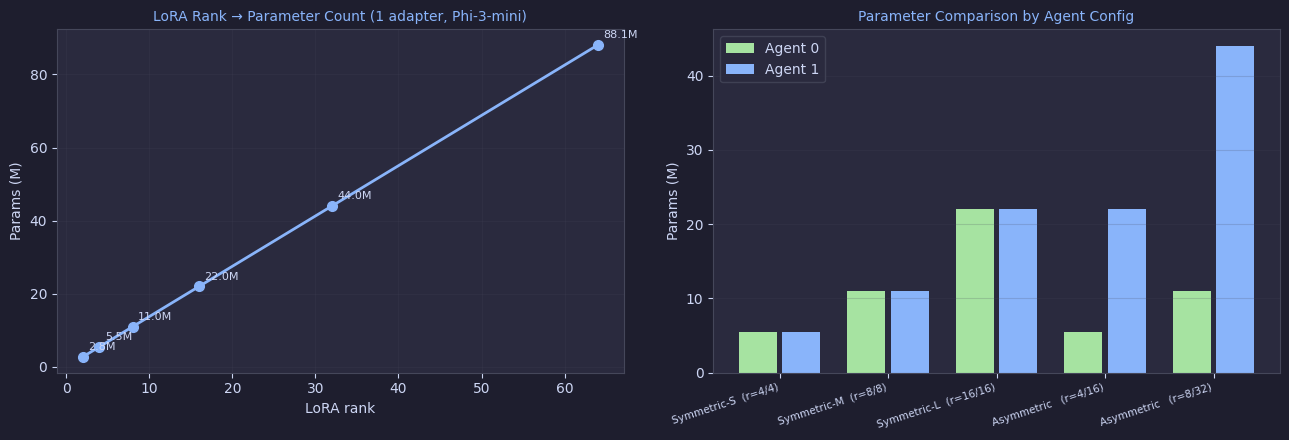


How to use asymmetric config with ModelManager (requires GPU):

peft_config_agent0 = LoraConfig(r=4,  lora_alpha=8,  ...)
peft_config_agent1 = LoraConfig(r=16, lora_alpha=32, ...)

# Pass a list to ModelManager for per-agent peft_config:
model_manager = ModelManager(
    agent_num=2,
    base_model=BASE_MODEL,
    peft_config=[peft_config_agent0, peft_config_agent1],  # list
    collaboration_separation=True,
    ...
)
# Agent 0: fewer params → faster convergence, less expressive collaboration
# Agent 1: more params  → more expressive collaboration, more memory



In [77]:
# ── Experiment: asymmetric LoRA rank (per-agent parameter size) ───────────────
# In MAPoRL, agents do not need identical capacity.
# Here Agent 0 uses a lower rank (weaker) and Agent 1 uses a higher rank (stronger).
# We check whether asymmetric capacity affects collaborative debate performance.
#
# Implementation: utils/utils_model.py:ModelManager
#   → accepts List[LoraConfig] for per-agent peft_config

from peft import LoraConfig
import numpy as np
import matplotlib.pyplot as plt

def count_lora_params(r: int, hidden: int = 3072,
                      n_modules: int = 7, n_layers: int = 32) -> int:
    """Trainable parameters for one LoRA adapter."""
    return 2 * r * hidden * n_modules * n_layers

BASE_MODEL = "microsoft/Phi-3-mini-128k-instruct"
HIDDEN = 3072   # Phi-3-mini hidden size

configs = {
    "Symmetric-S  (r=4/4)"  : (4,  4),
    "Symmetric-M  (r=8/8)"  : (8,  8),
    "Symmetric-L  (r=16/16)": (16, 16),
    "Asymmetric   (r=4/16)" : (4,  16),
    "Asymmetric   (r=8/32)" : (8,  32),
}

print(f"{'Config':<26} {'Agent0 params':>14} {'Agent1 params':>14} {'Ratio':>7}")
print("-" * 65)
rows = []
for name, (r0, r1) in configs.items():
    p0 = count_lora_params(r0, HIDDEN)
    p1 = count_lora_params(r1, HIDDEN)
    ratio = p1 / p0
    print(f"  {name:<24} {p0/1e6:>12.1f}M {p1/1e6:>12.1f}M {ratio:>6.1f}x")
    rows.append((name, p0/1e6, p1/1e6))

# ── LoRA rank vs parameter count chart ───────────────────────────────────────
ranks = [2, 4, 8, 16, 32, 64]
params = [count_lora_params(r, HIDDEN) / 1e6 for r in ranks]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor="#1E1E2E")

ax1 = axes[0]
ax1.set_facecolor("#2A2A3E")
ax1.plot(ranks, params, color="#89B4FA", marker="o", lw=2, ms=7)
for r, p in zip(ranks, params):
    ax1.annotate(f"{p:.1f}M", (r, p), textcoords="offset points",
                 xytext=(4, 5), color="#CDD6F4", fontsize=8)
ax1.set_title("LoRA Rank → Parameter Count (1 adapter, Phi-3-mini)",
              color="#89B4FA", fontsize=10)
ax1.set_xlabel("LoRA rank", color="#CDD6F4")
ax1.set_ylabel("Params (M)", color="#CDD6F4")
ax1.tick_params(colors="#CDD6F4")
for sp in ax1.spines.values(): sp.set_color("#45475A")
ax1.grid(alpha=0.2, color="#45475A")

ax2 = axes[1]
ax2.set_facecolor("#2A2A3E")
labels = [r[0] for r in rows]
p0s    = [r[1] for r in rows]
p1s    = [r[2] for r in rows]
x = np.arange(len(labels))
b1 = ax2.bar(x - 0.2, p0s, 0.35, label="Agent 0", color="#A6E3A1")
b2 = ax2.bar(x + 0.2, p1s, 0.35, label="Agent 1", color="#89B4FA")
ax2.set_title("Parameter Comparison by Agent Config", color="#89B4FA", fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=18, ha="right", fontsize=7.5, color="#CDD6F4")
ax2.set_ylabel("Params (M)", color="#CDD6F4")
ax2.tick_params(colors="#CDD6F4")
for sp in ax2.spines.values(): sp.set_color("#45475A")
ax2.legend(labelcolor="#CDD6F4", facecolor="#2A2A3E", edgecolor="#45475A")
ax2.grid(axis="y", alpha=0.2, color="#45475A")
plt.tight_layout()
plt.show()

# ── How to apply asymmetric config to ModelManager ───────────────────────────
print("\nHow to use asymmetric config with ModelManager (requires GPU):")
print("""
peft_config_agent0 = LoraConfig(r=4,  lora_alpha=8,  ...)
peft_config_agent1 = LoraConfig(r=16, lora_alpha=32, ...)

# Pass a list to ModelManager for per-agent peft_config:
model_manager = ModelManager(
    agent_num=2,
    base_model=BASE_MODEL,
    peft_config=[peft_config_agent0, peft_config_agent1],  # list
    collaboration_separation=True,
    ...
)
# Agent 0: fewer params → faster convergence, less expressive collaboration
# Agent 1: more params  → more expressive collaboration, more memory
""")


<a id='6'></a>

---
## 6. Reward System

Reward computation flow:
```
For each (turn, agent) response:
  → Base reward  : verifier score or label match (0 or 1)
  → bonus_rule(α): debate behavior evaluation (persuasion, revision, contribution)
  → score_rule(γ): horizon discounting → final training signal
```


In [78]:
import re

# extract_ans_from_response: extract numeric value from \boxed{}
# Source: utils/utils_cooperateLLM.py:221-233
def extract_ans_from_response(answer: str):
    answer = answer.strip()
    matches = re.compile(r'\\boxed\{(.*?)\}').findall(answer)
    if matches:
        answer = matches[-1].strip()
    answer = re.sub(r'[^0-9\-\.]', '', answer)
    try:
        return int(answer)
    except ValueError:
        return "invalid"

for resp in [
    "Step 1: ... Therefore \\boxed{42}.",
    "The answer is \\boxed{100}.",
    "I'm not sure.",
]:
    print(f"  '{resp[:50]}' → {extract_ans_from_response(resp)}")


  'Step 1: ... Therefore \boxed{42}.' → 42
  'The answer is \boxed{100}.' → 100
  'I'm not sure.' → invalid


In [79]:
import numpy as np

# bonus_rule core logic summary
# Source: trl/trl/trainer/utils_multi_unified.py:1612-1712
#
# apply_incentive(scores_list, turn, agent, alpha) conditions:
#
# Turn > 0 (after first response):
#   prev_score > 0.5 (was correct) AND curr_score < 0.5 (now wrong):
#     others correct → -α₁  (should have resisted, got misled)
#     others wrong   → -α₀  (self-changed to wrong direction)
#   prev_score < 0.5 (was wrong) AND curr_score > 0.5 (now correct):
#     others wrong   → +α₁  (self-correction)
#     others correct → +α₀  (persuaded by correct agent)
#
# Turn < total_rounds-1 (next round exists):
#   next_others > 0.5 AND curr_others < 0.5 → other agents improved
#     curr correct → -α₃ / curr wrong → -α₂ (failed to contribute)
#   next_others < 0.5 AND curr_others > 0.5 → other agents got worse
#     curr wrong → +α₃ / curr correct → +α₂ (gave correct guidance)

alpha = [0.5, 0.5, 0.3, 0.3]

scenarios = [
    ("Right→Wrong (others right)",  +1, -1, +1, -alpha[1]),
    ("Right→Wrong (others wrong)",  +1, -1, -1, -alpha[0]),
    ("Wrong→Right (others right)",  -1, +1, +1, +alpha[0]),
    ("Wrong→Right (others wrong)",  -1, +1, -1, +alpha[1]),
    ("No change",                   +1, +1,  0,       0.0),
]
print(f"{'Scenario':<28} {'prev':>5} {'curr':>5} {'others':>7} {'bonus':>7}")
print("-" * 55)
for name, prev, curr, others, bonus in scenarios:
    p = "✓" if prev>0 else "✗"
    c = "✓" if curr>0 else "✗"
    o = "✓" if others>0 else ("—" if others==0 else "✗")
    print(f"  {name:<26} {p:>5} {c:>5} {o:>7} {bonus:>+7.2f}")


Scenario                      prev  curr  others   bonus
-------------------------------------------------------
  Right→Wrong (others right)     ✓     ✗       ✓   -0.50
  Right→Wrong (others wrong)     ✓     ✗       ✗   -0.50
  Wrong→Right (others right)     ✗     ✓       ✓   +0.50
  Wrong→Right (others wrong)     ✗     ✓       ✗   +0.50
  No change                      ✓     ✓       —   +0.00


In [80]:
import matplotlib.pyplot as plt

# score_rule: discounted_sum visualization
# Source: trl/trl/trainer/utils_multi_unified.py:1715-
gamma = 0.3   # rule_discount (from config)
rounds = 3

base_rewards = {
    "Correct from start": [1.0, 1.0, 1.0],
    "Improved via debate": [0.0, 0.0, 1.0],
    "Confused mid-debate": [1.0, 0.0, 1.0],
    "Wrong throughout":    [0.0, 0.0, 0.0],
}

print(f"gamma = {gamma}")
print(f"{'Scenario':<22}", *[f"r={r}" for r in range(rounds)], "  last   discounted")
print("-" * 60)
for name, rews in base_rewards.items():
    ds = sum(rews[t] * gamma**(rounds-1-t) for t in range(rounds))
    print(f"{name:<22}", *[f"  {r:.1f}" for r in rews],
          f"  {rews[-1]:.3f}   {ds:.3f}")


gamma = 0.3
Scenario               r=0 r=1 r=2   last   discounted
------------------------------------------------------------
Correct from start       1.0   1.0   1.0   1.000   1.390
Improved via debate      0.0   0.0   1.0   1.000   1.000
Confused mid-debate      1.0   0.0   1.0   1.000   1.090
Wrong throughout         0.0   0.0   0.0   0.000   0.000


<a id='7'></a>

---
## 7. Multi-Agent Communication Protocol

```
Round 0: [user] {question} → [assistant] first response
Round k: [user] {question} → [assistant] previous response
          [user] other agents' responses + question re-prompt
          → [assistant] revised response
```


In [81]:
def construct_message_multi_agent(agent_contexts_other, question, turn,
                                   reward_feedback=False):
    if not agent_contexts_other:
        return {"role": "user",
                "content": (f"Can you double check that your answer is correct. "
                            f"Please reiterate your answer.\n\nThe original question:\n{question}")}
    prefix = "These are the solutions to the problem from other agents: "
    for ctx in agent_contexts_other:
        last = next((m["content"] for m in reversed(ctx) if m["role"] == "assistant"), "")
        prefix += f"\n\nOne agent solution: ```{last}```"
    prefix += (f"\n\nUsing the solutions from other agents as additional information, "
               f"can you provide your answer to this question?"
               f"\n\nThe original question:\n{question}\n"
               f"You should not copy other agents' answer, but use their information.")
    return {"role": "user", "content": prefix}

question = "Janet's ducks lay 16 eggs/day. She eats 3 and bakes 4. Sells rest at $2/egg. Daily earnings?"
agent1_ctx = [{"role":"user","content":question},
              {"role":"assistant","content":"16-7=8 eggs. 8×$2=\\boxed{16}."}]
msg = construct_message_multi_agent([agent1_ctx], question, turn=1)
preview = msg["content"][:120].replace("\n", " ")
print(f"[Round 1 message] {preview}...")


[Round 1 message] These are the solutions to the problem from other agents:   One agent solution: ```16-7=8 eggs. 8×$2=\boxed{16}.```  Usi...


In [82]:
def show_dialog(question, rounds_data, ground_truth):
    W = 68
    print("─" * W)
    print(f"Q: {question[:W-3]}...")
    print(f"   Ground truth: {ground_truth}")
    print("─" * W)
    for r, rd in enumerate(rounds_data):
        print(f"  Round {r}")
        for agent_id, resp in rd.items():
            ans = extract_ans_from_response(resp)
            ok  = "✓" if ans == ground_truth else "✗"
            print(f"    [{agent_id}] {resp[:60]}{'...' if len(resp)>60 else ''}")
            print(f"           → extracted: {ans}  {ok}")
    print("─" * W)

show_dialog(
    question="Janet's ducks lay 16 eggs/day. Eats 3, bakes 4, sells rest at $2/egg.",
    ground_truth=18,
    rounds_data=[
        {"Agent 0": "16-3-4=9. 9×2=\\boxed{18}.",
         "Agent 1": "16-7=8 eggs. 8×2=\\boxed{16}."},
        {"Agent 0": "Still 9 eggs. \\boxed{18}.",
         "Agent 1": "Correcting: 16-3=13, 13-4=9, 9×2=\\boxed{18}."}
    ]
)


────────────────────────────────────────────────────────────────────
Q: Janet's ducks lay 16 eggs/day. Eats 3, bakes 4, sells rest at $2/...
   Ground truth: 18
────────────────────────────────────────────────────────────────────
  Round 0
    [Agent 0] 16-3-4=9. 9×2=\boxed{18}.
           → extracted: 18  ✓
    [Agent 1] 16-7=8 eggs. 8×2=\boxed{16}.
           → extracted: 16  ✗
  Round 1
    [Agent 0] Still 9 eggs. \boxed{18}.
           → extracted: 18  ✓
    [Agent 1] Correcting: 16-3=13, 13-4=9, 9×2=\boxed{18}.
           → extracted: 18  ✓
────────────────────────────────────────────────────────────────────


<a id='8'></a>
---
## 8. PPO Rollout Phase

The rollout phase generates trajectories **without gradients** to produce training signals.  
For each batch, the following sequence is executed:

```
for turn in range(round_num):
    switch adapter (turn=0: "policy", turn≥1: "col")
    for agent in range(agent_num):
        construct queries (apply chat_template)
        generate() → query_response, logits
        compute ref logprob (for KL penalty)
        estimate value (get_reward())
        postprocess responses (truncate, add \boxed{})
        extract answer → compute base reward
        append assistant message to context
```

Source: `trl/trl/trainer/ppov2_trainer_multi_different_model.py:754-1527`


In [83]:
def rollout_phase_pseudocode(models, tokenizers, data, agent_num, round_num,
                              collaboration_separation, policy_separation,
                              generation_config, device):
    """MAPoRL Rollout Phase structure (educational pseudocode, not executable)."""
    pass

print("Rollout Phase  adapter schedule:")
for turn in range(3):
    adapter = "policy" if turn == 0 else "col"
    note    = "← Turn-0: domain knowledge" if turn == 0 else "← Turn-1+: collaboration strategy"
    print(f"  Turn {turn}  →  adapter='{adapter}'  {note}")


Rollout Phase  adapter schedule:
  Turn 0  →  adapter='policy'  ← Turn-0: domain knowledge
  Turn 1  →  adapter='col'  ← Turn-1+: collaboration strategy
  Turn 2  →  adapter='col'  ← Turn-1+: collaboration strategy


In [84]:
# Postprocess responses: truncate + force \boxed{} insertion
# Source: trl/trl/trainer/ppov2_trainer_multi_different_model.py:1066-1210

def postprocess_response(decoded_response: str, answer) -> str:
    """
    Append \boxed{answer} to the response if not already present.
    Required because extract_ans_from_response() looks for \boxed{}.
    """
    if answer == "invalid":
        return decoded_response

    final_ans_str = f"Answer: \\boxed{{{answer}}}"
    check_tail = decoded_response[-int(1.5 * len(final_ans_str)):]
    if final_ans_str not in check_tail:
        return decoded_response + " " + final_ans_str
    return decoded_response


# Penalty conditions: too short, repetition pattern, or missing \boxed{} → apply penalty
# Source: trl/trl/trainer/ppov2_trainer_multi_different_model.py:1466-1503
def apply_penalty(scores, postprocessed_responses, sequence_lengths,
                  min_length, penalty_value, non_eos_penalty, non_box_penalty,
                  tokenizer, turn):
    """
    Apply penalty_value when any of three conditions hold (OR logic):
    1. sufficient_length: response shorter than min_output_length
    2. no_invalid_repetitions: repetitive subsequence detected
    3. contain_box_sequence: \boxed{} pattern missing
    """
    import re
    box_pattern = re.compile(r"\\boxed{.*?}")
    contain_box = torch.tensor(
        [bool(box_pattern.search(tokenizer.decode(r.tolist())))
         for r in postprocessed_responses]
    )
    sufficient = sequence_lengths >= min_length

    penalty_cond = sufficient
    if non_box_penalty and turn > 0:
        penalty_cond = penalty_cond & contain_box

    penalty = torch.full_like(scores, penalty_value)
    return torch.where(penalty_cond, scores, penalty)


print("Penalty conditions summary:")
print("  sufficient_length   : generation length >= min_output_length (50 tokens)")
print("  no_invalid_reps     : no subsequence repeated 3+ times")
print("  contain_box         : \\boxed{} pattern present (required for turn>=1)")
print("  penalty value       : -10 (from config)")


Penalty conditions summary:
  sufficient_length   : generation length >= min_output_length (50 tokens)
  no_invalid_reps     : no subsequence repeated 3+ times
  contain_box         : \boxed{} pattern present (required for turn>=1)
  penalty value       : -10 (from config)


<a id='9'></a>
---
## 9. PPO Update Phase — GAE + Loss

After rollout, **compute gradients and update LoRA adapters**.  
Source: `trl/trl/trainer/ppov2_trainer_multi_different_model.py:1600-1870`

```
1. score_rule + bonus_rule → final reward
2. KL penalty: reward_t -= kl_coef × (log π - log π_ref)
3. GAE: advantages[t] = δ_t + γλ × advantages[t+1]
4. PPO clip loss:  L_pg = -min(r·A, clip(r,1-ε,1+ε)·A)
5. Value clip loss: L_vf = max((V-R)², (clip(V,V_old±ε)-R)²)
6. Total loss: L = L_pg + vf_coef × L_vf
7. accelerator.backward(loss)
8. AdamW step (LoRA parameters only)
```


In [85]:
# GAE (Generalized Advantage Estimation)
# Source: trl/trl/trainer/ppov2_trainer_multi_different_model.py:1647-1704

def compute_gae(rewards, values, padding_mask, gamma=1.0, lam=0.95):
    """
    Compute advantage and return estimates via GAE.

    Args:
        rewards      : (B, T) — sequence with KL penalty + final sparse reward
        values       : (B, T) — value head predictions
        padding_mask : (B, T) — True at padding positions
        gamma        : future reward discount (typically 1.0)
        lam          : GAE lambda (typically 0.95)

    Returns:
        advantages : (B, T) — whitened, 0 at padding positions
        returns    : (B, T) — advantages + values
    """
    gen_length      = rewards.shape[1]
    lastgaelam      = 0
    advantages_rev  = []

    for t in reversed(range(gen_length)):
        nextvalues = values[:, t+1] if t < gen_length-1 else torch.zeros_like(values[:, 0])
        delta      = rewards[:, t] + gamma * nextvalues - values[:, t]
        lastgaelam = delta + gamma * lam * lastgaelam
        advantages_rev.append(lastgaelam)

    advantages = torch.stack(advantages_rev[::-1], dim=1)
    returns    = advantages + values

    # Whiten advantages for training stability
    mean = advantages[~padding_mask].mean()
    std  = advantages[~padding_mask].std() + 1e-8
    advantages = (advantages - mean) / std
    advantages = advantages.masked_fill(padding_mask, 0)

    return advantages, returns


B, T = 2, 10
dummy_rewards = torch.zeros(B, T)
dummy_rewards[:, -1] = torch.tensor([1.0, 0.0])   # sparse reward at last token
dummy_values  = torch.rand(B, T) * 0.5
dummy_mask    = torch.zeros(B, T, dtype=torch.bool)

adv, ret = compute_gae(dummy_rewards, dummy_values, dummy_mask)
print(f"advantages shape: {adv.shape}")
print(f"returns    shape: {ret.shape}")
print(f"advantage mean  : {adv.mean():.4f}  (≈0 after whitening)")


advantages shape: torch.Size([2, 10])
returns    shape: torch.Size([2, 10])
advantage mean  : 0.0000  (≈0 after whitening)


In [86]:
# PPO Loss
# Source: trl/trl/trainer/ppov2_trainer_multi_different_model.py:1810-1860

def ppo_loss(
    new_logprobs, old_logprobs,
    advantages,
    new_vpred, old_vpred, returns,
    padding_mask,
    clip_eps=0.2, vf_coef=0.1
):
    """
    Compute PPO-Clip loss.

    Policy loss:
        ratio = exp(new_logprob - old_logprob)   ← importance weight
        L_pg  = -min(ratio·A, clip(ratio, 1-ε, 1+ε)·A)

    Value loss (clipped):
        vpred_clipped = clip(new_V, old_V-ε, old_V+ε)
        L_vf = max((new_V - R)², (clipped_V - R)²)

    Total: L = mean(L_pg) + vf_coef × mean(L_vf)
    """
    log_ratio   = new_logprobs - old_logprobs
    ratio       = torch.exp(log_ratio)
    pg_loss1    = -advantages * ratio
    pg_loss2    = -advantages * torch.clamp(ratio, 1-clip_eps, 1+clip_eps)
    pg_loss     = torch.max(pg_loss1, pg_loss2)
    pg_loss     = pg_loss.masked_fill(padding_mask, 0).mean()

    vpred_clipped = old_vpred + torch.clamp(new_vpred - old_vpred, -clip_eps, clip_eps)
    vf_loss1      = (new_vpred   - returns) ** 2
    vf_loss2      = (vpred_clipped - returns) ** 2
    vf_loss       = 0.5 * torch.max(vf_loss1, vf_loss2)
    vf_loss       = vf_loss.masked_fill(padding_mask, 0).mean()

    approx_kl = 0.5 * (log_ratio ** 2).mean()

    total_loss = pg_loss + vf_coef * vf_loss
    return total_loss, {"pg_loss": pg_loss.item(),
                        "vf_loss": vf_loss.item(),
                        "approx_kl": approx_kl.item()}


B, T = 2, 10
mask = torch.zeros(B, T, dtype=torch.bool)
loss, metrics = ppo_loss(
    new_logprobs = torch.randn(B, T) * 0.1,
    old_logprobs = torch.randn(B, T) * 0.1,
    advantages   = torch.randn(B, T),
    new_vpred    = torch.rand(B, T),
    old_vpred    = torch.rand(B, T),
    returns      = torch.rand(B, T),
    padding_mask = mask,
)
print(f"Total loss : {loss:.4f}")
print(f"  pg_loss  : {metrics['pg_loss']:.4f}")
print(f"  vf_loss  : {metrics['vf_loss']:.4f}")
print(f"  approx_kl: {metrics['approx_kl']:.4f}")


Total loss : 0.0085
  pg_loss  : -0.0034
  vf_loss  : 0.1191
  approx_kl: 0.0119


In [87]:
# Full Update Phase flow summary (for structural understanding)
# Source: trl/trl/trainer/ppov2_trainer_multi_different_model.py:1600-1870

def update_phase_pseudocode():
    """Not executable (requires GPU + full model). Illustrates structure only."""
    # 1. Combine score_rule + bonus_rule → final reward
    # for turn, agent:
    #     scores  = score_rule(rule_horizon, rule_agent_share, gamma, ...)
    #     bonuses = bonus_rule(correctnesses, ..., alpha)
    #     scores_turn_agent[(turn,agent)] = (scores + bonuses)[scores != -1]

    # 2. KL penalty (token-level)
    # kl = logprobs - ref_logprobs
    # non_score_reward = -kl_coef * kl
    # rewards = non_score_reward.clone()
    # rewards[batch, sequence_end] += final_scores   ← sparse reward at last token

    # 3. GAE
    # advantages, returns = compute_gae(rewards, values, padding_mask)

    # 4. PPO epochs (num_ppo_epochs=4)
    # for epoch in range(num_ppo_epochs):
    #     b_inds = shuffle(batch_size)
    #     for mini_batch in split(b_inds, mini_batch_size):
    #         for turn, agent:
    #             grad_requires_setting(model, task_training, ...)  ← enable grad for active adapter only
    #             output = forward(model.policy, ref=False, turn, query_responses, ...)
    #             new_logprobs = gather(log_softmax(output.logits), responses)
    #             new_vpred    = get_reward(model, ref=False, turn, ...)
    #             loss, metrics = ppo_loss(new_logprobs, old_logprobs, advantages, ...)
    #             accelerator.backward(loss)
    #         optimizer.step()
    #         optimizer.zero_grad()
    pass

print("Update Phase flow:")
steps = [
    "1. score_rule + bonus_rule → final reward",
    "2. KL penalty (token-level, sparse reward added at last token)",
    "3. GAE: compute advantage & return",
    "4. PPO epoch × mini-batch loop",
    "   - grad_requires_setting: enable gradient for active adapter only",
    "   - forward(): recompute policy logprob",
    "   - get_reward(): recompute value head",
    "   - ppo_loss(): pg_loss + vf_coef × vf_loss",
    "   - accelerator.backward() + optimizer.step()",
]
for s in steps:
    print(f"  {s}")


Update Phase flow:
  1. score_rule + bonus_rule → final reward
  2. KL penalty (token-level, sparse reward added at last token)
  3. GAE: compute advantage & return
  4. PPO epoch × mini-batch loop
     - grad_requires_setting: enable gradient for active adapter only
     - forward(): recompute policy logprob
     - get_reward(): recompute value head
     - ppo_loss(): pg_loss + vf_coef × vf_loss
     - accelerator.backward() + optimizer.step()


<a id='10'></a>
---
## 10. Training Configuration & Execution

Set training hyperparameters and launch multi-GPU training.


In [88]:
CONFIG = {
    "base_model"              : "microsoft/Phi-3-mini-128k-instruct",
    "agent_num"               : 2,
    "round_num"               : 3,
    "collaboration_separation": True,
    "dataset_name"            : "GSM8k",
    "max_output_length"       : 300,
    "vf_coef"                 : 0.1,
    "kl_coef"                 : 0.002,
    "num_ppo_epochs"          : 4,
    "learning_rate"           : 1e-5,
    "rule_horizon"            : "discounted_sum",
    "rule_discount"           : 0.3,
    "penalty_reward_value"    : -10,
    "output_dir"              : "training_gsm8k_2agent_3round",
}
ALPHA = [0.5, 0.5, 0.3, 0.3]

groups = {
    "Model/Agent": ["base_model","agent_num","round_num","collaboration_separation"],
    "Data/Gen"   : ["dataset_name","max_output_length"],
    "PPO"        : ["vf_coef","kl_coef","num_ppo_epochs","learning_rate"],
    "Reward"     : ["rule_horizon","rule_discount","penalty_reward_value"],
}
for grp, keys in groups.items():
    vals = "  |  ".join(f"{k}={CONFIG[k]}" for k in keys)
    print(f"[{grp}]  {vals}")
print(f"[Alpha]  α={ALPHA}")


[Model/Agent]  base_model=microsoft/Phi-3-mini-128k-instruct  |  agent_num=2  |  round_num=3  |  collaboration_separation=True
[Data/Gen]  dataset_name=GSM8k  |  max_output_length=300
[PPO]  vf_coef=0.1  |  kl_coef=0.002  |  num_ppo_epochs=4  |  learning_rate=1e-05
[Reward]  rule_horizon=discounted_sum  |  rule_discount=0.3  |  penalty_reward_value=-10
[Alpha]  α=[0.5, 0.5, 0.3, 0.3]


In [89]:
config_path = "config/ppo_config/config_ppo2_multi_agent2_turn3_gsm8k_reloadF.py"
train_cmd = (
    f"accelerate launch \\\n"
    f"    --config_file config/deepspeed_config/ds_config_zero2.yaml \\\n"
    f"    --num_processes 6 \\\n"
    f"    train_ppo_v2_multi_agent_multi_model.py \\\n"
    f"    --config {config_path} \\\n"
    f"    --alpha '[0.5, 0.5, 0.3, 0.3]'"
)
print("[New training]")
print(train_cmd)
print()
print("[Resume]  add  --reload  to the command above")


[New training]
accelerate launch \
    --config_file config/deepspeed_config/ds_config_zero2.yaml \
    --num_processes 6 \
    train_ppo_v2_multi_agent_multi_model.py \
    --config config/ppo_config/config_ppo2_multi_agent2_turn3_gsm8k_reloadF.py \
    --alpha '[0.5, 0.5, 0.3, 0.3]'

[Resume]  add  --reload  to the command above


In [90]:
# save_model: checkpoint directory structure
# Source: trl/trl/trainer/ppov2_trainer_multi_different_model.py:604-708
#
# Directory layout:
# output_dir/
#   {update}/
#     adapter_model.safetensors  ← policy LoRA adapter weights
#     value_head_value_heads_0/
#       model.safetensors        ← value head 0 Linear weights
#     value_head_value_heads_1/
#       model.safetensors        ← value head 1 Linear weights
#     checkpoint/
#       checkpoint_update_{update}.pt  ← optimizer + scheduler state

print("Checkpoint directory structure (example: update=100):")
structure = """
training_gsm8k_2agent_3round_alpha_[0.5, 0.5, 0.3, 0.3]/
  100/
    adapter_config.json
    adapter_model.safetensors     ← policy/col LoRA
    value_head_value_heads_0/
      model.safetensors           ← Turn-0 value head
    value_head_value_heads_1/
      model.safetensors           ← Turn-1 value head
    checkpoint/
      checkpoint_update_100.pt    ← optimizer + trial number
"""
print(structure)


Checkpoint directory structure (example: update=100):

training_gsm8k_2agent_3round_alpha_[0.5, 0.5, 0.3, 0.3]/
  100/
    adapter_config.json
    adapter_model.safetensors     ← policy/col LoRA
    value_head_value_heads_0/
      model.safetensors           ← Turn-0 value head
    value_head_value_heads_1/
      model.safetensors           ← Turn-1 value head
    checkpoint/
      checkpoint_update_100.pt    ← optimizer + trial number



<a id='10_5'></a>
---
## 10.5 Live Training Dashboard

Monitor the current training phase, agent responses, rewards, and accuracy  
in a **fixed panel** inside the notebook during training/inference.

Create a `MAPoRLDashboard` instance once; then call  
`dash.set_phase(...)`, `dash.log_agent_answer(...)`, `dash.refresh()`  
inside the Rollout/Update loop.

> Run the **simulation cell** below to see the dashboard in action without a GPU.


In [91]:
import time
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# MAPoRLDashboard
# ─────────────────────────────────────────────────────────────────────────────
# Usage inside training loop:
#
#   dash = MAPoRLDashboard(agent_num=2, round_num=3)
#
#   for step, batch in enumerate(dataloader):
#       for turn in range(round_num):
#           for agent in range(agent_num):
#               dash.set_phase("Rollout", turn=turn, agent=agent, step=step)
#               # ... generate() ...
#               dash.log_agent_answer(turn, agent, q_idx, question, answer, correct, response)
#               dash.set_rewards(turn, agent, base, bonus, final)
#               dash.refresh()
#
#       dash.set_phase("Update", step=step)
#       dash.log_loss(pg, vf, kl)
#       dash.log_accuracy([acc_r0, acc_r1, acc_r2])
#       dash.refresh()
# ─────────────────────────────────────────────────────────────────────────────

class MAPoRLDashboard:
    """Real-time MAPoRL training dashboard using ipywidgets fixed Output panel."""

    # ── Color palette (Catppuccin Mocha) ────────────────────────────────────
    _C = dict(
        bg="#1E1E2E", panel="#2A2A3E", border="#45475A",
        text="#CDD6F4", accent="#89B4FA",
        green="#A6E3A1", red="#F38BA8", yellow="#F9E2AF",
        mauve="#CBA6F7", peach="#FAB387", teal="#94E2D5",
    )

    def __init__(self, agent_num: int = 2, round_num: int = 3):
        self.agent_num = agent_num
        self.round_num = round_num

        # ── State ────────────────────────────────────────────────────────────
        self.phase          = "Initializing"
        self.global_step    = 0
        self.current_turn   = 0
        self.current_agent  = 0
        self.start_time     = time.time()

        self.loss_history   = []   # [(step, pg, vf, kl), ...]
        self.acc_history    = []   # [(step, [acc_r0, ...]), ...]
        self.reward_grid    = {}   # (turn, agent) -> (base, bonus, final)

        # (turn, agent, q_idx) -> {question, answer, correct, response}
        self.current_answers   = {}
        self.current_questions = []

        # ── Output widget: fixed panel in notebook ───────────────────────────
        self.out = widgets.Output()
        display(self.out)

    # ── Public API ───────────────────────────────────────────────────────────

    def set_phase(self, phase: str, turn: int = 0, agent: int = 0,
                  step: int = None):
        self.phase         = phase
        self.current_turn  = turn
        self.current_agent = agent
        if step is not None:
            self.global_step = step

    def log_agent_answer(self, turn: int, agent: int, q_idx: int,
                         question: str, answer, correct: bool,
                         response: str = ""):
        self.current_answers[(turn, agent, q_idx)] = {
            "question" : question,
            "answer"   : answer,
            "correct"  : correct,
            "response" : (response[:90] + "…") if len(response) > 90 else response,
        }
        while len(self.current_questions) <= q_idx:
            self.current_questions.append("")
        self.current_questions[q_idx] = question

    def set_rewards(self, turn: int, agent: int,
                    base: float, bonus: float, final: float):
        self.reward_grid[(turn, agent)] = (base, bonus, final)

    def log_loss(self, pg: float, vf: float, kl: float):
        self.loss_history.append((self.global_step, pg, vf, kl))
        if len(self.loss_history) > 120:
            self.loss_history = self.loss_history[-120:]

    def log_accuracy(self, accs):
        self.acc_history.append((self.global_step, list(accs)))
        if len(self.acc_history) > 200:
            self.acc_history = self.acc_history[-200:]

    def new_batch(self):
        """Reset answer grid for a new batch."""
        self.current_answers   = {}
        self.current_questions = []

    def refresh(self):
        """Redraw dashboard in the fixed panel."""
        with self.out:
            clear_output(wait=True)
            self._render()

    # ── Internal rendering ───────────────────────────────────────────────────

    def _elapsed(self) -> str:
        e = int(time.time() - self.start_time)
        return f"{e//3600:02d}:{(e%3600)//60:02d}:{e%60:02d}"

    def _phase_bar(self) -> str:
        stages = ["Initializing", "Rollout", "Update", "Evaluation", "Done"]
        icons  = ["○", "▶", "▲", "◆", "✓"]
        parts  = []
        for s, icon in zip(stages, icons):
            if s == self.phase:
                parts.append(f"[{icon} {s}]")
            else:
                parts.append(f"  {s}  ")
        return "  →  ".join(parts)

    def _render(self):
        C  = self._C
        rn = self.round_num
        an = self.agent_num

        fig = plt.figure(figsize=(17, 9), facecolor=C["bg"])
        gs  = gridspec.GridSpec(
            3, 3, figure=fig,
            hspace=0.55, wspace=0.35,
            left=0.04, right=0.98, top=0.87, bottom=0.05,
        )

        # ── Header ───────────────────────────────────────────────────────────
        fig.text(0.01, 0.96, "MAPoRL  Live Dashboard",
                 color=C["accent"], fontsize=15, fontweight="bold", va="top")
        fig.text(0.01, 0.925,
                 f"Step {self.global_step}  |  Turn {self.current_turn}/{rn-1}"
                 f"  |  Agent {self.current_agent}/{an-1}"
                 f"  |  Elapsed {self._elapsed()}",
                 color=C["text"], fontsize=10, va="top")
        fig.text(0.01, 0.896, self._phase_bar(),
                 color=C["yellow"], fontsize=9, va="top", family="monospace")

        def _style(ax, title=""):
            ax.set_facecolor(C["panel"])
            for sp in ax.spines.values():
                sp.set_color(C["border"])
            ax.tick_params(colors=C["text"], labelsize=8)
            ax.xaxis.label.set_color(C["text"])
            ax.yaxis.label.set_color(C["text"])
            if title:
                ax.set_title(title, color=C["accent"], fontsize=10,
                             fontweight="bold", pad=5)

        # ── Accuracy history (0,0:2) ─────────────────────────────────────────
        ax_acc = fig.add_subplot(gs[0, :2])
        _style(ax_acc, "Round Accuracy over Training Steps")
        r_colors = [C["green"], C["accent"], C["yellow"]]
        if self.acc_history:
            steps = [h[0] for h in self.acc_history]
            for r in range(rn):
                vals = [h[1][r] for h in self.acc_history if r < len(h[1])]
                ax_acc.plot(steps[:len(vals)], vals,
                            color=r_colors[r], lw=2, marker="o", ms=3,
                            label=f"Round {r}")
            ax_acc.set_ylim(0, 1.05)
            ax_acc.axhline(0.5, color=C["border"], ls="--", lw=0.8)
            ax_acc.set_xlabel("Step", color=C["text"])
            ax_acc.legend(fontsize=8, labelcolor=C["text"],
                          facecolor=C["panel"], edgecolor=C["border"])
        else:
            ax_acc.text(0.5, 0.5, "Waiting for training data…",
                        ha="center", va="center", color=C["border"],
                        fontsize=12, transform=ax_acc.transAxes)

        # ── Loss history (0,2) ───────────────────────────────────────────────
        ax_loss = fig.add_subplot(gs[0, 2])
        _style(ax_loss, "Loss")
        if self.loss_history:
            steps = [h[0] for h in self.loss_history]
            ax_loss.plot(steps, [h[1] for h in self.loss_history],
                         color=C["accent"], lw=1.5, label="pg_loss")
            ax_loss.plot(steps, [h[2] for h in self.loss_history],
                         color=C["yellow"], lw=1.5, label="vf_loss")
            ax_loss.set_xlabel("Step", color=C["text"])
            ax_loss.legend(fontsize=8, labelcolor=C["text"],
                           facecolor=C["panel"], edgecolor=C["border"])
        else:
            ax_loss.text(0.5, 0.5, "Waiting…",
                         ha="center", va="center", color=C["border"],
                         fontsize=11, transform=ax_loss.transAxes)

        # ── Reward grid (1, all) ─────────────────────────────────────────────
        ax_rew = fig.add_subplot(gs[1, :])
        _style(ax_rew, "Reward Grid  (Turn × Agent)")
        ax_rew.axis("off")

        headers = ["Turn", "Agent", "Base Reward", "Bonus (α)", "Final Reward", "Correct?"]
        col_xs  = [0.01,  0.09,   0.18,          0.36,        0.54,           0.72]

        for hdr, cx in zip(headers, col_xs):
            ax_rew.text(cx, 0.92, hdr, transform=ax_rew.transAxes,
                        color=C["accent"], fontsize=9, fontweight="bold", va="top")

        row_y = 0.76
        for turn in range(rn):
            for agent in range(an):
                data = self.reward_grid.get((turn, agent))
                if data:
                    base, bonus, final = data
                    vals  = [f"T{turn}", f"A{agent}",
                             f"{base:.3f}", f"{bonus:+.3f}", f"{final:.3f}",
                             "✓ correct" if base > 0.5 else "✗ wrong"]
                    cvals = [C["text"], C["text"], C["text"],
                             C["green"] if bonus >= 0 else C["red"],
                             C["green"] if final > 0 else C["red"],
                             C["green"] if base > 0.5 else C["red"]]
                else:
                    vals  = [f"T{turn}", f"A{agent}", "—", "—", "—", "pending"]
                    cvals = [C["text"]] * 6

                for val, cx, col in zip(vals, col_xs, cvals):
                    ax_rew.text(cx, row_y, val, transform=ax_rew.transAxes,
                                color=col, fontsize=9, va="top")
                row_y -= 0.155

        # ── Agent answers (2, all) ───────────────────────────────────────────
        ax_chat = fig.add_subplot(gs[2, :])
        _style(ax_chat, "Current Batch — Agent Answers (latest question)")
        ax_chat.axis("off")

        if self.current_answers:
            latest_q = max(k[2] for k in self.current_answers)
            q_text   = (self.current_questions[latest_q]
                        if latest_q < len(self.current_questions) else "—")
            ax_chat.text(0.01, 0.95,
                         f"Q[{latest_q}]: {q_text[:130]}{'…' if len(q_text)>130 else ''}",
                         transform=ax_chat.transAxes,
                         color=C["yellow"], fontsize=8, va="top", style="italic")

            hdrs2 = ["Turn", "Agent", "Extracted Ans", "Correct?", "Response (partial)"]
            xs2   = [0.01,  0.09,   0.18,            0.30,      0.42]
            for h, x in zip(hdrs2, xs2):
                ax_chat.text(x, 0.78, h, transform=ax_chat.transAxes,
                             color=C["accent"], fontsize=9, fontweight="bold", va="top")

            row_y2 = 0.62
            for turn in range(rn):
                for agent in range(an):
                    d = self.current_answers.get((turn, agent, latest_q))
                    if d:
                        ok_text = "✓ right" if d["correct"] else "✗ wrong"
                        ok_col  = C["green"] if d["correct"] else C["red"]
                        vals2   = [f"T{turn}", f"A{agent}",
                                   str(d["answer"]), ok_text, d["response"]]
                        cols2   = [C["text"], C["text"], C["text"], ok_col, C["text"]]
                        for val, x, col in zip(vals2, xs2, cols2):
                            ax_chat.text(x, row_y2, val,
                                         transform=ax_chat.transAxes,
                                         color=col, fontsize=8, va="top")
                        row_y2 -= 0.14
        else:
            ax_chat.text(0.5, 0.5, "Waiting for batch data…",
                         ha="center", va="center", color=C["border"],
                         fontsize=11, transform=ax_chat.transAxes)

        display(fig)
        plt.close(fig)


print("MAPoRLDashboard defined.")
print("Run the next cell to simulate the dashboard without a GPU.")


MAPoRLDashboard defined.
Run the next cell to simulate the dashboard without a GPU.


In [92]:
# ── Dashboard Simulation (no GPU required) ────────────────────────────────────
# Demonstrates MAPoRLDashboard with the same loop structure as real training.
# In actual training, replace the marked positions with generate() / forward() outputs.

import random, math, time
random.seed(42)

DEMO_STEPS    = 12
DEMO_AGENT    = 2
DEMO_ROUND    = 3
DEMO_QBATCH   = 3
SLEEP_AGENT   = 0.12
SLEEP_STEP    = 0.20

sample_questions = [
    "Janet has 16 ducks. She eats 3 for breakfast and bakes 4 into muffins. "
    "She sells the remainder at $2/egg. How much does she make daily?",
    "Tom has 3 boxes, each with 8 oranges. He eats 5. How many remain?",
    "A train travels at 60 mph for 2.5 hours. How far does it travel?",
]
ground_truths = [18, 19, 150]

dash = MAPoRLDashboard(agent_num=DEMO_AGENT, round_num=DEMO_ROUND)

for step in range(1, DEMO_STEPS + 1):

    dash.new_batch()

    # ── Rollout Phase ─────────────────────────────────────────────────────────
    for turn in range(DEMO_ROUND):
        for agent in range(DEMO_AGENT):
            dash.set_phase("Rollout", turn=turn, agent=agent, step=step)

            for q_idx in range(DEMO_QBATCH):
                base_acc = 0.45 + 0.03 * step + 0.06 * turn
                correct  = random.random() < min(base_acc, 0.93)
                gt       = ground_truths[q_idx]
                answer   = gt if correct else random.randint(1, 200)

                if correct:
                    resp = f"Breaking it down step-by-step: ... Therefore \\boxed{{{answer}}}."
                else:
                    resp = f"I believe the answer is \\boxed{{{answer}}}."

                # ← in real code: result of generate() → extract_ans_from_response()
                dash.log_agent_answer(
                    turn=turn, agent=agent, q_idx=q_idx,
                    question=sample_questions[q_idx],
                    answer=answer, correct=correct, response=resp,
                )

            # ← in real code: result of bonus_rule() + score_rule()
            base  = min(0.4 + 0.035 * step + random.gauss(0, 0.08), 1.0)
            bonus = (random.gauss(0.15, 0.18) if turn > 0 else 0.0)
            dash.set_rewards(turn=turn, agent=agent,
                             base=round(base, 3),
                             bonus=round(bonus, 3),
                             final=round(min(base + bonus, 1.5), 3))

            dash.refresh()
            time.sleep(SLEEP_AGENT)

    # ── Update Phase ──────────────────────────────────────────────────────────
    dash.set_phase("Update", step=step)

    # ← in real code: result of ppo_loss()
    pg  = max(0.55 - 0.025 * step + random.gauss(0, 0.03), 0.04)
    vf  = max(0.12 - 0.005 * step + random.gauss(0, 0.01), 0.004)
    kl  = 0.002 + random.uniform(0, 0.0015)
    dash.log_loss(pg=round(pg, 4), vf=round(vf, 4), kl=round(kl, 5))

    # ← in real code: result of stat_all_simple()
    accs = [
        min(0.55 + 0.025 * step + random.gauss(0, 0.015), 0.96),
        min(0.60 + 0.025 * step + random.gauss(0, 0.015), 0.97),
        min(0.63 + 0.025 * step + random.gauss(0, 0.015), 0.98),
    ]
    dash.log_accuracy(accs)

    dash.refresh()
    time.sleep(SLEEP_STEP)

dash.set_phase("Done", step=DEMO_STEPS)
dash.refresh()
print(f"Simulation complete ({DEMO_STEPS} steps)")


Output()

Simulation complete (12 steps)


<a id='11'></a>
---
## 11. Inference Pipeline

Load a trained checkpoint and run multi-agent debate.  
Adapters must be loaded with the same structure used during training.


In [93]:
import torch
from typing import Optional

def load_model_from_checkpoint(base_model: str, checkpoint_dir: str,
                                peft_config, round_num: int = 3,
                                collaboration_separation: bool = True,
                                device: str = "cuda"):
    """Load saved adapters and return model ready for inference."""
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    from peft import get_peft_model
    import os

    tokenizer = AutoTokenizer.from_pretrained(base_model, padding_side="left",
                                              trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        base_model, trust_remote_code=True,
        quantization_config=BitsAndBytesConfig(load_in_4bit=True)
    )
    model.resize_token_embeddings(len(tokenizer))
    model = get_peft_model(model, peft_config, adapter_name="policy")

    if collaboration_separation:
        col_path = os.path.join(checkpoint_dir, "col")
        if os.path.exists(col_path):
            model.load_adapter(col_path, "col")
        else:
            model.add_adapter("col", peft_config)

    value_heads = {}
    for r in range(round_num):
        model.add_adapter(f"value_{r}", peft_config)
        head = torch.nn.Linear(model.config.hidden_size, 1, bias=False)
        head_path = os.path.join(checkpoint_dir, f"value_head_value_heads_{r}", "model.safetensors")
        if os.path.exists(head_path):
            from safetensors.torch import load_file
            head.load_state_dict(load_file(head_path))
        value_heads[f"value_{r}"] = head

    model.eval()
    return tokenizer, model, value_heads

print("✓ load_model_from_checkpoint defined")
print("  Usage: tokenizer, model, value_heads = load_model_from_checkpoint(BASE_MODEL, CHECKPOINT_DIR, peft_config)")


✓ load_model_from_checkpoint defined
  Usage: tokenizer, model, value_heads = load_model_from_checkpoint(BASE_MODEL, CHECKPOINT_DIR, peft_config)


In [94]:
@torch.no_grad()
def multi_agent_inference(model, tokenizer, questions: list,
                           agent_num: int = 2, round_num: int = 3,
                           collaboration_separation: bool = True,
                           max_new_tokens: int = 300, device: str = "cuda"):
    """Run multi-agent debate with trained model. Returns (agent_answers, agent_contexts)."""
    from transformers import GenerationConfig

    gen_cfg = GenerationConfig(max_new_tokens=max_new_tokens,
                               do_sample=True, temperature=0.7, top_k=0, top_p=1.0)
    contexts = [[{"role":"user","content":q}] for q in questions]
    agent_contexts = [[list(ctx) for _ in range(agent_num)] for ctx in contexts]
    agent_answers  = {}

    for turn in range(round_num):
        adapter = "policy" if (turn == 0 or not collaboration_separation) else "col"
        model.set_adapter(adapter)
        turn_answers = {}
        for agent in range(agent_num):
            if turn > 0:
                for q in range(len(questions)):
                    others = [agent_contexts[q][a] for a in range(agent_num) if a != agent]
                    msg = construct_message_multi_agent(others, questions[q], turn)
                    agent_contexts[q][agent].append(msg)
            batch_ctx = [agent_contexts[q][agent] for q in range(len(questions))]
            inputs = tokenizer.apply_chat_template(
                batch_ctx, add_generation_prompt=True,
                return_tensors="pt", padding=True).to(device)
            outputs   = model.generate(inputs, generation_config=gen_cfg)
            responses = outputs[:, inputs.shape[1]:]
            answers = []
            for q in range(len(questions)):
                text = tokenizer.decode(responses[q], skip_special_tokens=True)
                ans  = extract_ans_from_response(text)
                answers.append(ans)
                agent_contexts[q][agent].append({"role":"assistant","content":text})
            turn_answers[agent] = answers
        agent_answers[turn] = turn_answers
    return agent_answers, agent_contexts

print("✓ multi_agent_inference defined")
print("  Usage: answers, contexts = multi_agent_inference(model.policy, tokenizer, questions)")


✓ multi_agent_inference defined
  Usage: answers, contexts = multi_agent_inference(model.policy, tokenizer, questions)


<a id='12'></a>

---
## 12. Evaluation — stat_all

`stat_all_simple()` takes multi-agent inference outputs and computes  
round-by-round majority-vote accuracy and (wrong→right / right→wrong) transition counts.  
Source: `utils/utils_cooperateLLM.py:287-422`


In [95]:
from collections import Counter

def stat_all_simple(answers_all_agent_turn, ground_truths, finished_question):
    """
    Simplified version of stat_all() core logic.
    Source: utils/utils_cooperateLLM.py:287-422

    Args:
        answers_all_agent_turn: [turn][agent] = [answers per question]
        ground_truths         : list of correct answers per question
        finished_question     : [consensus turn reached, -1 if not reached]

    Returns:
        accuracy_per_round: majority-vote accuracy per round
        transitions       : [(improve, decline, no_change)] per consecutive turn pair
    """
    n_rounds    = len(answers_all_agent_turn)
    n_agents    = len(answers_all_agent_turn[0])
    n_questions = len(ground_truths)

    correctness_per_turn = []
    for turn in range(n_rounds):
        correct = []
        for q in range(n_questions):
            if finished_question[q] != -1 and turn > finished_question[q]:
                correct.append(-1)   # question already finished
                continue
            turn_answers = [answers_all_agent_turn[turn][a][q]
                            for a in range(n_agents)]
            counts = Counter(turn_answers)
            if "invalid" in counts and len(counts) > 1:
                del counts["invalid"]
            majority, majority_cnt = counts.most_common(1)[0]
            if majority == ground_truths[q]:
                correct.append(1 / sum(1 for _, c in counts.items() if c == majority_cnt))
            else:
                correct.append(0)
        correctness_per_turn.append(correct)

    accuracy_per_round = [
        sum(c for c in ct if c >= 0) / max(sum(1 for c in ct if c >= 0), 1)
        for ct in correctness_per_turn
    ]

    transitions = []
    for turn in range(n_rounds - 1):
        improve = decline = no_change = 0
        for q in range(n_questions):
            a, b = correctness_per_turn[turn][q], correctness_per_turn[turn+1][q]
            if a < 0 or b < 0:
                continue
            if b > a:  improve   += 1
            elif b < a: decline  += 1
            else:       no_change += 1
        transitions.append((improve, decline, no_change))

    return accuracy_per_round, transitions


# Verify with simulation (2-agent, 3-round, 10 questions)
import random
random.seed(42)

n_q = 10
gt  = [random.randint(10, 100) for _ in range(n_q)]

def make_answers(accuracy, ground_truths):
    return [[g if random.random() < accuracy else random.randint(0,200)
             for g in ground_truths]]

answers_sim = [
    [make_answers(0.60, gt)[0], make_answers(0.60, gt)[0]],  # round 0
    [make_answers(0.70, gt)[0], make_answers(0.68, gt)[0]],  # round 1
    [make_answers(0.75, gt)[0], make_answers(0.74, gt)[0]],  # round 2
]
finished_sim = [-1] * n_q

acc_per_round, transitions = stat_all_simple(answers_sim, gt, finished_sim)
print("Round accuracy:")
for r, acc in enumerate(acc_per_round):
    print(f"  Round {r}: {acc:.3f}")
print("\nTransition analysis (improve, decline, no_change):")
for r, (imp, dec, nc) in enumerate(transitions):
    print(f"  Round {r}→{r+1}: improve={imp}, decline={dec}, no_change={nc}")


Round accuracy:
  Round 0: 0.700
  Round 1: 0.450
  Round 2: 0.600

Transition analysis (improve, decline, no_change):
  Round 0→1: improve=0, decline=4, no_change=6
  Round 1→2: improve=3, decline=1, no_change=6


In [96]:
# ── Evaluation helper ────────────────────────────────────────────────────────
# Use this after training to compute experiment results.

def compute_round_accuracy(answers_all_agent_turn, ground_truths,
                            finished=None):
    """
    answers_all_agent_turn : {turn: {agent: [answers]}}
    ground_truths          : [int]
    Returns: {"accuracy": [...], "transitions": [...]}
    """
    if finished is None:
        finished = [-1] * len(ground_truths)
    n_turns  = len(answers_all_agent_turn)
    n_agents = len(answers_all_agent_turn[0])
    accs, transitions = stat_all_simple(
        [[answers_all_agent_turn[t][a] for a in range(n_agents)]
         for t in range(n_turns)],
        ground_truths, finished
    )
    return {"accuracy": accs, "transitions": transitions}

print("✓ compute_round_accuracy defined")
print("  Usage: result = compute_round_accuracy(answers, ground_truths)")
print("         result['accuracy']    → [acc_r0, acc_r1, acc_r2]")
print("         result['transitions'] → [(improve, decline, nc), ...]")


✓ compute_round_accuracy defined
  Usage: result = compute_round_accuracy(answers, ground_truths)
         result['accuracy']    → [acc_r0, acc_r1, acc_r2]
         result['transitions'] → [(improve, decline, nc), ...]


In [97]:
# W&B experiment log loader (uncomment after training)
# import wandb
# api  = wandb.Api()
# run  = api.run("ENTITY/PROJECT/RUN_ID")
# hist = run.history(keys=["eval/accuracy_round_0","eval/accuracy_round_1",
#                          "eval/accuracy_round_2","train/pg_loss","train/approx_kl"])
# print(hist.tail(10))
print("⚠  W&B log loader: activate the code above after training (set ENTITY/PROJECT/RUN_ID)")


⚠  W&B log loader: activate the code above after training (set ENTITY/PROJECT/RUN_ID)


#### ▸ Defining

In [101]:
import sys, os
sys.path.insert(0, '..')
from run_experiments import (
    write_config, run_experiment, BASE_CONFIG,
    CONFIG_DIR, RESULTS_DIR, EXPERIMENTS,
    PHI3, QWEN3, QWEN05, LLAMA8,
)
from pathlib import Path

TOTAL_EPISODES = 200  # 5 updates × ~10 min = ~50 min/experiment

def load_scores_from_progress_log(output_dir: str):
    """Parse score_t0/t1/t2 per PPO update from progress.log."""
    log_path = Path(output_dir) / 'progress.log'
    if not log_path.exists():
        return []
    scores = []
    with open(log_path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('->') and 'score_t0=' in line:
                row = {}
                for tok in line.split():
                    if '=' in tok:
                        k, v = tok.split('=', 1)
                        try:
                            row[k] = float(v)
                        except ValueError:
                            pass
                if row:
                    scores.append(row)
    return scores

print(f'TOTAL_EPISODES = {TOTAL_EPISODES}')
print(f'Experiments available: {list(EXPERIMENTS.keys())}')


TOTAL_EPISODES = 200
Experiments available: ['exp1_colsep_true', 'exp1_colsep_false', 'exp2_sym_r4', 'exp2_sym_r16', 'exp2_asym_4_16', 'exp2_asym_4_32', 'exp3_qwen_0.5B', 'exp3_qwen_3B', 'exp3_phi3_3.4B', 'exp3_llama_8B']


<a id='13'></a>

---
## 13. Experiment 1 — No Role Assignment

Compare `collaboration_separation=True` (standard MAPoRL) vs `False` (no role split)  
by training each and evaluating round-by-round accuracy on the same test set.

- **True** : Turn-0 uses `policy` adapter, Turn-1+ uses `col` adapter (role split)  
- **False** : All turns use the `policy` adapter only (simpler, saves one adapter)


#### ▸ Config

In [103]:
# Generate config files for Experiment 1
for key in ['exp1_colsep_true', 'exp1_colsep_false']:
    exp = EXPERIMENTS[key]
    cfg_path = CONFIG_DIR / f'config_{key}.py'
    write_config(
        path       = cfg_path,
        overrides  = {**exp['overrides'], 'total_episodes': TOTAL_EPISODES},
        base_model = exp['base_model'],
        output_dir = exp['output_dir'],
    )
    print(f'Generated: {cfg_path}')


Generated: /mnt/ssd/lsh/MAPoRL/config/ppo_config/config_exp1_colsep_true.py
Generated: /mnt/ssd/lsh/MAPoRL/config/ppo_config/config_exp1_colsep_false.py


#### ▸ Train

In [ ]:
# Experiment 1: train + test both run inside run_experiment()
# Expected: ~50 min per config (5 PPO updates × ~10 min each)
DRY_RUN = False

for key in ['exp1_colsep_true', 'exp1_colsep_false']:
    exp = EXPERIMENTS[key]
    cfg_path = CONFIG_DIR / f'config_{key}.py'
    ret = run_experiment(
        name        = exp['name'],
        config_path = cfg_path,
        log_prefix  = key,
        dry_run     = DRY_RUN,
    )
    if ret != 0 and not DRY_RUN:
        print(f'\u26a0  {key} exited with code {ret} \u2014 stopping.')
        break

print('\nExperiment 1 done.')



[2026-06-12 13:27:09]  Starting: Exp1 — collab_sep=True  (standard MAPoRL)
  config : /mnt/ssd/lsh/MAPoRL/config/ppo_config/config_exp1_colsep_true.py
  log    : /mnt/ssd/lsh/MAPoRL/results/exp1_colsep_true.log
  cmd    : /mnt/ssd/lsh/envs/maporl/bin/accelerate launch --config_file config/deepspeed_config/ds_config_zero2.yaml --num_processes 5 --main_process_port 29700 train_ppo_v2_multi_agent_multi_model.py --config /mnt/ssd/lsh/MAPoRL/config/ppo_config/config_exp1_colsep_true.py --alpha '[0.5, 0.5, 0.3, 0.3]'

/mnt/ssd/lsh/envs/maporl/lib/python3.10/site-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[2026-06-12 13:27:28,535] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
 [WARNING]  async_io requires 

#### ▸ Visualize

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

round_colors = {'score_t0': '#89B4FA', 'score_t1': '#A6E3A1', 'score_t2': '#F38BA8'}
round_labels = {'score_t0': 'Round 0', 'score_t1': 'Round 1', 'score_t2': 'Round 2'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key in zip(axes, ['exp1_colsep_true', 'exp1_colsep_false']):
    exp = EXPERIMENTS[key]
    candidates = sorted(Path('.').glob(f"{exp['output_dir']}_alpha_*"))
    scores = load_scores_from_progress_log(str(candidates[-1])) if candidates else []
    if scores:
        for m in ['score_t0', 'score_t1', 'score_t2']:
            ax.plot([s.get(m, 0) for s in scores],
                    label=round_labels[m], color=round_colors[m], marker='o')
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data yet\n(run training first)',
                ha='center', va='center', transform=ax.transAxes)
    ax.set_title(key.replace('_', ' '))
    ax.set_xlabel('PPO Update'); ax.set_ylabel('Score')

plt.tight_layout()
out = 'results/exp1_colsep_comparison.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


<a id='14'></a>

---
## 14. Experiment 2 — Asymmetric Parameter Size

Set different LoRA ranks per agent to create a **parameter size asymmetry**  
and compare collaborative debate performance across configurations.

| Config | Agent 0 rank | Agent 1 rank | Description |
|--------|-------------|-------------|-------------|
| sym_r4  | 4 | 4 | small symmetric |
| sym_r16 | 16 | 16 | large symmetric |
| asym_4_16 | 4 | 16 | weak vs strong agent |
| asym_4_32 | 4 | 32 | strong asymmetry |

Pass `peft_config` as a list to `ModelManager` for per-agent independent ranks.


#### ▸ Defining

In [ ]:
# LoRA parameter count helper
def lora_params(r, hidden=3072, n_mod=7, n_lay=32):
    return 2 * r * hidden * n_mod * n_lay / 1e6

EXP2_RANKS = {
    'exp2_sym_r4'   : (4,  4),
    'exp2_sym_r16'  : (16, 16),
    'exp2_asym_4_16': (4,  16),
    'exp2_asym_4_32': (4,  32),
}

h = ('Config', 'Agent0 (M)', 'Agent1 (M)', 'Total (M)', 'Ratio')
print(f'{h[0]:<16} {h[1]:>10} {h[2]:>10} {h[3]:>10} {h[4]:>7}')
print('-' * 56)
for name, (r0, r1) in EXP2_RANKS.items():
    p0, p1 = lora_params(r0), lora_params(r1)
    print(f'  {name:<14} {p0:>10.2f} {p1:>10.2f} {p0+p1:>10.2f} {p1/p0:>7.1f}x')


#### ▸ Config

In [ ]:
# Generate config files for Experiment 2
for key in ['exp2_sym_r4', 'exp2_sym_r16', 'exp2_asym_4_16', 'exp2_asym_4_32']:
    exp = EXPERIMENTS[key]
    cfg_path = CONFIG_DIR / f'config_{key}.py'
    write_config(
        path       = cfg_path,
        overrides  = {**exp['overrides'], 'total_episodes': TOTAL_EPISODES},
        base_model = exp['base_model'],
        output_dir = exp['output_dir'],
    )
    print(f'Generated: {cfg_path}')


#### ▸ Train

In [ ]:
# Experiment 2: asymmetric LoRA rank training
# Expected: ~50 min per config (5 PPO updates × ~10 min each)
DRY_RUN = False

for key in ['exp2_sym_r4', 'exp2_sym_r16', 'exp2_asym_4_16', 'exp2_asym_4_32']:
    exp = EXPERIMENTS[key]
    cfg_path = CONFIG_DIR / f'config_{key}.py'
    ret = run_experiment(
        name        = exp['name'],
        config_path = cfg_path,
        log_prefix  = key,
        dry_run     = DRY_RUN,
    )
    if ret != 0 and not DRY_RUN:
        print(f'\u26a0  {key} exited with code {ret} \u2014 stopping.')
        break

print('\nExperiment 2 done.')


#### ▸ Visualize

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

EXP2_KEYS = ['exp2_sym_r4', 'exp2_sym_r16', 'exp2_asym_4_16', 'exp2_asym_4_32']
round_colors = {'score_t0': '#89B4FA', 'score_t1': '#A6E3A1', 'score_t2': '#F38BA8'}
round_labels = {'score_t0': 'Round 0', 'score_t1': 'Round 1', 'score_t2': 'Round 2'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key in zip(axes.flatten(), EXP2_KEYS):
    exp = EXPERIMENTS[key]
    candidates = sorted(Path('.').glob(f"{exp['output_dir']}_alpha_*"))
    scores = load_scores_from_progress_log(str(candidates[-1])) if candidates else []
    r0, r1 = EXP2_RANKS[key]
    if scores:
        for m in ['score_t0', 'score_t1', 'score_t2']:
            ax.plot([s.get(m, 0) for s in scores],
                    label=round_labels[m], color=round_colors[m], marker='o')
        ax.legend(); ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data yet\n(run training first)',
                ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'{key}  (r0={r0}, r1={r1})')
    ax.set_xlabel('PPO Update'); ax.set_ylabel('Score')

plt.tight_layout()
out = 'results/exp2_asym_rank.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


<a id='15'></a>

---
## 15. Experiment 3 — Base Model Size Comparison

Investigate how the **size of the base LLM** affects MAPoRL collaborative performance.

All other settings are identical (collab_sep=True, r=8, GSM8K, 2 agents, 3 rounds).  
Only the base model changes across configs.

| Config | Base Model | Params | Notes |
|--------|-----------|--------|-------|
| `size_0.5B` | Qwen/Qwen2.5-0.5B-Instruct | 0.5 B | small |
| `size_3B`   | microsoft/Phi-3-mini-128k-instruct | 3.4 B | baseline (Exp 1 & 2) |
| `size_8B`   | meta-llama/Meta-Llama-3-8B-Instruct | 8 B | large |

**Hypothesis**: Larger base models gain more from debate (richer internal representations  
allow more effective collaboration), but also cost more memory and time.


#### ▸ Defining

In [ ]:
MODEL_LABELS = {
    'exp3_qwen_0.5B' : 'Qwen2.5-0.5B',
    'exp3_qwen_3B'   : 'Qwen2.5-3B',
    'exp3_phi3_3.4B' : 'Phi-3-mini (3.4B)',
    'exp3_llama_8B'  : 'LLaMA-3-8B',
}
EXP3_KEYS = list(MODEL_LABELS.keys())

print('Exp 3 model list:')
for k, label in MODEL_LABELS.items():
    print(f'  {k:<20}  base_model = {EXPERIMENTS[k]["base_model"]}')


#### ▸ Config

In [ ]:
# Generate config files for Experiment 3
for key in EXP3_KEYS:
    exp = EXPERIMENTS[key]
    cfg_path = CONFIG_DIR / f'config_{key}.py'
    write_config(
        path       = cfg_path,
        overrides  = {**exp['overrides'], 'total_episodes': TOTAL_EPISODES},
        base_model = exp['base_model'],
        output_dir = exp['output_dir'],
    )
    print(f'Generated: {cfg_path}')


#### ▸ Train

In [ ]:
# Experiment 3: base model size comparison
# Expected: ~50 min per config  (8B may be slower, ~80 min)
DRY_RUN = False

for key in EXP3_KEYS:
    exp = EXPERIMENTS[key]
    cfg_path = CONFIG_DIR / f'config_{key}.py'
    ret = run_experiment(
        name        = exp['name'],
        config_path = cfg_path,
        log_prefix  = key,
        dry_run     = DRY_RUN,
    )
    if ret != 0 and not DRY_RUN:
        print(f'\u26a0  {key} exited with code {ret} \u2014 stopping.')
        break

print('\nExperiment 3 done.')


#### ▸ Visualize

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

round_colors = {'score_t0': '#89B4FA', 'score_t1': '#A6E3A1', 'score_t2': '#F38BA8'}
round_labels = {'score_t0': 'Round 0', 'score_t1': 'Round 1', 'score_t2': 'Round 2'}
bar_colors   = ['#89B4FA', '#A6E3A1', '#F38BA8', '#FAB387']

# Training curves per model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key in zip(axes.flatten(), EXP3_KEYS):
    exp = EXPERIMENTS[key]
    candidates = sorted(Path('.').glob(f"{exp['output_dir']}_alpha_*"))
    scores = load_scores_from_progress_log(str(candidates[-1])) if candidates else []
    if scores:
        for m in ['score_t0', 'score_t1', 'score_t2']:
            ax.plot([s.get(m, 0) for s in scores],
                    label=round_labels[m], color=round_colors[m], marker='o')
        ax.legend(); ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data yet\n(run training first)',
                ha='center', va='center', transform=ax.transAxes)
    ax.set_title(MODEL_LABELS[key])
    ax.set_xlabel('PPO Update'); ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('results/exp3_model_size_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Bar chart: final round-2 score
final_scores = []
for key in EXP3_KEYS:
    exp = EXPERIMENTS[key]
    candidates = sorted(Path('.').glob(f"{exp['output_dir']}_alpha_*"))
    if candidates:
        s = load_scores_from_progress_log(str(candidates[-1]))
        final_scores.append(s[-1].get('score_t2', 0) if s else 0)
    else:
        final_scores.append(0)

fig2, ax2 = plt.subplots(figsize=(8, 5))
x_labels = [MODEL_LABELS[k] for k in EXP3_KEYS]
bars = ax2.bar(x_labels, final_scores, color=bar_colors, edgecolor='white')
for bar, v in zip(bars, final_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax2.set_title('Exp 3 — Final Round-2 Score by Model Size')
ax2.set_ylabel('score_t2 (last update)')
ax2.set_ylim(0, max(final_scores + [0.3]) * 1.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('results/exp3_model_size_final.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: results/exp3_model_size_curves.png')
print('Saved: results/exp3_model_size_final.png')


---
## Summary

| Section | Implementation File | Content |
|---------|---------------------|---------|
| 3. Dataset | `train_ppo_v2_multi_agent_multi_model.py` | TinyGSM / ANLI preprocessing |
| 4. DataCollator | `trl/.../ppov2_trainer_multi_different_model.py:99` | Batch padding |
| 5. Model | `utils/utils_model.py:ModelManager` | Multi-adapter LoRA (list peft_config) |
| 6. Reward | `utils_multi_unified.py` | α shaping + γ discounting |
| 7. Communication | `utils_multi_unified_chat.py` | Multi-agent message construction |
| 8. Rollout | `ppov2_trainer_multi_different_model.py:754` | Generate · score · context update |
| 9. GAE + PPO Loss | `ppov2_trainer_multi_different_model.py:1647` | Advantage + Clip Loss |
| 10. Training | `config/ppo_config/` | DeepSpeed ZeRO-2, accelerate |
| 11. Inference | Notebook Section 11 | Checkpoint load + debate run |
| 12. Evaluation | `utils_cooperateLLM.py:stat_all()` | Round accuracy + transition analysis |
| **13. Exp 1** | `config/ppo_config/config_exp1_*.py` | collab_sep True vs False → `results/exp1_*.png` |
| **14. Exp 2** | `config/ppo_config/config_exp2_*.py` | LoRA rank asymmetry → `results/exp2_*.png` |
| **15. Exp 3** | `config/ppo_config/config_exp3_*.py` | Heterogeneous LLMs (§4.6) → `results/exp3_*.png` |
